# Step 5 — Same-Session Objective Discrimination Analysis

## Purpose

The purpose of Step 5 is to evaluate how effectively the baseline model distinguishes between correct and incorrect learning objectives within the same tutoring session.

A single session may contain multiple learning objectives, while the transcript remains mostly identical across those objectives. Therefore, this analysis will focus on whether the model changes its prediction appropriately when the learning objective changes.

## Main Research Goal

This step will identify:

* how often the model correctly ranks a correct objective above an incorrect objective;
* how large or small the probability difference is between them;
* how frequently correct and incorrect objectives receive nearly identical predictions;
* how frequently the model gives a higher probability to an incorrect objective;
* which types of sessions show the strongest objective-collapse behaviour;
* which cases should be selected for later manual review and model improvement.

## Analysis Population

The primary analysis will use **mixed-label sessions**.

A mixed-label session contains:

* at least one correct objective;
* at least one incorrect objective;
* multiple responses linked to the same session.

These sessions provide the clearest test of objective-specific discrimination because the model must use the learning objective to produce different predictions from the same conversation.

## Main Analysis Components

Step 5 will include:

1. Session population and data-integrity checks.
2. Identification of multi-objective and mixed-label sessions.
3. Construction of correct–incorrect objective pairs.
4. Calculation of probability margins and pairwise ranking performance.
5. Measurement of objective collapse and reversed predictions.
6. Session-level discrimination and loss analysis.
7. Comparison across session complexity, transcript length, and student–tutor participation.
8. Extraction of important collapse, reversal, and successful discrimination cases.

## Main Evaluation Metrics

The key metrics will include:

* number of mixed-label sessions;
* number of correct–incorrect objective pairs;
* pairwise ranking accuracy;
* session-weighted ranking accuracy;
* mean and median probability margin;
* objective-collapse rate;
* reversed-pair rate;
* mixed-session Log Loss;
* high-confidence false-positive rate;
* session-level prediction spread.

## Expected Outputs

The analysis will generate:

```text
baselineanalysis_2/
└── 05_session_objective/
    ├── population_summary.csv
    ├── session_objective_metrics.csv
    ├── objective_pairs.parquet
    ├── collapse_summary.csv
    ├── collapse_cases.parquet
    ├── reversed_cases.parquet
    ├── successful_cases.parquet
    └── figures/
```

The main figures will show:

* correct-objective probability versus incorrect-objective probability;
* the distribution of objective probability margins;
* discrimination performance by the number of objectives;
* the proportion of strong, weak, collapsed, and reversed sessions.

## Final Outcome

At the end of Step 5, we should be able to clearly explain:

* how well the baseline separates objectives within the same session;
* whether the main problem is incorrect ranking or weak probability separation;
* how common objective collapse is;
* where objective discrimination fails most severely;
* which session characteristics are associated with poor discrimination;
* which real cases should be studied during manual error review;
* which objective-specific capabilities the next model must improve.

## Expected Research Value

Step 5 will convert the previously observed objective-collapse problem into a structured and measurable research finding.

The final result will provide direct evidence for designing the next model, particularly for:

* objective-conditioned evidence extraction;
* separate modelling of student and tutor information;
* stronger within-session objective ranking;
* better identification of mastery, struggle, and tutor intervention;
* improved confidence control for incorrect objectives.


## 5.1 — Data Integrity and Population Audit

This section loads the five-fold OOF predictions and verifies that the dataset is ready for same-session objective analysis.  
We will check response uniqueness, missing values, probability validity, target labels, fold assignments, and duplicate session–objective rows.  
A small population overview will also summarize the number of responses, sessions, objectives, folds, and the observed positive rate.  
Step 5 will continue only if all essential integrity checks pass.

In [1]:
from pathlib import Path
from itertools import product
from datetime import datetime
import gc
import hashlib
import json
import re
import time
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from scipy import sparse, stats
from scipy.special import expit, logit

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [2]:
# Project root
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in [current_dir, *current_dir.parents]
     if (path / "Trace-The-Race-Dataset").is_dir()),
    None,
)

if project_root is None:
    raise FileNotFoundError("Trace-The-Race-Dataset folder was not found.")


# Existing Step 2 OOF predictions
old_analysis_root = project_root / "notebook" / "model_analysis" / "baselineanalysis"
oof_path = old_analysis_root / "02_oof_analysis" / "02_oof_predictions" / "word_logistic_oof.parquet"


# New Step 5 outputs
new_analysis_root = project_root / "notebook" / "model_analysis" / "baselineanalysis_2"
step5_dir = new_analysis_root / "05_session_objective"
figures_dir = step5_dir / "figures"

step5_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)


# Load OOF data
oof = pd.read_parquet(oof_path).copy()

print(f"OOF rows: {len(oof):,}")
print(f"OOF source: {oof_path}")
print(f"Step 5 output: {step5_dir}")

OOF rows: 35,072
OOF source: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis\02_oof_analysis\02_oof_predictions\word_logistic_oof.parquet
Step 5 output: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\05_session_objective


In [3]:
oof.head()

,response_id,session_id,objective_key,learning_objective,correct,fold_id,objective_frequency,responses_per_session,objectives_per_session,mixed_label_session,objective_words,rare_objective,total_turns,total_words,session_duration_minutes,turns_per_minute,student_turns,tutor_turns,student_turn_ratio,student_word_ratio,avg_student_words_per_turn,avg_tutor_words_per_turn,student_short_turn_ratio,student_long_turn_ratio,student_numeric_turn_ratio,student_question_ratio,tutor_question_ratio,student_response_after_tutor_question_ratio,speaker_switch_rate,longest_tutor_streak_ratio,longest_student_streak_ratio,background_turn_ratio,probability,hard_prediction,true_class_probability,sample_log_loss,residual,absolute_error,confidence,transcript_length_band,turn_count_band,objective_frequency_band,student_word_ratio_band,objective_count_band,label_structure
0,aaaavsh,bcaufvc,e0021f1db5edb8e4,Knowing the value of each digit in numbers with up to 2 decimal places.,1,0,1267,4,4,False,14,False,330,3405,44.7500,7.3743,150,169,0.4545,0.2822,6.4067,13.6391,0.4533,0.2133,0.3333,0.1333,0.5444,0.9022,0.8491,0.0414,0.0267,0.0333,0.9087,1,0.9087,0.0958,0.0913,0.0913,0.4087,Q2,Q5 Most,Frequent,Medium-high,Multiple objectives,Single label
1,aaabhzi,eyutanf,833b44236d32225d,Adding and subtracting tens to a 2-digit number.,1,4,44,3,3,False,8,False,280,5280,44.8500,6.2430,123,144,0.4393,0.3680,15.7967,22.1181,0.3740,0.4228,0.3252,0.1301,0.5556,0.7875,0.8421,0.0208,0.0244,0.0464,0.8606,1,0.8606,0.1501,0.1394,0.1394,0.3606,Q5 Longest,Q3,Rare,High,Multiple objectives,Single label
2,aaahpnz,juptkxd,f326742f5c5b9287,Comparing and ordering fractions by finding a common denominator.,0,2,211,1,1,False,9,False,291,4638,44.9500,6.4739,139,139,0.4777,0.3952,13.1871,18.3669,0.4245,0.3597,0.5108,0.1223,0.5612,0.8846,0.8520,0.0216,0.0360,0.0447,0.7420,1,0.2580,1.3547,-0.7420,0.7420,0.2420,Q5 Longest,Q4,Low,High,Single objective,Single label
3,aaajpom,ntwkcfj,30964dfabcf6cc4b,Comparing fractions using reasoning.,0,0,510,4,4,True,4,False,265,4792,45.0667,5.8802,124,132,0.4679,0.2619,10.1210,25.9167,0.4194,0.2984,0.3790,0.1694,0.7273,0.8646,0.8196,0.0227,0.0323,0.0340,0.7524,1,0.2476,1.3961,-0.7524,0.7524,0.2524,Q5 Longest,Q3,Medium,Medium-low,Multiple objectives,Mixed labels
4,aaamwux,jqriibm,94849339246d7bf4,Counting in multiples.,0,0,525,1,1,False,3,False,270,2640,35.0333,7.7069,102,153,0.3778,0.2197,5.6863,13.0131,0.5196,0.1667,0.3725,0.1176,0.6797,0.7404,0.7480,0.0392,0.0196,0.0556,0.6341,1,0.3659,1.0054,-0.6341,0.6341,0.1341,Q1 Shortest,Q3,Medium,Medium-low,Single objective,Single label


In [4]:
required_columns = ["response_id", "session_id", "objective_key", "learning_objective", "correct", "fold_id", "probability"]

missing_columns = [column for column in required_columns if column not in oof.columns]

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")


# Essential checks
unique_response_ids = oof["response_id"].is_unique
missing_targets = int(oof["correct"].isna().sum())
missing_probabilities = int(oof["probability"].isna().sum())

probability_min = float(oof["probability"].min())
probability_max = float(oof["probability"].max())
valid_probability_range = oof["probability"].dropna().between(0, 1).all()

invalid_targets = int((~oof["correct"].dropna().isin([0, 1])).sum())
missing_session_ids = int(oof["session_id"].fillna("").astype(str).str.strip().eq("").sum())

fold_values = sorted(oof["fold_id"].dropna().astype(int).unique().tolist())
valid_folds = oof["fold_id"].isna().sum() == 0 and fold_values == [0, 1, 2, 3, 4]

duplicate_session_objectives = int(
    oof.duplicated(subset=["session_id", "objective_key"]).sum()
)


# Integrity report
integrity_report = pd.DataFrame([
    ["Unique response ID", unique_response_ids, True, unique_response_ids],
    ["Missing target", missing_targets, 0, missing_targets == 0],
    ["Missing probability", missing_probabilities, 0, missing_probabilities == 0],
    ["Probability range", f"{probability_min:.6f} to {probability_max:.6f}", "0 to 1", valid_probability_range],
    ["Invalid targets", invalid_targets, 0, invalid_targets == 0],
    ["Missing session ID", missing_session_ids, 0, missing_session_ids == 0],
    ["OOF fold IDs", str(fold_values), "[0, 1, 2, 3, 4]", valid_folds],
    ["Duplicate session–objective rows", duplicate_session_objectives, 0, duplicate_session_objectives == 0],
], columns=["Check", "Result", "Expected", "Passed"])

integrity_report.to_csv(step5_dir / "data_integrity_report.csv", index=False)

display(integrity_report)

,Check,Result,Expected,Passed
0,Unique response ID,True,True,True
1,Missing target,0,0,True
2,Missing probability,0,0,True
3,Probability range,0.140688 to 0.976483,0 to 1,True
4,Invalid targets,0,0,True
5,Missing session ID,0,0,True
6,OOF fold IDs,"[0, 1, 2, 3, 4]","[0, 1, 2, 3, 4]",True
7,Duplicate session–objective rows,0,0,True


In [5]:
population_overview = pd.DataFrame([
    ["Total responses", len(oof)],
    ["Unique sessions", oof["session_id"].nunique()],
    ["Unique learning objectives", oof["objective_key"].nunique()],
    ["OOF folds", oof["fold_id"].nunique()],
    ["Positive responses", int(oof["correct"].sum())],
    ["Negative responses", int((oof["correct"] == 0).sum())],
    ["Observed positive rate", float(oof["correct"].mean())],
], columns=["Population item", "Value"])

population_overview.to_csv(step5_dir / "population_overview.csv", index=False)

display(population_overview)

if not integrity_report["Passed"].all():
    failed_checks = integrity_report.loc[~integrity_report["Passed"], "Check"].tolist()
    raise ValueError(f"Data integrity audit failed: {failed_checks}")

print("Step 5.1 completed: all essential integrity checks passed.")

,Population item,Value
0,Total responses,"35,072.0000"
1,Unique sessions,"22,821.0000"
2,Unique learning objectives,396.0000
3,OOF folds,5.0000
4,Positive responses,"24,637.0000"
5,Negative responses,"10,435.0000"
6,Observed positive rate,0.7025


Step 5.1 completed: all essential integrity checks passed.


## 5.2 — Session Population Breakdown

This section counts the objectives, positive labels, and negative labels within each session.  
Each session will be classified as single-objective, all-positive, all-negative, or mixed-label.  
Mixed-label sessions will be used as the primary population for same-session objective discrimination.  
The final summary will report session counts, response counts, and population shares.

In [6]:
def build_session_population(oof, output_dir):
    session_population = oof.groupby("session_id").agg(n_responses=("response_id", "size"), n_objectives=("objective_key", "nunique"), n_positive=("correct", "sum")).reset_index()
    session_population["n_positive"] = session_population["n_positive"].astype(int)
    session_population["n_negative"] = session_population["n_responses"] - session_population["n_positive"]

    conditions = [session_population["n_objectives"].eq(1), session_population["n_positive"].eq(session_population["n_responses"]), session_population["n_negative"].eq(session_population["n_responses"])]
    categories = ["Single-objective", "All-positive", "All-negative"]
    session_population["session_category"] = np.select(conditions, categories, default="Mixed-label")

    masks = {"All sessions": pd.Series(True, index=session_population.index), "Single-objective": session_population["session_category"].eq("Single-objective"), "Multi-objective": session_population["n_objectives"].gt(1), "Mixed-label": session_population["session_category"].eq("Mixed-label"), "All-positive": session_population["session_category"].eq("All-positive"), "All-negative": session_population["session_category"].eq("All-negative")}

    total_sessions, total_responses = len(session_population), len(oof)
    summary_rows = []

    for population, mask in masks.items():
        session_ids = session_population.loc[mask, "session_id"]
        n_sessions = len(session_ids)
        n_responses = int(oof["session_id"].isin(session_ids).sum())
        summary_rows.append([population, n_sessions, n_responses, 100 * n_sessions / total_sessions, 100 * n_responses / total_responses])

    population_summary = pd.DataFrame(summary_rows, columns=["Population", "Sessions", "Responses", "Session share (%)", "Response share (%)"])
    mixed_session_ids = session_population.loc[session_population["session_category"].eq("Mixed-label"), "session_id"]
    mixed_oof = oof[oof["session_id"].isin(mixed_session_ids)].copy()

    session_population.to_csv(output_dir / "session_population.csv", index=False)
    population_summary.to_csv(output_dir / "session_population_summary.csv", index=False)

    return session_population, population_summary, mixed_oof

session_population, session_population_summary, mixed_oof = build_session_population(oof, step5_dir)

display(session_population_summary)

print(f"Mixed-label sessions: {mixed_oof['session_id'].nunique():,}")
print(f"Mixed-label responses: {len(mixed_oof):,}")
print(f"Positive objectives: {(mixed_oof['correct'] == 1).sum():,}")
print(f"Negative objectives: {(mixed_oof['correct'] == 0).sum():,}")

,Population,Sessions,Responses,Session share (%),Response share (%)
0,All sessions,22821,35072,100.0000,100.0000
1,Single-objective,14457,14457,63.3495,41.2209
2,Multi-objective,8364,20615,36.6505,58.7791
3,Mixed-label,3207,8296,14.0528,23.6542
4,All-positive,4526,10970,19.8326,31.2785
5,All-negative,631,1349,2.7650,3.8464


Mixed-label sessions: 3,207
Mixed-label responses: 8,296
Positive objectives: 4,611
Negative objectives: 3,685


## 5.3 — Positive–Negative Objective Pair Construction

This section pairs every correct objective with every incorrect objective from the same mixed-label session.  
For each pair, we will calculate the probability margin, ranking direction, ranking score, and pair-level Log Loss.  
The resulting pair table will measure whether the model gives higher probabilities to correct objectives and how strongly it separates them from incorrect objectives.

In [7]:
def build_objective_pairs(mixed_oof, output_dir):
    pair_columns = ["response_id", "session_id", "fold_id", "objective_key", "learning_objective", "probability"]

    positive = mixed_oof.loc[mixed_oof["correct"].eq(1), pair_columns].rename(columns={"response_id": "positive_response_id", "objective_key": "positive_objective_key", "learning_objective": "positive_objective", "probability": "positive_probability"})
    negative = mixed_oof.loc[mixed_oof["correct"].eq(0), pair_columns].rename(columns={"response_id": "negative_response_id", "objective_key": "negative_objective_key", "learning_objective": "negative_objective", "probability": "negative_probability"})

    objective_pairs = positive.merge(negative, on=["session_id", "fold_id"], how="inner")
    objective_pairs["probability_margin"] = objective_pairs["positive_probability"] - objective_pairs["negative_probability"]

    objective_pairs["ranking_result"] = np.select([objective_pairs["probability_margin"].gt(0), objective_pairs["probability_margin"].lt(0)], ["Correct", "Reversed"], default="Tie")
    objective_pairs["ranking_score"] = objective_pairs["ranking_result"].map({"Correct": 1.0, "Tie": 0.5, "Reversed": 0.0})

    p_positive = objective_pairs["positive_probability"].clip(1e-15, 1 - 1e-15)
    p_negative = objective_pairs["negative_probability"].clip(1e-15, 1 - 1e-15)

    objective_pairs["positive_loss"] = -np.log(p_positive)
    objective_pairs["negative_loss"] = -np.log1p(-p_negative)
    objective_pairs["pair_loss"] = (objective_pairs["positive_loss"] + objective_pairs["negative_loss"]) / 2

    pair_summary = pd.DataFrame([
        ["Total objective pairs", len(objective_pairs)],
        ["Sessions represented", objective_pairs["session_id"].nunique()],
        ["Correctly ranked pairs", objective_pairs["ranking_result"].eq("Correct").sum()],
        ["Reversed pairs", objective_pairs["ranking_result"].eq("Reversed").sum()],
        ["Tied pairs", objective_pairs["ranking_result"].eq("Tie").sum()],
        ["Correct ranking rate (%)", 100 * objective_pairs["ranking_result"].eq("Correct").mean()],
        ["Reversal rate (%)", 100 * objective_pairs["ranking_result"].eq("Reversed").mean()],
        ["Tie rate (%)", 100 * objective_pairs["ranking_result"].eq("Tie").mean()],
        ["Pairwise ranking accuracy (%)", 100 * objective_pairs["ranking_score"].mean()],
        ["Mean probability margin", objective_pairs["probability_margin"].mean()],
        ["Median probability margin", objective_pairs["probability_margin"].median()],
        ["Mean pair loss", objective_pairs["pair_loss"].mean()]
    ], columns=["Metric", "Value"])

    objective_pairs.to_parquet(output_dir / "objective_pairs.parquet", index=False)
    pair_summary.to_csv(output_dir / "objective_pair_summary.csv", index=False)

    return objective_pairs, pair_summary


objective_pairs, objective_pair_summary = build_objective_pairs(mixed_oof, step5_dir)

display(objective_pair_summary)
display(objective_pairs.head())

,Metric,Value
0,Total objective pairs,"5,323.0000"
1,Sessions represented,"3,207.0000"
2,Correctly ranked pairs,"3,616.0000"
3,Reversed pairs,"1,707.0000"
4,Tied pairs,0.0000
5,Correct ranking rate (%),67.9316
6,Reversal rate (%),32.0684
7,Tie rate (%),0.0000
8,Pairwise ranking accuracy (%),67.9316
9,Mean probability margin,0.0082


,positive_response_id,session_id,fold_id,positive_objective_key,positive_objective,positive_probability,negative_response_id,negative_objective_key,negative_objective,negative_probability,probability_margin,ranking_result,ranking_score,positive_loss,negative_loss,pair_loss
0,aacltie,jevektn,3,52c63e1c126cf3d1,"Knowing the value of each digit in numbers up to 1,000,000.",0.8392,halpacd,0ccd66aa975a228f,"Rounding numbers to the nearest 100 and 1,000.",0.8264,0.0129,Correct,1.0000,0.1753,1.7507,0.9630
1,aaddhly,ebrzbfl,4,023af9360e9657b2,Comparing numbers with up to 2 decimal places using money.,0.8944,brexwiv,62b7d96b8e0b3c4c,Multiplying and dividing whole numbers and decimals by 10 and 100.,0.8696,0.0249,Correct,1.0000,0.1116,2.0368,1.0742
2,aakauug,ibizczd,4,e0021f1db5edb8e4,Knowing the value of each digit in numbers with up to 2 decimal places.,0.8518,crsktan,222d10557e1308dc,"Ordering numbers up to 1,000,000.",0.8330,0.0188,Correct,1.0000,0.1604,1.7899,0.9751
3,aaplrvo,iwjokfl,1,03b42d95f0f4ac7c,Estimating the position of tenths and hundredths on a number line.,0.7115,hapjjrf,8210426b19983f27,Partitioning in different ways with decimals.,0.7353,-0.0237,Reversed,0.0000,0.3403,1.3291,0.8347
4,aatylnl,afhvmdo,1,1555365ceab07493,Dividing using short division.,0.8061,jlzzblm,c9ff3069cc342d9f,Multiplying using short multiplication.,0.7934,0.0127,Correct,1.0000,0.2155,1.5769,0.8962


## 5.4 — Probability Margin Distribution

This section examines the complete distribution of probability margins between correct and incorrect objectives.  
We will measure the typical separation, identify near-equal predictions, quantify reversed rankings, and test several collapse thresholds.  
The analysis will use both cumulative collapse flags and mutually exclusive margin categories.  
The results will show whether the model has strong objective discrimination or only weak probability separation.

In [8]:
def analyze_margin_distribution(objective_pairs, output_dir):
    pairs = objective_pairs.copy()
    margin = pairs["probability_margin"]

    pairs["absolute_margin"] = margin.abs()
    pairs["is_severe_collapse"] = pairs["absolute_margin"].lt(0.01)
    pairs["is_moderate_collapse"] = pairs["absolute_margin"].lt(0.02)
    pairs["is_broad_weak"] = pairs["absolute_margin"].lt(0.05)
    pairs["is_strong_positive"] = margin.ge(0.10)
    pairs["is_reversed"] = margin.lt(0)

    conditions = [margin.le(-0.02), margin.lt(0), margin.lt(0.02), margin.lt(0.05), margin.lt(0.10)]
    categories = ["Clear reversal", "Reversed near-collapse", "Positive-side collapse", "Weak positive separation", "Moderate discrimination"]
    pairs["margin_category"] = np.select(conditions, categories, default="Strong discrimination")

    category_order = ["Strong discrimination", "Moderate discrimination", "Weak positive separation", "Positive-side collapse", "Reversed near-collapse", "Clear reversal"]
    pairs["margin_category"] = pd.Categorical(pairs["margin_category"], categories=category_order, ordered=True)

    margin_summary = pd.DataFrame([
        ["Total pairs", len(pairs)],
        ["Mean margin", margin.mean()],
        ["Median margin", margin.median()],
        ["25th percentile", margin.quantile(0.25)],
        ["75th percentile", margin.quantile(0.75)],
        ["Minimum margin", margin.min()],
        ["Maximum margin", margin.max()],
        ["Positive-margin share (%)", 100 * margin.gt(0).mean()],
        ["Negative-margin share (%)", 100 * margin.lt(0).mean()],
        ["Tie share (%)", 100 * margin.eq(0).mean()],
        ["Severe-collapse share: |margin| < 0.01 (%)", 100 * pairs["is_severe_collapse"].mean()],
        ["Moderate-collapse share: |margin| < 0.02 (%)", 100 * pairs["is_moderate_collapse"].mean()],
        ["Broad weak-separation share: |margin| < 0.05 (%)", 100 * pairs["is_broad_weak"].mean()],
        ["Strong-positive share: margin >= 0.10 (%)", 100 * pairs["is_strong_positive"].mean()]
    ], columns=["Metric", "Value"])

    thresholds = [0.01, 0.02, 0.05, 0.10]
    threshold_summary = pd.DataFrame([
        [threshold, int(pairs["absolute_margin"].lt(threshold).sum()), 100 * pairs["absolute_margin"].lt(threshold).mean()]
        for threshold in thresholds
    ], columns=["Absolute margin threshold", "Pairs below threshold", "Pair share (%)"])

    category_summary = pairs.groupby("margin_category", observed=True).agg(Pairs=("probability_margin", "size"), Mean_margin=("probability_margin", "mean"), Median_margin=("probability_margin", "median"), Mean_pair_loss=("pair_loss", "mean")).reset_index()
    category_summary["Pair share (%)"] = 100 * category_summary["Pairs"] / len(pairs)

    curve_thresholds = np.linspace(0, 0.20, 101)
    collapse_curve = pd.DataFrame({"Absolute margin threshold": curve_thresholds, "Pair share (%)": [100 * pairs["absolute_margin"].lt(value).mean() for value in curve_thresholds]})

    pairs.to_parquet(output_dir / "objective_pairs_with_margin_groups.parquet", index=False)
    margin_summary.to_csv(output_dir / "margin_distribution_summary.csv", index=False)
    threshold_summary.to_csv(output_dir / "collapse_threshold_summary.csv", index=False)
    category_summary.to_csv(output_dir / "margin_category_summary.csv", index=False)

    return pairs, margin_summary, threshold_summary, category_summary, collapse_curve

In [9]:
objective_pairs, margin_summary, collapse_threshold_summary, margin_category_summary, collapse_curve = analyze_margin_distribution(objective_pairs, step5_dir)

display(margin_summary)
display(collapse_threshold_summary)
display(margin_category_summary)

,Metric,Value
0,Total pairs,"5,323.0000"
1,Mean margin,0.0082
2,Median margin,0.0050
3,25th percentile,-0.0023
4,75th percentile,0.0175
5,Minimum margin,-0.1532
6,Maximum margin,0.2974
7,Positive-margin share (%),67.9316
8,Negative-margin share (%),32.0684
9,Tie share (%),0.0000


,Absolute margin threshold,Pairs below threshold,Pair share (%)
0,0.0100,2735,51.3808
1,0.0200,3898,73.2294
2,0.0500,5114,96.0736
3,0.1000,5320,99.9436


,margin_category,Pairs,Mean_margin,Median_margin,Mean_pair_loss,Pair share (%)
0,Strong discrimination,2,0.2605,0.2605,0.4632,0.0376
1,Moderate discrimination,187,0.0626,0.0594,0.6770,3.5131
2,Weak positive separation,968,0.0304,0.0283,0.7656,18.1852
3,Positive-side collapse,2459,0.0079,0.0068,0.8942,46.1958
4,Reversed near-collapse,1439,-0.0064,-0.0049,0.9045,27.0336
5,Clear reversal,268,-0.0311,-0.0265,0.8218,5.0348


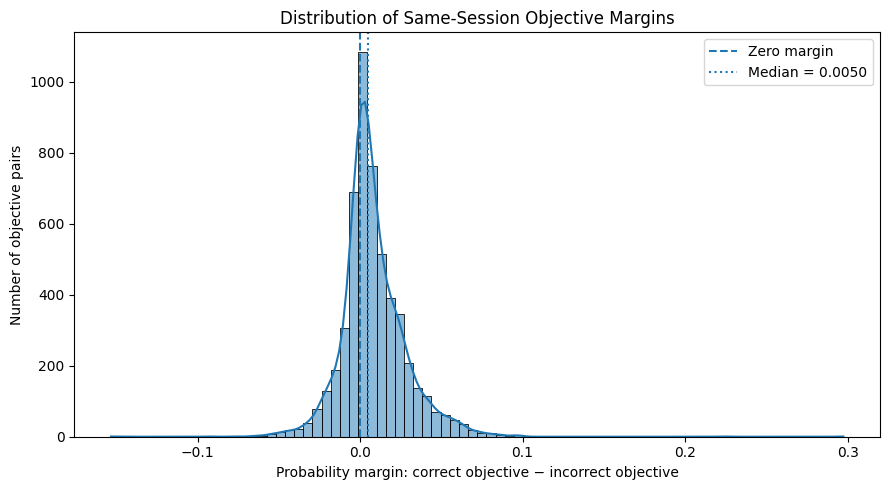

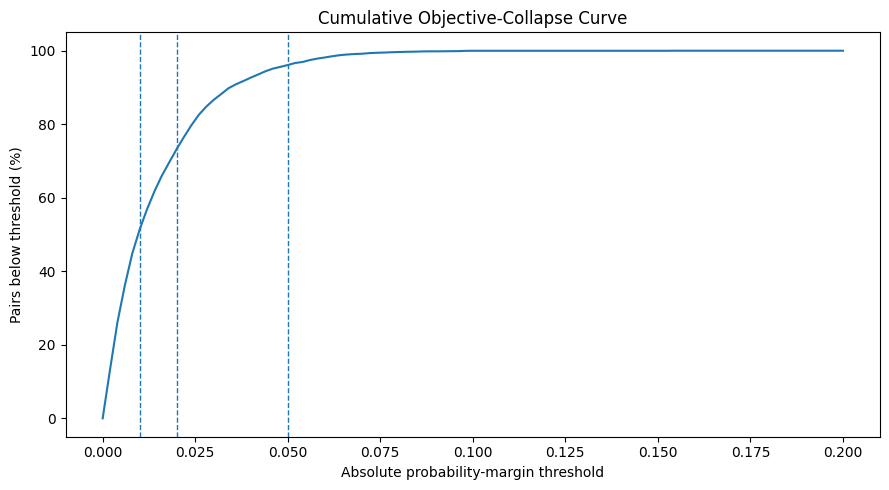

In [10]:
def plot_margin_analysis(pairs, collapse_curve, figures_dir):
    median_margin = pairs["probability_margin"].median()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(data=pairs, x="probability_margin", bins=80, kde=True, ax=ax)
    ax.axvline(0, linestyle="--", linewidth=1.5, label="Zero margin")
    ax.axvline(median_margin, linestyle=":", linewidth=1.5, label=f"Median = {median_margin:.4f}")
    ax.set(title="Distribution of Same-Session Objective Margins", xlabel="Probability margin: correct objective − incorrect objective", ylabel="Number of objective pairs")
    ax.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / "margin_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(data=collapse_curve, x="Absolute margin threshold", y="Pair share (%)", ax=ax)
    for threshold in [0.01, 0.02, 0.05]:
        ax.axvline(threshold, linestyle="--", linewidth=1)

    ax.set(title="Cumulative Objective-Collapse Curve", xlabel="Absolute probability-margin threshold", ylabel="Pairs below threshold (%)")
    plt.tight_layout()
    plt.savefig(figures_dir / "collapse_threshold_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_margin_analysis(objective_pairs, collapse_curve, figures_dir)

## 5.5 — Session-Level Objective Discrimination

This section summarizes each mixed-label session as one observation so that sessions with many objective pairs do not receive excessive influence.  
We will measure session-level probability separation, pairwise ranking accuracy, prediction spread, collapse, reversal, and Log Loss.  
The results will compare pair-weighted and session-weighted performance and determine whether objective collapse is widespread across sessions.  
Each mixed-label session will receive equal importance in the final session-level scorecard.

In [11]:
def build_session_discrimination(mixed_oof, objective_pairs, output_dir):
    data = mixed_oof.copy()
    probability = data["probability"].clip(1e-15, 1 - 1e-15)
    data["response_loss"] = -(data["correct"] * np.log(probability) + (1 - data["correct"]) * np.log1p(-probability))

    session_base = data.groupby("session_id").agg(fold_id=("fold_id", "first"), n_responses=("response_id", "size"), n_objectives=("objective_key", "nunique"), mean_probability=("probability", "mean"), probability_std=("probability", lambda x: x.std(ddof=0)), minimum_probability=("probability", "min"), maximum_probability=("probability", "max"), session_log_loss=("response_loss", "mean")).reset_index()
    session_base["probability_range"] = session_base["maximum_probability"] - session_base["minimum_probability"]

    positive = data[data["correct"].eq(1)].groupby("session_id").agg(n_positive=("response_id", "size"), positive_mean_probability=("probability", "mean"), positive_mean_loss=("response_loss", "mean"), min_positive_probability=("probability", "min")).reset_index()
    negative = data[data["correct"].eq(0)].groupby("session_id").agg(n_negative=("response_id", "size"), negative_mean_probability=("probability", "mean"), negative_mean_loss=("response_loss", "mean"), max_negative_probability=("probability", "max")).reset_index()

    pair_metrics = objective_pairs.groupby("session_id").agg(n_pairs=("probability_margin", "size"), session_pairwise_accuracy=("ranking_score", "mean"), mean_pair_margin=("probability_margin", "mean"), reversed_pair_share=("probability_margin", lambda x: x.lt(0).mean()), collapse_pair_share=("probability_margin", lambda x: x.abs().lt(0.02).mean()), mean_pair_loss=("pair_loss", "mean")).reset_index()

    session_metrics = session_base.merge(positive, on="session_id").merge(negative, on="session_id").merge(pair_metrics, on="session_id")
    session_metrics["session_margin"] = session_metrics["positive_mean_probability"] - session_metrics["negative_mean_probability"]
    session_metrics["is_session_collapse"] = session_metrics["session_margin"].abs().lt(0.02)
    session_metrics["is_session_reversed"] = session_metrics["session_margin"].lt(0)
    session_metrics["is_clear_reversal"] = session_metrics["session_margin"].le(-0.02)
    session_metrics["has_high_confidence_negative"] = session_metrics["max_negative_probability"].ge(0.80)

    margin = session_metrics["session_margin"]
    conditions = [margin.le(-0.02), margin.lt(0), margin.lt(0.02), margin.lt(0.05), margin.lt(0.10)]
    categories = ["Clear reversal", "Reversed near-collapse", "Positive-side collapse", "Weak positive separation", "Moderate discrimination"]
    session_metrics["session_margin_category"] = np.select(conditions, categories, default="Strong discrimination")

    category_order = ["Strong discrimination", "Moderate discrimination", "Weak positive separation", "Positive-side collapse", "Reversed near-collapse", "Clear reversal"]
    session_metrics["session_margin_category"] = pd.Categorical(session_metrics["session_margin_category"], categories=category_order, ordered=True)

    scorecard = pd.DataFrame([
        ["Mixed-label sessions", len(session_metrics)],
        ["Mean session margin", session_metrics["session_margin"].mean()],
        ["Median session margin", session_metrics["session_margin"].median()],
        ["Session-weighted pairwise accuracy (%)", 100 * session_metrics["session_pairwise_accuracy"].mean()],
        ["Positive-margin session rate (%)", 100 * session_metrics["session_margin"].gt(0).mean()],
        ["Reversed-session rate (%)", 100 * session_metrics["is_session_reversed"].mean()],
        ["Session-collapse rate: |margin| < 0.02 (%)", 100 * session_metrics["is_session_collapse"].mean()],
        ["Clear-reversal rate: margin <= -0.02 (%)", 100 * session_metrics["is_clear_reversal"].mean()],
        ["Median collapsed-pair share within session (%)", 100 * session_metrics["collapse_pair_share"].median()],
        ["Mean probability standard deviation", session_metrics["probability_std"].mean()],
        ["Mean probability range", session_metrics["probability_range"].mean()],
        ["Mean session Log Loss", session_metrics["session_log_loss"].mean()],
        ["Mean positive-objective loss", session_metrics["positive_mean_loss"].mean()],
        ["Mean negative-objective loss", session_metrics["negative_mean_loss"].mean()],
        ["High-confidence negative-session rate (%)", 100 * session_metrics["has_high_confidence_negative"].mean()]
    ], columns=["Metric", "Value"])

    category_summary = session_metrics.groupby("session_margin_category", observed=True).agg(Sessions=("session_id", "size"), Mean_session_margin=("session_margin", "mean"), Median_session_margin=("session_margin", "median"), Mean_pairwise_accuracy=("session_pairwise_accuracy", "mean"), Mean_collapse_pair_share=("collapse_pair_share", "mean"), Mean_session_log_loss=("session_log_loss", "mean")).reset_index()
    category_summary["Session share (%)"] = 100 * category_summary["Sessions"] / len(session_metrics)
    category_summary["Mean pairwise accuracy (%)"] = 100 * category_summary.pop("Mean_pairwise_accuracy")
    category_summary["Mean collapse-pair share (%)"] = 100 * category_summary.pop("Mean_collapse_pair_share")

    comparison = pd.DataFrame([
        ["Ranking accuracy (%)", 100 * objective_pairs["ranking_score"].mean(), 100 * session_metrics["session_pairwise_accuracy"].mean()],
        ["Positive-margin rate (%)", 100 * objective_pairs["probability_margin"].gt(0).mean(), 100 * session_metrics["session_margin"].gt(0).mean()],
        ["Reversal rate (%)", 100 * objective_pairs["probability_margin"].lt(0).mean(), 100 * session_metrics["session_margin"].lt(0).mean()],
        ["Collapse rate: |margin| < 0.02 (%)", 100 * objective_pairs["probability_margin"].abs().lt(0.02).mean(), 100 * session_metrics["session_margin"].abs().lt(0.02).mean()],
        ["Median probability margin", objective_pairs["probability_margin"].median(), session_metrics["session_margin"].median()],
        ["Mean probability margin", objective_pairs["probability_margin"].mean(), session_metrics["session_margin"].mean()]
    ], columns=["Metric", "Pair level", "Session level"])

    session_metrics.to_csv(output_dir / "session_discrimination_metrics.csv", index=False)
    scorecard.to_csv(output_dir / "session_discrimination_scorecard.csv", index=False)
    category_summary.to_csv(output_dir / "session_margin_category_summary.csv", index=False)
    comparison.to_csv(output_dir / "pair_vs_session_comparison.csv", index=False)

    return session_metrics, scorecard, category_summary, comparison

session_metrics, session_scorecard, session_category_summary, pair_vs_session_comparison = build_session_discrimination(mixed_oof, objective_pairs, step5_dir)

display(session_scorecard)
display(pair_vs_session_comparison)
display(session_category_summary)
display(session_metrics.head())

,Metric,Value
0,Mixed-label sessions,"3,207.0000"
1,Mean session margin,0.0085
2,Median session margin,0.0051
3,Session-weighted pairwise accuracy (%),67.6039
4,Positive-margin session rate (%),68.7247
5,Reversed-session rate (%),31.2753
6,Session-collapse rate: |margin| < 0.02 (%),74.9298
7,Clear-reversal rate: margin <= -0.02 (%),4.0848
8,Median collapsed-pair share within session (%),100.0000
9,Mean probability standard deviation,0.0084


,Metric,Pair level,Session level
0,Ranking accuracy (%),67.9316,67.6039
1,Positive-margin rate (%),67.9316,68.7247
2,Reversal rate (%),32.0684,31.2753
3,Collapse rate: |margin| < 0.02 (%),73.2294,74.9298
4,Median probability margin,0.0050,0.0051
5,Mean probability margin,0.0082,0.0085


,session_margin_category,Sessions,Mean_session_margin,Median_session_margin,Mean_session_log_loss,Session share (%),Mean pairwise accuracy (%),Mean collapse-pair share (%)
0,Strong discrimination,2,0.2098,0.2098,0.5202,0.0624,100.0000,0.0000
1,Moderate discrimination,118,0.0615,0.0587,0.6646,3.6795,100.0000,0.0000
2,Weak positive separation,553,0.0310,0.0291,0.7168,17.2435,99.2315,7.2363
3,Positive-side collapse,1531,0.0078,0.0067,0.7992,47.7393,92.4862,94.5044
4,Reversed near-collapse,872,-0.0062,-0.0047,0.8112,27.1905,9.3377,95.3074
5,Clear reversal,131,-0.0312,-0.0283,0.7816,4.0848,1.4631,6.8066


,session_id,fold_id,n_responses,n_objectives,mean_probability,probability_std,minimum_probability,maximum_probability,session_log_loss,probability_range,n_positive,positive_mean_probability,positive_mean_loss,min_positive_probability,n_negative,negative_mean_probability,negative_mean_loss,max_negative_probability,n_pairs,session_pairwise_accuracy,mean_pair_margin,reversed_pair_share,collapse_pair_share,mean_pair_loss,session_margin,is_session_collapse,is_session_reversed,is_clear_reversal,has_high_confidence_negative,session_margin_category
0,aaaedit,4,2,2,0.4832,0.0009,0.4823,0.4840,0.6919,0.0018,1,0.4840,0.7256,0.4840,1,0.4823,0.6583,0.4823,1,1.0000,0.0018,0.0000,1.0000,0.6919,0.0018,True,False,False,False,Positive-side collapse
1,aadexbc,0,2,2,0.5091,0.0412,0.4679,0.5503,0.6141,0.0824,1,0.5503,0.5974,0.5503,1,0.4679,0.6309,0.4679,1,1.0000,0.0824,0.0000,0.0000,0.6141,0.0824,False,False,False,False,Moderate discrimination
2,aaeqxpf,3,2,2,0.6235,0.0293,0.5942,0.6529,0.6641,0.0587,1,0.6529,0.4264,0.6529,1,0.5942,0.9019,0.5942,1,1.0000,0.0587,0.0000,0.0000,0.6641,0.0587,False,False,False,False,Moderate discrimination
3,aafitff,0,4,4,0.9112,0.0056,0.9051,0.9199,1.2276,0.0148,2,0.9161,0.0877,0.9123,2,0.9063,2.3675,0.9075,4,1.0000,0.0098,0.0000,1.0000,1.2276,0.0098,True,False,False,True,Positive-side collapse
4,aajftxu,0,2,2,0.6533,0.0025,0.6508,0.6559,0.7369,0.0051,1,0.6559,0.4218,0.6559,1,0.6508,1.0521,0.6508,1,1.0000,0.0051,0.0000,1.0000,0.7369,0.0051,True,False,False,False,Positive-side collapse


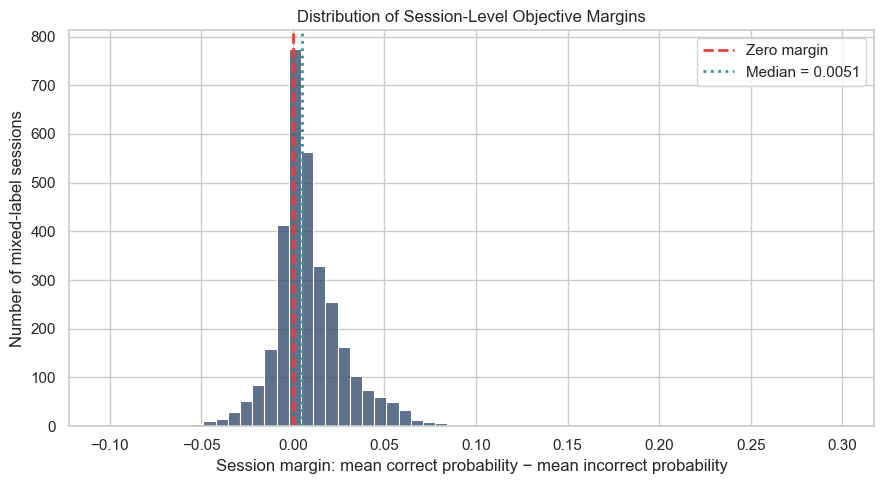

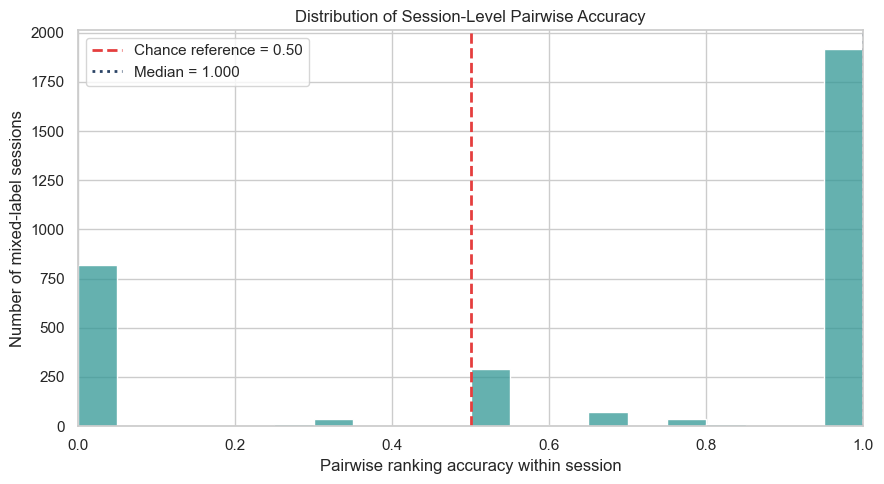

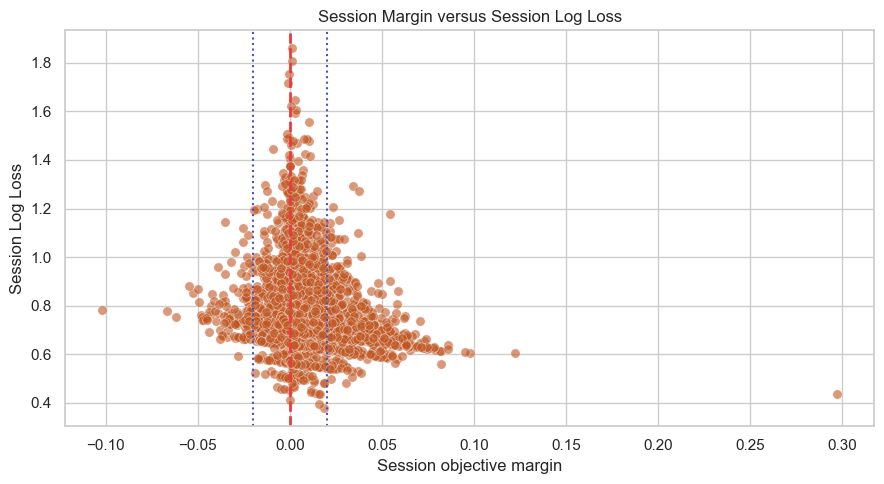

In [12]:
def plot_session_discrimination(session_metrics, figures_dir):
    deep_blue, teal, coral = "#2A4365", "#319795", "#E53E3E"
    terracotta, slate_blue, charcoal = "#C05621", "#4C51BF", "#4A5568"
    sns.set_theme(style="whitegrid")

    median_margin = session_metrics["session_margin"].median()
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(data=session_metrics, x="session_margin", bins=60, color=deep_blue, edgecolor="white", ax=ax)
    ax.axvline(0, color=coral, linestyle="--", linewidth=2, label="Zero margin")
    ax.axvline(median_margin, color=teal, linestyle=":", linewidth=2, label=f"Median = {median_margin:.4f}")
    ax.set(title="Distribution of Session-Level Objective Margins", xlabel="Session margin: mean correct probability − mean incorrect probability", ylabel="Number of mixed-label sessions")
    ax.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / "session_margin_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    median_accuracy = session_metrics["session_pairwise_accuracy"].median()
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(data=session_metrics, x="session_pairwise_accuracy", bins=np.linspace(0, 1, 21), color=teal, edgecolor="white", ax=ax)
    ax.axvline(0.50, color=coral, linestyle="--", linewidth=2, label="Chance reference = 0.50")
    ax.axvline(median_accuracy, color=deep_blue, linestyle=":", linewidth=2, label=f"Median = {median_accuracy:.3f}")
    ax.set(title="Distribution of Session-Level Pairwise Accuracy", xlabel="Pairwise ranking accuracy within session", ylabel="Number of mixed-label sessions", xlim=(0, 1))
    ax.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / "session_pairwise_accuracy_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.scatterplot(data=session_metrics, x="session_margin", y="session_log_loss", color=terracotta, alpha=0.60, s=45, edgecolor="white", linewidth=0.4, ax=ax)
    ax.axvline(0, color=coral, linestyle="--", linewidth=2)
    ax.axvline(0.02, color=slate_blue, linestyle=":", linewidth=1.5)
    ax.axvline(-0.02, color=slate_blue, linestyle=":", linewidth=1.5)
    ax.set(title="Session Margin versus Session Log Loss", xlabel="Session objective margin", ylabel="Session Log Loss")
    plt.tight_layout()
    plt.savefig(figures_dir / "session_margin_vs_log_loss.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_session_discrimination(session_metrics, figures_dir)

## 5.6 — Collapse and False-Positive Loss Burden

This section measures how much Log Loss is generated by collapsed, reversed, and high-confidence incorrect-objective predictions.

The analysis separates positive-objective and negative-objective losses, measures the total loss contribution of each session-margin category, identifies dangerous negative-probability ranges, and exports high-risk sessions for later manual investigation and hard-negative training.

In [13]:
def analyze_session_loss_burden(mixed_oof, session_metrics, output_dir):
    session_columns = ["session_id", "session_margin", "session_margin_category", "session_log_loss", "probability_range", "collapse_pair_share", "max_negative_probability", "is_session_collapse", "is_session_reversed", "is_clear_reversal"]
    data = mixed_oof.merge(session_metrics[session_columns], on="session_id", how="left", validate="many_to_one")

    probability = data["probability"].clip(1e-15, 1 - 1e-15)
    data["response_loss"] = -(data["correct"] * np.log(probability) + (1 - data["correct"]) * np.log1p(-probability))
    data["label_type"] = np.where(data["correct"].eq(1), "Positive objective", "Negative objective")
    data["positive_loss"] = data["response_loss"].where(data["correct"].eq(1))
    data["negative_loss"] = data["response_loss"].where(data["correct"].eq(0))
    data["negative_loss_total"] = data["response_loss"].where(data["correct"].eq(0), 0.0)
    data["is_high_confidence_negative"] = data["correct"].eq(0) & data["probability"].ge(0.80)
    data["collapse_status"] = np.where(data["is_session_collapse"], "Collapsed", "Non-collapsed")

    total_loss = data["response_loss"].sum()
    total_negative_loss = data["negative_loss_total"].sum()

    category_summary = data.groupby("session_margin_category", observed=True).agg(Sessions=("session_id", "nunique"), Responses=("response_id", "size"), Positive_responses=("correct", "sum"), Mean_response_loss=("response_loss", "mean"), Total_response_loss=("response_loss", "sum"), Mean_positive_loss=("positive_loss", "mean"), Mean_negative_loss=("negative_loss", "mean"), Total_negative_loss=("negative_loss_total", "sum"), High_confidence_negative_responses=("is_high_confidence_negative", "sum")).reset_index()

    category_summary["Positive_responses"] = category_summary["Positive_responses"].astype(int)
    category_summary["Negative_responses"] = category_summary["Responses"] - category_summary["Positive_responses"]
    category_summary["Response share (%)"] = 100 * category_summary["Responses"] / len(data)
    category_summary["Mixed-session loss share (%)"] = 100 * category_summary["Total_response_loss"] / total_loss
    category_summary["Negative-loss share (%)"] = 100 * category_summary["Total_negative_loss"] / total_negative_loss
    category_summary["High-confidence negative rate (%)"] = 100 * category_summary["High_confidence_negative_responses"] / category_summary["Negative_responses"]

    collapse_summary = data.groupby("collapse_status").agg(Sessions=("session_id", "nunique"), Responses=("response_id", "size"), Positive_responses=("correct", "sum"), Mean_response_loss=("response_loss", "mean"), Total_response_loss=("response_loss", "sum"), Mean_positive_loss=("positive_loss", "mean"), Mean_negative_loss=("negative_loss", "mean"), High_confidence_negative_responses=("is_high_confidence_negative", "sum")).reset_index()

    collapse_summary["Positive_responses"] = collapse_summary["Positive_responses"].astype(int)
    collapse_summary["Negative_responses"] = collapse_summary["Responses"] - collapse_summary["Positive_responses"]
    collapse_summary["Session share (%)"] = 100 * collapse_summary["Sessions"] / session_metrics["session_id"].nunique()
    collapse_summary["Mixed-session loss share (%)"] = 100 * collapse_summary["Total_response_loss"] / total_loss
    collapse_summary["High-confidence negative rate (%)"] = 100 * collapse_summary["High_confidence_negative_responses"] / collapse_summary["Negative_responses"]

    negative = data[data["correct"].eq(0)].copy()
    bucket_order = ["[0.00, 0.50)", "[0.50, 0.60)", "[0.60, 0.70)", "[0.70, 0.80)", "[0.80, 0.90)", "[0.90, 1.00]"]
    negative["confidence_bucket"] = pd.cut(negative["probability"], bins=[0, 0.50, 0.60, 0.70, 0.80, 0.90, 1.0000001], labels=bucket_order, right=False, include_lowest=True)

    negative_confidence_summary = negative.groupby("confidence_bucket", observed=True).agg(Negative_responses=("response_id", "size"), Mean_negative_probability=("probability", "mean"), Mean_negative_loss=("response_loss", "mean"), Total_negative_loss=("response_loss", "sum"), Collapsed_responses=("is_session_collapse", "sum")).reset_index()

    negative_confidence_summary["Negative response share (%)"] = 100 * negative_confidence_summary["Negative_responses"] / len(negative)
    negative_confidence_summary["Negative-loss share (%)"] = 100 * negative_confidence_summary["Total_negative_loss"] / negative["response_loss"].sum()
    negative_confidence_summary["Collapsed-session response share (%)"] = 100 * negative_confidence_summary["Collapsed_responses"] / negative_confidence_summary["Negative_responses"]

    session_loss = data.groupby("session_id").agg(session_total_loss=("response_loss", "sum")).reset_index()
    risk_sessions = session_metrics.merge(session_loss, on="session_id", how="left", validate="one_to_one")

    margin = risk_sessions["session_margin"]
    max_negative = risk_sessions["max_negative_probability"]
    conditions = [margin.le(-0.02), margin.gt(-0.02) & margin.lt(0) & max_negative.ge(0.80), margin.ge(0) & margin.lt(0.02) & max_negative.ge(0.80), margin.abs().lt(0.02) & max_negative.lt(0.70), margin.ge(0.05) & max_negative.lt(0.70)]
    risk_labels = ["Clear reversal", "High-confidence near-zero reversal", "High-confidence positive collapse", "Low-risk collapse", "Safe discrimination"]
    risk_sessions["risk_group"] = np.select(conditions, risk_labels, default="Other")

    risk_summary = risk_sessions.groupby("risk_group").agg(Sessions=("session_id", "size"), Responses=("n_responses", "sum"), Mean_session_margin=("session_margin", "mean"), Mean_session_log_loss=("session_log_loss", "mean"), Total_response_loss=("session_total_loss", "sum"), Mean_max_negative_probability=("max_negative_probability", "mean")).reset_index()

    risk_summary["Session share (%)"] = 100 * risk_summary["Sessions"] / len(risk_sessions)
    risk_summary["Mixed-session loss share (%)"] = 100 * risk_summary["Total_response_loss"] / risk_sessions["session_total_loss"].sum()

    ordered_sessions = risk_sessions.sort_values("session_log_loss", ascending=False).reset_index(drop=True)
    concentration_rows = []

    for percentage in [1, 5, 10, 20]:
        n_sessions = max(1, int(np.ceil(len(ordered_sessions) * percentage / 100)))
        worst_sessions = ordered_sessions.head(n_sessions)
        concentration_rows.append([f"Worst {percentage}% sessions", n_sessions, int(worst_sessions["n_responses"].sum()), worst_sessions["session_log_loss"].mean(), 100 * worst_sessions["session_total_loss"].sum() / ordered_sessions["session_total_loss"].sum()])

    loss_concentration = pd.DataFrame(concentration_rows, columns=["Population", "Sessions", "Responses", "Mean session Log Loss", "Mixed-session loss share (%)"])

    high_risk_sessions = risk_sessions[risk_sessions["is_clear_reversal"] | (risk_sessions["is_session_collapse"] & risk_sessions["max_negative_probability"].ge(0.80))].sort_values(["session_log_loss", "max_negative_probability"], ascending=False)

    data.to_parquet(output_dir / "response_loss_with_session_state.parquet", index=False)
    category_summary.to_csv(output_dir / "session_category_loss_summary.csv", index=False)
    collapse_summary.to_csv(output_dir / "collapse_vs_noncollapse_loss.csv", index=False)
    negative_confidence_summary.to_csv(output_dir / "negative_confidence_loss_summary.csv", index=False)
    risk_summary.to_csv(output_dir / "session_risk_group_summary.csv", index=False)
    loss_concentration.to_csv(output_dir / "loss_concentration_summary.csv", index=False)
    high_risk_sessions.to_parquet(output_dir / "high_risk_sessions.parquet", index=False)

    return data, category_summary, collapse_summary, negative_confidence_summary, risk_sessions, risk_summary, loss_concentration, high_risk_sessions


response_loss_data, category_loss_summary, collapse_loss_summary, negative_confidence_summary, risk_sessions, risk_group_summary, loss_concentration_summary, high_risk_sessions = analyze_session_loss_burden(mixed_oof, session_metrics, step5_dir)

display(category_loss_summary)
display(collapse_loss_summary)
display(negative_confidence_summary)
display(risk_group_summary)
display(loss_concentration_summary)

print(f"High-risk sessions exported: {len(high_risk_sessions):,}")

,session_margin_category,Sessions,Responses,Positive_responses,Mean_response_loss,Total_response_loss,Mean_positive_loss,Mean_negative_loss,Total_negative_loss,High_confidence_negative_responses,Negative_responses,Response share (%),Mixed-session loss share (%),Negative-loss share (%),High-confidence negative rate (%)
0,Strong discrimination,2,5,2,0.5375,2.6873,0.4571,0.5910,1.7731,0,3,0.0603,0.0421,0.0366,0.0000
1,Moderate discrimination,118,267,135,0.6673,178.1639,0.4777,0.8612,113.6758,1,132,3.2184,2.7887,2.3495,0.7576
2,Weak positive separation,553,1388,771,0.7066,980.7239,0.3911,1.1008,679.1971,52,617,16.7310,15.3506,14.0377,8.4279
3,Positive-side collapse,1531,4101,2302,0.7858,"3,222.4580",0.3052,1.4007,"2,519.8035",556,1799,49.4335,50.4388,52.0795,30.9061
4,Reversed near-collapse,872,2227,1239,0.7929,"1,765.7356",0.3250,1.3796,"1,363.0624",291,988,26.8443,27.6378,28.1719,29.4534
5,Clear reversal,131,308,162,0.7762,239.0740,0.4828,1.1018,160.8674,15,146,3.7126,3.7421,3.3248,10.2740


,collapse_status,Sessions,Responses,Positive_responses,Mean_response_loss,Total_response_loss,Mean_positive_loss,Mean_negative_loss,High_confidence_negative_responses,Negative_responses,Session share (%),Mixed-session loss share (%),High-confidence negative rate (%)
0,Collapsed,2403,6328,3541,0.7883,"4,988.1934",0.3122,1.3932,847,2787,74.9298,78.0766,30.3911
1,Non-collapsed,804,1968,1070,0.7117,"1,400.6489",0.4160,1.0640,68,898,25.0702,21.9234,7.5724


,confidence_bucket,Negative_responses,Mean_negative_probability,Mean_negative_loss,Total_negative_loss,Collapsed_responses,Negative response share (%),Negative-loss share (%),Collapsed-session response share (%)
0,"[0.00, 0.50)",283,0.4383,0.5809,164.3894,156,7.6798,3.3976,55.1237
1,"[0.50, 0.60)",496,0.5557,0.8133,403.3904,292,13.4600,8.3373,58.8710
2,"[0.60, 0.70)",887,0.6530,1.0618,941.8232,602,24.0706,19.4657,67.8692
3,"[0.70, 0.80)",1104,0.7495,1.3907,"1,535.3606",890,29.9593,31.7330,80.6159
4,"[0.80, 0.90)",804,0.8443,1.8777,"1,509.6729",736,21.8182,31.2020,91.5423
5,"[0.90, 1.00]",111,0.9204,2.5562,283.7428,111,3.0122,5.8644,100.0000


,risk_group,Sessions,Responses,Mean_session_margin,Mean_session_log_loss,Total_response_loss,Mean_max_negative_probability,Session share (%),Mixed-session loss share (%)
0,Clear reversal,131,308,-0.0312,0.7816,239.0740,0.6506,4.0848,3.7421
1,High-confidence near-zero reversal,264,734,-0.0043,0.9261,641.0247,0.8516,8.2320,10.0335
2,High-confidence positive collapse,463,1404,0.0063,0.9235,"1,238.8175",0.8572,14.4372,19.3903
3,Low-risk collapse,899,2164,0.0031,0.7157,"1,540.7014",0.5933,28.0324,24.1155
4,Other,1341,3443,0.0148,0.7609,"2,571.6511",0.7090,41.8148,40.2522
5,Safe discrimination,109,243,0.0645,0.6496,157.5740,0.5428,3.3988,2.4664


,Population,Sessions,Responses,Mean session Log Loss,Mixed-session loss share (%)
0,Worst 1% sessions,33,98,1.4896,2.3108
1,Worst 5% sessions,161,462,1.2535,9.1364
2,Worst 10% sessions,321,843,1.1526,15.4000
3,Worst 20% sessions,642,1610,1.0460,26.6816


High-risk sessions exported: 858


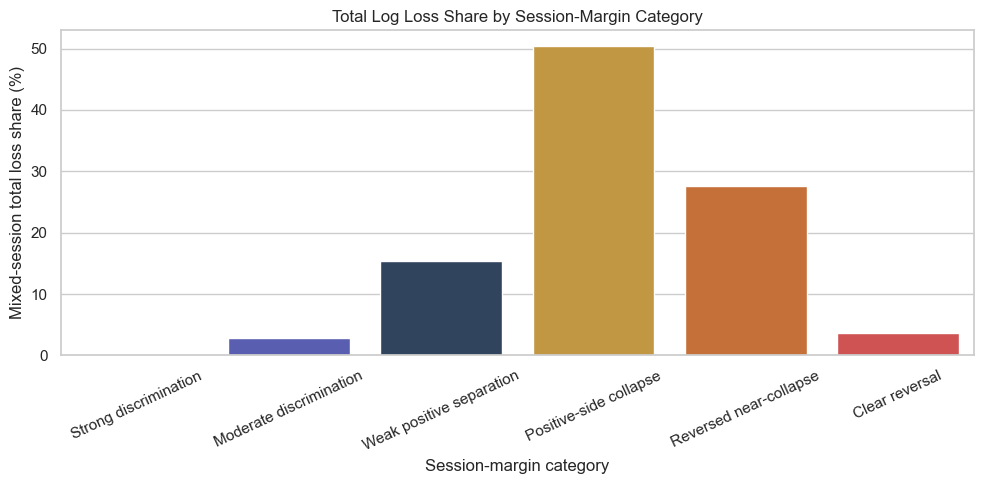

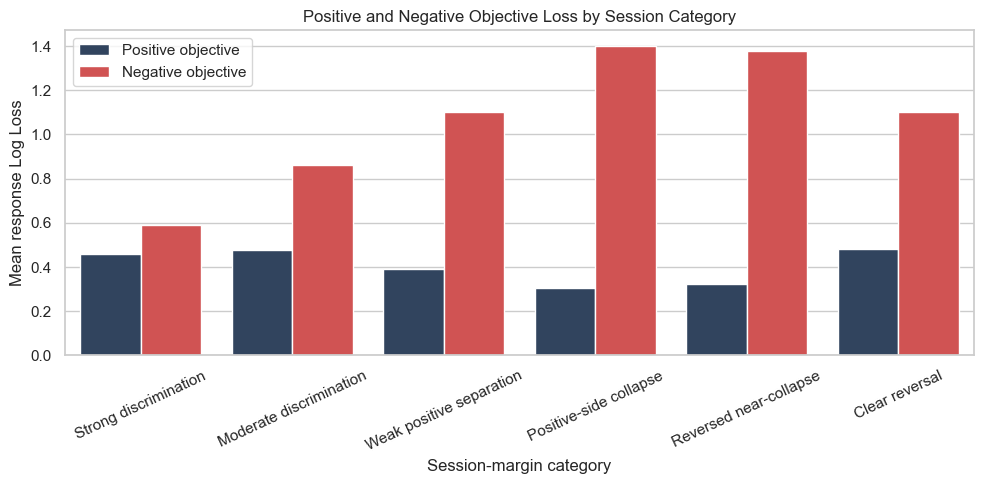

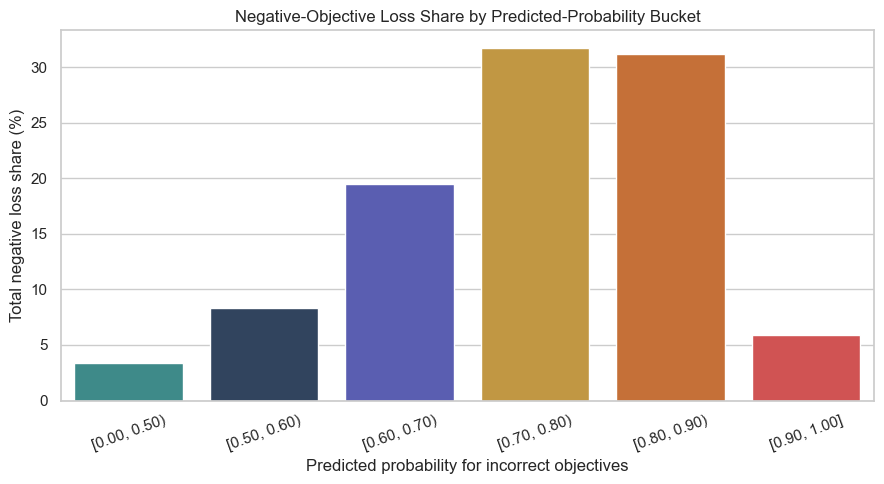

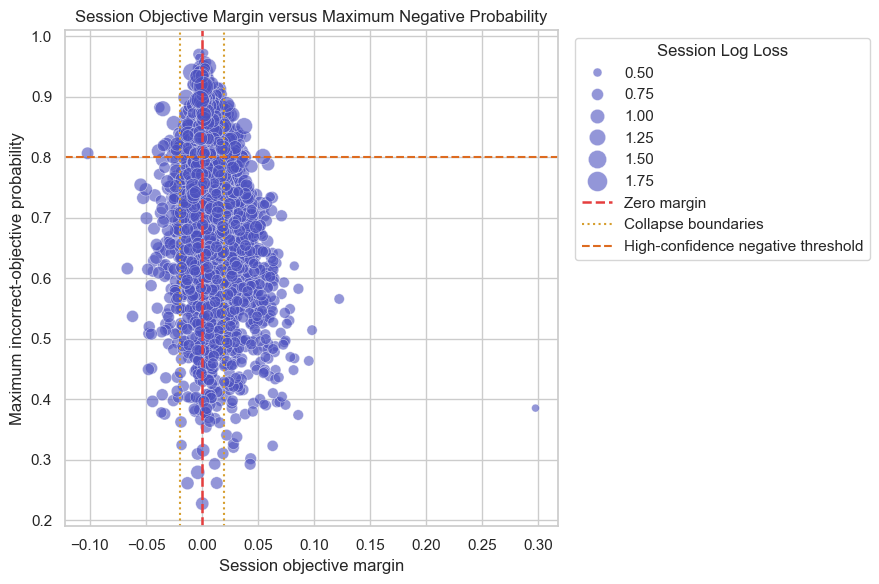

In [14]:
def plot_session_loss_burden(category_summary, negative_summary, session_metrics, figures_dir):
    deep_blue, teal, coral = "#2A4365", "#319795", "#E53E3E"
    warm_orange, gold, slate_blue = "#DD6B20", "#D69E2E", "#4C51BF"
    category_order = ["Strong discrimination", "Moderate discrimination", "Weak positive separation", "Positive-side collapse", "Reversed near-collapse", "Clear reversal"]
    category_palette = {"Strong discrimination": teal, "Moderate discrimination": slate_blue, "Weak positive separation": deep_blue, "Positive-side collapse": gold, "Reversed near-collapse": warm_orange, "Clear reversal": coral}
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=category_summary, x="session_margin_category", y="Mixed-session loss share (%)", hue="session_margin_category", order=category_order, palette=category_palette, legend=False, ax=ax)
    ax.set(title="Total Log Loss Share by Session-Margin Category", xlabel="Session-margin category", ylabel="Mixed-session total loss share (%)")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig(figures_dir / "loss_share_by_session_category.png", dpi=300, bbox_inches="tight")
    plt.show()

    loss_comparison = category_summary.melt(id_vars="session_margin_category", value_vars=["Mean_positive_loss", "Mean_negative_loss"], var_name="Objective type", value_name="Mean Log Loss")
    loss_comparison["Objective type"] = loss_comparison["Objective type"].replace({"Mean_positive_loss": "Positive objective", "Mean_negative_loss": "Negative objective"})

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=loss_comparison, x="session_margin_category", y="Mean Log Loss", hue="Objective type", order=category_order, palette={"Positive objective": deep_blue, "Negative objective": coral}, ax=ax)
    ax.set(title="Positive and Negative Objective Loss by Session Category", xlabel="Session-margin category", ylabel="Mean response Log Loss")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="")
    plt.tight_layout()
    plt.savefig(figures_dir / "positive_vs_negative_loss.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=negative_summary, x="confidence_bucket", y="Negative-loss share (%)", hue="confidence_bucket", palette=[teal, deep_blue, slate_blue, gold, warm_orange, coral], legend=False, ax=ax)
    ax.set(title="Negative-Objective Loss Share by Predicted-Probability Bucket", xlabel="Predicted probability for incorrect objectives", ylabel="Total negative loss share (%)")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(figures_dir / "negative_confidence_loss_share.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.scatterplot(data=session_metrics, x="session_margin", y="max_negative_probability", size="session_log_loss", sizes=(25, 220), color=slate_blue, alpha=0.60, edgecolor="white", linewidth=0.4, ax=ax)
    ax.axvline(0, color=coral, linestyle="--", linewidth=1.8, label="Zero margin")
    ax.axvline(-0.02, color=gold, linestyle=":", linewidth=1.5)
    ax.axvline(0.02, color=gold, linestyle=":", linewidth=1.5, label="Collapse boundaries")
    ax.axhline(0.80, color=warm_orange, linestyle="--", linewidth=1.5, label="High-confidence negative threshold")
    ax.set(title="Session Objective Margin versus Maximum Negative Probability", xlabel="Session objective margin", ylabel="Maximum incorrect-objective probability")
    ax.legend(title="Session Log Loss", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(figures_dir / "session_margin_vs_max_negative_probability.png", dpi=300, bbox_inches="tight")
    plt.show()



plot_session_loss_burden(category_loss_summary, negative_confidence_summary, session_metrics, figures_dir)

## 5.7 — Structural Factors Associated with Objective Collapse

This section examines whether same-session objective collapse is associated with five structural characteristics:

1. Number of objectives in the session
2. Transcript length
3. Student–tutor text balance
4. Positive–negative objective composition
5. Overall session confidence

For each factor, we compare session margin, collapse rate, reversal rate, pairwise ranking accuracy, Log Loss, negative-objective loss, and maximum incorrect-objective probability.

These results describe associations only. They do not prove that a structural factor directly causes objective collapse.

In [15]:
def analyze_collapse_structural_factors(session_metrics, mixed_oof, output_dir):
    structural_columns = ["session_id", "total_words", "total_turns", "student_turns", "tutor_turns", "student_word_ratio"]
    session_features = mixed_oof.groupby("session_id")[structural_columns[1:]].first().reset_index()
    session_structural = session_metrics.merge(session_features, on="session_id", how="left", validate="one_to_one")

    session_structural["objective_count_group"] = pd.cut(session_structural["n_objectives"], bins=[1, 2, 4, np.inf], labels=["2 objectives", "3–4 objectives", "5+ objectives"])
    session_structural["transcript_length_group"] = pd.qcut(session_structural["total_words"].rank(method="first"), q=4, labels=["Short", "Medium", "Long", "Very long"])

    student_share = session_structural["student_word_ratio"]
    conditions = [student_share.lt(0.40), student_share.between(0.40, 0.60, inclusive="both"), student_share.gt(0.60)]
    session_structural["speaker_balance_group"] = np.select(conditions, ["Tutor-dominant", "Balanced", "Student-dominant"], default="Unavailable")

    positive, negative = session_structural["n_positive"], session_structural["n_negative"]
    conditions = [positive.eq(1) & negative.eq(1), positive.eq(1) & negative.gt(1), positive.gt(1) & negative.eq(1)]
    session_structural["objective_composition_group"] = np.select(conditions, ["1 positive, 1 negative", "1 positive, many negatives", "Many positives, 1 negative"], default="Many positives, many negatives")

    session_structural["session_confidence_group"] = pd.qcut(session_structural["mean_probability"].rank(method="first"), q=4, labels=["Low confidence", "Medium confidence", "High confidence", "Very high confidence"])

    factor_settings = {
        "objective_count_group": ("n_objectives", ["2 objectives", "3–4 objectives", "5+ objectives"]),
        "transcript_length_group": ("total_words", ["Short", "Medium", "Long", "Very long"]),
        "speaker_balance_group": ("student_word_ratio", ["Tutor-dominant", "Balanced", "Student-dominant", "Unavailable"]),
        "objective_composition_group": ("n_objectives", ["1 positive, 1 negative", "1 positive, many negatives", "Many positives, 1 negative", "Many positives, many negatives"]),
        "session_confidence_group": ("mean_probability", ["Low confidence", "Medium confidence", "High confidence", "Very high confidence"])
    }

    summaries = {}

    for group_column, (factor_column, group_order) in factor_settings.items():
        summary = session_structural.groupby(group_column, observed=True).agg(Sessions=("session_id", "size"), Median_factor_value=(factor_column, "median"), Median_session_margin=("session_margin", "median"), Collapse_rate=("is_session_collapse", "mean"), Reversal_rate=("is_session_reversed", "mean"), Pairwise_accuracy=("session_pairwise_accuracy", "mean"), Mean_session_log_loss=("session_log_loss", "mean"), Mean_negative_objective_loss=("negative_mean_loss", "mean"), Mean_max_negative_probability=("max_negative_probability", "mean")).reset_index()

        summary["Collapse rate (%)"] = 100 * summary.pop("Collapse_rate")
        summary["Reversal rate (%)"] = 100 * summary.pop("Reversal_rate")
        summary["Session-weighted pairwise accuracy (%)"] = 100 * summary.pop("Pairwise_accuracy")
        summary[group_column] = pd.Categorical(summary[group_column], categories=group_order, ordered=True)
        summaries[group_column] = summary.sort_values(group_column).reset_index(drop=True)

    correlation_rows = []

    for factor in ["n_objectives", "total_words", "student_word_ratio", "mean_probability"]:
        valid = session_structural[[factor, "session_margin"]].dropna()
        correlation, p_value = stats.spearmanr(valid[factor], valid["session_margin"])
        correlation_rows.append([factor, len(valid), correlation, p_value])

    structural_correlations = pd.DataFrame(correlation_rows, columns=["Structural factor", "Sessions", "Spearman correlation with session margin", "P-value"])

    objective_count_summary = summaries["objective_count_group"]
    transcript_length_summary = summaries["transcript_length_group"]
    speaker_balance_summary = summaries["speaker_balance_group"]
    objective_composition_summary = summaries["objective_composition_group"]
    session_confidence_summary = summaries["session_confidence_group"]

    session_structural.to_parquet(output_dir / "session_structural_features.parquet", index=False)
    objective_count_summary.to_csv(output_dir / "objective_count_factor_summary.csv", index=False)
    transcript_length_summary.to_csv(output_dir / "transcript_length_factor_summary.csv", index=False)
    speaker_balance_summary.to_csv(output_dir / "speaker_balance_factor_summary.csv", index=False)
    objective_composition_summary.to_csv(output_dir / "objective_composition_factor_summary.csv", index=False)
    session_confidence_summary.to_csv(output_dir / "session_confidence_factor_summary.csv", index=False)
    structural_correlations.to_csv(output_dir / "structural_factor_correlations.csv", index=False)

    return session_structural, objective_count_summary, transcript_length_summary, speaker_balance_summary, objective_composition_summary, session_confidence_summary, structural_correlations

In [16]:
session_structural, objective_count_summary, transcript_length_summary, speaker_balance_summary, objective_composition_summary, session_confidence_summary, structural_correlations = analyze_collapse_structural_factors(session_metrics, mixed_oof, step5_dir)

display(objective_count_summary)
display(transcript_length_summary)
display(speaker_balance_summary)
display(objective_composition_summary)
display(session_confidence_summary)
display(structural_correlations)

length_quartiles = session_structural["total_words"].quantile([0.25, 0.50, 0.75])

print(f"Mixed-label sessions analyzed: {len(session_structural):,}")
print(f"Transcript-length quartiles: Q1={length_quartiles.loc[0.25]:.0f}, Median={length_quartiles.loc[0.50]:.0f}, Q3={length_quartiles.loc[0.75]:.0f} words")
print(f"Sessions without student-word-ratio information: {session_structural['student_word_ratio'].isna().sum():,}")
print(f"Outputs saved in: {step5_dir}")

,objective_count_group,Sessions,Median_factor_value,Median_session_margin,Mean_session_log_loss,Mean_negative_objective_loss,Mean_max_negative_probability,Collapse rate (%),Reversal rate (%),Session-weighted pairwise accuracy (%)
0,2 objectives,1922,2.0000,0.0046,0.8100,1.2299,0.6804,72.7367,32.2060,67.7940
1,3–4 objectives,1161,3.0000,0.0056,0.7463,1.3803,0.7249,77.0887,30.5771,66.9610
2,5+ objectives,124,5.0000,0.0053,0.6921,1.8227,0.8126,88.7097,23.3871,70.6765


,transcript_length_group,Sessions,Median_factor_value,Median_session_margin,Mean_session_log_loss,Mean_negative_objective_loss,Mean_max_negative_probability,Collapse rate (%),Reversal rate (%),Session-weighted pairwise accuracy (%)
0,Short,802,"2,614.5000",0.0059,0.7741,1.2784,0.6950,70.0748,30.7980,67.7244
1,Medium,802,"3,377.0000",0.0053,0.7746,1.2843,0.6961,74.0648,30.9227,67.6164
2,Long,801,"3,953.0000",0.0046,0.7811,1.3057,0.6993,76.1548,32.5843,66.6570
3,Very long,802,"4,692.5000",0.0042,0.7997,1.3605,0.7162,79.4264,30.7980,68.4165


,speaker_balance_group,Sessions,Median_factor_value,Median_session_margin,Mean_session_log_loss,Mean_negative_objective_loss,Mean_max_negative_probability,Collapse rate (%),Reversal rate (%),Session-weighted pairwise accuracy (%)
0,Tutor-dominant,2830,0.2641,0.0051,0.7839,1.3085,0.7015,74.9823,31.4488,67.7064
1,Balanced,372,0.4343,0.0054,0.7711,1.2968,0.7023,74.7312,29.8387,66.9258
2,Student-dominant,5,0.6458,0.0046,0.7672,1.3757,0.7154,60.0000,40.0000,60.0000


,objective_composition_group,Sessions,Median_factor_value,Median_session_margin,Mean_session_log_loss,Mean_negative_objective_loss,Mean_max_negative_probability,Collapse rate (%),Reversal rate (%),Session-weighted pairwise accuracy (%)
0,"1 positive, 1 negative",1922,2.0000,0.0046,0.8100,1.2299,0.6804,72.7367,32.2060,67.7940
1,"1 positive, many negatives",276,3.0000,0.0072,0.9756,1.2557,0.6982,77.8986,31.5217,64.0399
2,"Many positives, 1 negative",875,3.0000,0.0049,0.6500,1.4638,0.7410,77.4857,30.2857,67.9283
3,"Many positives, many negatives",134,4.0000,0.0060,0.8524,1.5013,0.7558,83.5821,23.8806,70.0995


,session_confidence_group,Sessions,Median_factor_value,Median_session_margin,Mean_session_log_loss,Mean_negative_objective_loss,Mean_max_negative_probability,Collapse rate (%),Reversal rate (%),Session-weighted pairwise accuracy (%)
0,Low confidence,802,0.5487,0.0083,0.6903,0.7582,0.5275,60.5985,28.3042,71.4464
1,Medium confidence,802,0.6747,0.0071,0.7292,1.1106,0.6706,67.5810,31.4214,67.2745
2,High confidence,801,0.7586,0.0047,0.7969,1.4141,0.7565,80.6492,33.0836,66.2897
3,Very high confidence,802,0.8476,0.0025,0.9132,1.9463,0.8520,90.8978,32.2943,65.4032


,Structural factor,Sessions,Spearman correlation with session margin,P-value
0,n_objectives,3207,-0.0021,0.9045
1,total_words,3207,-0.0356,0.0437
2,student_word_ratio,3207,-0.0143,0.4186
3,mean_probability,3207,-0.1430,0.0000


Mixed-label sessions analyzed: 3,207
Transcript-length quartiles: Q1=3064, Median=3681, Q3=4268 words
Sessions without student-word-ratio information: 0
Outputs saved in: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\05_session_objective


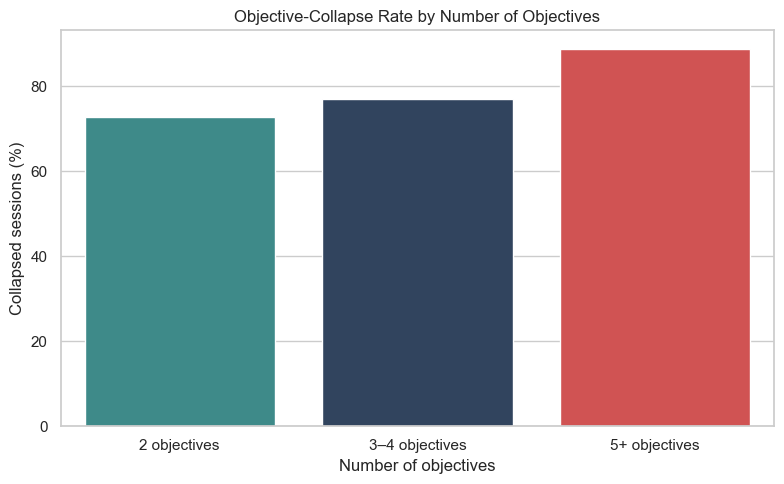

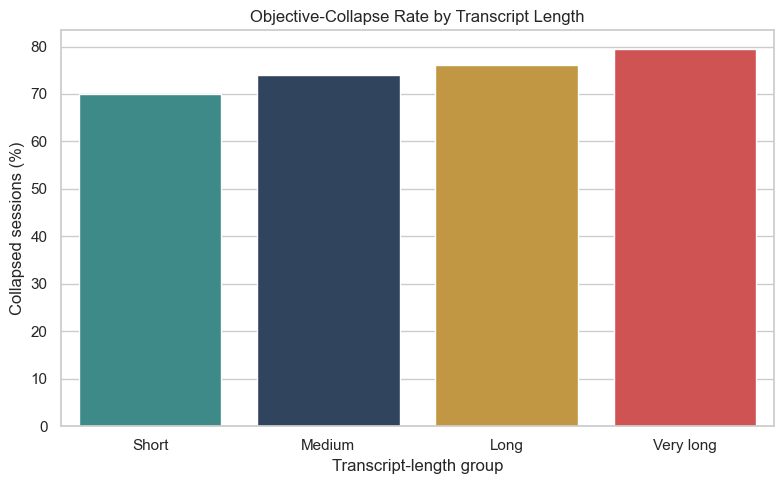

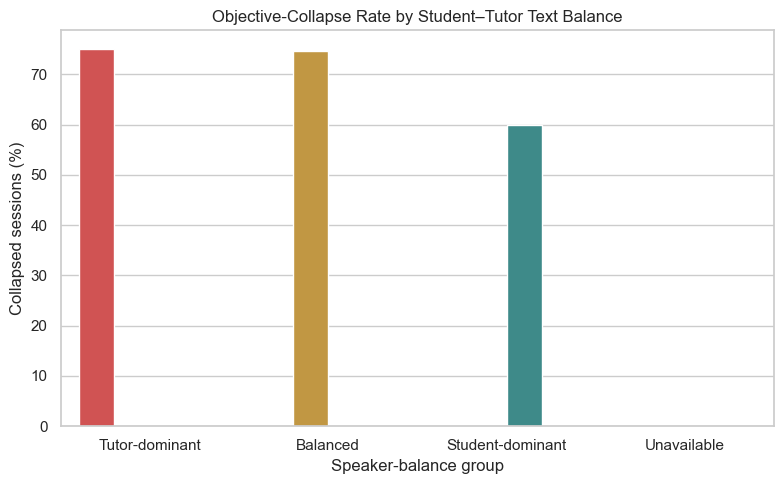

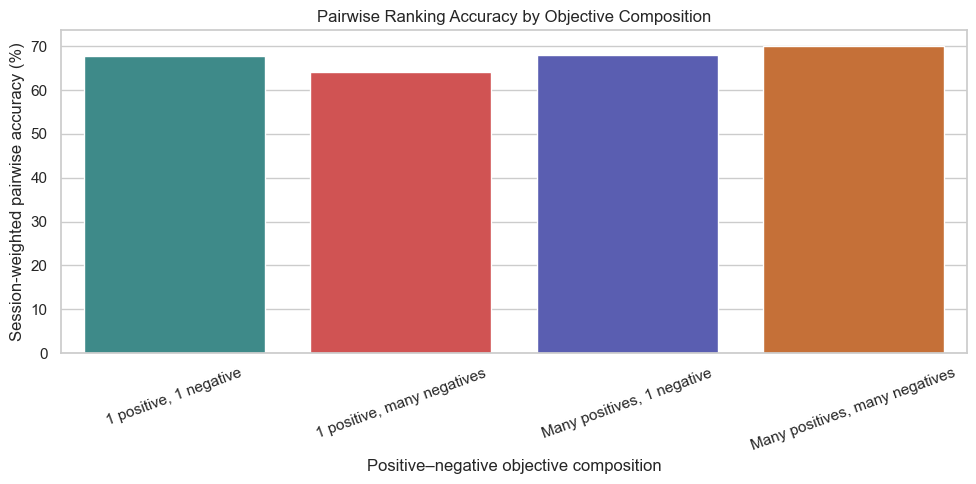

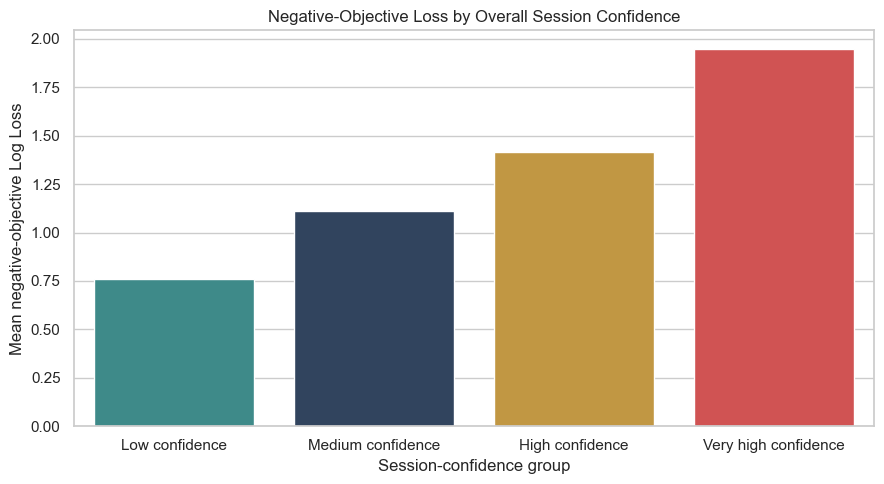

In [17]:
def plot_collapse_structural_factors(objective_count_summary, transcript_length_summary, speaker_balance_summary, objective_composition_summary, session_confidence_summary, figures_dir):
    deep_blue, teal, coral, warm_orange, slate_blue, gold = "#2A4365", "#319795", "#E53E3E", "#DD6B20", "#4C51BF", "#D69E2E"
    sns.set_theme(style="whitegrid")

    objective_palette = {"2 objectives": teal, "3–4 objectives": deep_blue, "5+ objectives": coral}
    length_palette = {"Short": teal, "Medium": deep_blue, "Long": gold, "Very long": coral}
    balance_palette = {"Tutor-dominant": coral, "Balanced": gold, "Student-dominant": teal, "Unavailable": "#A0AEC0"}
    composition_palette = {"1 positive, 1 negative": teal, "1 positive, many negatives": coral, "Many positives, 1 negative": slate_blue, "Many positives, many negatives": warm_orange}
    confidence_palette = {"Low confidence": teal, "Medium confidence": deep_blue, "High confidence": gold, "Very high confidence": coral}

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=objective_count_summary, x="objective_count_group", y="Collapse rate (%)", hue="objective_count_group", palette=objective_palette, legend=False, ax=ax)
    ax.set(title="Objective-Collapse Rate by Number of Objectives", xlabel="Number of objectives", ylabel="Collapsed sessions (%)")
    plt.tight_layout()
    plt.savefig(figures_dir / "collapse_by_objective_count.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=transcript_length_summary, x="transcript_length_group", y="Collapse rate (%)", hue="transcript_length_group", palette=length_palette, legend=False, ax=ax)
    ax.set(title="Objective-Collapse Rate by Transcript Length", xlabel="Transcript-length group", ylabel="Collapsed sessions (%)")
    plt.tight_layout()
    plt.savefig(figures_dir / "collapse_by_transcript_length.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    plot_balance = speaker_balance_summary[speaker_balance_summary["speaker_balance_group"].ne("Unavailable")]
    sns.barplot(data=plot_balance, x="speaker_balance_group", y="Collapse rate (%)", hue="speaker_balance_group", palette=balance_palette, legend=False, ax=ax)
    ax.set(title="Objective-Collapse Rate by Student–Tutor Text Balance", xlabel="Speaker-balance group", ylabel="Collapsed sessions (%)")
    plt.tight_layout()
    plt.savefig(figures_dir / "collapse_by_speaker_balance.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=objective_composition_summary, x="objective_composition_group", y="Session-weighted pairwise accuracy (%)", hue="objective_composition_group", palette=composition_palette, legend=False, ax=ax)
    ax.set(title="Pairwise Ranking Accuracy by Objective Composition", xlabel="Positive–negative objective composition", ylabel="Session-weighted pairwise accuracy (%)")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(figures_dir / "pairwise_accuracy_by_objective_composition.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=session_confidence_summary, x="session_confidence_group", y="Mean_negative_objective_loss", hue="session_confidence_group", palette=confidence_palette, legend=False, ax=ax)
    ax.set(title="Negative-Objective Loss by Overall Session Confidence", xlabel="Session-confidence group", ylabel="Mean negative-objective Log Loss")
    plt.tight_layout()
    plt.savefig(figures_dir / "negative_loss_by_session_confidence.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_collapse_structural_factors(objective_count_summary, transcript_length_summary, speaker_balance_summary, objective_composition_summary, session_confidence_summary, figures_dir)

## 5.8 — Error Case Extraction and Manual-Review Foundation

The final section of Step 5 converts the numerical findings into real cases for later human review.

Six case groups are extracted:

1. Severe collapse: positive–negative probability margin below 0.01 in absolute value
2. Severe reversal: the most negative same-session margins
3. Successful discrimination: the largest clean positive margins
4. High-confidence false positives: incorrect objectives with probability at least 0.80
5. Many-objective collapse: sessions with at least five objectives and an absolute session margin below 0.02
6. High-loss sessions: sessions with the largest session-level Log Loss

Each selected session is represented by one diagnostic positive–negative pair, while a companion file retains every objective prediction from that session. Case memberships, fold-balanced sampling, structural features, raw-text availability, and blank manual-annotation fields are also preserved.

A final interaction heatmap examines mean session margin across transcript-length and objective-count groups. These exports will form the sampling foundation for the later manual error taxonomy.

In [18]:
def extract_error_review_cases(objective_pairs, session_metrics, response_loss_data, session_structural, output_dir, text_source=None, per_group=40):
    case_dir = output_dir / "error_cases"
    case_dir.mkdir(parents=True, exist_ok=True)

    session_columns = ["session_id", "fold_id", "n_responses", "n_objectives", "n_positive", "n_negative", "session_margin", "session_margin_category", "collapse_pair_share", "reversed_pair_share", "session_pairwise_accuracy", "session_log_loss", "max_negative_probability"]
    structural_columns = ["session_id", "total_words", "student_word_ratio", "objective_count_group", "transcript_length_group", "speaker_balance_group", "objective_composition_group", "session_confidence_group"]

    pair_data = objective_pairs.merge(session_metrics[session_columns], on=["session_id", "fold_id"], how="left", validate="many_to_one")
    pair_data = pair_data.merge(session_structural[structural_columns], on="session_id", how="left", validate="many_to_one")
    pair_data["margin"] = pair_data["probability_margin"]
    pair_data["positive_target"] = 1
    pair_data["negative_target"] = 0

    severe_collapse = pair_data[pair_data["absolute_margin"].lt(0.01)].sort_values(["absolute_margin", "pair_loss", "session_log_loss"], ascending=[True, False, False]).drop_duplicates("session_id")
    severe_reversal = pair_data[pair_data["probability_margin"].lt(0)].sort_values(["probability_margin", "negative_loss", "session_log_loss"], ascending=[True, False, False]).drop_duplicates("session_id")
    successful = pair_data[pair_data["probability_margin"].gt(0)].sort_values(["probability_margin", "session_log_loss", "negative_probability"], ascending=[False, True, True]).drop_duplicates("session_id")
    high_confidence_fp = pair_data[pair_data["negative_probability"].ge(0.80)].sort_values(["negative_probability", "negative_loss", "positive_probability"], ascending=[False, False, False]).drop_duplicates("session_id")
    many_objective = pair_data[pair_data["n_objectives"].ge(5) & pair_data["session_margin"].abs().lt(0.02)].sort_values(["n_objectives", "session_log_loss", "probability_margin"], ascending=[False, False, True]).drop_duplicates("session_id")
    high_loss = pair_data.sort_values(["session_log_loss", "negative_loss", "pair_loss"], ascending=[False, False, False]).drop_duplicates("session_id")

    case_frames = [("Severe reversal", severe_reversal), ("High-confidence false positive", high_confidence_fp), ("High-loss session", high_loss), ("Severe collapse", severe_collapse), ("Many-objective low-margin", many_objective), ("Successful discrimination", successful)]
    candidate_parts = []

    for case_group, frame in case_frames:
        if frame.empty:
            continue
        frame = frame.copy()
        frame["case_group"] = case_group
        frame["case_rank"] = np.arange(1, len(frame) + 1)
        candidate_parts.append(frame)

    candidates = pd.concat(candidate_parts, ignore_index=True)
    priority = ["Severe reversal", "High-confidence false positive", "High-loss session", "Severe collapse", "Many-objective low-margin", "Successful discrimination"]
    memberships = candidates.groupby("session_id")["case_group"].agg(lambda values: " | ".join([group for group in priority if group in set(values)])).rename("case_membership").reset_index()
    candidates = candidates.merge(memberships, on="session_id", how="left", validate="many_to_one")

    selected_ids, selected_parts = set(), []
    fold_count = max(1, candidates["fold_id"].nunique())
    fold_quota = max(1, int(np.ceil(per_group / fold_count)))

    for case_group in priority:
        pool = candidates[candidates["case_group"].eq(case_group)].sort_values("case_rank")
        pool = pool[~pool["session_id"].isin(selected_ids)]
        selected = pool.groupby("fold_id", group_keys=False).head(fold_quota).sort_values("case_rank").head(per_group)

        if len(selected) < per_group:
            extra = pool[~pool["session_id"].isin(selected["session_id"])].head(per_group - len(selected))
            selected = pd.concat([selected, extra], ignore_index=True)

        selected["primary_case_group"] = case_group
        selected_parts.append(selected)
        selected_ids.update(selected["session_id"])

    selected_cases = pd.concat(selected_parts, ignore_index=True)
    selected_cases["case_id"] = [f"CASE_{index:04d}" for index in range(1, len(selected_cases) + 1)]

    full_names = ["full_transcript", "transcript", "transcript_text", "conversation", "dialogue", "session_text"]
    student_names = ["student_text", "student_transcript", "student_response_text", "student_dialogue"]
    tutor_names = ["tutor_text", "teacher_text", "tutor_transcript", "teacher_transcript"]
    speaker_names = ["speaker", "role", "author"]
    turn_text_names = ["turn_text", "utterance", "content", "message_text", "text"]
    order_names = ["turn_id", "turn_index", "turn_number", "position", "timestamp"]

    if isinstance(text_source, pd.DataFrame) and "session_id" in text_source.columns:
        full_col = next((column for column in full_names if column in text_source.columns), None)
        student_col = next((column for column in student_names if column in text_source.columns), None)
        tutor_col = next((column for column in tutor_names if column in text_source.columns), None)
        speaker_col = next((column for column in speaker_names if column in text_source.columns), None)
        turn_text_col = next((column for column in turn_text_names if column in text_source.columns), None)
        order_col = next((column for column in order_names if column in text_source.columns), None)

        if speaker_col and turn_text_col and not any([full_col, student_col, tutor_col]):
            turns = text_source[["session_id", speaker_col, turn_text_col] + ([order_col] if order_col else [])].copy()
            turns[turn_text_col] = turns[turn_text_col].fillna("").astype(str)
            turns[speaker_col] = turns[speaker_col].fillna("Unknown").astype(str)
            turns = turns.sort_values(["session_id", order_col] if order_col else ["session_id"])
            turns["speaker_normalized"] = turns[speaker_col].str.lower()
            turns["formatted_turn"] = "[" + turns[speaker_col] + "] " + turns[turn_text_col]
            full_text = turns.groupby("session_id")["formatted_turn"].agg("\n".join).rename("full_transcript")
            student_text = turns[turns["speaker_normalized"].str.contains("student|learner", regex=True)].groupby("session_id")[turn_text_col].agg("\n".join).rename("student_text")
            tutor_text = turns[turns["speaker_normalized"].str.contains("tutor|teacher|instructor", regex=True)].groupby("session_id")[turn_text_col].agg("\n".join).rename("tutor_text")
            text_table = pd.concat([full_text, student_text, tutor_text], axis=1).fillna("").reset_index()
        else:
            text_table = pd.DataFrame({"session_id": text_source["session_id"].drop_duplicates()})

            for output_column, source_column in {"full_transcript": full_col, "student_text": student_col, "tutor_text": tutor_col}.items():
                if source_column:
                    values = text_source.groupby("session_id")[source_column].agg(lambda series: next((str(value) for value in series if pd.notna(value) and str(value).strip()), "")).rename(output_column).reset_index()
                    text_table = text_table.merge(values, on="session_id", how="left")
                else:
                    text_table[output_column] = ""
    else:
        text_table = pd.DataFrame({"session_id": selected_cases["session_id"].drop_duplicates(), "full_transcript": "", "student_text": "", "tutor_text": ""})

    for column in ["full_transcript", "student_text", "tutor_text"]:
        if column not in text_table.columns:
            text_table[column] = ""
        text_table[column] = text_table[column].fillna("").astype(str)

    text_table["missing_full_transcript"] = text_table["full_transcript"].str.strip().eq("")
    text_table["missing_student_text"] = text_table["student_text"].str.strip().eq("")
    text_table["missing_tutor_text"] = text_table["tutor_text"].str.strip().eq("")

    manual_pairs = selected_cases.merge(text_table, on="session_id", how="left", validate="one_to_one")
    manual_pairs["missing_full_transcript"] = manual_pairs["missing_full_transcript"].fillna(True)
    manual_pairs["missing_student_text"] = manual_pairs["missing_student_text"].fillna(True)
    manual_pairs["missing_tutor_text"] = manual_pairs["missing_tutor_text"].fillna(True)

    session_review_columns = ["case_id", "primary_case_group", "case_membership", "session_id", "fold_id", "n_responses", "n_objectives", "n_positive", "n_negative", "session_margin", "session_margin_category", "collapse_pair_share", "reversed_pair_share", "session_pairwise_accuracy", "session_log_loss", "max_negative_probability", "total_words", "student_word_ratio", "objective_count_group", "transcript_length_group", "speaker_balance_group", "objective_composition_group", "session_confidence_group", "full_transcript", "student_text", "tutor_text", "missing_full_transcript", "missing_student_text", "missing_tutor_text"]
    manual_sessions = manual_pairs[session_review_columns].copy()

    annotation_columns = ["review_status", "evidence_available", "student_mastery_state", "tutor_intervention_type", "pre_feedback_correctness", "post_feedback_correctness", "objective_discussed", "retrieval_difficulty", "label_ambiguity", "asr_or_text_noise", "suspected_failure_mechanism", "reviewer_notes"]

    for column in annotation_columns:
        manual_sessions[column] = ""

    case_lookup = manual_sessions[["case_id", "primary_case_group", "case_membership", "session_id"]]
    manual_objectives = response_loss_data[response_loss_data["session_id"].isin(manual_sessions["session_id"])].merge(case_lookup, on="session_id", how="inner", validate="many_to_one")

    case_summary = candidates.groupby("case_group").agg(Candidate_sessions=("session_id", "nunique"), Candidate_rows=("session_id", "size"), Mean_pair_margin=("probability_margin", "mean"), Mean_session_log_loss=("session_log_loss", "mean"), Mean_negative_probability=("negative_probability", "mean")).reset_index()
    selected_summary = manual_sessions.groupby("primary_case_group").agg(Selected_sessions=("session_id", "size")).reset_index().rename(columns={"primary_case_group": "case_group"})
    case_summary = case_summary.merge(selected_summary, on="case_group", how="left")
    case_summary["Selected_sessions"] = case_summary["Selected_sessions"].fillna(0).astype(int)

    overlap_summary = manual_sessions["case_membership"].value_counts().rename_axis("Case membership").reset_index(name="Selected sessions")
    sampling_audit = manual_sessions.groupby(["primary_case_group", "fold_id"]).size().reset_index(name="Selected sessions")
    missing_case_text = manual_sessions[manual_sessions[["missing_full_transcript", "missing_student_text", "missing_tutor_text"]].any(axis=1)].copy()

    heatmap_summary = session_structural.groupby(["transcript_length_group", "objective_count_group"], observed=True).agg(Sessions=("session_id", "size"), Mean_session_margin=("session_margin", "mean"), Median_session_margin=("session_margin", "median"), Collapse_rate=("is_session_collapse", "mean"), Mean_session_log_loss=("session_log_loss", "mean")).reset_index()
    heatmap_summary["Collapse rate (%)"] = 100 * heatmap_summary.pop("Collapse_rate")

    candidates.to_parquet(case_dir / "all_error_case_candidates.parquet", index=False)
    manual_pairs.to_csv(case_dir / "manual_review_pairs.csv", index=False)
    manual_pairs.to_parquet(case_dir / "manual_review_pairs.parquet", index=False)
    manual_sessions.to_csv(case_dir / "manual_review_sessions.csv", index=False)
    manual_sessions.to_parquet(case_dir / "manual_review_sessions.parquet", index=False)
    manual_objectives.to_parquet(case_dir / "manual_review_objectives.parquet", index=False)
    case_summary.to_csv(case_dir / "case_group_summary.csv", index=False)
    overlap_summary.to_csv(case_dir / "case_overlap_summary.csv", index=False)
    sampling_audit.to_csv(case_dir / "case_sampling_audit.csv", index=False)
    missing_case_text.to_csv(case_dir / "missing_case_text.csv", index=False)
    heatmap_summary.to_csv(case_dir / "length_objective_margin_heatmap.csv", index=False)

    return candidates, manual_pairs, manual_sessions, manual_objectives, case_summary, overlap_summary, sampling_audit, missing_case_text, heatmap_summary

In [19]:
from pathlib import Path

if "extract_error_review_cases" not in globals():
    raise NameError("extract_error_review_cases function এখনো define হয়নি। এই cell-এর আগে function-definition cell run করো।")

candidate_paths = [
    Path("../../Trace-The-Race-Dataset/outputs/03_master_dataset/master_train.parquet"),
    Path("../Trace-The-Race-Dataset/outputs/03_master_dataset/master_train.parquet"),
    Path("Trace-The-Race-Dataset/outputs/03_master_dataset/master_train.parquet"),
    Path("outputs/03_master_dataset/master_train.parquet")
]

raw_path = next((path.resolve() for path in candidate_paths if path.exists()), None)

if raw_path is None:
    print(f"Current working directory: {Path.cwd()}")
    raise FileNotFoundError(f"master_train.parquet পাওয়া যায়নি। Checked paths: {[str(path.resolve()) for path in candidate_paths]}")

raw_data = pd.read_parquet(raw_path)

if "session_id" not in raw_data.columns:
    raise KeyError("master_train.parquet-এ session_id column নেই।")

all_case_candidates, manual_review_pairs, manual_review_sessions, manual_review_objectives, case_group_summary, case_overlap_summary, case_sampling_audit, missing_case_text, length_objective_heatmap = extract_error_review_cases(objective_pairs, session_metrics, response_loss_data, session_structural, step5_dir, text_source=raw_data, per_group=40)

display(case_group_summary)
display(case_overlap_summary.head(15))
display(case_sampling_audit)
display(length_objective_heatmap)

text_like_columns = [column for column in raw_data.columns if any(word in column.lower() for word in ["transcript", "student", "tutor", "teacher", "speaker", "utterance", "dialogue", "text"])]

print(f"Current working directory: {Path.cwd()}")
print(f"Raw dataset loaded from: {raw_path}")
print(f"Raw dataset shape: {raw_data.shape}")
print(f"Detected text-related columns: {text_like_columns}")
print(f"All candidate memberships: {len(all_case_candidates):,}")
print(f"Unique manual-review sessions: {manual_review_sessions['session_id'].nunique():,}")
print(f"Manual-review objective rows: {len(manual_review_objectives):,}")
print(f"Sessions with one or more missing text views: {len(missing_case_text):,}")
print(f"Outputs saved in: {step5_dir / 'error_cases'}")

,case_group,Candidate_sessions,Candidate_rows,Mean_pair_margin,Mean_session_log_loss,Mean_negative_probability,Selected_sessions
0,High-confidence false positive,791,791,0.0046,0.9229,0.8531,40
1,High-loss session,3207,3207,0.0052,0.7824,0.7016,40
2,Many-objective low-margin,110,110,-0.0070,0.6958,0.8302,40
3,Severe collapse,1950,1950,0.0008,0.8053,0.7305,40
4,Severe reversal,1291,1291,-0.0111,0.7974,0.7238,40
5,Successful discrimination,2387,2387,0.0189,0.7674,0.6959,40


,Case membership,Selected sessions
0,High-loss session | Successful discrimination,38
1,Severe reversal | High-confidence false positive | High-loss session | Severe collapse | Successful discrimination,31
2,Severe reversal | High-confidence false positive | High-loss session | Severe collapse | Many-objective low-margin |...,30
3,Severe reversal | High-loss session,26
4,Severe reversal | High-confidence false positive | High-loss session | Severe collapse,22
5,High-confidence false positive | High-loss session | Severe collapse | Successful discrimination,21
6,High-confidence false positive | High-loss session | Severe collapse | Many-objective low-margin | Successful discri...,15
7,Severe reversal | High-loss session | Severe collapse | Successful discrimination,13
8,High-loss session | Severe collapse | Successful discrimination,9
9,Severe reversal | High-loss session | Severe collapse | Many-objective low-margin | Successful discrimination,9


,primary_case_group,fold_id,Selected sessions
0,High-confidence false positive,0,8
1,High-confidence false positive,1,8
2,High-confidence false positive,2,8
3,High-confidence false positive,3,8
4,High-confidence false positive,4,8
5,High-loss session,0,8
6,High-loss session,1,8
7,High-loss session,2,8
8,High-loss session,3,8
9,High-loss session,4,8


,transcript_length_group,objective_count_group,Sessions,Mean_session_margin,Median_session_margin,Mean_session_log_loss,Collapse rate (%)
0,Short,2 objectives,465,0.0102,0.0053,0.8005,68.1720
1,Short,3–4 objectives,300,0.0094,0.0074,0.7387,71.0000
2,Short,5+ objectives,37,0.0073,0.0071,0.7292,86.4865
3,Medium,2 objectives,468,0.0091,0.0052,0.8048,72.8632
4,Medium,3–4 objectives,298,0.0080,0.0054,0.7344,75.1678
5,Medium,5+ objectives,36,0.0088,0.0055,0.7153,80.5556
6,Long,2 objectives,468,0.0081,0.0043,0.8081,74.5726
7,Long,3–4 objectives,298,0.0071,0.0060,0.7570,76.5101
8,Long,5+ objectives,35,0.0064,0.0053,0.6241,94.2857
9,Very long,2 objectives,521,0.0091,0.0043,0.8249,75.0480


Current working directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis
Raw dataset loaded from: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\Trace-The-Race-Dataset\outputs\03_master_dataset\master_train.parquet
Raw dataset shape: (35072, 36)
Detected text-related columns: ['transcript_text', 'student_text', 'tutor_text', 'student_turns', 'tutor_turns', 'student_turn_ratio', 'student_word_ratio', 'avg_student_words_per_turn', 'avg_tutor_words_per_turn', 'student_short_turn_ratio', 'student_long_turn_ratio', 'student_numeric_turn_ratio', 'student_question_ratio', 'tutor_question_ratio', 'student_response_after_tutor_question_ratio', 'speaker_switch_rate', 'longest_tutor_streak_ratio', 'longest_student_streak_ratio', 'student_turn_share_band', 'student_response_length_band', 'student_short_turn_band', 'tutor_questioning_band', 'dialogue_switch_band']
All candidate memberships: 9,736
Unique manual-review session

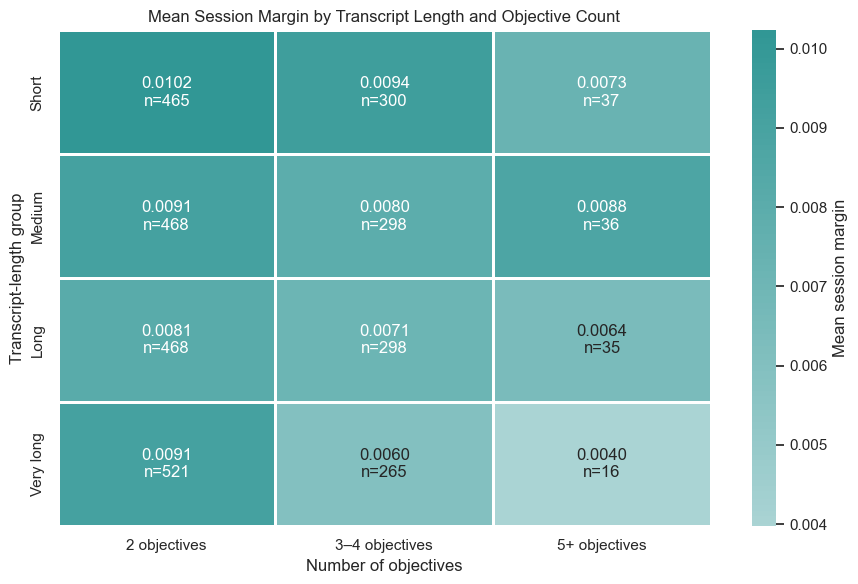

In [20]:
def plot_length_objective_heatmap(heatmap_summary, figures_dir):
    row_order = ["Short", "Medium", "Long", "Very long"]
    column_order = ["2 objectives", "3–4 objectives", "5+ objectives"]

    margin_matrix = heatmap_summary.pivot(index="transcript_length_group", columns="objective_count_group", values="Mean_session_margin").reindex(index=row_order, columns=column_order)
    count_matrix = heatmap_summary.pivot(index="transcript_length_group", columns="objective_count_group", values="Sessions").reindex(index=row_order, columns=column_order)
    annotations = margin_matrix.copy().astype(object)

    for row in row_order:
        for column in column_order:
            margin = margin_matrix.loc[row, column]
            count = count_matrix.loc[row, column]

            if pd.isna(margin):
                annotations.loc[row, column] = ""
            elif count < 10:
                annotations.loc[row, column] = f"{margin:.4f}\nn={int(count)} low"
            else:
                annotations.loc[row, column] = f"{margin:.4f}\nn={int(count)}"

    cmap = sns.blend_palette(["#E53E3E", "#F7FAFC", "#319795"], as_cmap=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.heatmap(margin_matrix, annot=annotations, fmt="", cmap=cmap, center=0, linewidths=1, linecolor="white", cbar_kws={"label": "Mean session margin"}, ax=ax)
    ax.set(title="Mean Session Margin by Transcript Length and Objective Count", xlabel="Number of objectives", ylabel="Transcript-length group")
    plt.tight_layout()
    plt.savefig(figures_dir / "transcript_length_objective_count_margin_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_length_objective_heatmap(length_objective_heatmap, figures_dir)

# Step 6 — Group-Wise Performance Analysis
This step evaluates whether the grouped-OOF baseline performs consistently across different response, session, objective, and transcript groups.  
The analysis will use the frozen five-fold OOF predictions produced by the primary `word_logistic` model.  
No new model will be trained and no probabilities will be recalibrated in this step.  
Overall performance can hide important weaknesses that affect only particular parts of the dataset.  
We will therefore compare Log Loss, AUROC, Brier Score, accuracy, false-positive rate, and false-negative rate across predefined groups.  
Positive-class and negative-class Log Loss will be reported separately to identify the main error direction.  
Group support, response share, and total loss contribution will also be measured.  
Response-weighted results will be supplemented with session-aware summaries where required.  
Group definitions will be created without using model performance to choose the boundaries.  
Small or single-class groups will be identified before their results are interpreted.  
Fold-level results will later be used to determine whether each subgroup pattern is stable.  
The analysis will first create an overall reference scorecard for the complete OOF population.  
Every later subgroup result will be compared with this fixed overall reference.  
The final outputs will identify reliable high-risk groups for manual review and future model improvement.

## 6.1 — Overall Reference Scorecard

This section creates the fixed performance reference for all later subgroup comparisons.  
The complete grouped-OOF population will be evaluated before any group is selected.  
The scorecard will report population size, label prevalence, probability quality, ranking quality, and classification errors.  
Positive-class and negative-class Log Loss will be calculated separately to identify the dominant error direction.  
High-confidence false positives use a probability threshold of `0.80`.  
High-confidence false negatives use a probability threshold of `0.20`.  
The same metrics will also be calculated independently for each OOF fold.  
The results will be saved in `06_group_analysis/00_reference/`.

In [21]:
step6_dir = new_analysis_root / "06_group_analysis"
reference_dir = step6_dir / "00_reference"

step6_dir.mkdir(parents=True, exist_ok=True)
reference_dir.mkdir(parents=True, exist_ok=True)

reference_data = oof.copy()

required_columns = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability"]
missing_columns = [column for column in required_columns if column not in reference_data.columns]

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

if not reference_data["response_id"].is_unique:
    raise ValueError("response_id is not unique in the OOF data.")

if reference_data["correct"].isna().any():
    raise ValueError("The target column contains missing values.")

if not reference_data["correct"].isin([0, 1]).all():
    raise ValueError("The target column contains values other than 0 and 1.")

if reference_data["probability"].isna().any():
    raise ValueError("The probability column contains missing values.")

if not reference_data["probability"].between(0, 1).all():
    raise ValueError("The probability column contains values outside the range 0 to 1.")

fold_values = sorted(reference_data["fold_id"].dropna().astype(int).unique().tolist())

if fold_values != [0, 1, 2, 3, 4]:
    raise ValueError(f"Unexpected OOF fold IDs: {fold_values}")

reference_data["probability"] = reference_data["probability"].clip(1e-15, 1 - 1e-15)
reference_data["hard_prediction"] = reference_data["probability"].ge(0.50).astype(int)
reference_data["sample_log_loss"] = -(reference_data["correct"] * np.log(reference_data["probability"]) + (1 - reference_data["correct"]) * np.log1p(-reference_data["probability"]))
reference_data["is_false_positive"] = reference_data["correct"].eq(0) & reference_data["hard_prediction"].eq(1)
reference_data["is_false_negative"] = reference_data["correct"].eq(1) & reference_data["hard_prediction"].eq(0)
reference_data["is_high_confidence_false_positive"] = reference_data["correct"].eq(0) & reference_data["probability"].ge(0.80)
reference_data["is_high_confidence_false_negative"] = reference_data["correct"].eq(1) & reference_data["probability"].le(0.20)

print(f"Reference responses: {len(reference_data):,}")
print(f"Reference sessions: {reference_data['session_id'].nunique():,}")
print(f"Reference objectives: {reference_data['objective_key'].nunique():,}")
print(f"OOF folds: {fold_values}")
print(f"Reference output: {reference_dir}")

Reference responses: 35,072
Reference sessions: 22,821
Reference objectives: 396
OOF folds: [0, 1, 2, 3, 4]
Reference output: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\00_reference


In [22]:
def calculate_reference_metrics(data):
    positive_data = data[data["correct"].eq(1)]
    negative_data = data[data["correct"].eq(0)]

    positive_count = len(positive_data)
    negative_count = len(negative_data)

    tn, fp, fn, tp = confusion_matrix(data["correct"], data["hard_prediction"], labels=[0, 1]).ravel()

    metrics = {}
    metrics["Responses"] = len(data)
    metrics["Sessions"] = data["session_id"].nunique()
    metrics["Objectives"] = data["objective_key"].nunique()
    metrics["Positive responses"] = positive_count
    metrics["Negative responses"] = negative_count
    metrics["Positive rate (%)"] = 100 * data["correct"].mean()
    metrics["Mean predicted probability"] = data["probability"].mean()
    metrics["Log Loss"] = log_loss(data["correct"], data["probability"], labels=[0, 1])
    metrics["Positive-class Log Loss"] = -np.log(positive_data["probability"]).mean() if positive_count > 0 else np.nan
    metrics["Negative-class Log Loss"] = -np.log1p(-negative_data["probability"]).mean() if negative_count > 0 else np.nan
    metrics["AUROC"] = roc_auc_score(data["correct"], data["probability"]) if positive_count > 0 and negative_count > 0 else np.nan
    metrics["Brier Score"] = brier_score_loss(data["correct"], data["probability"])
    metrics["Accuracy (%)"] = 100 * accuracy_score(data["correct"], data["hard_prediction"])
    metrics["False-positive rate (%)"] = 100 * fp / (fp + tn) if fp + tn > 0 else np.nan
    metrics["False-negative rate (%)"] = 100 * fn / (fn + tp) if fn + tp > 0 else np.nan
    metrics["High-confidence FP rate (%)"] = 100 * data["is_high_confidence_false_positive"].sum() / negative_count if negative_count > 0 else np.nan
    metrics["High-confidence FN rate (%)"] = 100 * data["is_high_confidence_false_negative"].sum() / positive_count if positive_count > 0 else np.nan

    return metrics


overall_metrics = calculate_reference_metrics(reference_data)

overall_reference = pd.DataFrame([[metric, value] for metric, value in overall_metrics.items()], columns=["Metric", "Value"])

overall_reference.to_csv(reference_dir / "overall_reference.csv", index=False)

display(overall_reference)

print("Overall reference scorecard saved.")

,Metric,Value
0,Responses,"35,072.0000"
1,Sessions,"22,821.0000"
2,Objectives,396.0000
3,Positive responses,"24,637.0000"
4,Negative responses,"10,435.0000"
5,Positive rate (%),70.2469
6,Mean predicted probability,0.7042
7,Log Loss,0.5555
8,Positive-class Log Loss,0.3270
9,Negative-class Log Loss,1.0950


Overall reference scorecard saved.


In [23]:
fold_rows = []

for fold_id, fold_data in reference_data.groupby("fold_id", sort=True):
    fold_metrics = calculate_reference_metrics(fold_data)
    fold_metrics["Fold"] = int(fold_id)
    fold_rows.append(fold_metrics)

fold_reference = pd.DataFrame(fold_rows)

fold_columns = ["Fold"] + [column for column in fold_reference.columns if column != "Fold"]
fold_reference = fold_reference[fold_columns]

fold_reference.to_csv(reference_dir / "fold_reference.csv", index=False)

display(fold_reference)

print(f"Fold reference rows: {len(fold_reference):,}")
print("Fold-level reference scorecard saved.")

metric_definitions = "# Step 6.1 Metric Definitions\n\n- **Responses:** Number of response–objective rows in the evaluated population.\n- **Sessions:** Number of unique tutoring sessions.\n- **Objectives:** Number of unique normalized learning objectives.\n- **Positive rate:** Percentage of responses with target equal to 1.\n- **Mean predicted probability:** Average predicted probability of the positive class.\n- **Log Loss:** Mean probability loss across all responses; lower values are better.\n- **Positive-class Log Loss:** Mean Log Loss calculated only for actual positive responses.\n- **Negative-class Log Loss:** Mean Log Loss calculated only for actual negative responses.\n- **AUROC:** Ability to rank positive responses above negative responses.\n- **Brier Score:** Mean squared difference between probability and target; lower values are better.\n- **Accuracy:** Percentage of correct predictions using a probability threshold of 0.50.\n- **False-positive rate:** Percentage of actual negative responses predicted as positive.\n- **False-negative rate:** Percentage of actual positive responses predicted as negative.\n- **High-confidence FP rate:** Percentage of actual negative responses receiving probability greater than or equal to 0.80.\n- **High-confidence FN rate:** Percentage of actual positive responses receiving probability less than or equal to 0.20.\n"

with open(reference_dir / "metric_definitions.md", "w", encoding="utf-8") as file:
    file.write(metric_definitions)

print(f"Overall reference: {reference_dir / 'overall_reference.csv'}")
print(f"Fold reference: {reference_dir / 'fold_reference.csv'}")
print(f"Metric definitions: {reference_dir / 'metric_definitions.md'}")
print("Step 6.1 completed.")

,Fold,Responses,Sessions,Objectives,Positive responses,Negative responses,Positive rate (%),Mean predicted probability,Log Loss,Positive-class Log Loss,Negative-class Log Loss,AUROC,Brier Score,Accuracy (%),False-positive rate (%),False-negative rate (%),High-confidence FP rate (%),High-confidence FN rate (%)
0,0,6980,4590,277,4890,2090,70.0573,0.6999,0.5577,0.3337,1.0818,0.7003,0.1881,71.8338,79.4258,6.2577,12.2010,0.0204
1,1,7018,4569,279,4905,2113,69.8917,0.7075,0.5614,0.3225,1.1160,0.6917,0.1893,71.9293,82.3474,4.6891,14.7657,0.0000
2,2,7019,4570,274,4989,2030,71.0785,0.7038,0.5469,0.3281,1.0848,0.7065,0.1834,72.5887,81.2315,5.5121,12.5123,0.0000
3,3,7011,4541,285,4905,2106,69.9615,0.7045,0.5547,0.3249,1.0900,0.7073,0.1867,72.1580,80.8167,5.0968,13.2953,0.0204
4,4,7044,4551,278,4948,2096,70.2442,0.7051,0.5565,0.3256,1.1017,0.6980,0.1872,72.3878,81.3931,4.8302,13.5019,0.0000


Fold reference rows: 5
Fold-level reference scorecard saved.
Overall reference: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\00_reference\overall_reference.csv
Fold reference: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\00_reference\fold_reference.csv
Metric definitions: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\00_reference\metric_definitions.md
Step 6.1 completed.


## 6.2 — Transcript-Length Group Analysis

This section examines whether the grouped-OOF baseline performs differently across sessions of different transcript lengths. The primary length variable is `total_words`, representing the total number of words in a tutoring session. If this variable is unavailable, it will be calculated from `transcript_text`.

Quartile boundaries will be calculated from one row per unique session. This prevents sessions containing several learning objectives from receiving extra influence when the groups are created. The model predictions and target labels will not be used to determine the boundaries.

Sessions will be divided into four ordered groups: `Short`, `Medium`, `Long`, and `Very long`. Each group will be evaluated using Log Loss, positive-class Log Loss, negative-class Log Loss, AUROC, false-positive rate, mean predicted probability, response share, and total loss share.

The analysis will also calculate the same metrics independently across the five OOF folds. A transcript-length pattern will be considered more reliable when its direction remains consistent across several folds.

Secondary variables—`total_turns`, `session_duration_minutes`, `objective_words`, and `responses_per_session`—will be analysed separately. No combined transcript-length score will be created.

Finally, transcript length will be linked with the Step 5 mixed-session metrics to examine whether longer sessions are associated with lower objective margins, higher collapse rates, or higher session Log Loss.

The results will describe associations only. A worse result for longer transcripts will not prove that transcript length directly causes model failure.

In [24]:
import json

def analyze_transcript_length_groups(reference_data, step6_dir, step5_session_metrics=None):
    transcript_length_dir = step6_dir / "transcript_length"
    figures_dir = transcript_length_dir / "figures"
    secondary_dir = transcript_length_dir / "secondary_variables"

    transcript_length_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)
    secondary_dir.mkdir(parents=True, exist_ok=True)

    data = reference_data.copy()

    required_columns = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability", "sample_log_loss"]
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Required columns are missing: {missing_columns}")

    if "total_words" not in data.columns:
        if "transcript_text" not in data.columns:
            raise ValueError("Neither total_words nor transcript_text is available.")
        data["total_words"] = data["transcript_text"].fillna("").str.split().str.len()

    data["total_words"] = pd.to_numeric(data["total_words"], errors="coerce")

    if data["total_words"].isna().any():
        raise ValueError("total_words contains missing or non-numeric values.")

    if data["total_words"].lt(0).any():
        raise ValueError("total_words contains negative values.")

    session_word_conflict = data.groupby("session_id")["total_words"].nunique(dropna=False).max()

    if session_word_conflict > 1:
        raise ValueError("total_words is not consistent within every session.")

    session_length_data = data[["session_id", "total_words"]].drop_duplicates("session_id").sort_values("session_id").reset_index(drop=True)
    length_group_order = ["Short", "Medium", "Long", "Very long"]
    session_length_data["transcript_length_group"], quartile_bins = pd.qcut(session_length_data["total_words"], q=4, labels=length_group_order, retbins=True)

    data = data.merge(session_length_data[["session_id", "transcript_length_group"]], on="session_id", how="left", validate="many_to_one")

    if data["transcript_length_group"].isna().any():
        raise ValueError("Some responses did not receive a transcript-length group.")

    threshold_table = session_length_data.groupby("transcript_length_group", observed=True).agg(Sessions=("session_id", "nunique"), Minimum_total_words=("total_words", "min"), Maximum_total_words=("total_words", "max"), Median_total_words=("total_words", "median")).reset_index()

    thresholds = {"grouping_unit": "unique session", "grouping_variable": "total_words", "quartile_boundaries": [float(value) for value in quartile_bins], "groups": {str(row["transcript_length_group"]): {"minimum_total_words": float(row["Minimum_total_words"]), "maximum_total_words": float(row["Maximum_total_words"]), "median_total_words": float(row["Median_total_words"]), "sessions": int(row["Sessions"])} for _, row in threshold_table.iterrows()}}

    with open(transcript_length_dir / "transcript_length_thresholds.json", "w", encoding="utf-8") as file:
        json.dump(thresholds, file, indent=2)

    def summarize_groups(grouped_data, group_column, group_order):
        total_responses = len(grouped_data)
        total_loss = grouped_data["sample_log_loss"].sum()
        overall_loss = grouped_data["sample_log_loss"].mean()
        summary_rows = []

        for group_name in group_order:
            group_data = grouped_data[grouped_data[group_column].eq(group_name)].copy()

            if group_data.empty:
                continue

            metrics = calculate_reference_metrics(group_data)
            group_loss = group_data["sample_log_loss"].sum()

            summary_rows.append({"Length group": group_name, "Responses": metrics["Responses"], "Sessions": metrics["Sessions"], "Objectives": metrics["Objectives"], "Positive rate (%)": metrics["Positive rate (%)"], "Mean probability": metrics["Mean predicted probability"], "Log Loss": metrics["Log Loss"], "Positive LL": metrics["Positive-class Log Loss"], "Negative LL": metrics["Negative-class Log Loss"], "AUROC": metrics["AUROC"], "Brier Score": metrics["Brier Score"], "Accuracy (%)": metrics["Accuracy (%)"], "FPR (%)": metrics["False-positive rate (%)"], "FNR (%)": metrics["False-negative rate (%)"], "High-confidence FP rate (%)": metrics["High-confidence FP rate (%)"], "High-confidence FN rate (%)": metrics["High-confidence FN rate (%)"], "Response share (%)": 100 * len(group_data) / total_responses, "Loss share (%)": 100 * group_loss / total_loss, "Log Loss difference from overall": metrics["Log Loss"] - overall_loss})

        summary = pd.DataFrame(summary_rows)
        summary["Length group"] = pd.Categorical(summary["Length group"], categories=group_order, ordered=True)
        summary = summary.sort_values("Length group").reset_index(drop=True)

        return summary

    transcript_length_summary = summarize_groups(data, "transcript_length_group", length_group_order)
    transcript_length_summary.to_csv(transcript_length_dir / "transcript_length_summary.csv", index=False)

    fold_parts = []

    for fold_id, fold_data in data.groupby("fold_id", sort=True):
        fold_summary = summarize_groups(fold_data, "transcript_length_group", length_group_order)
        fold_reference_loss = fold_data["sample_log_loss"].mean()
        fold_summary["Fold"] = int(fold_id)
        fold_summary["Fold reference Log Loss"] = fold_reference_loss
        fold_summary["Difference from fold reference"] = fold_summary["Log Loss"] - fold_reference_loss
        fold_parts.append(fold_summary)

    fold_metrics = pd.concat(fold_parts, ignore_index=True)
    fold_metrics["Length group"] = pd.Categorical(fold_metrics["Length group"], categories=length_group_order, ordered=True)
    fold_metrics = fold_metrics.sort_values(["Fold", "Length group"]).reset_index(drop=True)
    fold_metrics.to_csv(transcript_length_dir / "transcript_length_fold_metrics.csv", index=False)

    fold_stability = fold_metrics.groupby("Length group", observed=True).agg(Folds=("Fold", "nunique"), Mean_fold_Log_Loss=("Log Loss", "mean"), Fold_Log_Loss_SD=("Log Loss", "std"), Minimum_fold_Log_Loss=("Log Loss", "min"), Maximum_fold_Log_Loss=("Log Loss", "max"), Folds_worse_than_reference=("Difference from fold reference", lambda values: int(values.gt(0).sum())), Mean_difference_from_reference=("Difference from fold reference", "mean")).reset_index()
    fold_stability["Stable high-risk group"] = fold_stability["Folds_worse_than_reference"].ge(4)
    fold_stability.to_csv(transcript_length_dir / "transcript_length_fold_stability.csv", index=False)

    if "objective_words" not in data.columns and "learning_objective" in data.columns:
        data["objective_words"] = data["learning_objective"].fillna("").str.split().str.len()

    if "responses_per_session" not in data.columns:
        data["responses_per_session"] = data.groupby("session_id")["response_id"].transform("size")

    secondary_settings = [{"variable": "total_turns", "entity_key": "session_id", "group_column": "total_turns_group", "labels": ["Few turns", "Moderate turns", "Many turns", "Very many turns"]}, {"variable": "session_duration_minutes", "entity_key": "session_id", "group_column": "session_duration_group", "labels": ["Short duration", "Medium duration", "Long duration", "Very long duration"]}, {"variable": "objective_words", "entity_key": "objective_key", "group_column": "objective_length_group", "labels": ["Short objective", "Medium objective", "Long objective", "Very long objective"]}, {"variable": "responses_per_session", "entity_key": "session_id", "group_column": "response_count_group", "labels": ["Few responses", "Moderate responses", "Many responses", "Very many responses"]}]
    secondary_parts = []

    for setting in secondary_settings:
        variable = setting["variable"]
        entity_key = setting["entity_key"]
        group_column = setting["group_column"]
        group_order = setting["labels"]

        if variable not in data.columns:
            print(f"Skipped {variable}: column was not available.")
            continue

        data[variable] = pd.to_numeric(data[variable], errors="coerce")
        available_data = data[[entity_key, variable]].dropna().copy()

        if available_data.empty:
            print(f"Skipped {variable}: no usable values were available.")
            continue

        consistency_check = available_data.groupby(entity_key)[variable].nunique(dropna=False).max()

        if consistency_check > 1:
            print(f"Skipped {variable}: values were not consistent within {entity_key}.")
            continue

        entity_data = available_data.drop_duplicates(entity_key).sort_values(entity_key).reset_index(drop=True)

        if len(entity_data) < 4 or entity_data[variable].nunique() < 2:
            print(f"Skipped {variable}: insufficient variation for quartile groups.")
            continue

        entity_data[group_column] = pd.qcut(entity_data[variable].rank(method="first"), q=4, labels=group_order)
        secondary_group_data = data.merge(entity_data[[entity_key, group_column]], on=entity_key, how="left", validate="many_to_one")
        secondary_group_data = secondary_group_data[secondary_group_data[group_column].notna()].copy()

        variable_summary = summarize_groups(secondary_group_data, group_column, group_order)
        variable_summary = variable_summary.rename(columns={"Length group": "Group"})
        variable_summary.insert(0, "Variable", variable)
        variable_summary.to_csv(secondary_dir / f"{variable}_summary.csv", index=False)

        variable_thresholds = entity_data.groupby(group_column, observed=True).agg(Entities=(entity_key, "nunique"), Minimum_value=(variable, "min"), Maximum_value=(variable, "max"), Median_value=(variable, "median")).reset_index()
        variable_thresholds.to_csv(secondary_dir / f"{variable}_thresholds.csv", index=False)

        secondary_parts.append(variable_summary)

    if secondary_parts:
        secondary_summary = pd.concat(secondary_parts, ignore_index=True)
        secondary_summary.to_csv(secondary_dir / "secondary_length_summary.csv", index=False)
    else:
        secondary_summary = pd.DataFrame()

    if step5_session_metrics is not None:
        step5_data = step5_session_metrics.copy()
        step5_data = step5_data.drop(columns=["transcript_length_group"], errors="ignore")

        if not step5_data["session_id"].is_unique:
            raise ValueError("Step 5 session metrics contain duplicate session IDs.")

        required_step5_columns = ["session_id", "session_margin", "session_log_loss", "session_pairwise_accuracy"]
        missing_step5_columns = [column for column in required_step5_columns if column not in step5_data.columns]

        if missing_step5_columns:
            raise ValueError(f"Step 5 session metrics are missing required columns: {missing_step5_columns}")

        if "is_session_collapse" not in step5_data.columns:
            step5_data["is_session_collapse"] = step5_data["session_margin"].abs().lt(0.02)

        if "is_session_reversed" not in step5_data.columns:
            step5_data["is_session_reversed"] = step5_data["session_margin"].lt(0)

        step5_data = step5_data.merge(session_length_data[["session_id", "transcript_length_group"]], on="session_id", how="left", validate="one_to_one")
        step5_data = step5_data[step5_data["transcript_length_group"].notna()].copy()

        step5_linkage = step5_data.groupby("transcript_length_group", observed=True).agg(Mixed_sessions=("session_id", "size"), Mean_session_margin=("session_margin", "mean"), Median_session_margin=("session_margin", "median"), Mean_pairwise_accuracy=("session_pairwise_accuracy", "mean"), Collapse_rate=("is_session_collapse", "mean"), Reversal_rate=("is_session_reversed", "mean"), Mean_session_Log_Loss=("session_log_loss", "mean")).reset_index()
        step5_linkage["Mean pairwise accuracy (%)"] = 100 * step5_linkage.pop("Mean_pairwise_accuracy")
        step5_linkage["Collapse rate (%)"] = 100 * step5_linkage.pop("Collapse_rate")
        step5_linkage["Reversal rate (%)"] = 100 * step5_linkage.pop("Reversal_rate")
        step5_linkage.to_csv(transcript_length_dir / "transcript_length_step5_linkage.csv", index=False)
    else:
        step5_linkage = pd.DataFrame()
        print("Step 5 linkage was skipped because session_metrics was not available.")

    results = {"data": data, "summary": transcript_length_summary, "fold_metrics": fold_metrics, "fold_stability": fold_stability, "threshold_table": threshold_table, "secondary_summary": secondary_summary, "step5_linkage": step5_linkage, "length_group_order": length_group_order, "output_dir": transcript_length_dir, "figures_dir": figures_dir}

    return results



step5_session_metrics = session_metrics.copy() if "session_metrics" in globals() else None

transcript_length_results = analyze_transcript_length_groups(reference_data, step6_dir, step5_session_metrics)

transcript_length_summary = transcript_length_results["summary"]
transcript_length_fold_metrics = transcript_length_results["fold_metrics"]
transcript_length_fold_stability = transcript_length_results["fold_stability"]
transcript_length_threshold_table = transcript_length_results["threshold_table"]
secondary_length_summary = transcript_length_results["secondary_summary"]
transcript_length_step5_linkage = transcript_length_results["step5_linkage"]

display(transcript_length_threshold_table)

display_columns = ["Length group", "Responses", "Sessions", "Positive rate (%)", "Mean probability", "Log Loss", "Positive LL", "Negative LL", "AUROC", "FPR (%)", "Response share (%)", "Loss share (%)"]
display(transcript_length_summary[display_columns])

display(transcript_length_fold_stability)

if not secondary_length_summary.empty:
    secondary_display_columns = ["Variable", "Group", "Responses", "Sessions", "Positive rate (%)", "Log Loss", "Positive LL", "Negative LL", "AUROC", "FPR (%)"]
    display(secondary_length_summary[secondary_display_columns])

if not transcript_length_step5_linkage.empty:
    display(transcript_length_step5_linkage)

print(f"Transcript-length groups analysed: {len(transcript_length_summary):,}")
print(f"Output folder: {transcript_length_results['output_dir']}")

,transcript_length_group,Sessions,Minimum_total_words,Maximum_total_words,Median_total_words
0,Short,5706,39,3045,"2,580.0000"
1,Medium,5709,3046,3681,"3,377.0000"
2,Long,5704,3682,4270,"3,961.0000"
3,Very long,5702,4271,8663,"4,701.0000"


,Length group,Responses,Sessions,Positive rate (%),Mean probability,Log Loss,Positive LL,Negative LL,AUROC,FPR (%),Response share (%),Loss share (%)
0,Short,8729,5706,68.8739,0.6885,0.5743,0.3514,1.0676,0.6838,79.7939,24.8888,25.7347
1,Medium,8972,5709,69.2711,0.7030,0.5605,0.3270,1.0870,0.7054,81.0664,25.5817,25.8157
2,Long,8755,5704,70.7367,0.7036,0.5502,0.3273,1.0890,0.7030,79.8985,24.9629,24.7255
3,Very long,8616,5702,72.1565,0.7219,0.5364,0.3030,1.1414,0.7083,83.6599,24.5666,23.7241


,Length group,Folds,Mean_fold_Log_Loss,Fold_Log_Loss_SD,Minimum_fold_Log_Loss,Maximum_fold_Log_Loss,Folds_worse_than_reference,Mean_difference_from_reference,Stable high-risk group
0,Short,5,0.5743,0.0082,0.5607,0.5831,5,0.0189,True
1,Medium,5,0.5608,0.0128,0.5460,0.5782,3,0.0053,False
2,Long,5,0.5503,0.0149,0.5367,0.5693,2,-0.0052,False
3,Very long,5,0.5363,0.0132,0.5196,0.5523,0,-0.0191,False


,Variable,Group,Responses,Sessions,Positive rate (%),Log Loss,Positive LL,Negative LL,AUROC,FPR (%)
0,total_turns,Few turns,8702,5706,70.8458,0.5511,0.3250,1.1006,0.6975,81.3559
1,total_turns,Moderate turns,9027,5705,70.4110,0.5583,0.3180,1.1301,0.6935,83.6391
2,total_turns,Many turns,8921,5705,70.6535,0.5527,0.3241,1.1031,0.7007,81.7800
3,total_turns,Very many turns,8422,5705,69.0216,0.5598,0.3419,1.0452,0.7115,77.3476
4,session_duration_minutes,Short duration,7759,5706,69.2744,0.5595,0.3354,1.0646,0.7053,79.4883
5,session_duration_minutes,Medium duration,8744,5705,69.9680,0.5620,0.3311,1.1001,0.6940,81.8355
6,session_duration_minutes,Long duration,9459,5705,70.6523,0.5538,0.3238,1.1076,0.6989,82.1326
7,session_duration_minutes,Very long duration,9110,5705,70.9221,0.5475,0.3193,1.1039,0.7045,80.5210
8,objective_words,Short objective,6815,5810,73.9545,0.5335,0.3178,1.1458,0.6807,86.2535
9,objective_words,Medium objective,8224,7619,61.5759,0.6097,0.3795,0.9787,0.7039,71.9304


,transcript_length_group,Mixed_sessions,Mean_session_margin,Median_session_margin,Mean_session_Log_Loss,Mean pairwise accuracy (%),Collapse rate (%),Reversal rate (%)
0,Short,783,0.0098,0.0060,0.7755,67.6862,69.9872,30.9068
1,Medium,821,0.0087,0.0053,0.7733,67.6553,74.0560,30.8161
2,Long,803,0.0077,0.0046,0.7813,66.6155,76.2142,32.6276
3,Very long,800,0.0080,0.0042,0.7996,68.4625,79.3750,30.7500


Transcript-length groups analysed: 4
Output folder: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\transcript_length


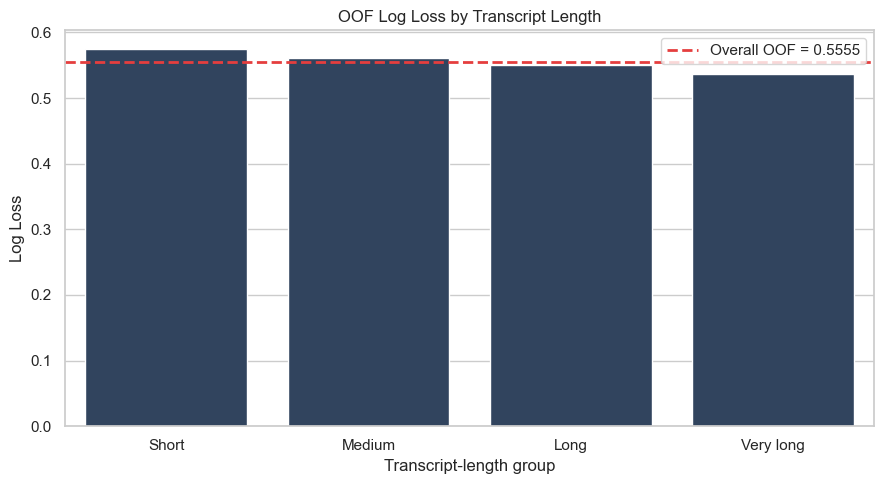

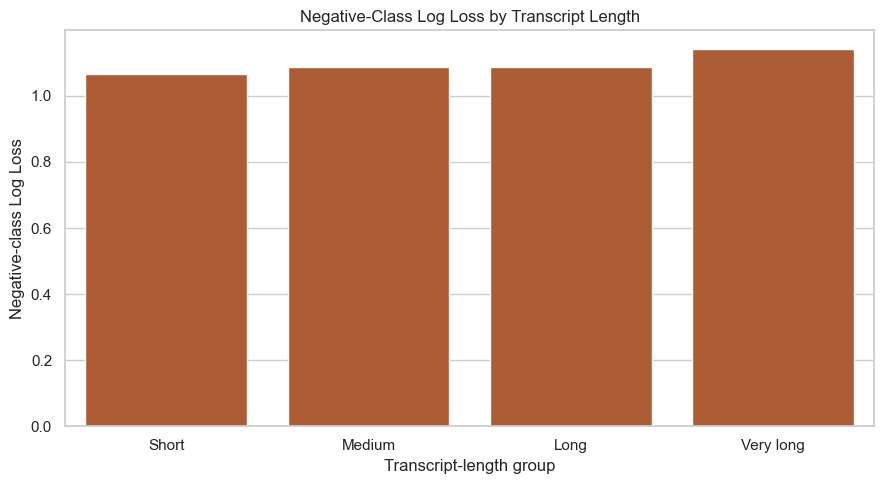

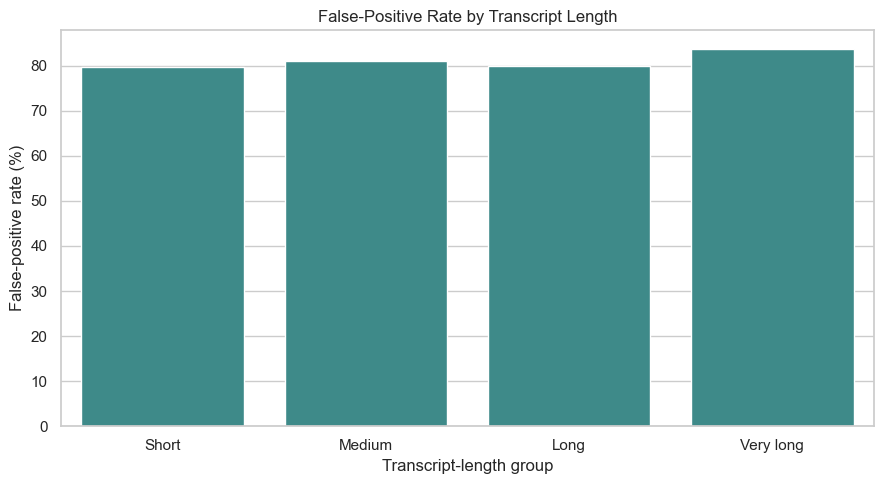

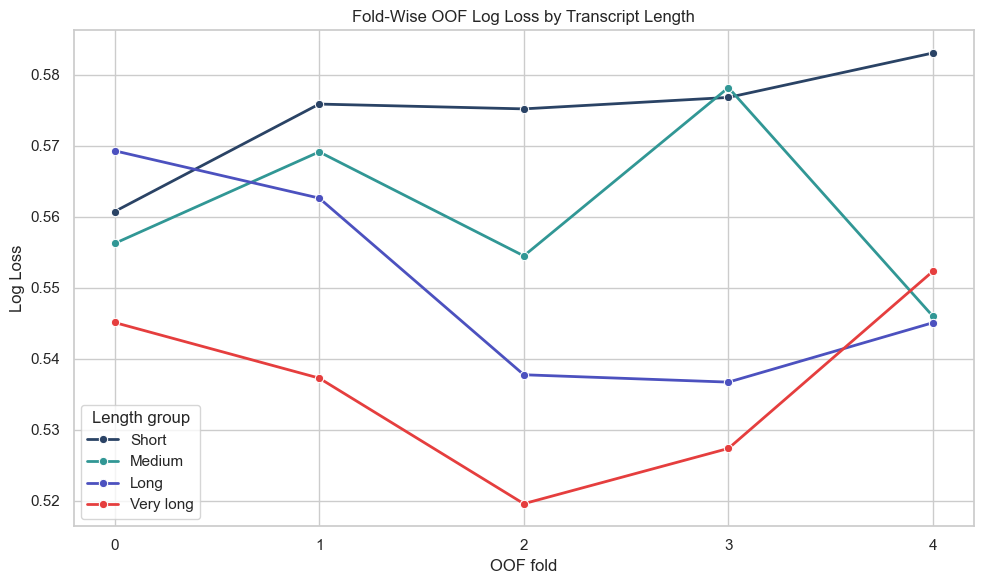

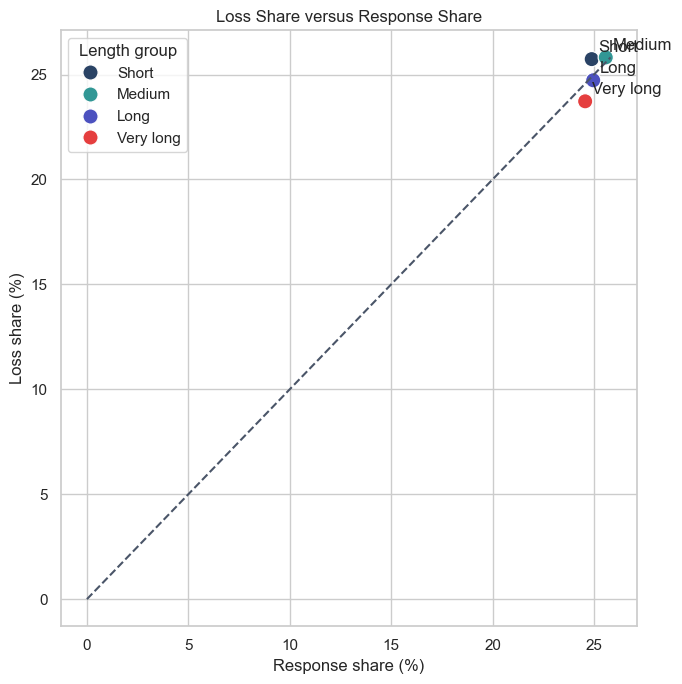

Transcript-length figures saved in: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\transcript_length\figures


In [25]:
def plot_transcript_length_analysis(results):
    summary = results["summary"].copy()
    fold_metrics = results["fold_metrics"].copy()
    group_order = results["length_group_order"]
    figures_dir = results["figures_dir"]

    deep_blue, teal, coral = "#2A4365", "#319795", "#E53E3E"
    slate_blue, terracotta, charcoal = "#4C51BF", "#C05621", "#4A5568"
    sns.set_theme(style="whitegrid")

    overall_log_loss = reference_data["sample_log_loss"].mean()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=summary, x="Length group", y="Log Loss", order=group_order, color=deep_blue, ax=ax)
    ax.axhline(overall_log_loss, color=coral, linestyle="--", linewidth=2, label=f"Overall OOF = {overall_log_loss:.4f}")
    ax.set(title="OOF Log Loss by Transcript Length", xlabel="Transcript-length group", ylabel="Log Loss")
    ax.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / "log_loss_by_transcript_length.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=summary, x="Length group", y="Negative LL", order=group_order, color=terracotta, ax=ax)
    ax.set(title="Negative-Class Log Loss by Transcript Length", xlabel="Transcript-length group", ylabel="Negative-class Log Loss")
    plt.tight_layout()
    plt.savefig(figures_dir / "negative_log_loss_by_transcript_length.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=summary, x="Length group", y="FPR (%)", order=group_order, color=teal, ax=ax)
    ax.set(title="False-Positive Rate by Transcript Length", xlabel="Transcript-length group", ylabel="False-positive rate (%)")
    plt.tight_layout()
    plt.savefig(figures_dir / "false_positive_rate_by_transcript_length.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=fold_metrics, x="Fold", y="Log Loss", hue="Length group", hue_order=group_order, marker="o", linewidth=2, palette=[deep_blue, teal, slate_blue, coral], ax=ax)
    ax.set(title="Fold-Wise OOF Log Loss by Transcript Length", xlabel="OOF fold", ylabel="Log Loss")
    ax.set_xticks(sorted(fold_metrics["Fold"].unique()))
    ax.legend(title="Length group")
    plt.tight_layout()
    plt.savefig(figures_dir / "foldwise_log_loss_by_transcript_length.png", dpi=300, bbox_inches="tight")
    plt.show()

    maximum_share = max(summary["Response share (%)"].max(), summary["Loss share (%)"].max())
    fig, ax = plt.subplots(figsize=(7, 7))
    sns.scatterplot(data=summary, x="Response share (%)", y="Loss share (%)", hue="Length group", hue_order=group_order, palette=[deep_blue, teal, slate_blue, coral], s=120, ax=ax)
    ax.plot([0, maximum_share], [0, maximum_share], color=charcoal, linestyle="--", linewidth=1.5)

    for _, row in summary.iterrows():
        ax.annotate(str(row["Length group"]), (row["Response share (%)"], row["Loss share (%)"]), xytext=(5, 5), textcoords="offset points")

    ax.set(title="Loss Share versus Response Share", xlabel="Response share (%)", ylabel="Loss share (%)")
    ax.legend(title="Length group")
    plt.tight_layout()
    plt.savefig(figures_dir / "loss_share_vs_response_share.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Transcript-length figures saved in: {figures_dir}")


plot_transcript_length_analysis(transcript_length_results)

### 6.2 — Interpretation Guide

The primary comparison should begin with the overall Log Loss of the four transcript-length groups. If the `Very long` group has a higher Log Loss than the `Short` group, the class-specific losses should be examined next.

A larger increase in `Negative LL` would indicate that the transcript-length difference is mainly driven by incorrect objectives receiving probabilities that are too high. This interpretation should be checked against the false-positive rate and mean predicted probability.

`Response share` and `Loss share` should also be compared. When a group's loss share is larger than its response share, the group contributes a disproportionate amount of total OOF loss.

The fold-stability table should be used to determine whether the result is repeated across the five OOF folds. A group that performs worse than its fold reference in at least four folds provides stronger evidence than a difference produced by only one fold.

The secondary-variable results should be interpreted independently. For example, a total-turn pattern should not automatically be treated as evidence about session duration or objective length.

The Step 5 linkage applies only to mixed-label sessions. It shows whether transcript length is associated with objective margin, pairwise ranking, collapse, reversal, and session Log Loss within that difficult population.

An appropriate conclusion would state that longer transcripts are **associated with** higher or lower OOF loss. The analysis cannot establish that transcript length directly causes model failure.

## 6.3 — Objective-Frequency Group Analysis

This section examines whether the baseline performs differently on common and low-support learning objectives. The primary frequency variable will be the number of objective examples available to the model during the training portion of each OOF fold.

Global objective support will be retained for descriptive purposes. However, it will not be used as the primary generalisation measure because it includes responses belonging to the evaluated fold.

For response \(i\), the fold-safe training support is:

$$
\operatorname{TrainSupport}_i
=
\sum_{j:f_j \ne f_i}
\mathbb{1}(o_j=o_i)
$$

The fixed support groups are `Unseen`, `Very rare`, `Rare`, `Medium support`, and `Common`. These boundaries will be created before reviewing model performance.

The analysis will compare Log Loss, class-specific Log Loss, AUROC, false-positive rate, mean probability, response share, and total loss share across the support groups. Fold-safe objective prevalence will also be calculated as an analysis variable, but it will not be used to modify model predictions.

Objective-level macro performance will be compared with the response-weighted overall result. This will show whether the overall score is dominated by frequently occurring objectives.

Objective text length will be analysed separately. Low-support objectives will not be treated as reliable worst-objective findings. Therefore, sufficient-support and low-support objective lists will be reported separately.

In [26]:
def analyze_objective_frequency_groups(input_data, step6_dir):
    objective_frequency_dir = step6_dir / "objective_frequency"
    figures_dir = objective_frequency_dir / "figures"

    objective_frequency_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    data = input_data.copy()

    required_columns = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability"]
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Required columns are missing: {missing_columns}")

    if not data["response_id"].is_unique:
        raise ValueError("response_id is not unique in the OOF data.")

    if data["objective_key"].isna().any():
        raise ValueError("objective_key contains missing values.")

    if data["fold_id"].isna().any():
        raise ValueError("fold_id contains missing values.")

    data["probability"] = data["probability"].clip(1e-15, 1 - 1e-15)

    if "hard_prediction" not in data.columns:
        data["hard_prediction"] = data["probability"].ge(0.50).astype(int)

    if "sample_log_loss" not in data.columns:
        data["sample_log_loss"] = -(data["correct"] * np.log(data["probability"]) + (1 - data["correct"]) * np.log1p(-data["probability"]))

    if "is_high_confidence_false_positive" not in data.columns:
        data["is_high_confidence_false_positive"] = data["correct"].eq(0) & data["probability"].ge(0.80)

    if "is_high_confidence_false_negative" not in data.columns:
        data["is_high_confidence_false_negative"] = data["correct"].eq(1) & data["probability"].le(0.20)

    data["global_objective_support"] = data.groupby("objective_key")["response_id"].transform("size")
    data["global_objective_positive_count"] = data.groupby("objective_key")["correct"].transform("sum")
    data["fold_objective_support"] = data.groupby(["objective_key", "fold_id"])["response_id"].transform("size")
    data["fold_objective_positive_count"] = data.groupby(["objective_key", "fold_id"])["correct"].transform("sum")
    data["train_objective_support"] = data["global_objective_support"] - data["fold_objective_support"]
    data["train_objective_positive_count"] = data["global_objective_positive_count"] - data["fold_objective_positive_count"]
    data["train_objective_negative_count"] = data["train_objective_support"] - data["train_objective_positive_count"]
    data["train_objective_prevalence"] = np.where(data["train_objective_support"].gt(0), data["train_objective_positive_count"] / data["train_objective_support"], np.nan)

    support_group_order = ["Unseen", "Very rare", "Rare", "Medium support", "Common"]
    support_bins = [-1, 0, 9, 49, 199, np.inf]
    data["objective_support_group"] = pd.cut(data["train_objective_support"], bins=support_bins, labels=support_group_order, ordered=True)

    if data["objective_support_group"].isna().any():
        raise ValueError("Some responses did not receive an objective-support group.")

    if "objective_words" not in data.columns:
        if "learning_objective" not in data.columns:
            raise ValueError("Neither objective_words nor learning_objective is available.")
        data["objective_words"] = data["learning_objective"].fillna("").str.split().str.len()

    data["objective_words"] = pd.to_numeric(data["objective_words"], errors="coerce")

    objective_text_data = data.groupby("objective_key", as_index=False).agg(objective_words=("objective_words", "median"))
    objective_text_data["objective_length_code"], objective_length_bins = pd.qcut(objective_text_data["objective_words"], q=4, labels=False, retbins=True, duplicates="drop")

    objective_length_labels = ["Short objective", "Medium objective", "Long objective", "Very long objective"]
    objective_length_group_count = len(objective_length_bins) - 1
    objective_length_active_labels = objective_length_labels[:objective_length_group_count]
    objective_length_label_map = {group_number: objective_length_active_labels[group_number] for group_number in range(objective_length_group_count)}

    objective_text_data["objective_length_group"] = objective_text_data["objective_length_code"].map(objective_length_label_map)
    objective_text_data["objective_length_group"] = pd.Categorical(objective_text_data["objective_length_group"], categories=objective_length_active_labels, ordered=True)

    data = data.merge(objective_text_data[["objective_key", "objective_length_group"]], on="objective_key", how="left", validate="many_to_one")

    support_output_columns = ["response_id", "session_id", "objective_key", "fold_id", "correct", "probability", "global_objective_support", "fold_objective_support", "train_objective_support", "train_objective_positive_count", "train_objective_negative_count", "train_objective_prevalence", "objective_support_group", "objective_words", "objective_length_group"]

    if "learning_objective" in data.columns:
        support_output_columns.insert(3, "learning_objective")

    if "transcript_length_group" in data.columns:
        support_output_columns.append("transcript_length_group")

    data[support_output_columns].to_parquet(objective_frequency_dir / "objective_support_by_fold.parquet", index=False)

    def summarize_groups(grouped_data, group_column, group_order):
        total_responses = len(grouped_data)
        total_loss = grouped_data["sample_log_loss"].sum()
        overall_loss = grouped_data["sample_log_loss"].mean()
        summary_rows = []

        for group_name in group_order:
            group_data = grouped_data[grouped_data[group_column].eq(group_name)].copy()

            if group_data.empty:
                continue

            metrics = calculate_reference_metrics(group_data)
            group_loss = group_data["sample_log_loss"].sum()

            summary_rows.append({"Group": group_name, "Responses": metrics["Responses"], "Sessions": metrics["Sessions"], "Objectives": metrics["Objectives"], "Positive responses": metrics["Positive responses"], "Negative responses": metrics["Negative responses"], "Positive rate (%)": metrics["Positive rate (%)"], "Mean probability": metrics["Mean predicted probability"], "Mean train support": group_data["train_objective_support"].mean(), "Median train support": group_data["train_objective_support"].median(), "Mean train prevalence": group_data["train_objective_prevalence"].mean(), "Log Loss": metrics["Log Loss"], "Positive LL": metrics["Positive-class Log Loss"], "Negative LL": metrics["Negative-class Log Loss"], "AUROC": metrics["AUROC"], "Brier Score": metrics["Brier Score"], "Accuracy (%)": metrics["Accuracy (%)"], "FPR (%)": metrics["False-positive rate (%)"], "FNR (%)": metrics["False-negative rate (%)"], "High-confidence FP rate (%)": metrics["High-confidence FP rate (%)"], "High-confidence FN rate (%)": metrics["High-confidence FN rate (%)"], "Response share (%)": 100 * len(group_data) / total_responses, "Loss share (%)": 100 * group_loss / total_loss, "Log Loss difference from overall": metrics["Log Loss"] - overall_loss})

        summary = pd.DataFrame(summary_rows)
        summary["Group"] = pd.Categorical(summary["Group"], categories=group_order, ordered=True)
        summary = summary.sort_values("Group").reset_index(drop=True)

        return summary

    support_group_summary = summarize_groups(data, "objective_support_group", support_group_order)
    support_group_summary.to_csv(objective_frequency_dir / "objective_support_group_summary.csv", index=False)

    objective_length_summary = summarize_groups(data, "objective_length_group", objective_length_active_labels)
    objective_length_summary.to_csv(objective_frequency_dir / "objective_text_length_summary.csv", index=False)

    support_thresholds = {"support_variable": "fold-safe training support", "support_groups": {"Unseen": "0", "Very rare": "1-9", "Rare": "10-49", "Medium support": "50-199", "Common": "200+"}, "objective_length_boundaries": [float(value) for value in objective_length_bins], "objective_length_groups": objective_length_active_labels, "sufficient_objective_rule": {"minimum_responses": 50, "minimum_sessions": 20}}

    with open(objective_frequency_dir / "objective_frequency_thresholds.json", "w", encoding="utf-8") as file:
        json.dump(support_thresholds, file, indent=2)

    fold_summary_parts = []

    for fold_id, fold_data in data.groupby("fold_id", sort=True):
        fold_summary = summarize_groups(fold_data, "objective_support_group", support_group_order)
        fold_reference_loss = fold_data["sample_log_loss"].mean()
        fold_summary["Fold"] = int(fold_id)
        fold_summary["Fold reference Log Loss"] = fold_reference_loss
        fold_summary["Difference from fold reference"] = fold_summary["Log Loss"] - fold_reference_loss
        fold_summary_parts.append(fold_summary)

    support_fold_metrics = pd.concat(fold_summary_parts, ignore_index=True)
    support_fold_metrics["Group"] = pd.Categorical(support_fold_metrics["Group"], categories=support_group_order, ordered=True)
    support_fold_metrics = support_fold_metrics.sort_values(["Fold", "Group"]).reset_index(drop=True)
    support_fold_metrics.to_csv(objective_frequency_dir / "objective_support_fold_metrics.csv", index=False)

    rare_objective_fold_stability = support_fold_metrics.groupby("Group", observed=True).agg(Folds=("Fold", "nunique"), Mean_fold_Log_Loss=("Log Loss", "mean"), Fold_Log_Loss_SD=("Log Loss", "std"), Minimum_fold_Log_Loss=("Log Loss", "min"), Maximum_fold_Log_Loss=("Log Loss", "max"), Folds_worse_than_reference=("Difference from fold reference", lambda values: int(values.gt(0).sum())), Mean_difference_from_reference=("Difference from fold reference", "mean"), Mean_fold_AUROC=("AUROC", "mean"), Mean_fold_FPR=("FPR (%)", "mean")).reset_index()
    rare_objective_fold_stability["Stable high-risk group"] = rare_objective_fold_stability["Folds_worse_than_reference"].ge(4)
    rare_objective_fold_stability.to_csv(objective_frequency_dir / "rare_objective_fold_stability.csv", index=False)

    objective_rows = []

    for objective_key, objective_data in data.groupby("objective_key", sort=False):
        objective_metrics = calculate_reference_metrics(objective_data)
        learning_objective = objective_data["learning_objective"].iloc[0] if "learning_objective" in objective_data.columns else ""

        objective_rows.append({"objective_key": objective_key, "learning_objective": learning_objective, "Responses": objective_metrics["Responses"], "Sessions": objective_metrics["Sessions"], "Folds": objective_data["fold_id"].nunique(), "Positive responses": objective_metrics["Positive responses"], "Negative responses": objective_metrics["Negative responses"], "Positive rate (%)": objective_metrics["Positive rate (%)"], "Mean probability": objective_metrics["Mean predicted probability"], "Log Loss": objective_metrics["Log Loss"], "Positive LL": objective_metrics["Positive-class Log Loss"], "Negative LL": objective_metrics["Negative-class Log Loss"], "AUROC": objective_metrics["AUROC"], "Brier Score": objective_metrics["Brier Score"], "Accuracy (%)": objective_metrics["Accuracy (%)"], "FPR (%)": objective_metrics["False-positive rate (%)"], "FNR (%)": objective_metrics["False-negative rate (%)"], "Global support": objective_data["global_objective_support"].iloc[0], "Minimum train support": objective_data["train_objective_support"].min(), "Median train support": objective_data["train_objective_support"].median(), "Maximum train support": objective_data["train_objective_support"].max(), "Mean train prevalence": objective_data["train_objective_prevalence"].mean(), "Objective words": objective_data["objective_words"].median()})

    objective_level_performance = pd.DataFrame(objective_rows)
    objective_level_performance["Headline support eligible"] = objective_level_performance["Responses"].ge(50) & objective_level_performance["Sessions"].ge(20)
    objective_level_performance = objective_level_performance.sort_values(["Log Loss", "Responses"], ascending=[False, False]).reset_index(drop=True)
    objective_level_performance.to_parquet(objective_frequency_dir / "objective_level_performance.parquet", index=False)

    response_weighted_metrics = calculate_reference_metrics(data)
    sufficient_objectives = objective_level_performance[objective_level_performance["Headline support eligible"]].copy()

    macro_scorecard_rows = [{"Evaluation": "Response-weighted OOF", "Units": len(data), "Log Loss": response_weighted_metrics["Log Loss"], "Positive LL": response_weighted_metrics["Positive-class Log Loss"], "Negative LL": response_weighted_metrics["Negative-class Log Loss"], "AUROC": response_weighted_metrics["AUROC"], "Brier Score": response_weighted_metrics["Brier Score"], "FPR (%)": response_weighted_metrics["False-positive rate (%)"], "FNR (%)": response_weighted_metrics["False-negative rate (%)"]}, {"Evaluation": "Objective-macro all objectives", "Units": len(objective_level_performance), "Log Loss": objective_level_performance["Log Loss"].mean(), "Positive LL": objective_level_performance["Positive LL"].mean(), "Negative LL": objective_level_performance["Negative LL"].mean(), "AUROC": objective_level_performance["AUROC"].mean(), "Brier Score": objective_level_performance["Brier Score"].mean(), "FPR (%)": objective_level_performance["FPR (%)"].mean(), "FNR (%)": objective_level_performance["FNR (%)"].mean()}, {"Evaluation": "Objective-macro sufficient support", "Units": len(sufficient_objectives), "Log Loss": sufficient_objectives["Log Loss"].mean(), "Positive LL": sufficient_objectives["Positive LL"].mean(), "Negative LL": sufficient_objectives["Negative LL"].mean(), "AUROC": sufficient_objectives["AUROC"].mean(), "Brier Score": sufficient_objectives["Brier Score"].mean(), "FPR (%)": sufficient_objectives["FPR (%)"].mean(), "FNR (%)": sufficient_objectives["FNR (%)"].mean()}]

    objective_macro_scorecard = pd.DataFrame(macro_scorecard_rows)
    objective_macro_scorecard.to_csv(objective_frequency_dir / "objective_macro_scorecard.csv", index=False)

    worst_supported_objectives = objective_level_performance[objective_level_performance["Headline support eligible"]].sort_values(["Log Loss", "Responses"], ascending=[False, False]).head(50).reset_index(drop=True)
    low_support_objectives = objective_level_performance[~objective_level_performance["Headline support eligible"]].sort_values(["Log Loss", "Responses"], ascending=[False, False]).head(100).reset_index(drop=True)

    worst_supported_objectives.to_csv(objective_frequency_dir / "worst_supported_objectives.csv", index=False)
    low_support_objectives.to_csv(objective_frequency_dir / "low_support_objectives.csv", index=False)

    if "transcript_length_group" in data.columns:
        interaction_rows = []

        for support_group in support_group_order:
            for length_group in ["Short", "Medium", "Long", "Very long"]:
                interaction_data = data[data["objective_support_group"].eq(support_group) & data["transcript_length_group"].eq(length_group)].copy()

                if interaction_data.empty:
                    continue

                interaction_metrics = calculate_reference_metrics(interaction_data)
                interaction_rows.append({"Objective support group": support_group, "Transcript length group": length_group, "Responses": interaction_metrics["Responses"], "Sessions": interaction_metrics["Sessions"], "Positive rate (%)": interaction_metrics["Positive rate (%)"], "Log Loss": interaction_metrics["Log Loss"], "Positive LL": interaction_metrics["Positive-class Log Loss"], "Negative LL": interaction_metrics["Negative-class Log Loss"], "AUROC": interaction_metrics["AUROC"], "FPR (%)": interaction_metrics["False-positive rate (%)"]})

        support_length_interaction = pd.DataFrame(interaction_rows)
        support_length_interaction.to_csv(objective_frequency_dir / "objective_support_by_transcript_length.csv", index=False)
    else:
        support_length_interaction = pd.DataFrame()
        print("Transcript-length interaction was skipped because transcript_length_group was unavailable.")

    results = {"data": data, "support_summary": support_group_summary, "objective_length_summary": objective_length_summary, "fold_metrics": support_fold_metrics, "fold_stability": rare_objective_fold_stability, "objective_performance": objective_level_performance, "macro_scorecard": objective_macro_scorecard, "worst_supported": worst_supported_objectives, "low_support": low_support_objectives, "support_length_interaction": support_length_interaction, "support_group_order": support_group_order, "objective_length_order": objective_length_active_labels, "output_dir": objective_frequency_dir, "figures_dir": figures_dir}

    return results


objective_frequency_input = transcript_length_results["data"].copy() if "transcript_length_results" in globals() else reference_data.copy()

objective_frequency_results = analyze_objective_frequency_groups(objective_frequency_input, step6_dir)

objective_support_summary = objective_frequency_results["support_summary"]
objective_text_length_summary = objective_frequency_results["objective_length_summary"]
objective_support_fold_metrics = objective_frequency_results["fold_metrics"]
rare_objective_fold_stability = objective_frequency_results["fold_stability"]
objective_level_performance = objective_frequency_results["objective_performance"]
objective_macro_scorecard = objective_frequency_results["macro_scorecard"]
worst_supported_objectives = objective_frequency_results["worst_supported"]
low_support_objectives = objective_frequency_results["low_support"]
objective_support_length_interaction = objective_frequency_results["support_length_interaction"]

support_display_columns = ["Group", "Responses", "Sessions", "Objectives", "Positive rate (%)", "Mean probability", "Mean train support", "Mean train prevalence", "Log Loss", "Positive LL", "Negative LL", "AUROC", "FPR (%)", "Response share (%)", "Loss share (%)"]

display(objective_support_summary[support_display_columns])
display(rare_objective_fold_stability)
display(objective_macro_scorecard)

objective_length_display_columns = ["Group", "Responses", "Sessions", "Objectives", "Positive rate (%)", "Log Loss", "Positive LL", "Negative LL", "AUROC", "FPR (%)"]
display(objective_text_length_summary[objective_length_display_columns])

worst_display_columns = ["objective_key", "learning_objective", "Responses", "Sessions", "Positive rate (%)", "Log Loss", "Positive LL", "Negative LL", "AUROC", "FPR (%)", "Minimum train support", "Median train support"]
display(worst_supported_objectives[worst_display_columns].head(20))

display(low_support_objectives[worst_display_columns].head(20))

if not objective_support_length_interaction.empty:
    display(objective_support_length_interaction)

print(f"Objectives analysed: {len(objective_level_performance):,}")
print(f"Sufficient-support objectives: {len(worst_supported_objectives):,}")
print(f"Output folder: {objective_frequency_results['output_dir']}")

,Group,Responses,Sessions,Objectives,Positive rate (%),Mean probability,Mean train support,Mean train prevalence,Log Loss,Positive LL,Negative LL,AUROC,FPR (%),Response share (%),Loss share (%)
0,Unseen,83,69,74,65.0602,0.6966,0.0000,NaN,0.6768,0.3678,1.2521,0.5109,100.0000,0.2367,0.2883
1,Very rare,650,486,143,72.1538,0.7242,4.4323,0.7187,0.5750,0.3142,1.2507,0.6077,92.2652,1.8533,1.9185
2,Rare,2315,1904,88,65.6156,0.6741,29.2238,0.6572,0.6101,0.3765,1.0560,0.6561,85.0503,6.6007,7.2504
3,Medium support,9142,7415,69,68.4642,0.6872,137.4734,0.6867,0.5720,0.3504,1.0530,0.6944,78.5987,26.0664,26.8406
4,Common,22882,15546,53,71.3924,0.7135,471.2162,0.7134,0.5423,0.3136,1.1132,0.7083,81.2405,65.2429,63.7022


,Group,Folds,Mean_fold_Log_Loss,Fold_Log_Loss_SD,Minimum_fold_Log_Loss,Maximum_fold_Log_Loss,Folds_worse_than_reference,Mean_difference_from_reference,Mean_fold_AUROC,Mean_fold_FPR,Stable high-risk group
0,Unseen,5,0.6932,0.1363,0.5883,0.9130,5,0.1378,0.5597,100.0000,True
1,Very rare,5,0.5764,0.0429,0.5173,0.6191,4,0.0209,0.6008,92.1982,True
2,Rare,5,0.6097,0.0166,0.5849,0.6253,5,0.0542,0.6593,84.9700,True
3,Medium support,5,0.5720,0.0083,0.5663,0.5866,5,0.0166,0.6944,78.6036,True
4,Common,5,0.5424,0.0043,0.5360,0.5479,0,-0.0131,0.7083,81.2592,False


,Evaluation,Units,Log Loss,Positive LL,Negative LL,AUROC,Brier Score,FPR (%),FNR (%)
0,Response-weighted OOF,35072,0.5555,0.3270,1.0950,0.7007,0.1870,81.0446,5.2766
1,Objective-macro all objectives,396,0.5936,0.3542,1.2241,0.5903,0.2023,90.5790,4.3896
2,Objective-macro sufficient support,120,0.5630,0.3673,1.2021,0.6035,0.1902,87.1223,7.9706


,Group,Responses,Sessions,Objectives,Positive rate (%),Log Loss,Positive LL,Negative LL,AUROC,FPR (%)
0,Short objective,8282,7039,112,72.9534,0.5391,0.3164,1.1398,0.6869,84.8214
1,Medium objective,13275,11106,146,65.2203,0.5926,0.3584,1.0318,0.6983,76.5216
2,Long objective,5576,5140,55,69.6915,0.5799,0.3628,1.0790,0.6599,84.5562
3,Very long objective,7939,6707,83,76.2187,0.4933,0.2696,1.2105,0.7176,84.4809


,objective_key,learning_objective,Responses,Sessions,Positive rate (%),Log Loss,Positive LL,Negative LL,AUROC,FPR (%),Minimum train support,Median train support
0,9186ab71bca51495,Multiplying using long multiplication.,53,53,41.5094,0.8452,0.4803,1.1042,0.4164,93.5484,38,39.0000
1,951e16f1eb34351b,"Ordering numbers up to 1,000.",65,65,43.0769,0.8028,0.4380,1.0789,0.5386,91.8919,46,51.0000
2,c4ab547260b34888,Subtracting money using the column method.,73,73,36.9863,0.7570,0.6066,0.8453,0.5306,67.3913,55,58.0000
3,6650841ba1e8882a,Solving real-life problems with remainders.,505,505,41.1881,0.7467,0.6151,0.8388,0.5243,64.3098,384,409.0000
4,60a93ea53259e110,Multiplying using arrays and the area model.,96,96,45.8333,0.7465,0.3729,1.0627,0.6608,82.6923,71,77.0000
5,222d10557e1308dc,"Ordering numbers up to 1,000,000.",764,764,48.5602,0.7427,0.5089,0.9635,0.5533,70.4835,606,613.0000
6,e38596255dfaac5a,Comparing and ordering fractions.,499,499,42.4850,0.7415,0.5117,0.9112,0.5863,68.2927,390,400.0000
7,78c9ad2f34ec95cf,Adding money using the column method.,87,87,44.8276,0.7334,0.6842,0.7734,0.4850,58.3333,62,64.0000
8,0050a906abfca885,Solving problems involving fractions.,240,240,30.8333,0.7332,0.6921,0.7515,0.5346,51.2048,183,191.0000
9,75454aa5dde9ef1f,Calculating with Fractions in Context.,85,85,44.7059,0.7306,0.5710,0.8597,0.5207,68.0851,62,68.0000


,objective_key,learning_objective,Responses,Sessions,Positive rate (%),Log Loss,Positive LL,Negative LL,AUROC,FPR (%),Minimum train support,Median train support
0,9ceb05603385212b,Finding prime factors,1,1,0.0000,1.9950,NaN,1.9950,NaN,100.0000,0,0.0000
1,f974d6ffaeabf2c2,Working with Vector Geometry,2,2,0.0000,1.9216,NaN,1.9216,NaN,100.0000,1,1.0000
2,93d125cad0c95abc,Solving calculations in the correct order,1,1,0.0000,1.9007,NaN,1.9007,NaN,100.0000,0,0.0000
3,e692716abc6ca2fa,Solving problems involving remainders,1,1,0.0000,1.8754,NaN,1.8754,NaN,100.0000,0,0.0000
4,b58d34d6f6a4f028,Using BIDMAS to solve calculations,2,2,0.0000,1.8278,NaN,1.8278,NaN,100.0000,1,1.0000
5,4d048f132d85c34a,Subtracting 4-digit numbers using the column method,1,1,0.0000,1.7655,NaN,1.7655,NaN,100.0000,0,0.0000
6,94791ff7d8810d24,Reflecting shapes and patterns in a line of symmetry,1,1,0.0000,1.4912,NaN,1.4912,NaN,100.0000,0,0.0000
7,e8f1c77609f72cd2,Making and describing linear sequences.,3,3,0.0000,1.4318,NaN,1.4318,NaN,100.0000,1,1.0000
8,02acd1d3d38545a2,Calculating with Fractions,1,1,0.0000,1.3410,NaN,1.3410,NaN,100.0000,0,0.0000
9,560837cd21288822,Drawing and Interpreting Charts and Tables,1,1,0.0000,1.2967,NaN,1.2967,NaN,100.0000,0,0.0000


,Objective support group,Transcript length group,Responses,Sessions,Positive rate (%),Log Loss,Positive LL,Negative LL,AUROC,FPR (%)
0,Unseen,Short,41,31,65.8537,0.6875,0.3805,1.2795,0.4683,100.0000
1,Unseen,Medium,21,20,66.6667,0.6381,0.3358,1.2428,0.5306,100.0000
2,Unseen,Long,17,14,64.7059,0.6732,0.3621,1.2436,0.5303,100.0000
3,Unseen,Very long,4,4,50.0000,0.7847,0.4518,1.1176,0.2500,100.0000
4,Very rare,Short,224,166,76.3393,0.5520,0.3191,1.3034,0.5553,92.4528
5,Very rare,Medium,181,129,70.7182,0.5727,0.3170,1.1903,0.6456,86.7925
6,Very rare,Long,144,108,66.6667,0.6377,0.3162,1.2807,0.5725,93.7500
7,Very rare,Very long,101,83,73.2673,0.5407,0.2954,1.2128,0.6952,100.0000
8,Rare,Short,683,561,66.4714,0.6179,0.3801,1.0895,0.6270,86.4629
9,Rare,Medium,610,508,61.8033,0.6217,0.3813,1.0106,0.6807,84.1202


Objectives analysed: 396
Sufficient-support objectives: 50
Output folder: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\objective_frequency


C:\Users\USER\AppData\Local\Temp\ipykernel_23720\1547286117.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=support_summary, x="Group", y="Log Loss", order=support_order, palette=support_palette, ax=ax)


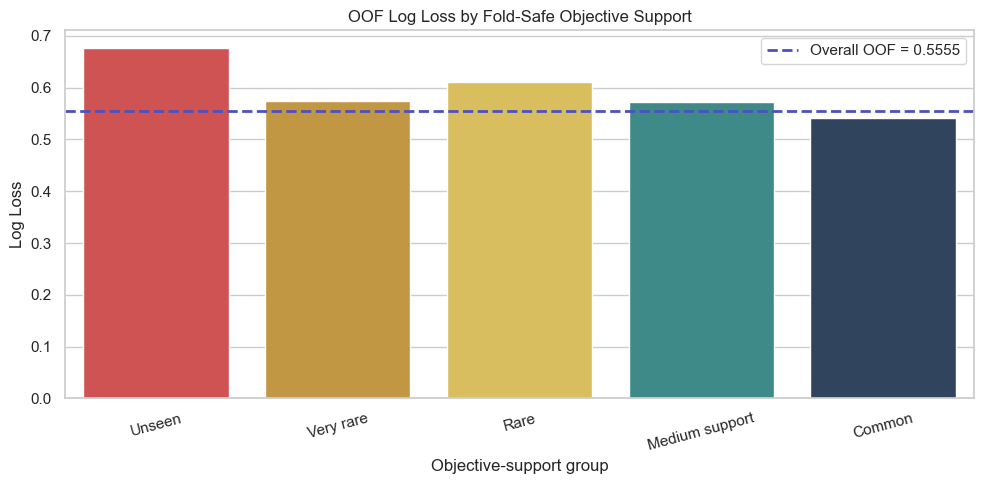

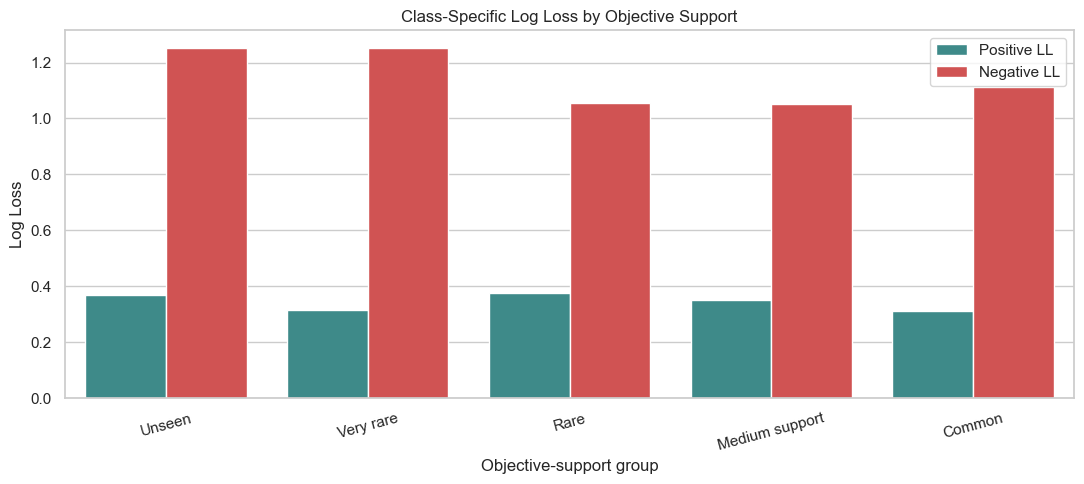

C:\Users\USER\AppData\Local\Temp\ipykernel_23720\1547286117.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=support_summary, x="Group", y="AUROC", order=support_order, palette=support_palette, ax=ax)


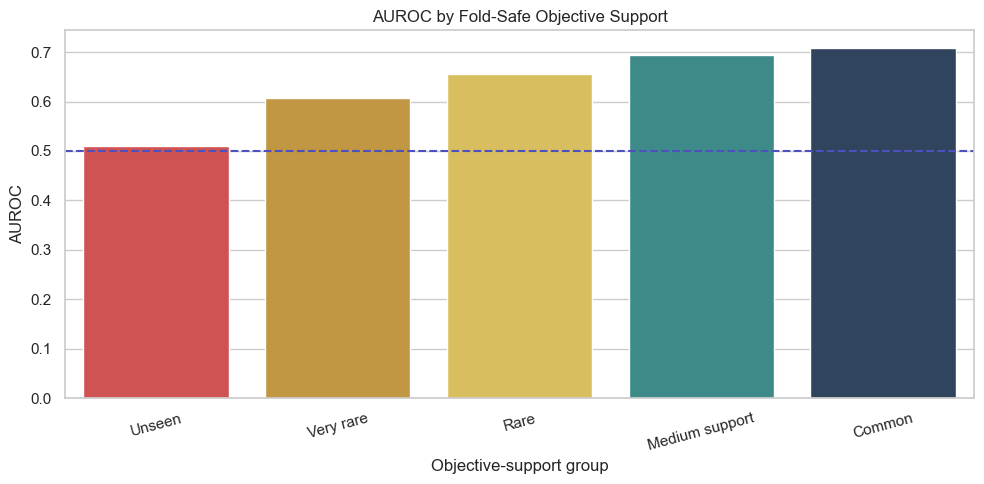

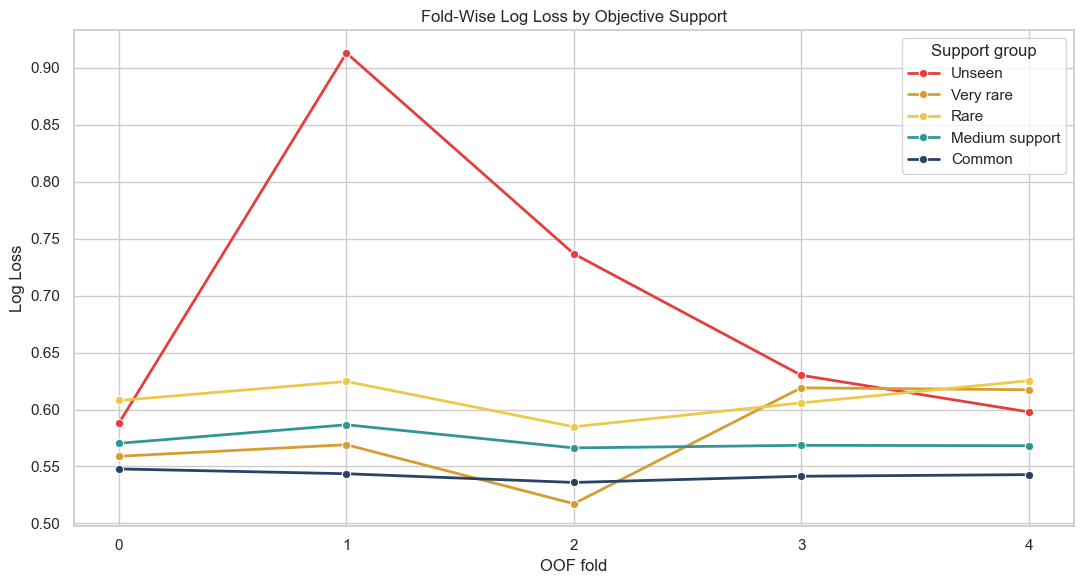

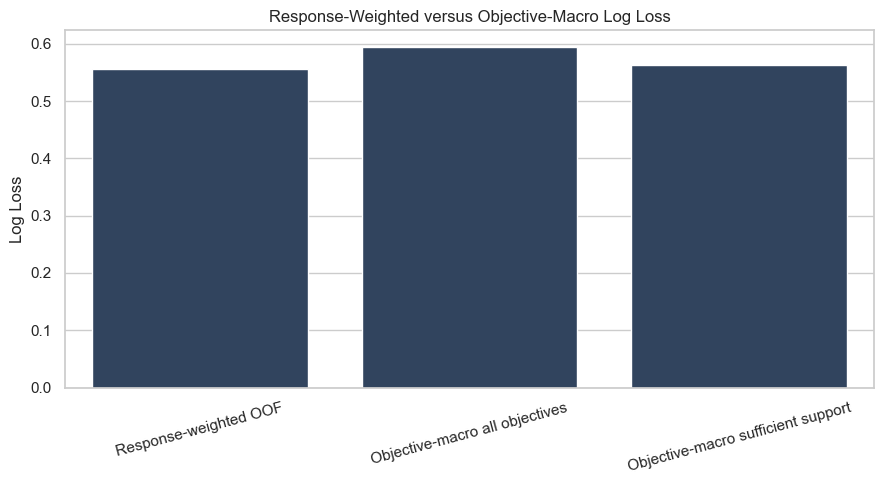

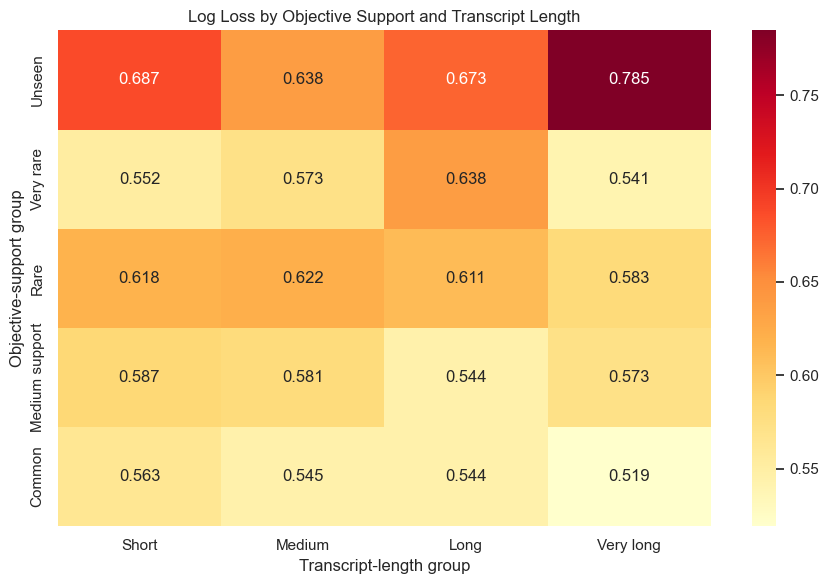

Objective-frequency figures saved in: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\objective_frequency\figures


In [27]:
def plot_objective_frequency_analysis(results):
    support_summary = results["support_summary"].copy()
    fold_metrics = results["fold_metrics"].copy()
    macro_scorecard = results["macro_scorecard"].copy()
    interaction_data = results["support_length_interaction"].copy()
    support_order = results["support_group_order"]
    figures_dir = results["figures_dir"]

    deep_blue, teal, amber, coral, slate = "#2A4365", "#319795", "#D69E2E", "#E53E3E", "#4C51BF"
    support_palette = [coral, amber, "#ECC94B", teal, deep_blue]
    sns.set_theme(style="whitegrid")

    overall_log_loss = reference_data["sample_log_loss"].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=support_summary, x="Group", y="Log Loss", order=support_order, palette=support_palette, ax=ax)
    ax.axhline(overall_log_loss, color=slate, linestyle="--", linewidth=2, label=f"Overall OOF = {overall_log_loss:.4f}")
    ax.set(title="OOF Log Loss by Fold-Safe Objective Support", xlabel="Objective-support group", ylabel="Log Loss")
    ax.tick_params(axis="x", rotation=15)
    ax.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / "log_loss_by_objective_support.png", dpi=300, bbox_inches="tight")
    plt.show()

    class_loss_data = support_summary[["Group", "Positive LL", "Negative LL"]].melt(id_vars="Group", var_name="Loss type", value_name="Log Loss")
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=class_loss_data, x="Group", y="Log Loss", hue="Loss type", order=support_order, palette=[teal, coral], ax=ax)
    ax.set(title="Class-Specific Log Loss by Objective Support", xlabel="Objective-support group", ylabel="Log Loss")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="")
    plt.tight_layout()
    plt.savefig(figures_dir / "class_log_loss_by_objective_support.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=support_summary, x="Group", y="AUROC", order=support_order, palette=support_palette, ax=ax)
    ax.axhline(0.50, color=slate, linestyle="--", linewidth=1.5)
    ax.set(title="AUROC by Fold-Safe Objective Support", xlabel="Objective-support group", ylabel="AUROC")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(figures_dir / "auroc_by_objective_support.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.lineplot(data=fold_metrics, x="Fold", y="Log Loss", hue="Group", hue_order=support_order, marker="o", linewidth=2, palette=support_palette, ax=ax)
    ax.set(title="Fold-Wise Log Loss by Objective Support", xlabel="OOF fold", ylabel="Log Loss")
    ax.set_xticks(sorted(fold_metrics["Fold"].unique()))
    ax.legend(title="Support group")
    plt.tight_layout()
    plt.savefig(figures_dir / "foldwise_log_loss_by_objective_support.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=macro_scorecard, x="Evaluation", y="Log Loss", color=deep_blue, ax=ax)
    ax.set(title="Response-Weighted versus Objective-Macro Log Loss", xlabel="", ylabel="Log Loss")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(figures_dir / "response_weighted_vs_objective_macro.png", dpi=300, bbox_inches="tight")
    plt.show()

    if not interaction_data.empty:
        interaction_table = interaction_data.pivot(index="Objective support group", columns="Transcript length group", values="Log Loss")
        interaction_table = interaction_table.reindex(index=support_order, columns=["Short", "Medium", "Long", "Very long"])

        fig, ax = plt.subplots(figsize=(9, 6))
        sns.heatmap(interaction_table, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
        ax.set(title="Log Loss by Objective Support and Transcript Length", xlabel="Transcript-length group", ylabel="Objective-support group")
        plt.tight_layout()
        plt.savefig(figures_dir / "objective_support_transcript_length_heatmap.png", dpi=300, bbox_inches="tight")
        plt.show()

    print(f"Objective-frequency figures saved in: {figures_dir}")


plot_objective_frequency_analysis(objective_frequency_results)

### 6.3 — Interpretation Guide

The primary comparison should begin with the fold-safe objective-support groups. The `Unseen`, `Very rare`, and `Rare` groups represent objectives for which the corresponding OOF model had little or no training support.

A higher Log Loss in these groups would indicate weaker probability generalisation for low-support objectives. AUROC should then be examined to determine whether the problem also affects positive–negative ranking.

Positive-class and negative-class Log Loss must be compared separately. If negative-class loss increases more strongly, rare objectives are mainly associated with incorrect objectives receiving probabilities that are too high. If positive-class loss increases more strongly, the model may be assigning probabilities that are too low to correct rare objectives.

The fold-stability table should be used to determine whether the same support-group pattern appears across multiple folds. A result that appears in four or five folds is more reliable than a difference produced by only one fold.

The objective-macro score should be compared with the response-weighted OOF score. A substantially worse objective-macro result would indicate that frequently occurring objectives make the overall baseline appear stronger than its performance across objectives of equal importance.

The transcript-length interaction is secondary. If rare objectives perform particularly poorly in very-long sessions, the combination may represent a concentrated high-risk group requiring both semantic objective representation and objective-conditioned context selection.

The `worst_supported_objectives.csv` file contains objectives with enough observations for more reliable comparison. The `low_support_objectives.csv` file is descriptive only. A high loss for an objective with very few responses should not be treated as strong evidence.

Any final conclusion should describe objective support as being **associated with** performance differences. This analysis does not prove that low frequency directly causes model failure.

## 6.4 — Transcript-Noise Proxy Analysis

This section examines whether baseline performance changes across structural characteristics that may indicate noisy, fragmented, or speaker-imbalanced transcripts. The dataset does not contain manually verified transcript-noise labels. Therefore, all variables in this section will be treated as **noise proxies**, not confirmed measures of transcript quality.

The primary proxies are `background_turn_ratio`, `turns_per_minute`, `speaker_switch_rate`, `student_short_turn_ratio`, `longest_tutor_streak_ratio`, and `longest_student_streak_ratio`.

Each proxy will be analysed separately. A primary composite noise score will not be used because the variables may represent different conversational behaviours. For example, frequent speaker switching may indicate healthy interaction or noisy alternation, while long tutor streaks may indicate tutor dominance rather than recording noise.

Continuous proxies will normally be divided into `Low`, `Medium`, `High`, and `Very high` session groups using performance-blind quartiles. When a proxy contains a substantial number of exact zeros, the groups will instead be `Zero`, `Low non-zero`, `Medium`, and `High`.

The analysis will compare Log Loss, positive-class Log Loss, negative-class Log Loss, AUROC, false-positive rate, mean probability, response share, and total loss share. Fold-level results will be used to examine whether each pattern is stable across the five grouped-OOF folds.

A secondary length-adjusted comparison will subtract the average loss of the corresponding transcript-length group. This will show whether a proxy remains associated with excess loss after broad transcript-length differences are considered.

All findings will remain descriptive. A high proxy group may be associated with worse OOF performance, but this analysis cannot prove that transcript noise directly causes model failure.

In [28]:
import json

def analyze_transcript_noise_groups(input_data, step6_dir):
    transcript_noise_dir = step6_dir / "transcript_noise"
    figures_dir = transcript_noise_dir / "figures"

    transcript_noise_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    data = input_data.copy()

    required_columns = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability"]
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Required columns are missing: {missing_columns}")

    if not data["response_id"].is_unique:
        raise ValueError("response_id is not unique in the analysis data.")

    data["probability"] = data["probability"].clip(1e-15, 1 - 1e-15)

    if "hard_prediction" not in data.columns:
        data["hard_prediction"] = data["probability"].ge(0.50).astype(int)

    if "sample_log_loss" not in data.columns:
        data["sample_log_loss"] = -(data["correct"] * np.log(data["probability"]) + (1 - data["correct"]) * np.log1p(-data["probability"]))

    if "is_high_confidence_false_positive" not in data.columns:
        data["is_high_confidence_false_positive"] = data["correct"].eq(0) & data["probability"].ge(0.80)

    if "is_high_confidence_false_negative" not in data.columns:
        data["is_high_confidence_false_negative"] = data["correct"].eq(1) & data["probability"].le(0.20)

    proxy_config = {
        "background_turn_ratio": {"family": "Background turns", "output": "background_turn_ratio_summary.csv"},
        "turns_per_minute": {"family": "Turn rate", "output": "turn_rate_summary.csv"},
        "student_short_turn_ratio": {"family": "Turn rate", "output": "turn_rate_summary.csv"},
        "speaker_switch_rate": {"family": "Speaker switching", "output": "speaker_switch_summary.csv"},
        "longest_tutor_streak_ratio": {"family": "Speaker streak", "output": "streak_summary.csv"},
        "longest_student_streak_ratio": {"family": "Speaker streak", "output": "streak_summary.csv"}
    }

    minimum_sessions = 50
    availability_rows = []
    group_definitions = {}
    summary_parts = []
    fold_parts = []

    def summarize_proxy_groups(grouped_data, proxy, group_order):
        working_data = grouped_data.copy()
        total_responses = len(working_data)
        total_loss = working_data["sample_log_loss"].sum()
        overall_loss = working_data["sample_log_loss"].mean()

        if "transcript_length_group" in working_data.columns:
            length_reference = working_data.groupby("transcript_length_group", observed=True)["sample_log_loss"].mean()
            negative_length_reference = working_data[working_data["correct"].eq(0)].groupby("transcript_length_group", observed=True)["sample_log_loss"].mean()
            working_data["length_reference_loss"] = working_data["transcript_length_group"].map(length_reference).astype(float)
            working_data["negative_length_reference_loss"] = working_data["transcript_length_group"].map(negative_length_reference).astype(float)
            working_data["length_adjusted_excess_loss"] = working_data["sample_log_loss"] - working_data["length_reference_loss"]
            working_data["length_adjusted_negative_excess_loss"] = np.where(working_data["correct"].eq(0), working_data["sample_log_loss"] - working_data["negative_length_reference_loss"], np.nan)
        else:
            working_data["length_adjusted_excess_loss"] = np.nan
            working_data["length_adjusted_negative_excess_loss"] = np.nan

        summary_rows = []

        for group_name in group_order:
            group_data = working_data[working_data["noise_proxy_group"].eq(group_name)].copy()

            if group_data.empty:
                continue

            metrics = calculate_reference_metrics(group_data)
            group_loss = group_data["sample_log_loss"].sum()

            summary_rows.append({"Proxy": proxy, "Group": group_name, "Responses": metrics["Responses"], "Sessions": metrics["Sessions"], "Objectives": metrics["Objectives"], "Positive responses": metrics["Positive responses"], "Negative responses": metrics["Negative responses"], "Positive rate (%)": metrics["Positive rate (%)"], "Mean probability": metrics["Mean predicted probability"], "Log Loss": metrics["Log Loss"], "Positive LL": metrics["Positive-class Log Loss"], "Negative LL": metrics["Negative-class Log Loss"], "AUROC": metrics["AUROC"], "Brier Score": metrics["Brier Score"], "Accuracy (%)": metrics["Accuracy (%)"], "FPR (%)": metrics["False-positive rate (%)"], "FNR (%)": metrics["False-negative rate (%)"], "High-confidence FP rate (%)": metrics["High-confidence FP rate (%)"], "High-confidence FN rate (%)": metrics["High-confidence FN rate (%)"], "Response share (%)": 100 * len(group_data) / total_responses, "Loss share (%)": 100 * group_loss / total_loss, "Log Loss difference from overall": metrics["Log Loss"] - overall_loss, "Length-adjusted excess Log Loss": group_data["length_adjusted_excess_loss"].mean(), "Length-adjusted negative excess loss": group_data["length_adjusted_negative_excess_loss"].mean()})

        summary = pd.DataFrame(summary_rows)
        summary["Group"] = pd.Categorical(summary["Group"], categories=group_order, ordered=True)
        summary = summary.sort_values("Group").reset_index(drop=True)

        return summary

    for proxy, config in proxy_config.items():
        exists = proxy in data.columns

        if not exists:
            availability_rows.append({"Proxy": proxy, "Family": config["family"], "Exists": False, "Dtype": "", "Missing responses": np.nan, "Usable sessions": 0, "Unique values": 0, "Zero-session share (%)": np.nan, "Session consistent": False, "Eligible for analysis": False})
            continue

        data[proxy] = pd.to_numeric(data[proxy], errors="coerce")
        data[proxy] = data[proxy].replace([np.inf, -np.inf], np.nan)

        proxy_session_data = data[["session_id", proxy]].dropna().copy()
        session_conflict = proxy_session_data.groupby("session_id")[proxy].nunique(dropna=False).max()
        session_consistent = bool(pd.isna(session_conflict) or session_conflict <= 1)

        if session_consistent:
            proxy_session_data = proxy_session_data.drop_duplicates("session_id").reset_index(drop=True)
        else:
            proxy_session_data = pd.DataFrame(columns=["session_id", proxy])

        usable_sessions = proxy_session_data["session_id"].nunique()
        unique_values = proxy_session_data[proxy].nunique()
        zero_share = proxy_session_data[proxy].eq(0).mean() if usable_sessions > 0 else np.nan
        eligible = session_consistent and usable_sessions >= minimum_sessions and unique_values >= 4

        availability_rows.append({"Proxy": proxy, "Family": config["family"], "Exists": True, "Dtype": str(data[proxy].dtype), "Missing responses": int(data[proxy].isna().sum()), "Usable sessions": int(usable_sessions), "Unique values": int(unique_values), "Zero-session share (%)": 100 * zero_share if pd.notna(zero_share) else np.nan, "Session consistent": session_consistent, "Eligible for analysis": eligible})

        if not eligible:
            continue

        use_zero_group = zero_share >= 0.10 and proxy_session_data[proxy].gt(0).sum() >= 30 and proxy_session_data.loc[proxy_session_data[proxy].gt(0), proxy].nunique() >= 3

        if use_zero_group:
            nonzero_data = proxy_session_data[proxy_session_data[proxy].gt(0)].copy()
            nonzero_codes, proxy_bins = pd.qcut(nonzero_data[proxy], q=3, labels=False, retbins=True, duplicates="drop")
            nonzero_labels = ["Low non-zero", "Medium", "High"][:len(proxy_bins) - 1]
            nonzero_label_map = {group_number: nonzero_labels[group_number] for group_number in range(len(nonzero_labels))}
            proxy_session_data["noise_proxy_group"] = "Zero"
            proxy_session_data.loc[nonzero_data.index, "noise_proxy_group"] = nonzero_codes.map(nonzero_label_map)
            group_order = ["Zero"] + nonzero_labels
            grouping_method = "Zero group plus non-zero tertiles"
        else:
            proxy_codes, proxy_bins = pd.qcut(proxy_session_data[proxy], q=4, labels=False, retbins=True, duplicates="drop")
            quartile_labels = ["Low", "Medium", "High", "Very high"][:len(proxy_bins) - 1]
            quartile_label_map = {group_number: quartile_labels[group_number] for group_number in range(len(quartile_labels))}
            proxy_session_data["noise_proxy_group"] = proxy_codes.map(quartile_label_map)
            group_order = quartile_labels
            grouping_method = "Session-level quartiles"

        if len(group_order) < 2 or proxy_session_data["noise_proxy_group"].isna().any():
            print(f"Skipped {proxy}: stable proxy groups could not be created.")
            continue

        proxy_session_data["noise_proxy_group"] = pd.Categorical(proxy_session_data["noise_proxy_group"], categories=group_order, ordered=True)

        definition_table = proxy_session_data.groupby("noise_proxy_group", observed=True).agg(Sessions=("session_id", "nunique"), Minimum_value=(proxy, "min"), Maximum_value=(proxy, "max"), Median_value=(proxy, "median")).reset_index()

        group_definitions[proxy] = {"family": config["family"], "grouping_method": grouping_method, "zero_session_share": float(zero_share), "quantile_boundaries": [float(value) for value in proxy_bins], "groups": definition_table.to_dict(orient="records")}

        proxy_data = data.drop(columns=["noise_proxy_group"], errors="ignore").merge(proxy_session_data[["session_id", "noise_proxy_group"]], on="session_id", how="inner", validate="many_to_one")
        proxy_summary = summarize_proxy_groups(proxy_data, proxy, group_order)
        summary_parts.append(proxy_summary)

        for fold_id, fold_data in proxy_data.groupby("fold_id", sort=True):
            fold_summary = summarize_proxy_groups(fold_data, proxy, group_order)
            fold_reference_loss = fold_data["sample_log_loss"].mean()
            fold_summary["Fold"] = int(fold_id)
            fold_summary["Fold reference Log Loss"] = fold_reference_loss
            fold_summary["Difference from fold reference"] = fold_summary["Log Loss"] - fold_reference_loss
            fold_parts.append(fold_summary)

    noise_proxy_availability = pd.DataFrame(availability_rows)
    noise_proxy_availability.to_csv(transcript_noise_dir / "noise_proxy_availability.csv", index=False)

    with open(transcript_noise_dir / "noise_group_definitions.json", "w", encoding="utf-8") as file:
        json.dump(group_definitions, file, indent=2, ensure_ascii=False)

    if summary_parts:
        noise_group_summary = pd.concat(summary_parts, ignore_index=True)
    else:
        noise_group_summary = pd.DataFrame()

    noise_group_summary.to_csv(transcript_noise_dir / "all_noise_proxy_summary.csv", index=False)

    background_summary = noise_group_summary[noise_group_summary["Proxy"].eq("background_turn_ratio")].copy()
    turn_rate_summary = noise_group_summary[noise_group_summary["Proxy"].isin(["turns_per_minute", "student_short_turn_ratio"])].copy()
    speaker_switch_summary = noise_group_summary[noise_group_summary["Proxy"].eq("speaker_switch_rate")].copy()
    streak_summary = noise_group_summary[noise_group_summary["Proxy"].isin(["longest_tutor_streak_ratio", "longest_student_streak_ratio"])].copy()

    background_summary.to_csv(transcript_noise_dir / "background_turn_ratio_summary.csv", index=False)
    turn_rate_summary.to_csv(transcript_noise_dir / "turn_rate_summary.csv", index=False)
    speaker_switch_summary.to_csv(transcript_noise_dir / "speaker_switch_summary.csv", index=False)
    streak_summary.to_csv(transcript_noise_dir / "streak_summary.csv", index=False)

    length_adjusted_columns = ["Proxy", "Group", "Responses", "Sessions", "Log Loss", "Negative LL", "Length-adjusted excess Log Loss", "Length-adjusted negative excess loss"]
    noise_length_adjusted_summary = noise_group_summary[length_adjusted_columns].copy() if not noise_group_summary.empty else pd.DataFrame(columns=length_adjusted_columns)
    noise_length_adjusted_summary.to_csv(transcript_noise_dir / "noise_length_adjusted_summary.csv", index=False)

    if fold_parts:
        noise_fold_metrics = pd.concat(fold_parts, ignore_index=True)
        noise_fold_metrics.to_csv(transcript_noise_dir / "noise_proxy_fold_metrics.csv", index=False)

        noise_fold_stability = noise_fold_metrics.groupby(["Proxy", "Group"], observed=True).agg(Folds=("Fold", "nunique"), Mean_fold_Log_Loss=("Log Loss", "mean"), Fold_Log_Loss_SD=("Log Loss", "std"), Minimum_fold_Log_Loss=("Log Loss", "min"), Maximum_fold_Log_Loss=("Log Loss", "max"), Folds_worse_than_reference=("Difference from fold reference", lambda values: int(values.gt(0).sum())), Mean_difference_from_reference=("Difference from fold reference", "mean"), Mean_fold_Negative_LL=("Negative LL", "mean"), Mean_fold_FPR=("FPR (%)", "mean")).reset_index()

        noise_fold_stability["Stable high-risk group"] = noise_fold_stability["Folds_worse_than_reference"].ge(4)
    else:
        noise_fold_metrics = pd.DataFrame()
        noise_fold_stability = pd.DataFrame()

    noise_fold_stability.to_csv(transcript_noise_dir / "noise_fold_stability.csv", index=False)

    results = {"data": data, "availability": noise_proxy_availability, "summary": noise_group_summary, "background_summary": background_summary, "turn_rate_summary": turn_rate_summary, "speaker_switch_summary": speaker_switch_summary, "streak_summary": streak_summary, "length_adjusted_summary": noise_length_adjusted_summary, "fold_metrics": noise_fold_metrics, "fold_stability": noise_fold_stability, "group_definitions": group_definitions, "output_dir": transcript_noise_dir, "figures_dir": figures_dir}

    return results

In [29]:
transcript_noise_input = objective_frequency_results["data"].copy() if "objective_frequency_results" in globals() else transcript_length_results["data"].copy() if "transcript_length_results" in globals() else reference_data.copy()

transcript_noise_results = analyze_transcript_noise_groups(transcript_noise_input, step6_dir)

noise_proxy_availability = transcript_noise_results["availability"]
noise_group_summary = transcript_noise_results["summary"]
noise_fold_metrics = transcript_noise_results["fold_metrics"]
noise_fold_stability = transcript_noise_results["fold_stability"]
noise_length_adjusted_summary = transcript_noise_results["length_adjusted_summary"]

display(noise_proxy_availability)

summary_display_columns = ["Proxy", "Group", "Responses", "Sessions", "Positive rate (%)", "Mean probability", "Log Loss", "Positive LL", "Negative LL", "AUROC", "FPR (%)", "Response share (%)", "Loss share (%)", "Length-adjusted excess Log Loss"]
display(noise_group_summary[summary_display_columns])

stability_display_columns = ["Proxy", "Group", "Folds", "Mean_fold_Log_Loss", "Fold_Log_Loss_SD", "Folds_worse_than_reference", "Mean_fold_Negative_LL", "Mean_fold_FPR", "Stable high-risk group"]
display(noise_fold_stability[stability_display_columns])

print(f"Noise proxies available: {noise_proxy_availability['Exists'].sum():,}")
print(f"Noise proxies analysed: {noise_proxy_availability['Eligible for analysis'].sum():,}")
print(f"Output folder: {transcript_noise_results['output_dir']}")

,Proxy,Family,Exists,Dtype,Missing responses,Usable sessions,Unique values,Zero-session share (%),Session consistent,Eligible for analysis
0,background_turn_ratio,Background turns,True,float32,0,22821,5186,0.6836,True,True
1,turns_per_minute,Turn rate,True,float32,0,22821,20406,0.0000,True,True
2,student_short_turn_ratio,Turn rate,True,float32,0,22821,5156,0.0263,True,True
3,speaker_switch_rate,Speaker switching,True,float32,0,22821,8386,0.0219,True,True
4,longest_tutor_streak_ratio,Speaker streak,True,float32,0,22821,1652,0.0000,True,True
5,longest_student_streak_ratio,Speaker streak,True,float32,0,22821,990,0.0219,True,True


,Proxy,Group,Responses,Sessions,Positive rate (%),Mean probability,Log Loss,Positive LL,Negative LL,AUROC,FPR (%),Response share (%),Loss share (%),Length-adjusted excess Log Loss
0,background_turn_ratio,Low,8714,5709,70.4613,0.7007,0.5500,0.3308,1.0727,0.7079,79.7591,24.8460,24.6003,-0.0068
1,background_turn_ratio,Medium,8810,5704,69.9886,0.7035,0.5602,0.3281,1.1014,0.6955,80.7489,25.1198,25.3321,0.0046
2,background_turn_ratio,High,8826,5706,70.7229,0.7074,0.5545,0.3250,1.1087,0.6955,81.5402,25.1654,25.1197,-0.0004
3,background_turn_ratio,Very high,8722,5702,69.8120,0.7051,0.5572,0.3239,1.0968,0.7043,82.1117,24.8688,24.9479,0.0026
4,turns_per_minute,Low,9225,5706,70.9919,0.7087,0.5517,0.3224,1.1131,0.6949,82.5112,26.3030,26.1263,-0.0114
5,turns_per_minute,Medium,9051,5705,71.2186,0.7147,0.5481,0.3138,1.1279,0.7000,83.1862,25.8069,25.4651,-0.0080
6,turns_per_minute,High,8701,5705,70.4862,0.7036,0.5560,0.3290,1.0983,0.6967,80.7243,24.8090,24.8339,0.0032
7,turns_per_minute,Very high,8095,5705,68.0544,0.6879,0.5673,0.3456,1.0397,0.7096,77.6875,23.0811,23.5747,0.0186
8,student_short_turn_ratio,Low,9801,5706,73.2680,0.7243,0.5370,0.3057,1.1711,0.6877,86.0305,27.9454,27.0177,-0.0172
9,student_short_turn_ratio,Medium,8991,5712,70.6595,0.7079,0.5502,0.3212,1.1016,0.7045,81.4253,25.6358,25.3916,-0.0048


,Proxy,Group,Folds,Mean_fold_Log_Loss,Fold_Log_Loss_SD,Folds_worse_than_reference,Mean_fold_Negative_LL,Mean_fold_FPR,Stable high-risk group
0,background_turn_ratio,Low,5,0.5496,0.0113,2,1.0721,79.7362,False
1,background_turn_ratio,Medium,5,0.5599,0.0134,3,1.1013,80.6326,False
2,background_turn_ratio,High,5,0.5544,0.0234,2,1.1078,81.4992,False
3,background_turn_ratio,Very high,5,0.5572,0.0144,2,1.0964,82.0529,False
4,longest_student_streak_ratio,Low,5,0.5590,0.0195,3,1.0626,78.3799,False
5,longest_student_streak_ratio,Medium,5,0.5547,0.0161,3,1.1060,81.1810,False
6,longest_student_streak_ratio,High,5,0.5469,0.0098,0,1.1030,82.6419,False
7,longest_student_streak_ratio,Very high,5,0.5612,0.0090,4,1.1066,81.9070,True
8,longest_tutor_streak_ratio,Low,5,0.5554,0.0132,2,1.0832,79.7143,False
9,longest_tutor_streak_ratio,Medium,5,0.5450,0.0090,0,1.1027,81.4932,False


Noise proxies available: 6
Noise proxies analysed: 6
Output folder: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\transcript_noise


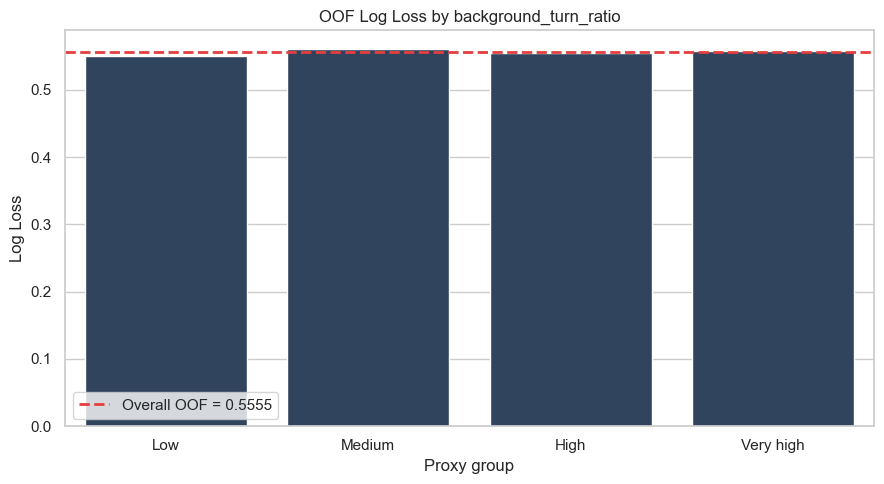

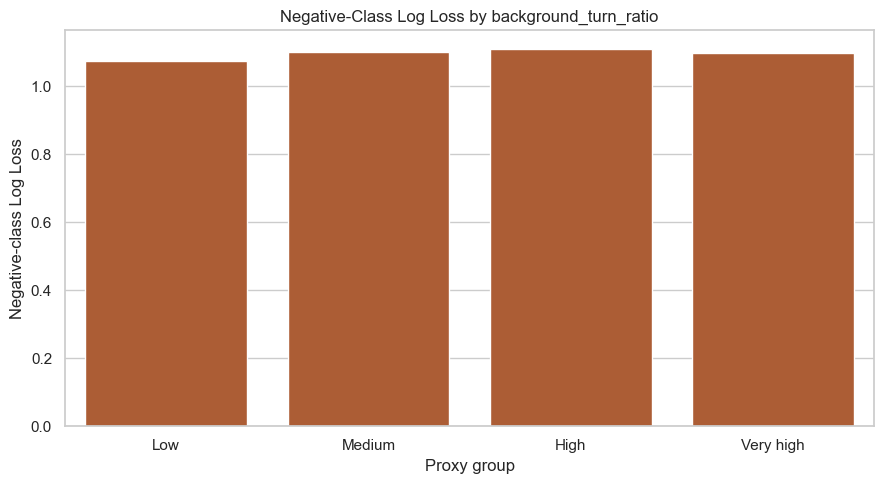

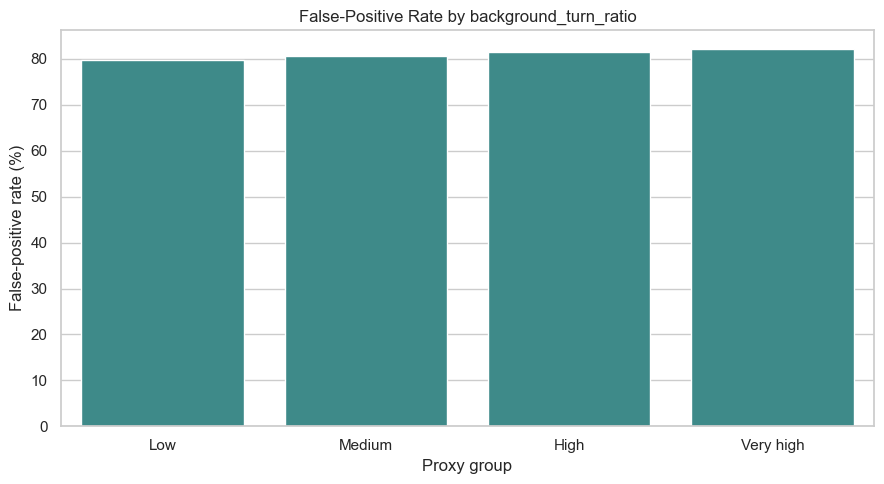

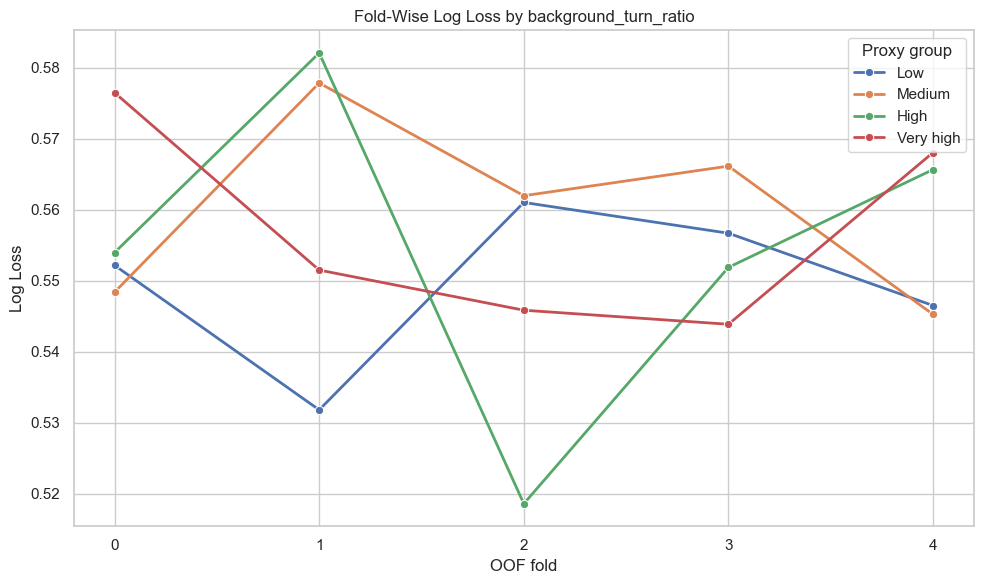

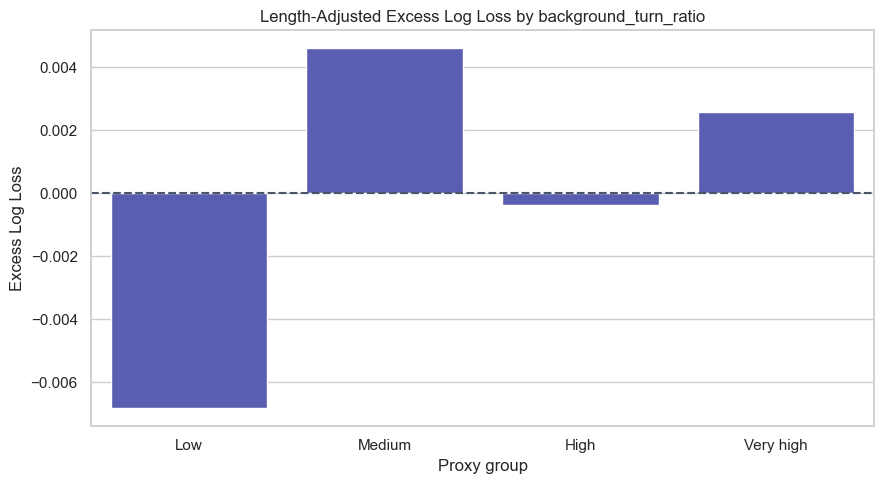

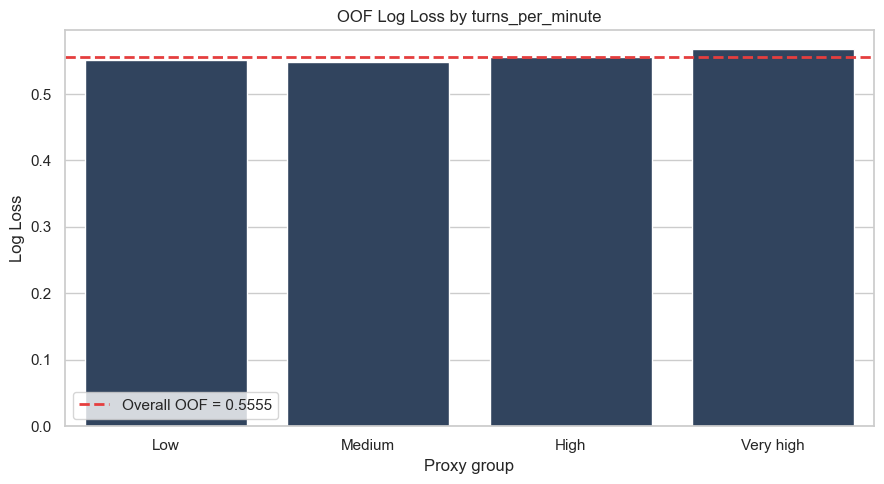

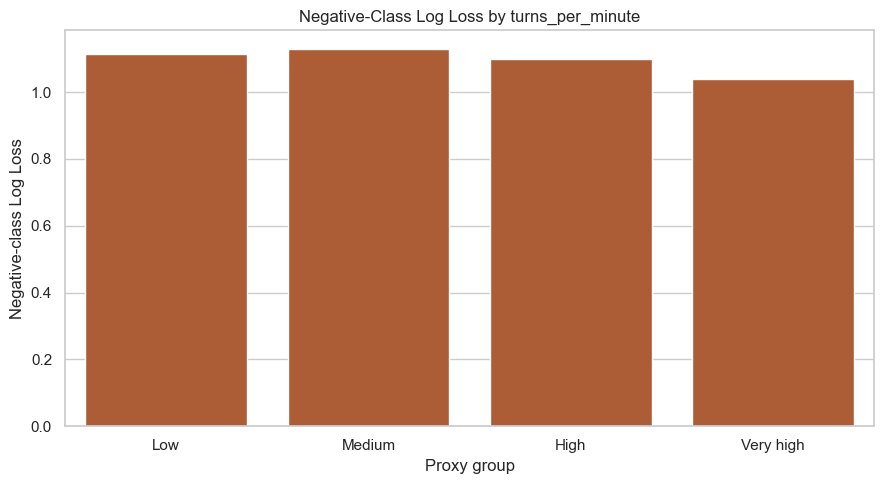

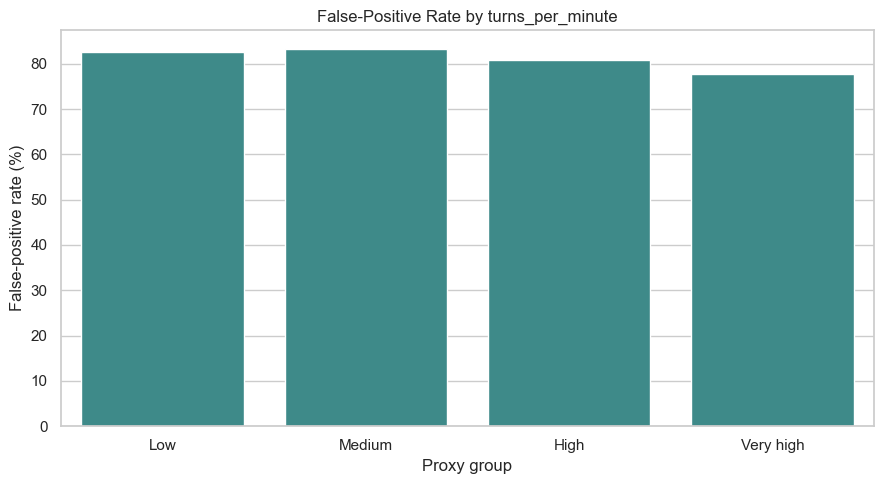

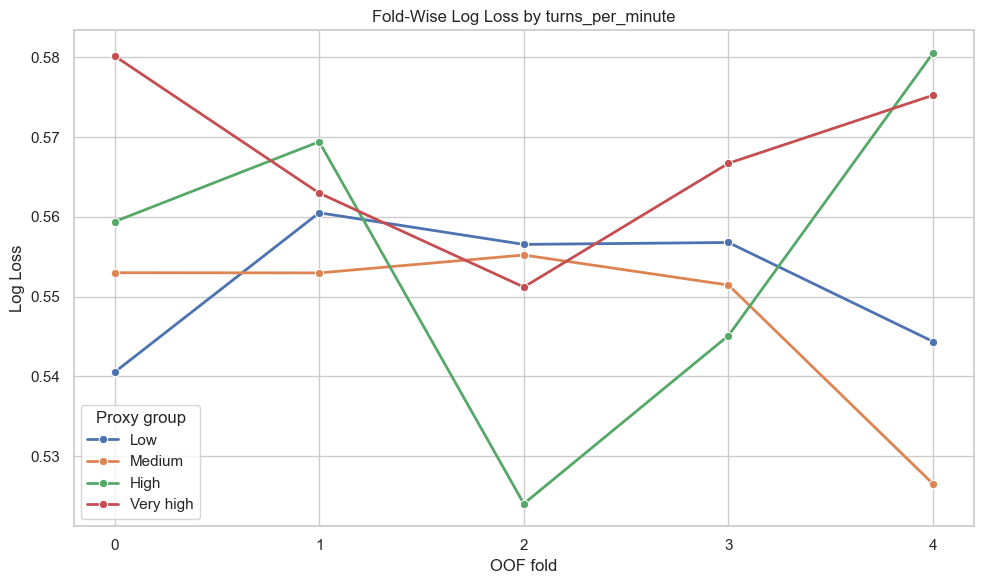

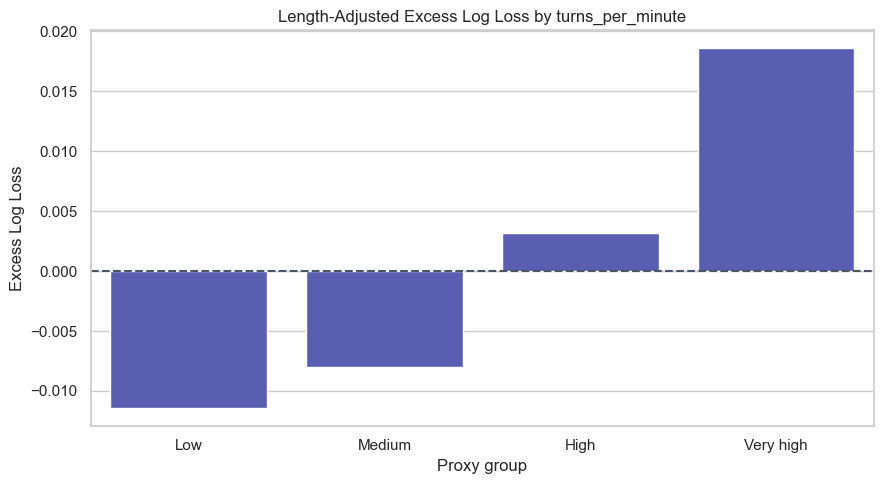

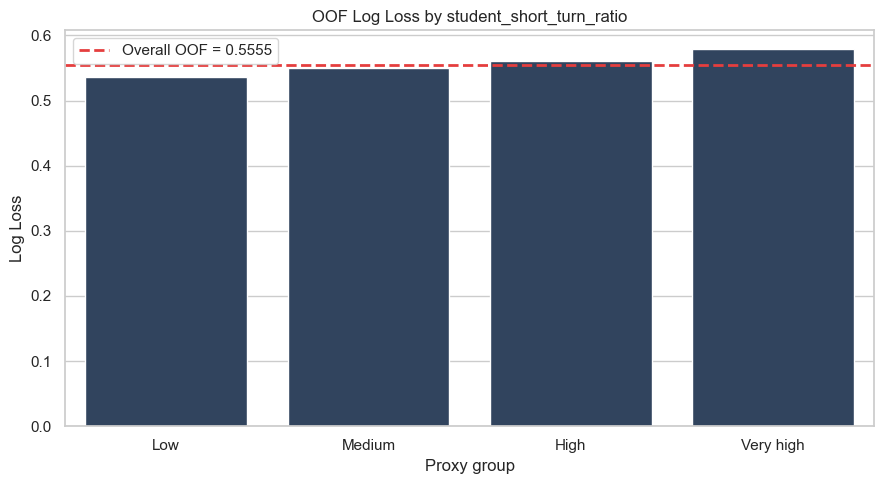

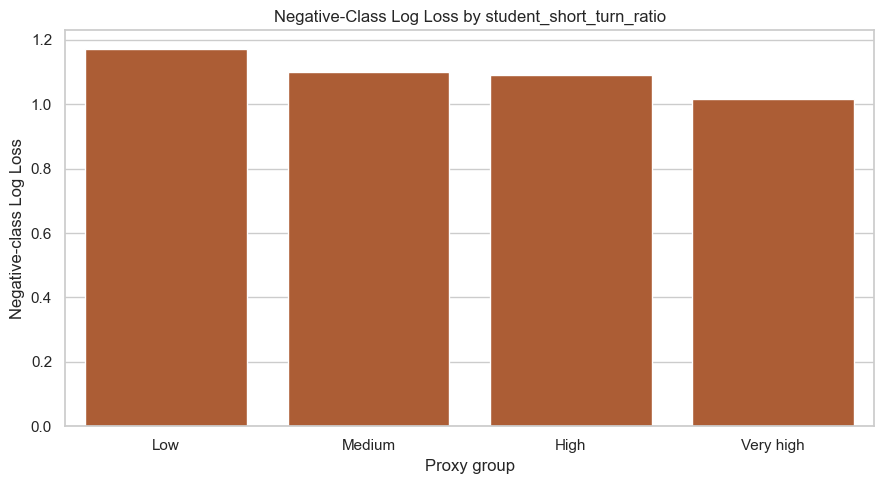

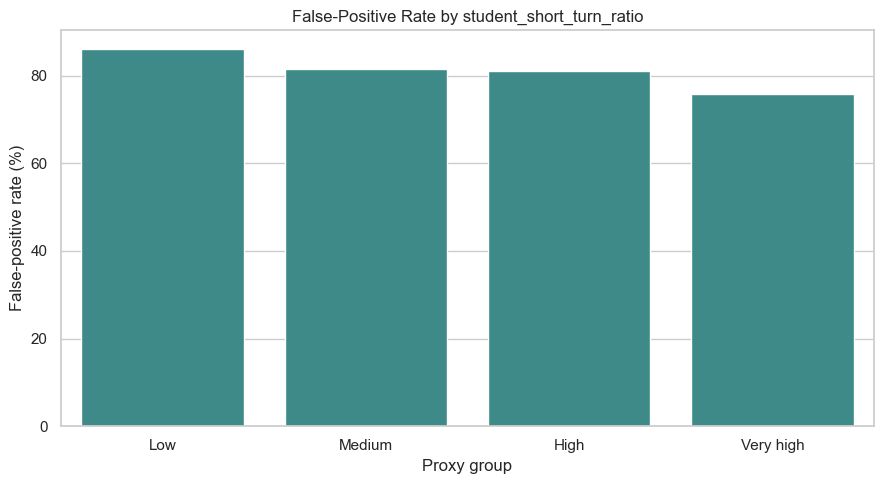

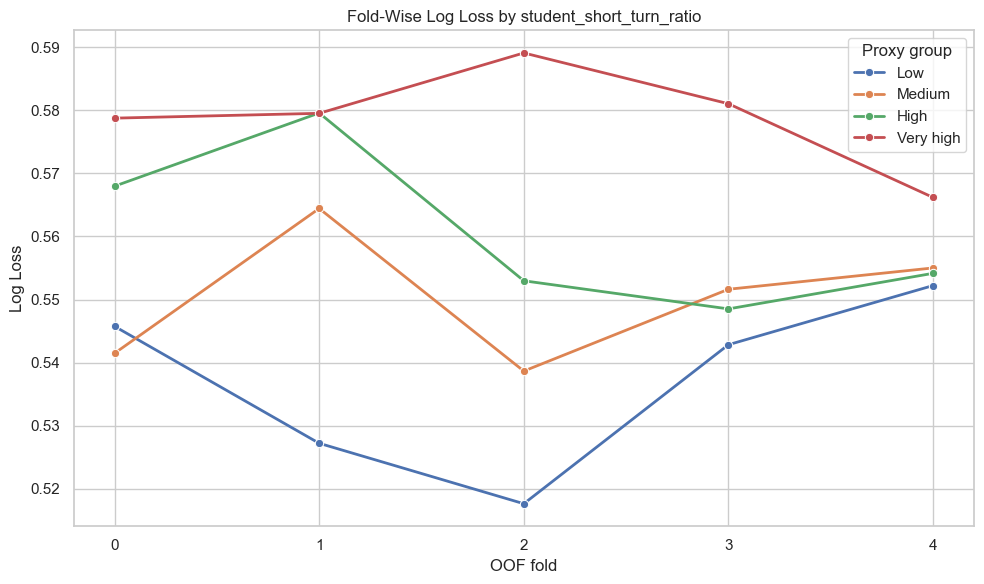

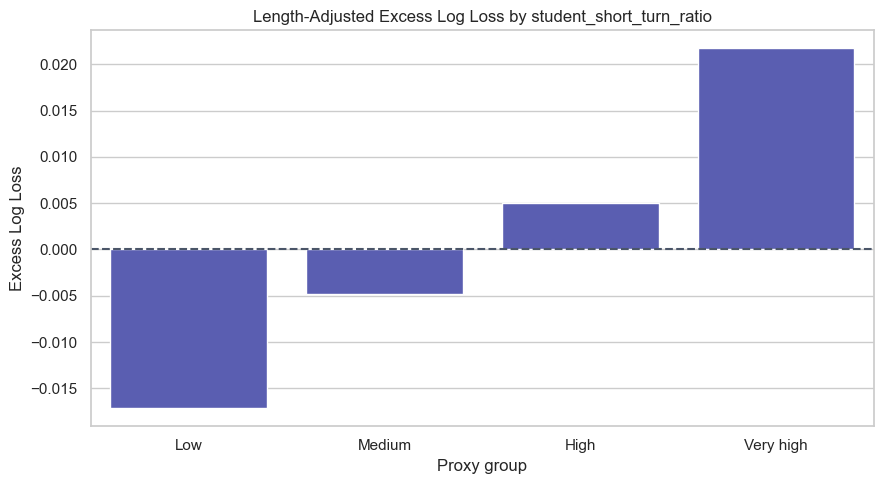

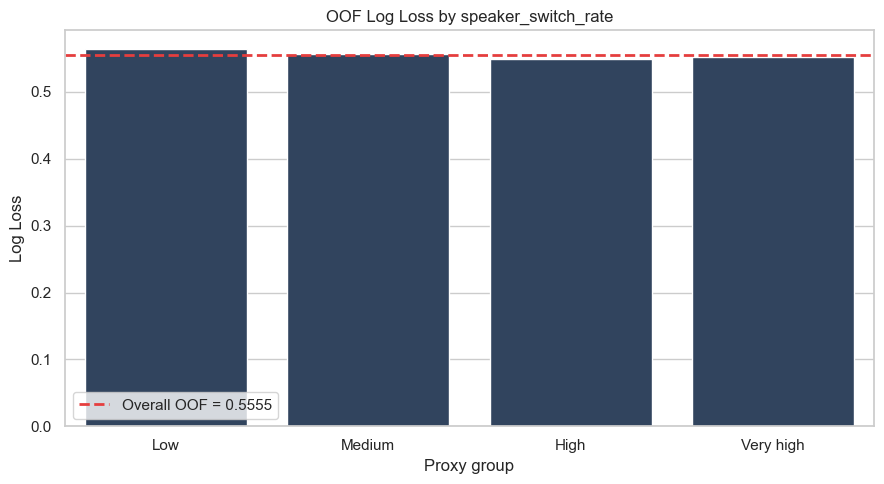

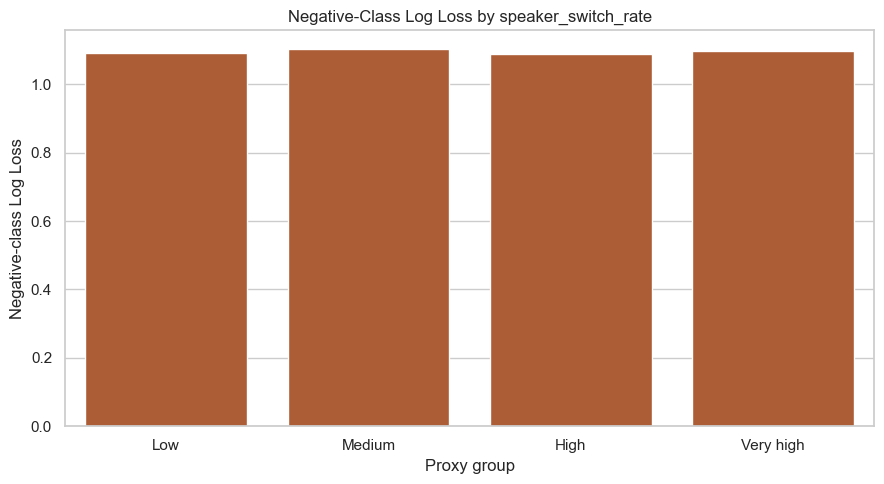

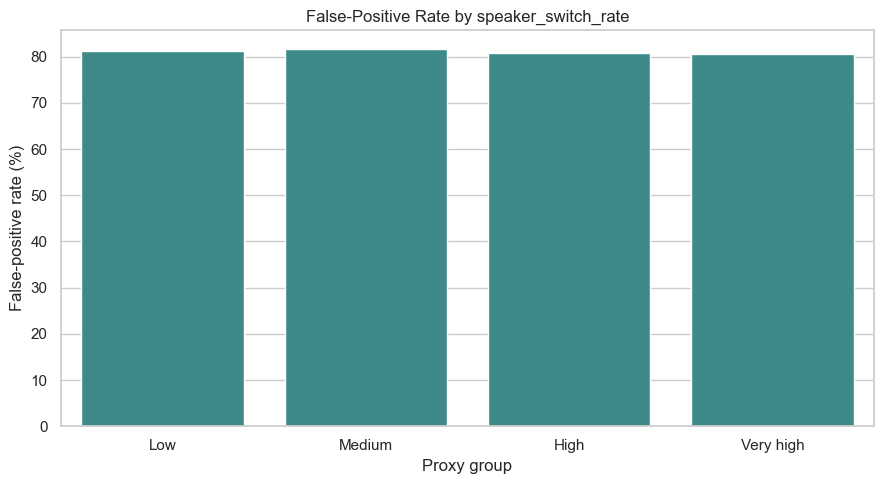

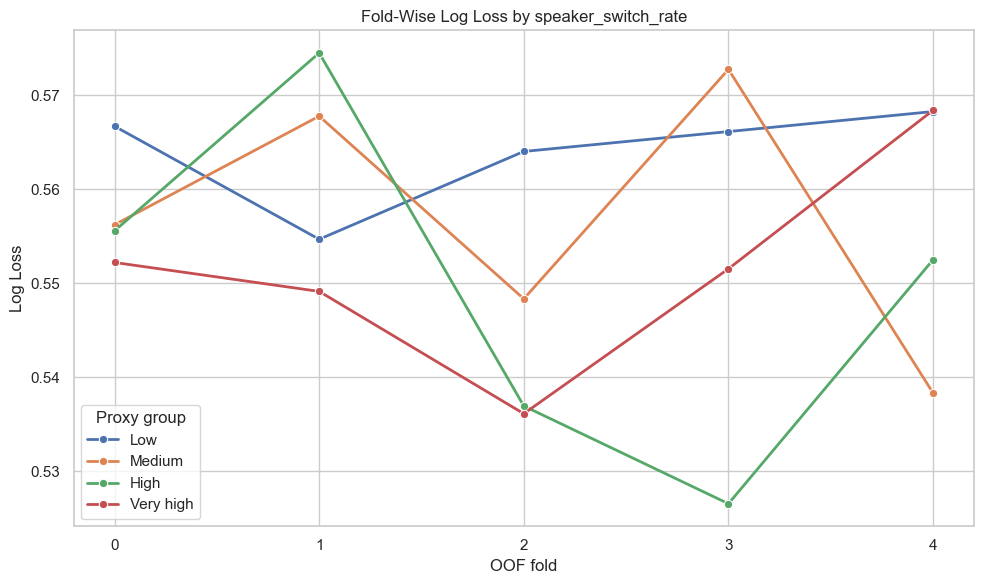

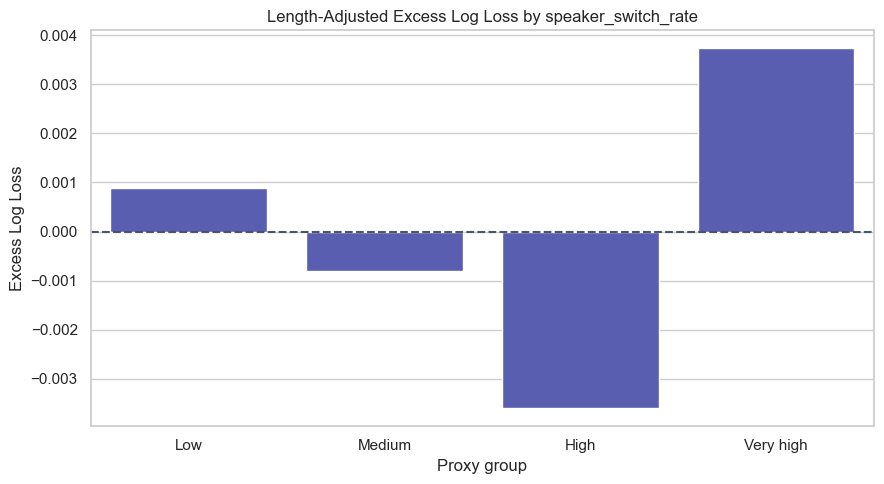

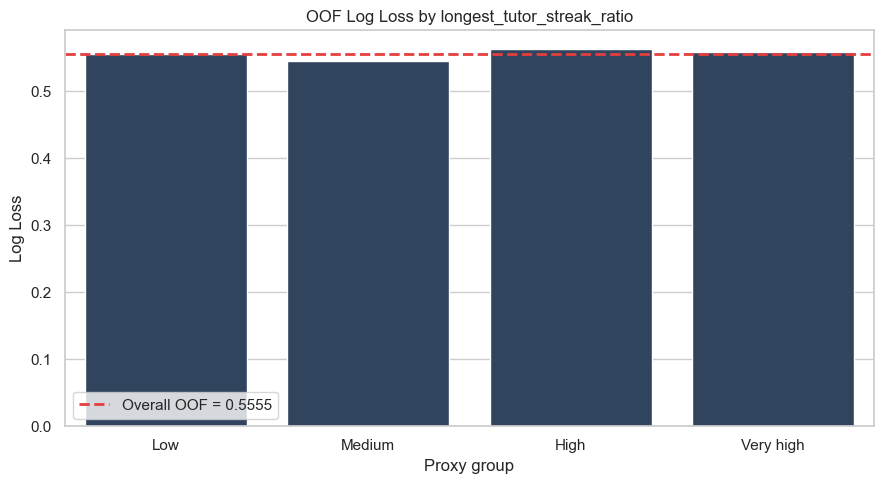

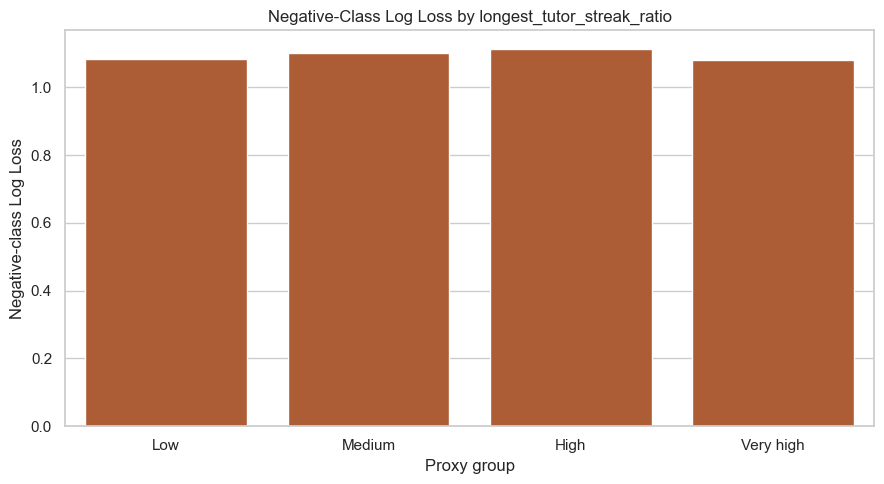

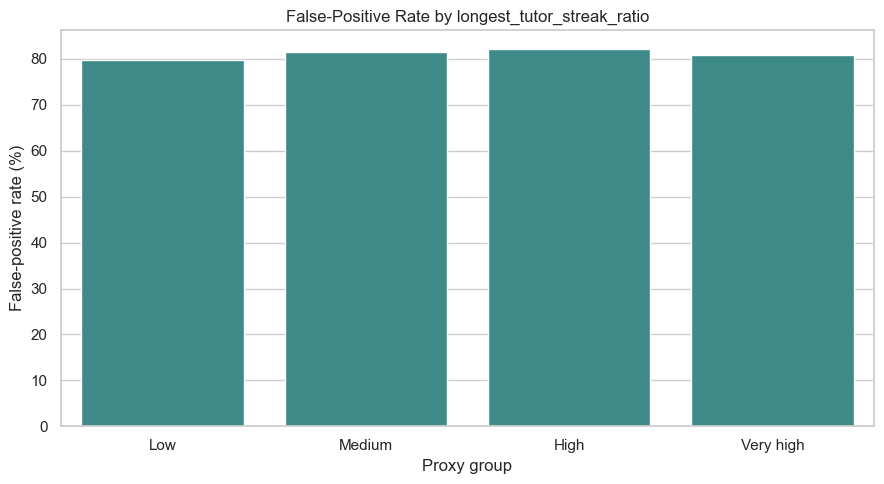

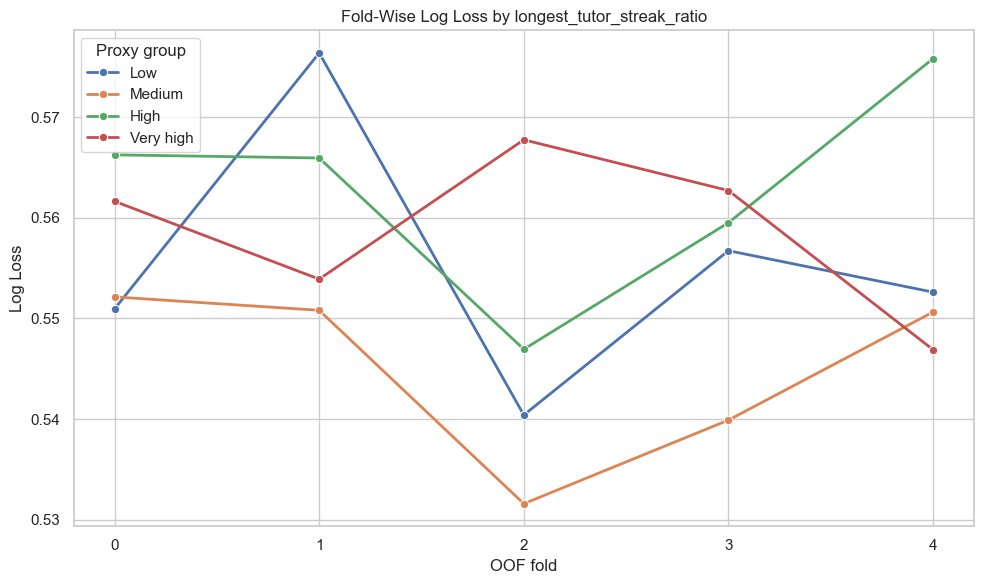

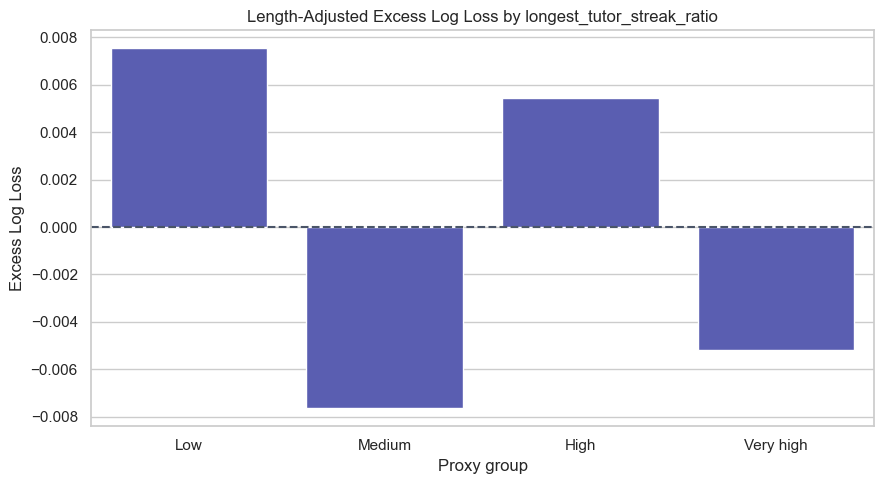

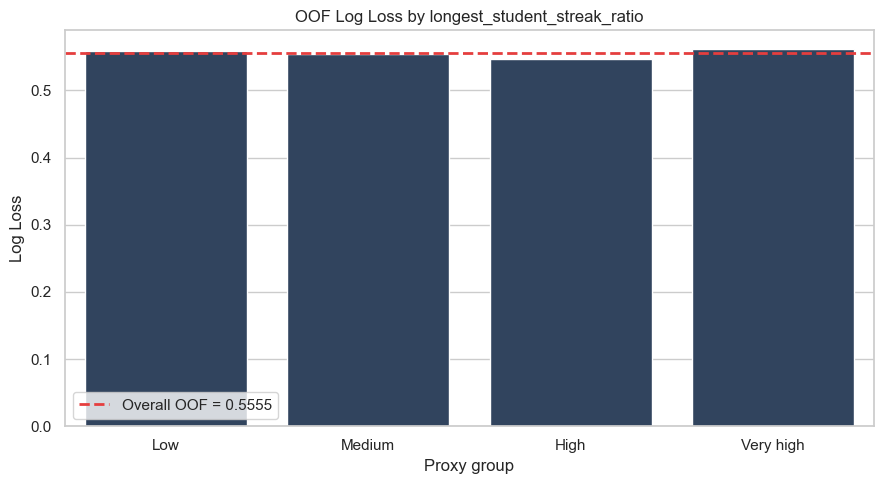

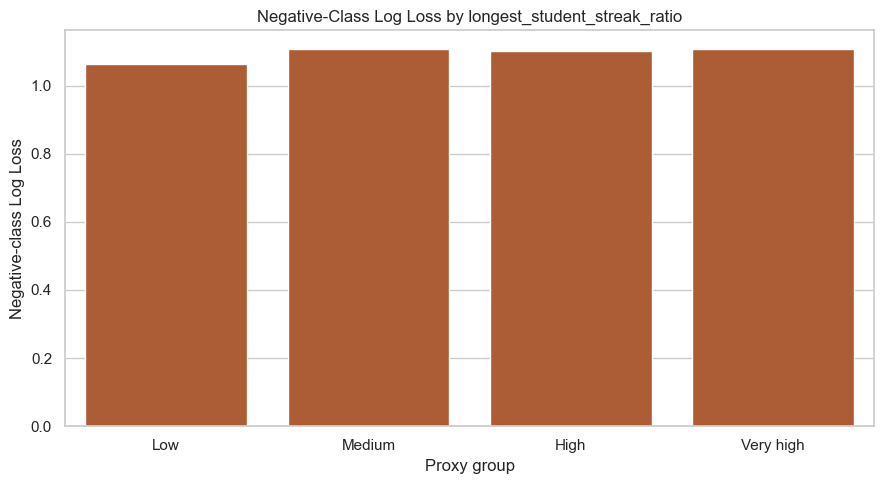

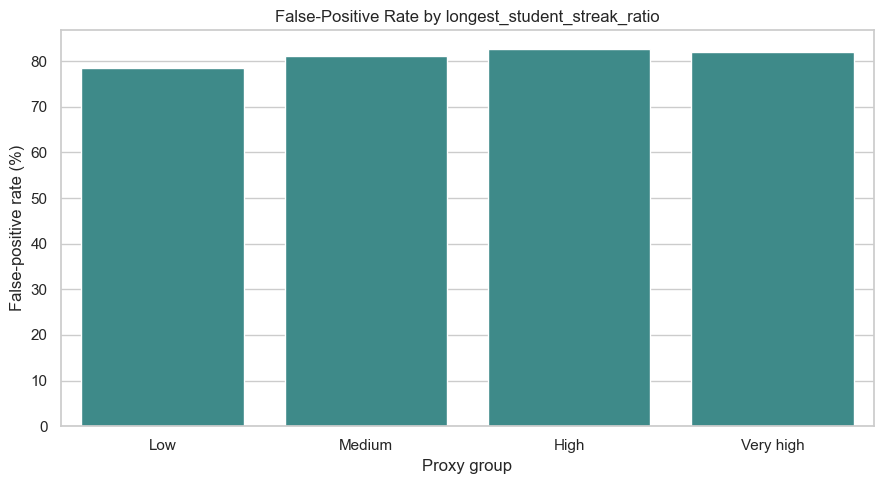

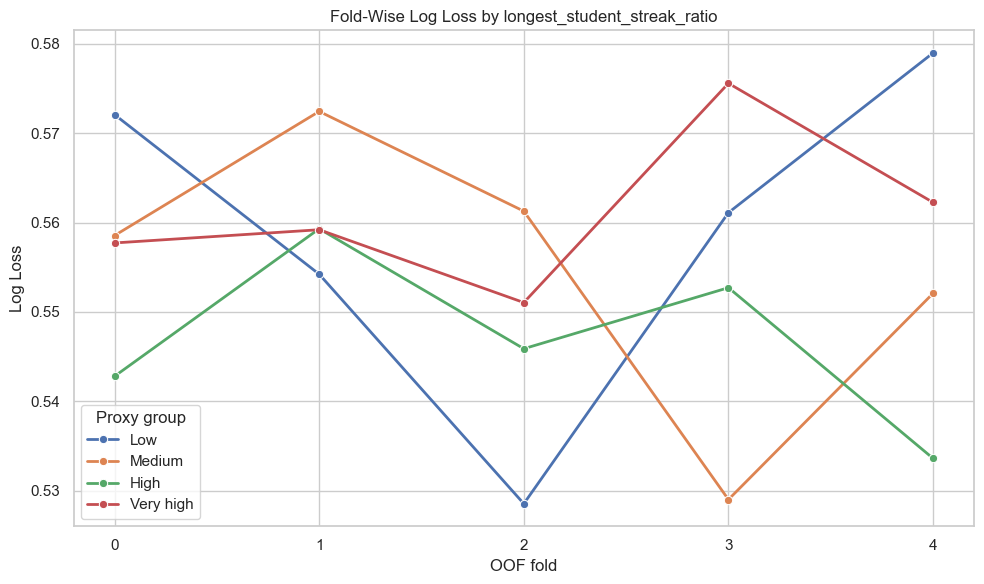

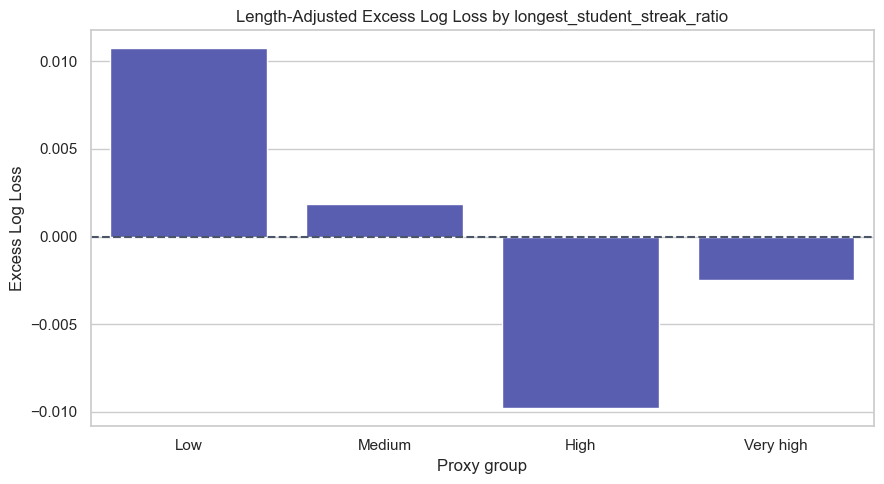

Transcript-noise figures saved in: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\transcript_noise\figures


In [30]:
def plot_transcript_noise_analysis(results):
    summary = results["summary"].copy()
    fold_metrics = results["fold_metrics"].copy()
    group_definitions = results["group_definitions"]
    figures_dir = results["figures_dir"]
    analysis_data = results["data"]

    if summary.empty:
        print("Transcript-noise plots were skipped because no eligible proxy was available.")
        return

    sns.set_theme(style="whitegrid")
    overall_log_loss = analysis_data["sample_log_loss"].mean()

    for proxy in summary["Proxy"].unique():
        proxy_summary = summary[summary["Proxy"].eq(proxy)].copy()
        proxy_fold_data = fold_metrics[fold_metrics["Proxy"].eq(proxy)].copy()
        group_order = [group["noise_proxy_group"] for group in group_definitions[proxy]["groups"]]

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=proxy_summary, x="Group", y="Log Loss", order=group_order, color="#2A4365", ax=ax)
        ax.axhline(overall_log_loss, color="#E53E3E", linestyle="--", linewidth=2, label=f"Overall OOF = {overall_log_loss:.4f}")
        ax.set(title=f"OOF Log Loss by {proxy}", xlabel="Proxy group", ylabel="Log Loss")
        ax.legend()
        plt.tight_layout()
        plt.savefig(figures_dir / f"{proxy}_log_loss.png", dpi=300, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=proxy_summary, x="Group", y="Negative LL", order=group_order, color="#C05621", ax=ax)
        ax.set(title=f"Negative-Class Log Loss by {proxy}", xlabel="Proxy group", ylabel="Negative-class Log Loss")
        plt.tight_layout()
        plt.savefig(figures_dir / f"{proxy}_negative_log_loss.png", dpi=300, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=proxy_summary, x="Group", y="FPR (%)", order=group_order, color="#319795", ax=ax)
        ax.set(title=f"False-Positive Rate by {proxy}", xlabel="Proxy group", ylabel="False-positive rate (%)")
        plt.tight_layout()
        plt.savefig(figures_dir / f"{proxy}_false_positive_rate.png", dpi=300, bbox_inches="tight")
        plt.show()

        if not proxy_fold_data.empty:
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.lineplot(data=proxy_fold_data, x="Fold", y="Log Loss", hue="Group", hue_order=group_order, marker="o", linewidth=2, ax=ax)
            ax.set(title=f"Fold-Wise Log Loss by {proxy}", xlabel="OOF fold", ylabel="Log Loss")
            ax.set_xticks(sorted(proxy_fold_data["Fold"].unique()))
            ax.legend(title="Proxy group")
            plt.tight_layout()
            plt.savefig(figures_dir / f"{proxy}_foldwise_log_loss.png", dpi=300, bbox_inches="tight")
            plt.show()

        if proxy_summary["Length-adjusted excess Log Loss"].notna().any():
            fig, ax = plt.subplots(figsize=(9, 5))
            sns.barplot(data=proxy_summary, x="Group", y="Length-adjusted excess Log Loss", order=group_order, color="#4C51BF", ax=ax)
            ax.axhline(0, color="#4A5568", linestyle="--", linewidth=1.5)
            ax.set(title=f"Length-Adjusted Excess Log Loss by {proxy}", xlabel="Proxy group", ylabel="Excess Log Loss")
            plt.tight_layout()
            plt.savefig(figures_dir / f"{proxy}_length_adjusted_excess_loss.png", dpi=300, bbox_inches="tight")
            plt.show()

    print(f"Transcript-noise figures saved in: {figures_dir}")


plot_transcript_noise_analysis(transcript_noise_results)

## 6.5 — Student–Tutor Behaviour Group Analysis

This section examines whether the baseline performs differently across different student–tutor interaction structures. The analysis uses session-level participation variables already available in the grouped-OOF dataset.

The primary variables are student word share, student turn share, average student and tutor turn length, short and long student-turn ratios, numeric student-turn ratio, student and tutor question ratios, response-after-question ratio, and longest tutor streak ratio.

Student word share represents the proportion of student words among all student and tutor words. Student turn share represents the proportion of student turns among all student and tutor turns.

The primary student-share analyses will use performance-blind quartiles: `Lowest student share`, `Low–medium student share`, `Medium–high student share`, and `Highest student share`.

A secondary fixed interpretation will classify student word share as `Tutor-dominant`, `Tutor-heavy`, `Relatively balanced`, and `Student-heavy`. Exact boundaries and group support will be saved.

Each behavioural variable will be analysed separately. Log Loss, class-specific loss, AUROC, false-positive rate, label prevalence, response share, and loss share will be reported.

Fold-level results will show whether each pattern is repeated across the five grouped-OOF folds. Step 5 session metrics will be merged to examine associations with objective collapse and reversal.

The results describe interaction structure, not teaching quality. A tutor-heavy group performing worse does not mean that tutor instruction is harmful.

In [31]:
import json

def analyze_student_tutor_behavior(input_data, step6_dir, step5_session_metrics=None):
    behavior_dir = step6_dir / "student_tutor_behavior"
    figures_dir = behavior_dir / "figures"

    behavior_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    data = input_data.copy()

    required_columns = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability"]
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Required columns are missing: {missing_columns}")

    if not data["response_id"].is_unique:
        raise ValueError("response_id is not unique in the analysis data.")

    if "calculate_reference_metrics" not in globals():
        raise NameError("calculate_reference_metrics function পাওয়া যায়নি। Step 6.1 আগে run করো।")

    data["probability"] = data["probability"].clip(1e-15, 1 - 1e-15)

    if "hard_prediction" not in data.columns:
        data["hard_prediction"] = data["probability"].ge(0.50).astype(int)

    if "sample_log_loss" not in data.columns:
        data["sample_log_loss"] = -(data["correct"] * np.log(data["probability"]) + (1 - data["correct"]) * np.log1p(-data["probability"]))

    if "is_high_confidence_false_positive" not in data.columns:
        data["is_high_confidence_false_positive"] = data["correct"].eq(0) & data["probability"].ge(0.80)

    if "is_high_confidence_false_negative" not in data.columns:
        data["is_high_confidence_false_negative"] = data["correct"].eq(1) & data["probability"].le(0.20)

    if "student_word_ratio" not in data.columns and {"student_words", "tutor_words"}.issubset(data.columns):
        word_total = data["student_words"] + data["tutor_words"]
        data["student_word_ratio"] = np.where(word_total.gt(0), data["student_words"] / word_total, np.nan)

    if "student_turn_ratio" not in data.columns and {"student_turns", "tutor_turns"}.issubset(data.columns):
        turn_total = data["student_turns"] + data["tutor_turns"]
        data["student_turn_ratio"] = np.where(turn_total.gt(0), data["student_turns"] / turn_total, np.nan)

    variable_config = {
        "student_word_ratio": "Student share",
        "student_turn_ratio": "Student share",
        "avg_student_words_per_turn": "Turn length",
        "avg_tutor_words_per_turn": "Turn length",
        "student_short_turn_ratio": "Student turn structure",
        "student_long_turn_ratio": "Student turn structure",
        "student_numeric_turn_ratio": "Student response type",
        "student_question_ratio": "Question behaviour",
        "tutor_question_ratio": "Question behaviour",
        "student_response_after_tutor_question_ratio": "Question behaviour",
        "longest_tutor_streak_ratio": "Tutor streak"
    }

    primary_share_labels = ["Lowest student share", "Low–medium student share", "Medium–high student share", "Highest student share"]
    standard_labels = ["Low", "Medium", "High", "Very high"]
    minimum_sessions = 50
    availability_rows = []
    group_definitions = {}
    summary_parts = []
    fold_parts = []
    session_group_tables = {}

    def summarize_behavior_groups(grouped_data, variable, group_order):
        total_responses = len(grouped_data)
        total_loss = grouped_data["sample_log_loss"].sum()
        overall_loss = grouped_data["sample_log_loss"].mean()
        summary_rows = []

        for group_name in group_order:
            group_data = grouped_data[grouped_data["behavior_group"].eq(group_name)].copy()

            if group_data.empty:
                continue

            metrics = calculate_reference_metrics(group_data)
            group_loss = group_data["sample_log_loss"].sum()
            support_eligible = metrics["Sessions"] >= minimum_sessions and metrics["Positive responses"] >= 20 and metrics["Negative responses"] >= 20

            summary_rows.append({"Variable": variable, "Family": variable_config[variable], "Group": group_name, "Responses": metrics["Responses"], "Sessions": metrics["Sessions"], "Objectives": metrics["Objectives"], "Positive responses": metrics["Positive responses"], "Negative responses": metrics["Negative responses"], "Positive rate (%)": metrics["Positive rate (%)"], "Mean probability": metrics["Mean predicted probability"], "Probability gap": metrics["Mean predicted probability"] - metrics["Positive rate (%)"] / 100, "Log Loss": metrics["Log Loss"], "Positive LL": metrics["Positive-class Log Loss"], "Negative LL": metrics["Negative-class Log Loss"], "AUROC": metrics["AUROC"], "Brier Score": metrics["Brier Score"], "Accuracy (%)": metrics["Accuracy (%)"], "FPR (%)": metrics["False-positive rate (%)"], "FNR (%)": metrics["False-negative rate (%)"], "High-confidence FP rate (%)": metrics["High-confidence FP rate (%)"], "High-confidence FN rate (%)": metrics["High-confidence FN rate (%)"], "Response share (%)": 100 * len(group_data) / total_responses, "Loss share (%)": 100 * group_loss / total_loss, "Log Loss difference from overall": metrics["Log Loss"] - overall_loss, "Support eligible": support_eligible})

        summary = pd.DataFrame(summary_rows)
        summary["Group"] = pd.Categorical(summary["Group"], categories=group_order, ordered=True)
        summary = summary.sort_values("Group").reset_index(drop=True)

        return summary

    for variable, family in variable_config.items():
        exists = variable in data.columns

        if not exists:
            availability_rows.append({"Variable": variable, "Family": family, "Exists": False, "Dtype": "", "Missing responses": np.nan, "Usable sessions": 0, "Unique values": 0, "Session consistent": False, "Eligible for analysis": False})
            continue

        data[variable] = pd.to_numeric(data[variable], errors="coerce")
        data[variable] = data[variable].replace([np.inf, -np.inf], np.nan)

        session_values = data[["session_id", variable]].dropna().copy()
        consistency_count = session_values.groupby("session_id")[variable].nunique(dropna=False).max()
        session_consistent = bool(pd.isna(consistency_count) or consistency_count <= 1)

        if session_consistent:
            session_values = session_values.drop_duplicates("session_id").reset_index(drop=True)
        else:
            session_values = pd.DataFrame(columns=["session_id", variable])

        usable_sessions = session_values["session_id"].nunique()
        unique_values = session_values[variable].nunique()
        eligible = session_consistent and usable_sessions >= minimum_sessions and unique_values >= 4

        availability_rows.append({"Variable": variable, "Family": family, "Exists": True, "Dtype": str(data[variable].dtype), "Missing responses": int(data[variable].isna().sum()), "Usable sessions": int(usable_sessions), "Unique values": int(unique_values), "Session consistent": session_consistent, "Eligible for analysis": eligible})

        if not eligible:
            continue

        requested_labels = primary_share_labels if variable in ["student_word_ratio", "student_turn_ratio"] else standard_labels
        group_codes, group_bins = pd.qcut(session_values[variable], q=4, labels=False, retbins=True, duplicates="drop")
        active_labels = requested_labels[:len(group_bins) - 1]

        if len(active_labels) < 2:
            print(f"Skipped {variable}: stable groups could not be created.")
            continue

        label_map = {group_number: active_labels[group_number] for group_number in range(len(active_labels))}
        session_values["behavior_group"] = group_codes.map(label_map)
        session_values["behavior_group"] = pd.Categorical(session_values["behavior_group"], categories=active_labels, ordered=True)

        definition_table = session_values.groupby("behavior_group", observed=True).agg(Sessions=("session_id", "nunique"), Minimum_value=(variable, "min"), Maximum_value=(variable, "max"), Median_value=(variable, "median")).reset_index()

        group_definitions[variable] = {"family": family, "grouping_method": "Session-level quartiles", "boundaries": [float(value) for value in group_bins], "labels": active_labels, "groups": definition_table.to_dict(orient="records")}
        session_group_tables[variable] = session_values[["session_id", "behavior_group"]].copy()

        variable_data = data.merge(session_values[["session_id", "behavior_group"]], on="session_id", how="inner", validate="many_to_one")
        variable_summary = summarize_behavior_groups(variable_data, variable, active_labels)
        summary_parts.append(variable_summary)

        for fold_id, fold_data in variable_data.groupby("fold_id", sort=True):
            fold_summary = summarize_behavior_groups(fold_data, variable, active_labels)
            fold_reference_loss = fold_data["sample_log_loss"].mean()
            fold_summary["Fold"] = int(fold_id)
            fold_summary["Fold reference Log Loss"] = fold_reference_loss
            fold_summary["Difference from fold reference"] = fold_summary["Log Loss"] - fold_reference_loss
            fold_parts.append(fold_summary)

    behavior_availability = pd.DataFrame(availability_rows)
    behavior_availability.to_csv(behavior_dir / "behavior_variable_availability.csv", index=False)

    if summary_parts:
        behavior_summary = pd.concat(summary_parts, ignore_index=True)
    else:
        behavior_summary = pd.DataFrame()

    behavior_summary.to_csv(behavior_dir / "all_behavior_group_summary.csv", index=False)

    student_share_summary = behavior_summary[behavior_summary["Variable"].isin(["student_word_ratio", "student_turn_ratio"])].copy()
    turn_length_summary = behavior_summary[behavior_summary["Variable"].isin(["avg_student_words_per_turn", "avg_tutor_words_per_turn", "student_short_turn_ratio", "student_long_turn_ratio"])].copy()
    numeric_behavior_summary = behavior_summary[behavior_summary["Variable"].eq("student_numeric_turn_ratio")].copy()
    question_behavior_summary = behavior_summary[behavior_summary["Variable"].isin(["student_question_ratio", "tutor_question_ratio", "student_response_after_tutor_question_ratio"])].copy()
    tutor_streak_summary = behavior_summary[behavior_summary["Variable"].eq("longest_tutor_streak_ratio")].copy()

    student_share_summary.to_csv(behavior_dir / "student_share_summary.csv", index=False)
    turn_length_summary.to_csv(behavior_dir / "turn_length_behavior_summary.csv", index=False)
    numeric_behavior_summary.to_csv(behavior_dir / "student_numeric_behavior_summary.csv", index=False)
    question_behavior_summary.to_csv(behavior_dir / "question_behavior_summary.csv", index=False)
    tutor_streak_summary.to_csv(behavior_dir / "tutor_streak_summary.csv", index=False)

    interpretable_balance_summary = pd.DataFrame()

    if "student_word_ratio" in data.columns:
        balance_session_data = data[["session_id", "student_word_ratio"]].dropna().drop_duplicates("session_id").copy()
        balance_labels = ["Tutor-dominant", "Tutor-heavy", "Relatively balanced", "Student-heavy"]
        balance_bins = [-np.inf, 0.25, 0.40, 0.60, np.inf]
        balance_session_data["behavior_group"] = pd.cut(balance_session_data["student_word_ratio"], bins=balance_bins, labels=balance_labels, right=False)
        balance_data = data.merge(balance_session_data[["session_id", "behavior_group"]], on="session_id", how="inner", validate="many_to_one")
        interpretable_balance_summary = summarize_behavior_groups(balance_data, "student_word_ratio", balance_labels)
        interpretable_balance_summary["Interpretation type"] = "Fixed student-word-share bands"
        interpretable_balance_summary.to_csv(behavior_dir / "interpretable_student_balance_summary.csv", index=False)
        balance_definition_table = balance_session_data.groupby("behavior_group", observed=True).agg(Sessions=("session_id", "nunique"), Minimum_value=("student_word_ratio", "min"), Maximum_value=("student_word_ratio", "max"), Median_value=("student_word_ratio", "median")).reset_index()
        group_definitions["student_word_ratio_interpretable"] = {"grouping_method": "Fixed boundaries", "boundaries": ["<0.25", "0.25–<0.40", "0.40–<0.60", ">=0.60"], "labels": balance_labels, "groups": balance_definition_table.to_dict(orient="records")}

    with open(behavior_dir / "behavior_group_definitions.json", "w", encoding="utf-8") as file:
        json.dump(group_definitions, file, indent=2, ensure_ascii=False)

    if fold_parts:
        behavior_fold_metrics = pd.concat(fold_parts, ignore_index=True)
        behavior_fold_metrics.to_csv(behavior_dir / "behavior_fold_metrics.csv", index=False)
        behavior_fold_stability = behavior_fold_metrics.groupby(["Variable", "Group"], observed=True).agg(Folds=("Fold", "nunique"), Mean_fold_Log_Loss=("Log Loss", "mean"), Fold_Log_Loss_SD=("Log Loss", "std"), Minimum_fold_Log_Loss=("Log Loss", "min"), Maximum_fold_Log_Loss=("Log Loss", "max"), Folds_worse_than_reference=("Difference from fold reference", lambda values: int(values.gt(0).sum())), Mean_difference_from_reference=("Difference from fold reference", "mean"), Mean_fold_Negative_LL=("Negative LL", "mean"), Mean_fold_FPR=("FPR (%)", "mean")).reset_index()
        behavior_fold_stability["Stable high-risk group"] = behavior_fold_stability["Folds_worse_than_reference"].ge(4)
    else:
        behavior_fold_metrics = pd.DataFrame()
        behavior_fold_stability = pd.DataFrame()

    behavior_fold_stability.to_csv(behavior_dir / "behavior_fold_stability.csv", index=False)

    step5_linkage_parts = []

    if step5_session_metrics is not None:
        step5_data = step5_session_metrics.copy()
        required_step5_columns = ["session_id", "session_margin", "session_log_loss", "session_pairwise_accuracy"]
        missing_step5_columns = [column for column in required_step5_columns if column not in step5_data.columns]

        if missing_step5_columns:
            raise ValueError(f"Step 5 session metrics are missing required columns: {missing_step5_columns}")

        if "is_session_collapse" not in step5_data.columns:
            step5_data["is_session_collapse"] = step5_data["session_margin"].abs().lt(0.02)

        if "is_session_reversed" not in step5_data.columns:
            step5_data["is_session_reversed"] = step5_data["session_margin"].lt(0)

        for variable, group_table in session_group_tables.items():
            linkage_data = step5_data.merge(group_table, on="session_id", how="inner", validate="one_to_one")

            if linkage_data.empty:
                continue

            linkage_summary = linkage_data.groupby("behavior_group", observed=True).agg(Mixed_sessions=("session_id", "size"), Mean_session_margin=("session_margin", "mean"), Median_session_margin=("session_margin", "median"), Mean_pairwise_accuracy=("session_pairwise_accuracy", "mean"), Collapse_rate=("is_session_collapse", "mean"), Reversal_rate=("is_session_reversed", "mean"), Mean_session_Log_Loss=("session_log_loss", "mean")).reset_index()
            linkage_summary["Variable"] = variable
            linkage_summary["Mean pairwise accuracy (%)"] = 100 * linkage_summary.pop("Mean_pairwise_accuracy")
            linkage_summary["Collapse rate (%)"] = 100 * linkage_summary.pop("Collapse_rate")
            linkage_summary["Reversal rate (%)"] = 100 * linkage_summary.pop("Reversal_rate")
            linkage_summary = linkage_summary.rename(columns={"behavior_group": "Group"})
            step5_linkage_parts.append(linkage_summary)

    if step5_linkage_parts:
        behavior_step5_linkage = pd.concat(step5_linkage_parts, ignore_index=True)
    else:
        behavior_step5_linkage = pd.DataFrame()

    behavior_step5_linkage.to_csv(behavior_dir / "behavior_step5_linkage.csv", index=False)

    results = {"data": data, "availability": behavior_availability, "summary": behavior_summary, "student_share_summary": student_share_summary, "turn_length_summary": turn_length_summary, "numeric_summary": numeric_behavior_summary, "question_summary": question_behavior_summary, "tutor_streak_summary": tutor_streak_summary, "interpretable_balance_summary": interpretable_balance_summary, "fold_metrics": behavior_fold_metrics, "fold_stability": behavior_fold_stability, "step5_linkage": behavior_step5_linkage, "group_definitions": group_definitions, "output_dir": behavior_dir, "figures_dir": figures_dir}

    return results

In [32]:
student_tutor_input = transcript_noise_results["data"].copy() if "transcript_noise_results" in globals() else objective_frequency_results["data"].copy() if "objective_frequency_results" in globals() else reference_data.copy()
step5_behavior_metrics = session_metrics.copy() if "session_metrics" in globals() else None

student_tutor_behavior_results = analyze_student_tutor_behavior(student_tutor_input, step6_dir, step5_behavior_metrics)

behavior_availability = student_tutor_behavior_results["availability"]
behavior_summary = student_tutor_behavior_results["summary"]
behavior_fold_stability = student_tutor_behavior_results["fold_stability"]
behavior_step5_linkage = student_tutor_behavior_results["step5_linkage"]
interpretable_student_balance = student_tutor_behavior_results["interpretable_balance_summary"]

display(behavior_availability)

behavior_display_columns = ["Variable", "Group", "Responses", "Sessions", "Positive rate (%)", "Mean probability", "Probability gap", "Log Loss", "Positive LL", "Negative LL", "AUROC", "FPR (%)", "Response share (%)", "Loss share (%)"]
display(behavior_summary[behavior_display_columns])

stability_display_columns = ["Variable", "Group", "Folds", "Mean_fold_Log_Loss", "Fold_Log_Loss_SD", "Folds_worse_than_reference", "Mean_fold_Negative_LL", "Mean_fold_FPR", "Stable high-risk group"]
display(behavior_fold_stability[stability_display_columns])

if not interpretable_student_balance.empty:
    display(interpretable_student_balance[behavior_display_columns])

if not behavior_step5_linkage.empty:
    display(behavior_step5_linkage)

print(f"Behaviour variables available: {behavior_availability['Exists'].sum():,}")
print(f"Behaviour variables analysed: {behavior_availability['Eligible for analysis'].sum():,}")
print(f"Output folder: {student_tutor_behavior_results['output_dir']}")

,Variable,Family,Exists,Dtype,Missing responses,Usable sessions,Unique values,Session consistent,Eligible for analysis
0,student_word_ratio,Student share,True,float32,0,22821,22539,True,True
1,student_turn_ratio,Student share,True,float32,0,22821,7973,True,True
2,avg_student_words_per_turn,Turn length,True,float32,0,22821,18534,True,True
3,avg_tutor_words_per_turn,Turn length,True,float32,0,22821,20566,True,True
4,student_short_turn_ratio,Student turn structure,True,float32,0,22821,5156,True,True
5,student_long_turn_ratio,Student turn structure,True,float32,0,22821,4375,True,True
6,student_numeric_turn_ratio,Student response type,True,float32,0,22821,5038,True,True
7,student_question_ratio,Question behaviour,True,float32,0,22821,3390,True,True
8,tutor_question_ratio,Question behaviour,True,float32,0,22821,6291,True,True
9,student_response_after_tutor_question_ratio,Question behaviour,True,float32,0,22821,3330,True,True


,Variable,Group,Responses,Sessions,Positive rate (%),Mean probability,Probability gap,Log Loss,Positive LL,Negative LL,AUROC,FPR (%),Response share (%),Loss share (%)
0,student_word_ratio,Lowest student share,7943,5706,67.3045,0.6814,0.0084,0.5736,0.3544,1.0249,0.7057,77.0119,22.6477,23.3888
1,student_word_ratio,Low–medium student share,8366,5705,68.9457,0.7014,0.0119,0.5682,0.3304,1.0963,0.6937,80.3695,23.8538,24.4025
2,student_word_ratio,Medium–high student share,8967,5705,71.3951,0.7081,-0.0059,0.5458,0.3226,1.1031,0.7035,81.6764,25.5674,25.1244
3,student_word_ratio,Highest student share,9796,5705,72.6929,0.7214,-0.0055,0.5386,0.3075,1.1538,0.6948,85.0093,27.9311,27.0843
4,student_turn_ratio,Lowest student share,8860,5707,68.6230,0.6966,0.0104,0.5694,0.3364,1.0791,0.6974,80.4317,25.2623,25.8965
5,student_turn_ratio,Low–medium student share,8688,5708,70.4650,0.7033,-0.0014,0.5561,0.3292,1.0975,0.6946,80.6313,24.7719,24.8015
6,student_turn_ratio,Medium–high student share,8629,5705,70.9584,0.7085,-0.0011,0.5408,0.3176,1.0861,0.7177,80.2075,24.6037,23.9547
7,student_turn_ratio,Highest student share,8895,5701,70.9612,0.7084,-0.0012,0.5551,0.3248,1.1181,0.6923,82.9268,25.3621,25.3473
8,avg_student_words_per_turn,Low,7776,5706,65.2906,0.6653,0.0124,0.5860,0.3748,0.9831,0.7064,73.7310,22.1715,23.3890
9,avg_student_words_per_turn,Medium,8507,5706,68.7787,0.6940,0.0062,0.5699,0.3420,1.0721,0.6952,80.3464,24.2558,24.8871


,Variable,Group,Folds,Mean_fold_Log_Loss,Fold_Log_Loss_SD,Folds_worse_than_reference,Mean_fold_Negative_LL,Mean_fold_FPR,Stable high-risk group
0,avg_student_words_per_turn,High,5,0.5554,0.0167,4,1.1319,83.0729,True
1,avg_student_words_per_turn,Low,5,0.5859,0.0095,5,0.9828,73.7218,True
2,avg_student_words_per_turn,Medium,5,0.5698,0.0071,5,1.0720,80.3284,True
3,avg_student_words_per_turn,Very high,5,0.5186,0.0067,0,1.2016,87.5793,False
4,avg_tutor_words_per_turn,High,5,0.5464,0.0088,2,1.0982,79.8629,False
5,avg_tutor_words_per_turn,Low,5,0.5718,0.0174,4,1.0556,79.2559,True
6,avg_tutor_words_per_turn,Medium,5,0.5580,0.0053,4,1.0940,80.8042,True
7,avg_tutor_words_per_turn,Very high,5,0.5442,0.0082,0,1.1394,84.7617,False
8,longest_tutor_streak_ratio,High,5,0.5629,0.0107,4,1.1123,82.1034,True
9,longest_tutor_streak_ratio,Low,5,0.5554,0.0132,2,1.0832,79.7143,False


,Variable,Group,Responses,Sessions,Positive rate (%),Mean probability,Probability gap,Log Loss,Positive LL,Negative LL,AUROC,FPR (%),Response share (%),Loss share (%)
0,student_word_ratio,Tutor-dominant,14550,10196,67.9794,0.6908,0.0110,0.5718,0.3430,1.0577,0.7005,78.5362,41.4861,42.7075
1,student_word_ratio,Tutor-heavy,17040,10690,71.3732,0.7119,-0.0018,0.5465,0.3173,1.1180,0.7012,82.4313,48.5858,47.8047
2,student_word_ratio,Relatively balanced,3413,1884,74.3041,0.7230,-0.0200,0.5300,0.3104,1.1652,0.6847,86.7731,9.7314,9.2857
3,student_word_ratio,Student-heavy,69,51,69.5652,0.6912,-0.0044,0.5708,0.3450,1.0868,0.7054,76.1905,0.1967,0.2022


,Group,Mixed_sessions,Mean_session_margin,Median_session_margin,Mean_session_Log_Loss,Variable,Mean pairwise accuracy (%),Collapse rate (%),Reversal rate (%)
0,Lowest student share,640,0.0100,0.0049,0.7792,student_word_ratio,67.1250,69.0625,32.3438
1,Low–medium student share,751,0.0083,0.0051,0.7927,student_word_ratio,67.8429,77.8961,31.5579
2,Medium–high student share,798,0.0081,0.0051,0.7819,student_word_ratio,67.8446,76.4411,31.0777
3,Highest student share,1018,0.0081,0.0053,0.7772,student_word_ratio,67.5398,75.2456,30.5501
4,Lowest student share,837,0.0086,0.0049,0.7680,student_turn_ratio,64.9691,73.7157,34.0502
5,Low–medium student share,767,0.0080,0.0043,0.7792,student_turn_ratio,67.5804,74.8370,31.4211
6,Medium–high student share,730,0.0087,0.0051,0.7921,student_turn_ratio,68.3489,75.6164,30.0000
7,Highest student share,873,0.0088,0.0057,0.7908,student_turn_ratio,69.5275,75.6014,29.5533
8,Low,618,0.0089,0.0052,0.7825,avg_student_words_per_turn,67.0038,70.3883,32.5243
9,Medium,748,0.0100,0.0059,0.7787,avg_student_words_per_turn,70.0568,73.7968,29.4118


Behaviour variables available: 11
Behaviour variables analysed: 11
Output folder: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\student_tutor_behavior


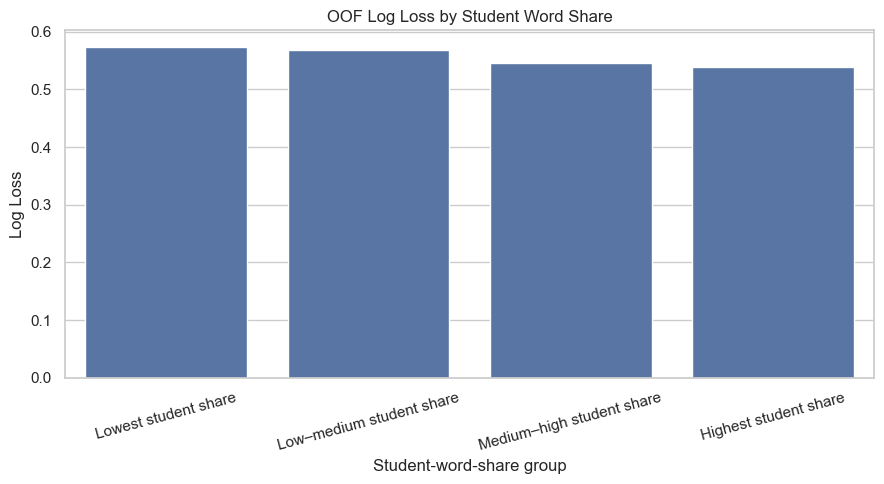

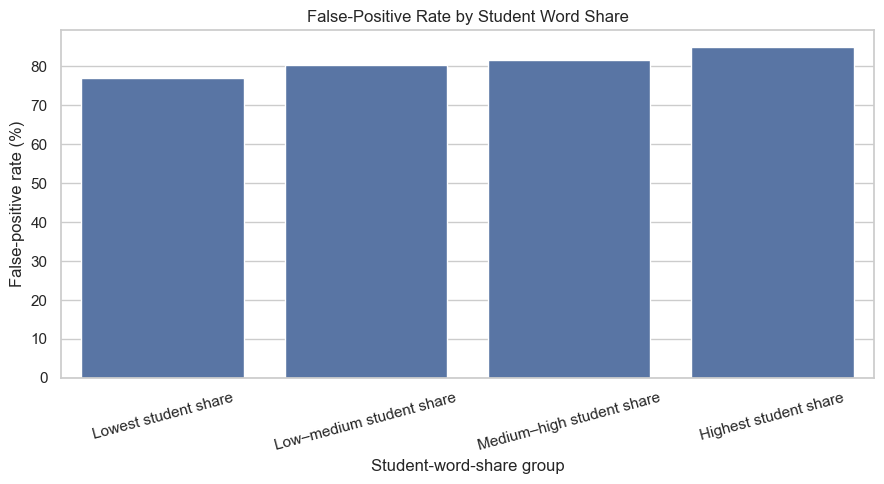

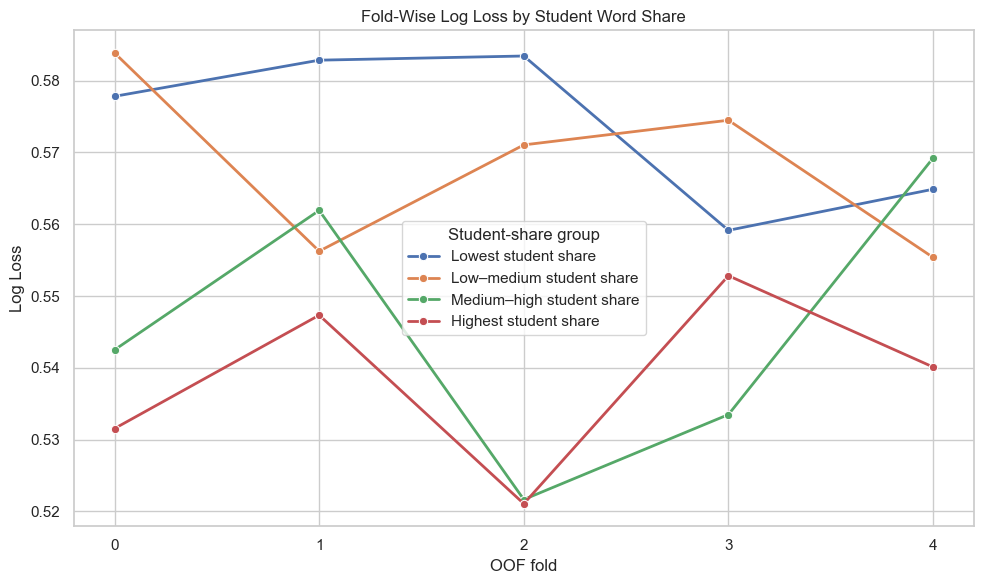

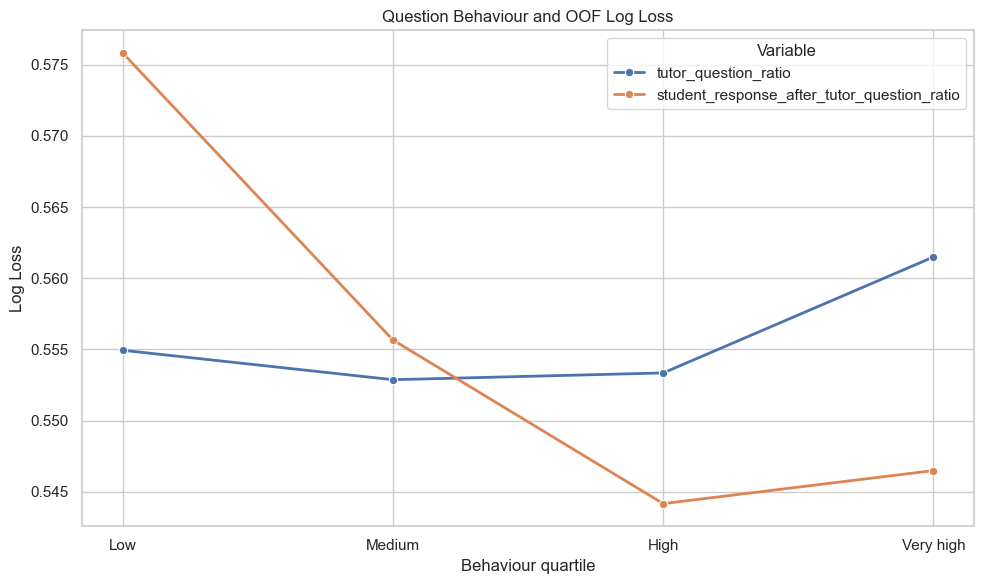

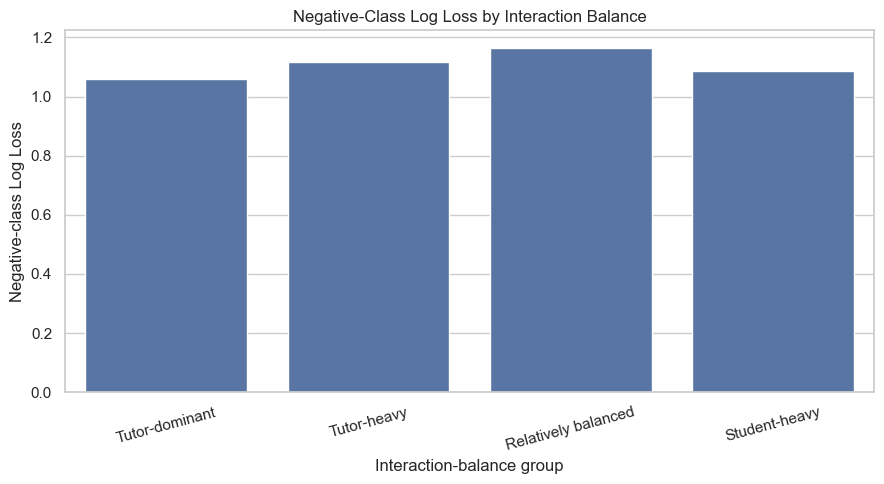

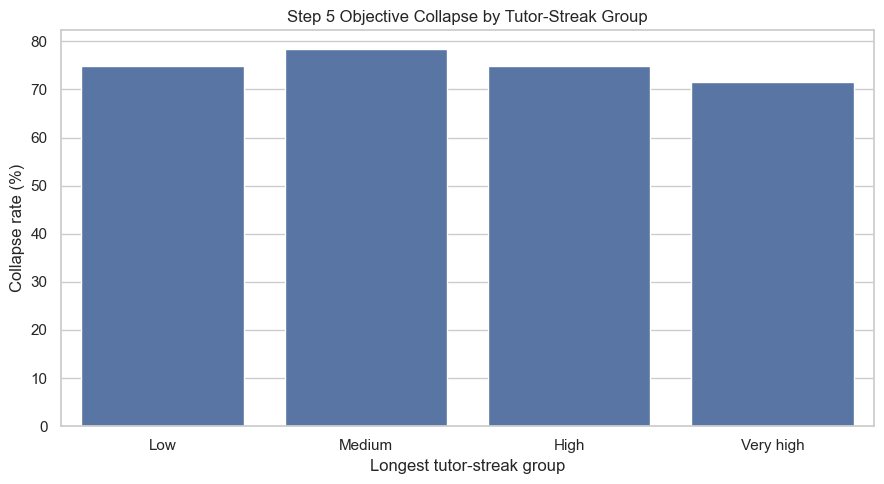

Student–tutor behaviour figures saved in: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\student_tutor_behavior\figures


In [33]:
def plot_student_tutor_behavior(results):
    summary = results["summary"].copy()
    fold_metrics = results["fold_metrics"].copy()
    balance_summary = results["interpretable_balance_summary"].copy()
    step5_linkage = results["step5_linkage"].copy()
    figures_dir = results["figures_dir"]

    if summary.empty:
        print("Student–tutor behaviour plots were skipped because no eligible variable was available.")
        return

    sns.set_theme(style="whitegrid")

    word_share = summary[summary["Variable"].eq("student_word_ratio")].copy()

    if not word_share.empty:
        group_order = word_share["Group"].tolist()

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=word_share, x="Group", y="Log Loss", order=group_order, ax=ax)
        ax.set(title="OOF Log Loss by Student Word Share", xlabel="Student-word-share group", ylabel="Log Loss")
        ax.tick_params(axis="x", rotation=15)
        plt.tight_layout()
        plt.savefig(figures_dir / "student_word_share_log_loss.png", dpi=300, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=word_share, x="Group", y="FPR (%)", order=group_order, ax=ax)
        ax.set(title="False-Positive Rate by Student Word Share", xlabel="Student-word-share group", ylabel="False-positive rate (%)")
        ax.tick_params(axis="x", rotation=15)
        plt.tight_layout()
        plt.savefig(figures_dir / "student_word_share_fpr.png", dpi=300, bbox_inches="tight")
        plt.show()

        fold_word_share = fold_metrics[fold_metrics["Variable"].eq("student_word_ratio")].copy()

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(data=fold_word_share, x="Fold", y="Log Loss", hue="Group", marker="o", linewidth=2, ax=ax)
        ax.set(title="Fold-Wise Log Loss by Student Word Share", xlabel="OOF fold", ylabel="Log Loss")
        ax.set_xticks(sorted(fold_word_share["Fold"].unique()))
        ax.legend(title="Student-share group")
        plt.tight_layout()
        plt.savefig(figures_dir / "student_word_share_foldwise_log_loss.png", dpi=300, bbox_inches="tight")
        plt.show()

    question_data = summary[summary["Variable"].isin(["tutor_question_ratio", "student_response_after_tutor_question_ratio"])].copy()

    if not question_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(data=question_data, x="Group", y="Log Loss", hue="Variable", marker="o", linewidth=2, ax=ax)
        ax.set(title="Question Behaviour and OOF Log Loss", xlabel="Behaviour quartile", ylabel="Log Loss")
        ax.legend(title="Variable")
        plt.tight_layout()
        plt.savefig(figures_dir / "question_behavior_log_loss.png", dpi=300, bbox_inches="tight")
        plt.show()

    if not balance_summary.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=balance_summary, x="Group", y="Negative LL", ax=ax)
        ax.set(title="Negative-Class Log Loss by Interaction Balance", xlabel="Interaction-balance group", ylabel="Negative-class Log Loss")
        ax.tick_params(axis="x", rotation=15)
        plt.tight_layout()
        plt.savefig(figures_dir / "interaction_balance_negative_log_loss.png", dpi=300, bbox_inches="tight")
        plt.show()

    tutor_streak_linkage = step5_linkage[step5_linkage["Variable"].eq("longest_tutor_streak_ratio")].copy() if not step5_linkage.empty else pd.DataFrame()

    if not tutor_streak_linkage.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=tutor_streak_linkage, x="Group", y="Collapse rate (%)", ax=ax)
        ax.set(title="Step 5 Objective Collapse by Tutor-Streak Group", xlabel="Longest tutor-streak group", ylabel="Collapse rate (%)")
        plt.tight_layout()
        plt.savefig(figures_dir / "tutor_streak_step5_collapse.png", dpi=300, bbox_inches="tight")
        plt.show()

    print(f"Student–tutor behaviour figures saved in: {figures_dir}")


plot_student_tutor_behavior(student_tutor_behavior_results)

## 6.6 — Full-Population Session-Complexity Analysis

This section extends the Step 5 session analysis to the complete grouped-OOF population. Step 5 focused only on mixed-label, multi-objective sessions, while this section evaluates all eligible sessions.

The primary complexity variables are responses per session, objectives per session, total turns, total words, session duration, and label structure.

Responses and objectives per session will use the fixed groups `1`, `2`, `3–4`, and `5+`. Continuous session variables will use performance-blind session-level quartiles.

Label structure will distinguish `All-negative`, `All-positive`, and `Mixed-label` sessions. This allows mixed-label sessions to be compared with sessions containing only one target class.

Both response-weighted and session-weighted performance will be reported. Response weighting gives larger sessions more influence, while session weighting gives every session equal importance.

Log Loss, class-specific loss, false-positive rate, false-negative rate, response share, session share, and loss share will be compared across complexity groups.

Step 5 session margin and collapse metrics will be merged by `session_id`. No new positive–negative pair table will be created.

The results describe associations between session complexity and OOF performance. They do not establish that larger or mixed-label sessions directly cause model failure.

In [34]:
def analyze_session_complexity(input_data, step6_dir, step5_session_metrics=None):
    complexity_dir = step6_dir / "session_complexity"
    figures_dir = complexity_dir / "figures"

    complexity_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    data = input_data.copy()

    required_columns = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability"]
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Required columns are missing: {missing_columns}")

    if not data["response_id"].is_unique:
        raise ValueError("response_id is not unique in the analysis data.")

    data["probability"] = data["probability"].clip(1e-15, 1 - 1e-15)

    if "hard_prediction" not in data.columns:
        data["hard_prediction"] = data["probability"].ge(0.50).astype(int)

    if "sample_log_loss" not in data.columns:
        data["sample_log_loss"] = -(data["correct"] * np.log(data["probability"]) + (1 - data["correct"]) * np.log1p(-data["probability"]))

    data["is_false_positive"] = data["correct"].eq(0) & data["hard_prediction"].eq(1)
    data["is_false_negative"] = data["correct"].eq(1) & data["hard_prediction"].eq(0)
    data["positive_loss"] = np.where(data["correct"].eq(1), data["sample_log_loss"], np.nan)
    data["negative_loss"] = np.where(data["correct"].eq(0), data["sample_log_loss"], np.nan)

    data["responses_per_session"] = data.groupby("session_id")["response_id"].transform("size")
    data["objectives_per_session"] = data.groupby("session_id")["objective_key"].transform("nunique")

    session_counts = data.groupby("session_id").agg(n_positive=("correct", "sum"), n_responses=("response_id", "size")).reset_index()
    session_counts["n_negative"] = session_counts["n_responses"] - session_counts["n_positive"]
    session_counts["label_structure"] = np.select([session_counts["n_positive"].eq(0), session_counts["n_negative"].eq(0)], ["All-negative", "All-positive"], default="Mixed-label")

    data = data.drop(columns=["label_structure"], errors="ignore").merge(session_counts[["session_id", "label_structure"]], on="session_id", how="left", validate="many_to_one")
    data["mixed_label_session"] = data["label_structure"].eq("Mixed-label")

    feature_columns = ["responses_per_session", "objectives_per_session", "total_turns", "total_words", "session_duration_minutes"]
    available_features = [column for column in feature_columns if column in data.columns]
    consistency_rows = []

    for feature in available_features:
        data[feature] = pd.to_numeric(data[feature], errors="coerce")
        maximum_unique = data.groupby("session_id")[feature].nunique(dropna=False).max()
        consistency_rows.append({"Variable": feature, "Exists": True, "Missing responses": int(data[feature].isna().sum()), "Unique values": int(data[feature].nunique(dropna=True)), "Session consistent": bool(maximum_unique <= 1)})

        if maximum_unique > 1:
            raise ValueError(f"{feature} is not consistent within every session.")

    for feature in [column for column in feature_columns if column not in data.columns]:
        consistency_rows.append({"Variable": feature, "Exists": False, "Missing responses": np.nan, "Unique values": 0, "Session consistent": False})

    complexity_availability = pd.DataFrame(consistency_rows)
    complexity_availability.to_csv(complexity_dir / "session_complexity_availability.csv", index=False)

    count_labels = ["1", "2", "3–4", "5+"]
    count_bins = [0, 1, 2, 4, np.inf]
    data["response_count_group"] = pd.cut(data["responses_per_session"], bins=count_bins, labels=count_labels)
    data["objective_count_group"] = pd.cut(data["objectives_per_session"], bins=count_bins, labels=count_labels)

    group_definitions = {"response_count_group": {"variable": "responses_per_session", "boundaries": ["1", "2", "3–4", "5+"], "labels": count_labels}, "objective_count_group": {"variable": "objectives_per_session", "boundaries": ["1", "2", "3–4", "5+"], "labels": count_labels}, "label_structure": {"variable": "label_structure", "labels": ["All-negative", "All-positive", "Mixed-label"]}}
    analysis_settings = [("responses_per_session", "response_count_group", count_labels), ("objectives_per_session", "objective_count_group", count_labels), ("label_structure", "label_structure", ["All-negative", "All-positive", "Mixed-label"])]

    for variable in ["total_turns", "total_words", "session_duration_minutes"]:
        if variable not in data.columns or data[variable].notna().sum() == 0:
            continue

        session_values = data[["session_id", variable]].dropna().drop_duplicates("session_id").copy()
        group_codes, group_bins = pd.qcut(session_values[variable], q=4, labels=False, retbins=True, duplicates="drop")
        group_labels = ["Low", "Medium", "High", "Very high"][:len(group_bins) - 1]
        label_map = {group_number: group_labels[group_number] for group_number in range(len(group_labels))}
        group_column = f"{variable}_complexity_group"

        session_values[group_column] = group_codes.map(label_map)
        session_values[group_column] = pd.Categorical(session_values[group_column], categories=group_labels, ordered=True)
        data = data.merge(session_values[["session_id", group_column]], on="session_id", how="left", validate="many_to_one")

        definition_table = session_values.groupby(group_column, observed=True).agg(Sessions=("session_id", "nunique"), Minimum_value=(variable, "min"), Maximum_value=(variable, "max"), Median_value=(variable, "median")).reset_index()
        group_definitions[group_column] = {"variable": variable, "grouping_method": "Session-level quartiles", "boundaries": [float(value) for value in group_bins], "labels": group_labels, "groups": definition_table.to_dict(orient="records")}
        analysis_settings.append((variable, group_column, group_labels))

    with open(complexity_dir / "session_complexity_group_definitions.json", "w", encoding="utf-8") as file:
        json.dump(group_definitions, file, indent=2, ensure_ascii=False)

    def calculate_session_weighted_metrics(group_data):
        session_table = group_data.groupby("session_id").agg(Session_Log_Loss=("sample_log_loss", "mean"), Session_Positive_LL=("positive_loss", "mean"), Session_Negative_LL=("negative_loss", "mean"), Positive_responses=("correct", "sum"), Responses=("response_id", "size"), False_positives=("is_false_positive", "sum"), False_negatives=("is_false_negative", "sum")).reset_index()
        session_table["Negative_responses"] = session_table["Responses"] - session_table["Positive_responses"]
        session_table["Session_FPR"] = np.where(session_table["Negative_responses"].gt(0), session_table["False_positives"] / session_table["Negative_responses"], np.nan)
        session_table["Session_FNR"] = np.where(session_table["Positive_responses"].gt(0), session_table["False_negatives"] / session_table["Positive_responses"], np.nan)

        return {"Session-weighted Log Loss": session_table["Session_Log_Loss"].mean(), "Session-weighted Positive LL": session_table["Session_Positive_LL"].mean(), "Session-weighted Negative LL": session_table["Session_Negative_LL"].mean(), "Session-weighted FPR (%)": 100 * session_table["Session_FPR"].mean(), "Session-weighted FNR (%)": 100 * session_table["Session_FNR"].mean()}

    def summarize_complexity_groups(grouped_data, variable, group_column, group_order):
        total_responses = len(grouped_data)
        total_sessions = grouped_data["session_id"].nunique()
        total_loss = grouped_data["sample_log_loss"].sum()
        summary_rows = []

        for group_name in group_order:
            group_data = grouped_data[grouped_data[group_column].eq(group_name)].copy()

            if group_data.empty:
                continue

            response_metrics = calculate_reference_metrics(group_data)
            session_weighted_metrics = calculate_session_weighted_metrics(group_data)
            group_loss = group_data["sample_log_loss"].sum()

            summary_rows.append({"Variable": variable, "Group": group_name, "Responses": response_metrics["Responses"], "Sessions": response_metrics["Sessions"], "Objectives": response_metrics["Objectives"], "Positive rate (%)": response_metrics["Positive rate (%)"], "Mean probability": response_metrics["Mean predicted probability"], "Response-weighted Log Loss": response_metrics["Log Loss"], "Session-weighted Log Loss": session_weighted_metrics["Session-weighted Log Loss"], "Response-weighted Positive LL": response_metrics["Positive-class Log Loss"], "Session-weighted Positive LL": session_weighted_metrics["Session-weighted Positive LL"], "Response-weighted Negative LL": response_metrics["Negative-class Log Loss"], "Session-weighted Negative LL": session_weighted_metrics["Session-weighted Negative LL"], "AUROC": response_metrics["AUROC"], "Response-weighted FPR (%)": response_metrics["False-positive rate (%)"], "Session-weighted FPR (%)": session_weighted_metrics["Session-weighted FPR (%)"], "Response-weighted FNR (%)": response_metrics["False-negative rate (%)"], "Session-weighted FNR (%)": session_weighted_metrics["Session-weighted FNR (%)"], "Response share (%)": 100 * len(group_data) / total_responses, "Session share (%)": 100 * group_data["session_id"].nunique() / total_sessions, "Loss share (%)": 100 * group_loss / total_loss})

        summary = pd.DataFrame(summary_rows)
        summary["Group"] = pd.Categorical(summary["Group"], categories=group_order, ordered=True)
        summary = summary.sort_values("Group").reset_index(drop=True)

        return summary

    summary_parts = []
    fold_parts = []
    session_group_tables = {}

    for variable, group_column, group_order in analysis_settings:
        variable_data = data[data[group_column].notna()].copy()
        variable_summary = summarize_complexity_groups(variable_data, variable, group_column, group_order)
        summary_parts.append(variable_summary)
        session_group_tables[variable] = variable_data[["session_id", group_column]].drop_duplicates("session_id").rename(columns={group_column: "Group"})

        for fold_id, fold_data in variable_data.groupby("fold_id", sort=True):
            fold_summary = summarize_complexity_groups(fold_data, variable, group_column, group_order)
            fold_reference_loss = fold_data["sample_log_loss"].mean()
            fold_summary["Fold"] = int(fold_id)
            fold_summary["Fold reference Log Loss"] = fold_reference_loss
            fold_summary["Difference from fold reference"] = fold_summary["Response-weighted Log Loss"] - fold_reference_loss
            fold_parts.append(fold_summary)

    complexity_summary = pd.concat(summary_parts, ignore_index=True)
    complexity_summary.to_csv(complexity_dir / "all_session_complexity_summary.csv", index=False)

    response_count_summary = complexity_summary[complexity_summary["Variable"].eq("responses_per_session")].copy()
    objective_count_summary = complexity_summary[complexity_summary["Variable"].eq("objectives_per_session")].copy()
    label_structure_summary = complexity_summary[complexity_summary["Variable"].eq("label_structure")].copy()
    continuous_complexity_summary = complexity_summary[complexity_summary["Variable"].isin(["total_turns", "total_words", "session_duration_minutes"])].copy()

    response_count_summary.to_csv(complexity_dir / "responses_per_session_summary.csv", index=False)
    objective_count_summary.to_csv(complexity_dir / "objectives_per_session_summary.csv", index=False)
    label_structure_summary.to_csv(complexity_dir / "label_structure_summary.csv", index=False)
    continuous_complexity_summary.to_csv(complexity_dir / "continuous_complexity_summary.csv", index=False)

    overall_response_metrics = calculate_reference_metrics(data)
    overall_session_metrics = calculate_session_weighted_metrics(data)

    weighting_scorecard = pd.DataFrame([{"Evaluation": "Response-weighted", "Units": len(data), "Log Loss": overall_response_metrics["Log Loss"], "Positive LL": overall_response_metrics["Positive-class Log Loss"], "Negative LL": overall_response_metrics["Negative-class Log Loss"], "FPR (%)": overall_response_metrics["False-positive rate (%)"], "FNR (%)": overall_response_metrics["False-negative rate (%)"]}, {"Evaluation": "Session-weighted", "Units": data["session_id"].nunique(), "Log Loss": overall_session_metrics["Session-weighted Log Loss"], "Positive LL": overall_session_metrics["Session-weighted Positive LL"], "Negative LL": overall_session_metrics["Session-weighted Negative LL"], "FPR (%)": overall_session_metrics["Session-weighted FPR (%)"], "FNR (%)": overall_session_metrics["Session-weighted FNR (%)"]}])
    weighting_scorecard.to_csv(complexity_dir / "response_vs_session_weighting.csv", index=False)

    complexity_fold_metrics = pd.concat(fold_parts, ignore_index=True)
    complexity_fold_metrics.to_csv(complexity_dir / "session_complexity_fold_metrics.csv", index=False)

    complexity_fold_stability = complexity_fold_metrics.groupby(["Variable", "Group"], observed=True).agg(Folds=("Fold", "nunique"), Mean_fold_response_weighted_Log_Loss=("Response-weighted Log Loss", "mean"), Fold_Log_Loss_SD=("Response-weighted Log Loss", "std"), Folds_worse_than_reference=("Difference from fold reference", lambda values: int(values.gt(0).sum())), Mean_difference_from_reference=("Difference from fold reference", "mean"), Mean_fold_session_weighted_Log_Loss=("Session-weighted Log Loss", "mean"), Mean_fold_Negative_LL=("Response-weighted Negative LL", "mean"), Mean_fold_FPR=("Response-weighted FPR (%)", "mean")).reset_index()
    complexity_fold_stability["Stable high-risk group"] = complexity_fold_stability["Folds_worse_than_reference"].ge(4)
    complexity_fold_stability.to_csv(complexity_dir / "session_complexity_fold_stability.csv", index=False)

    step5_linkage_parts = []

    if step5_session_metrics is not None:
        step5_data = step5_session_metrics.copy()

        if "is_session_collapse" not in step5_data.columns:
            step5_data["is_session_collapse"] = step5_data["session_margin"].abs().lt(0.02)

        if "is_session_reversed" not in step5_data.columns:
            step5_data["is_session_reversed"] = step5_data["session_margin"].lt(0)

        for variable, group_table in session_group_tables.items():
            linkage_data = step5_data.merge(group_table, on="session_id", how="inner", validate="one_to_one")

            if linkage_data.empty:
                continue

            linkage_summary = linkage_data.groupby("Group", observed=True).agg(Mixed_sessions=("session_id", "size"), Mean_session_margin=("session_margin", "mean"), Median_session_margin=("session_margin", "median"), Mean_pairwise_accuracy=("session_pairwise_accuracy", "mean"), Collapse_rate=("is_session_collapse", "mean"), Reversal_rate=("is_session_reversed", "mean"), Mean_session_Log_Loss=("session_log_loss", "mean"), Mean_negative_objective_loss=("negative_mean_loss", "mean")).reset_index()
            linkage_summary["Variable"] = variable
            linkage_summary["Mean pairwise accuracy (%)"] = 100 * linkage_summary.pop("Mean_pairwise_accuracy")
            linkage_summary["Collapse rate (%)"] = 100 * linkage_summary.pop("Collapse_rate")
            linkage_summary["Reversal rate (%)"] = 100 * linkage_summary.pop("Reversal_rate")
            step5_linkage_parts.append(linkage_summary)

    if step5_linkage_parts:
        complexity_step5_linkage = pd.concat(step5_linkage_parts, ignore_index=True)
    else:
        complexity_step5_linkage = pd.DataFrame()

    complexity_step5_linkage.to_csv(complexity_dir / "session_complexity_step5_linkage.csv", index=False)

    results = {"data": data, "availability": complexity_availability, "summary": complexity_summary, "response_count_summary": response_count_summary, "objective_count_summary": objective_count_summary, "label_structure_summary": label_structure_summary, "continuous_summary": continuous_complexity_summary, "weighting_scorecard": weighting_scorecard, "fold_metrics": complexity_fold_metrics, "fold_stability": complexity_fold_stability, "step5_linkage": complexity_step5_linkage, "output_dir": complexity_dir, "figures_dir": figures_dir}

    return results

In [35]:
session_complexity_input = student_tutor_behavior_results["data"].copy() if "student_tutor_behavior_results" in globals() else transcript_noise_results["data"].copy() if "transcript_noise_results" in globals() else reference_data.copy()
step5_complexity_metrics = session_metrics.copy() if "session_metrics" in globals() else None

session_complexity_results = analyze_session_complexity(session_complexity_input, step6_dir, step5_complexity_metrics)

session_complexity_summary = session_complexity_results["summary"]
session_complexity_weighting = session_complexity_results["weighting_scorecard"]
session_complexity_fold_stability = session_complexity_results["fold_stability"]
session_complexity_step5_linkage = session_complexity_results["step5_linkage"]

display(session_complexity_results["availability"])
display(session_complexity_weighting)

complexity_display_columns = ["Variable", "Group", "Responses", "Sessions", "Positive rate (%)", "Response-weighted Log Loss", "Session-weighted Log Loss", "Response-weighted Positive LL", "Response-weighted Negative LL", "AUROC", "Response-weighted FPR (%)", "Response share (%)", "Session share (%)", "Loss share (%)"]
display(session_complexity_summary[complexity_display_columns])

display(session_complexity_fold_stability)

if not session_complexity_step5_linkage.empty:
    display(session_complexity_step5_linkage)

print(f"Session-complexity groups analysed: {len(session_complexity_summary):,}")
print(f"Output folder: {session_complexity_results['output_dir']}")

,Variable,Exists,Missing responses,Unique values,Session consistent
0,responses_per_session,True,0,9,True
1,objectives_per_session,True,0,9,True
2,total_turns,True,0,501,True
3,total_words,True,0,4462,True
4,session_duration_minutes,True,0,1817,True


,Evaluation,Units,Log Loss,Positive LL,Negative LL,FPR (%),FNR (%)
0,Response-weighted,35072,0.5555,0.3270,1.0950,81.0446,5.2766
1,Session-weighted,22821,0.5761,0.3568,1.0821,80.2479,6.8582


,Variable,Group,Responses,Sessions,Positive rate (%),Response-weighted Log Loss,Session-weighted Log Loss,Response-weighted Positive LL,Response-weighted Negative LL,AUROC,Response-weighted FPR (%),Response share (%),Session share (%),Loss share (%)
0,responses_per_session,1,14457,14457,62.6409,0.6026,0.6026,0.3955,0.9499,0.7031,73.0420,41.2209,63.3495,44.7214
1,responses_per_session,2,11280,5640,73.0674,0.5460,0.5460,0.3181,1.1645,0.6728,86.8005,32.1624,24.7141,31.6168
2,responses_per_session,3–4,8036,2485,78.1359,0.4972,0.5001,0.2625,1.3361,0.6644,93.3409,22.9129,10.8891,20.5093
3,responses_per_session,5+,1299,239,81.6012,0.4728,0.4701,0.1924,1.7162,0.6069,98.3264,3.7038,1.0473,3.1526
4,objectives_per_session,1,14457,14457,62.6409,0.6026,0.6026,0.3955,0.9499,0.7031,73.0420,41.2209,63.3495,44.7214
5,objectives_per_session,2,11280,5640,73.0674,0.5460,0.5460,0.3181,1.1645,0.6728,86.8005,32.1624,24.7141,31.6168
6,objectives_per_session,3–4,8036,2485,78.1359,0.4972,0.5001,0.2625,1.3361,0.6644,93.3409,22.9129,10.8891,20.5093
7,objectives_per_session,5+,1299,239,81.6012,0.4728,0.4701,0.1924,1.7162,0.6069,98.3264,3.7038,1.0473,3.1526
8,label_structure,All-negative,6750,6032,0.0000,0.9759,0.9624,NaN,0.9759,NaN,74.8889,19.2461,26.4318,33.8146
9,label_structure,All-positive,20026,13582,100.0000,0.3248,0.3558,0.3248,NaN,NaN,NaN,57.0997,59.5154,33.3903


,Variable,Group,Folds,Mean_fold_response_weighted_Log_Loss,Fold_Log_Loss_SD,Folds_worse_than_reference,Mean_difference_from_reference,Mean_fold_session_weighted_Log_Loss,Mean_fold_Negative_LL,Mean_fold_FPR,Stable high-risk group
0,label_structure,All-negative,5,0.9757,0.0139,5,0.4203,0.9623,0.9757,74.8873,True
1,label_structure,All-positive,5,0.3248,0.0039,0,-0.2306,0.3558,NaN,NaN,False
2,label_structure,Mixed-label,5,0.7700,0.0088,5,0.2146,0.7823,1.3129,92.3228,True
3,objectives_per_session,1,5,0.6026,0.0068,5,0.0471,0.6026,0.9497,73.0342,True
4,objectives_per_session,2,5,0.5460,0.0094,0,-0.0095,0.5460,1.1641,86.7729,False
5,objectives_per_session,3–4,5,0.4973,0.0138,0,-0.0581,0.5003,1.3381,93.3615,False
6,objectives_per_session,5+,5,0.4726,0.0311,0,-0.0828,0.4700,1.7119,97.9784,False
7,responses_per_session,1,5,0.6026,0.0068,5,0.0471,0.6026,0.9497,73.0342,True
8,responses_per_session,2,5,0.5460,0.0094,0,-0.0095,0.5460,1.1641,86.7729,False
9,responses_per_session,3–4,5,0.4973,0.0138,0,-0.0581,0.5003,1.3381,93.3615,False


,Group,Mixed_sessions,Mean_session_margin,Median_session_margin,Mean_session_Log_Loss,Mean_negative_objective_loss,Variable,Mean pairwise accuracy (%),Collapse rate (%),Reversal rate (%)
0,2,1922,0.0091,0.0046,0.8100,1.2299,responses_per_session,67.7940,72.7367,32.2060
1,3–4,1161,0.0077,0.0056,0.7463,1.3803,responses_per_session,66.9610,77.0887,30.5771
2,5+,124,0.0071,0.0053,0.6921,1.8227,responses_per_session,70.6765,88.7097,23.3871
3,2,1922,0.0091,0.0046,0.8100,1.2299,objectives_per_session,67.7940,72.7367,32.2060
4,3–4,1161,0.0077,0.0056,0.7463,1.3803,objectives_per_session,66.9610,77.0887,30.5771
5,5+,124,0.0071,0.0053,0.6921,1.8227,objectives_per_session,70.6765,88.7097,23.3871
6,Mixed-label,3207,0.0085,0.0051,0.7824,1.3073,label_structure,67.6039,74.9298,31.2753
7,Low,775,0.0100,0.0055,0.7788,1.3169,total_turns,67.8108,71.0968,31.2258
8,Medium,828,0.0074,0.0046,0.7878,1.3359,total_turns,68.3162,76.4493,30.0725
9,High,851,0.0088,0.0055,0.7827,1.3176,total_turns,67.2216,74.8531,31.1398


Session-complexity groups analysed: 23
Output folder: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\session_complexity


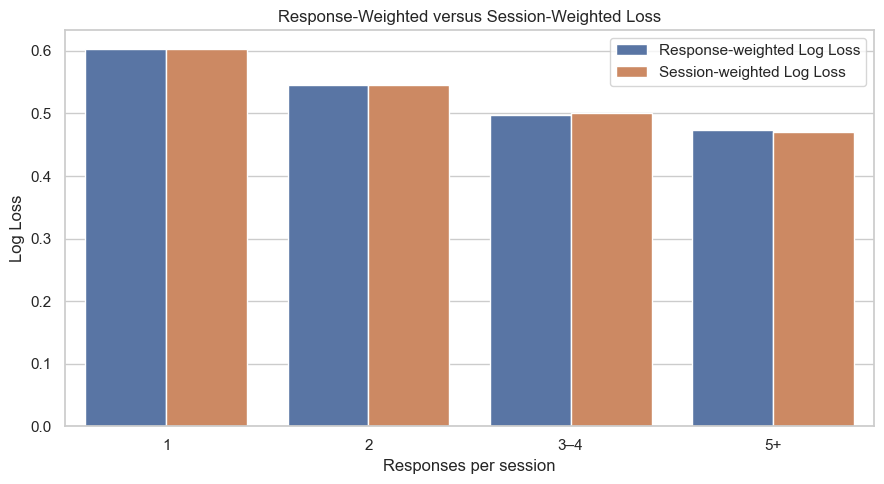

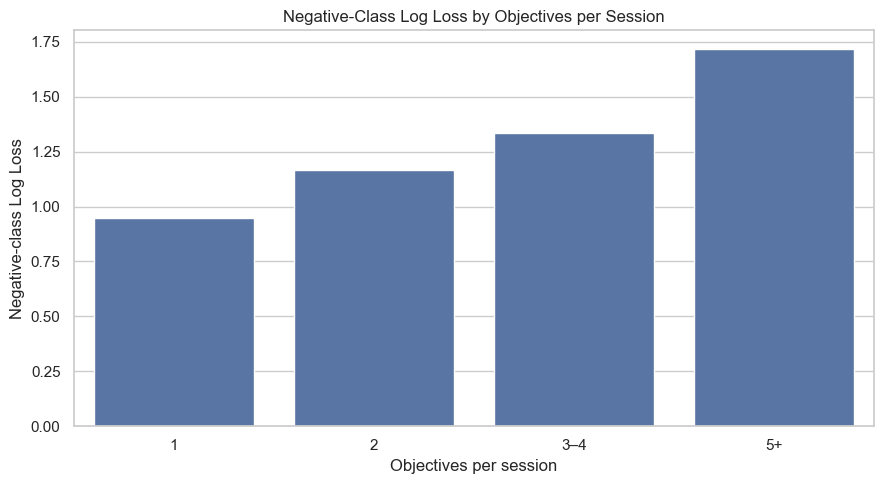

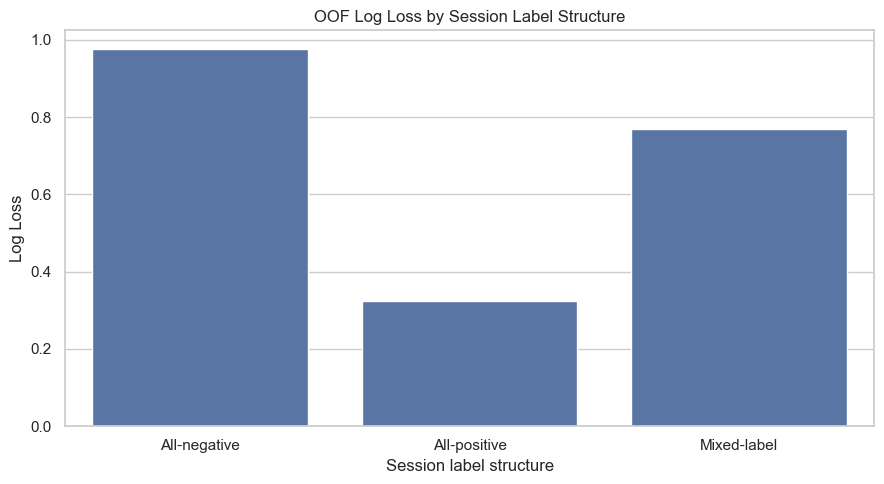

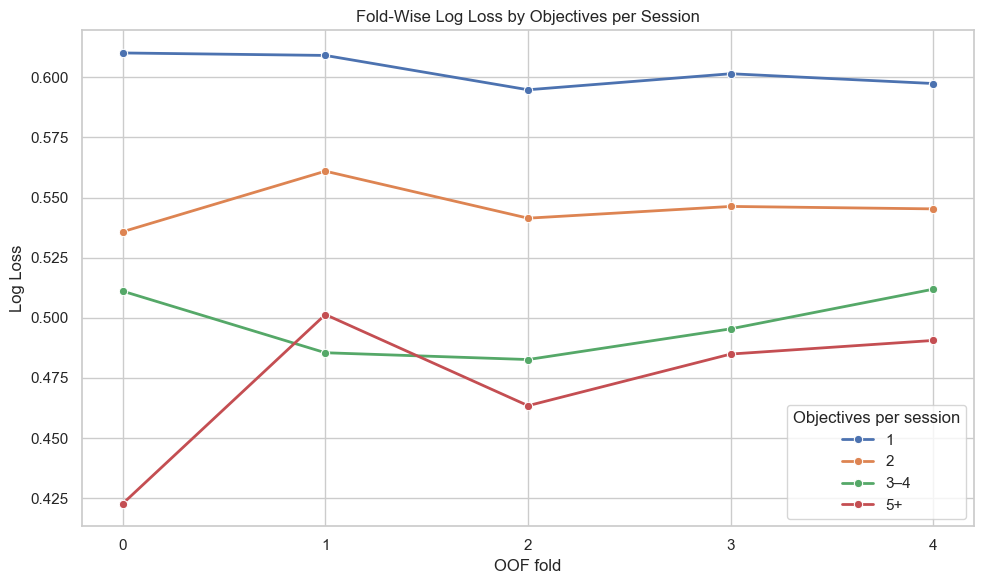

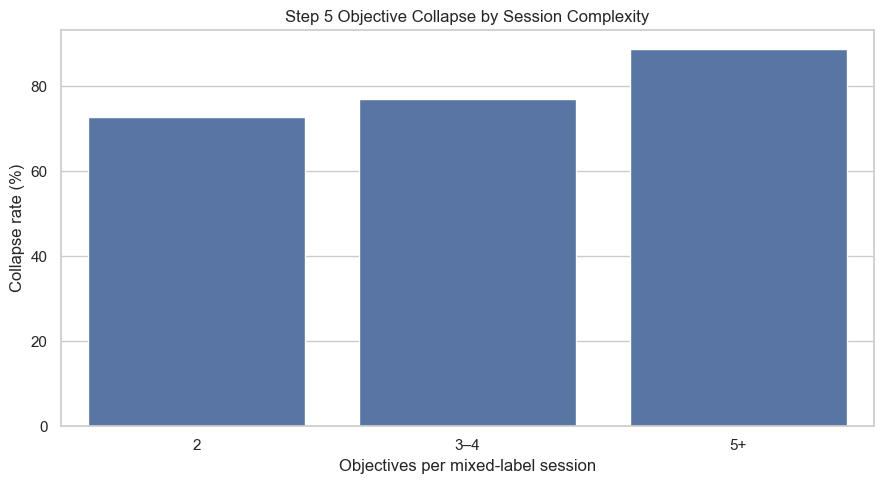

Session-complexity figures saved in: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\session_complexity\figures


In [36]:
def plot_session_complexity(results):
    response_summary = results["response_count_summary"].copy()
    objective_summary = results["objective_count_summary"].copy()
    label_summary = results["label_structure_summary"].copy()
    fold_metrics = results["fold_metrics"].copy()
    step5_linkage = results["step5_linkage"].copy()
    figures_dir = results["figures_dir"]

    sns.set_theme(style="whitegrid")

    weighting_data = response_summary[["Group", "Response-weighted Log Loss", "Session-weighted Log Loss"]].melt(id_vars="Group", var_name="Weighting", value_name="Log Loss")

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=weighting_data, x="Group", y="Log Loss", hue="Weighting", ax=ax)
    ax.set(title="Response-Weighted versus Session-Weighted Loss", xlabel="Responses per session", ylabel="Log Loss")
    ax.legend(title="")
    plt.tight_layout()
    plt.savefig(figures_dir / "response_vs_session_weighted_loss.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=objective_summary, x="Group", y="Response-weighted Negative LL", ax=ax)
    ax.set(title="Negative-Class Log Loss by Objectives per Session", xlabel="Objectives per session", ylabel="Negative-class Log Loss")
    plt.tight_layout()
    plt.savefig(figures_dir / "objective_count_negative_log_loss.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=label_summary, x="Group", y="Response-weighted Log Loss", ax=ax)
    ax.set(title="OOF Log Loss by Session Label Structure", xlabel="Session label structure", ylabel="Log Loss")
    plt.tight_layout()
    plt.savefig(figures_dir / "label_structure_log_loss.png", dpi=300, bbox_inches="tight")
    plt.show()

    objective_fold_data = fold_metrics[fold_metrics["Variable"].eq("objectives_per_session")].copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=objective_fold_data, x="Fold", y="Response-weighted Log Loss", hue="Group", marker="o", linewidth=2, ax=ax)
    ax.set(title="Fold-Wise Log Loss by Objectives per Session", xlabel="OOF fold", ylabel="Log Loss")
    ax.set_xticks(sorted(objective_fold_data["Fold"].unique()))
    ax.legend(title="Objectives per session")
    plt.tight_layout()
    plt.savefig(figures_dir / "objective_count_foldwise_log_loss.png", dpi=300, bbox_inches="tight")
    plt.show()

    step5_objective_linkage = step5_linkage[step5_linkage["Variable"].eq("objectives_per_session")].copy() if not step5_linkage.empty else pd.DataFrame()

    if not step5_objective_linkage.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=step5_objective_linkage, x="Group", y="Collapse rate (%)", ax=ax)
        ax.set(title="Step 5 Objective Collapse by Session Complexity", xlabel="Objectives per mixed-label session", ylabel="Collapse rate (%)")
        plt.tight_layout()
        plt.savefig(figures_dir / "objective_count_step5_collapse.png", dpi=300, bbox_inches="tight")
        plt.show()

    print(f"Session-complexity figures saved in: {figures_dir}")


plot_session_complexity(session_complexity_results)

## 6.7 — Class-Conditional and Prevalence-Aware Group Synthesis

This section combines the main subgroup analyses into one diagnostic registry. It does not create another independent set of groups. Instead, it reuses the group assignments produced by the transcript-length, objective-support, transcript-noise, student–tutor behaviour, and session-complexity analyses.

Overall Log Loss alone cannot show which target class drives a performance gap. Therefore, every eligible group will be decomposed into positive-class and negative-class Log Loss, false-positive and false-negative rates, and high-confidence error rates.

Group label prevalence is also important because the baseline tends to assign relatively high positive probabilities. A group with a high positive-label rate may achieve reasonable raw accuracy even when most of its negative responses are misclassified.

For each group, the analysis will compare its observed positive-label rate with its mean predicted probability. Balanced accuracy will be reported alongside raw accuracy:

\[
\operatorname{BalancedAccuracy}_g
=
\frac{\operatorname{TPR}_g+\operatorname{TNR}_g}{2}
\]

The headline synthesis will focus on transcript length, objective support, background-turn ratio, student-word share, objectives per session, and session label structure. Secondary factors will remain available in the complete registry.

Three synthesis figures will be produced:

1. A class-loss dumbbell forest plot comparing positive- and negative-class loss differences from the overall OOF reference.
2. A prevalence–probability calibration map showing positive-label rate, mean predicted probability, support, and balanced accuracy.
3. A false-positive versus false-negative butterfly plot showing both ordinary and high-confidence error directions.

The analysis remains descriptive. Group differences indicate association with OOF model error and do not establish causal effects.

In [37]:
import json
from pathlib import Path
from sklearn.metrics import brier_score_loss, roc_auc_score

def to_json_safe(value):
    if isinstance(value, dict):
        return {str(key): to_json_safe(item) for key, item in value.items()}

    if isinstance(value, (list, tuple, set)):
        return [to_json_safe(item) for item in value]

    if isinstance(value, np.ndarray):
        return [to_json_safe(item) for item in value.tolist()]

    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(value, (pd.Timestamp, pd.Timedelta, Path)):
        return str(value)

    if value is None or value is pd.NA:
        return None

    if isinstance(value, float) and not np.isfinite(value):
        return None

    return value


def build_group_performance_registry(reference_data, step6_dir):
    output_dir = step6_dir / "class_conditional_prevalence"
    output_dir.mkdir(parents=True, exist_ok=True)

    data = reference_data.copy()

    required_columns = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability"]
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Required columns are missing: {missing_columns}")

    if not data["response_id"].is_unique:
        raise ValueError("response_id must be unique in reference_data.")

    merge_audit_rows = []

    previous_results = {
        "Transcript length": globals().get("transcript_length_results"),
        "Objective frequency": globals().get("objective_frequency_results"),
        "Transcript noise": globals().get("transcript_noise_results"),
        "Student–tutor behaviour": globals().get("student_tutor_behavior_results"),
        "Session complexity": globals().get("session_complexity_results")
    }

    for source_name, result_object in previous_results.items():
        if not isinstance(result_object, dict):
            merge_audit_rows.append({"Source": source_name, "Available": False, "Columns added": 0, "Reason": "Result dictionary not found"})
            continue

        extra_data = result_object.get("data")

        if not isinstance(extra_data, pd.DataFrame) or "response_id" not in extra_data.columns:
            merge_audit_rows.append({"Source": source_name, "Available": False, "Columns added": 0, "Reason": "Response-level data not found"})
            continue

        if not extra_data["response_id"].is_unique:
            merge_audit_rows.append({"Source": source_name, "Available": False, "Columns added": 0, "Reason": "response_id is not unique"})
            continue

        new_columns = [column for column in extra_data.columns if column not in data.columns and column != "response_id"]

        if new_columns:
            data = data.merge(extra_data[["response_id"] + new_columns], on="response_id", how="left", validate="one_to_one")

        merge_audit_rows.append({"Source": source_name, "Available": True, "Columns added": len(new_columns), "Reason": "Merged successfully"})

    data["correct"] = pd.to_numeric(data["correct"], errors="raise").astype(int)
    data["probability"] = pd.to_numeric(data["probability"], errors="coerce").clip(1e-15, 1 - 1e-15)

    if data["probability"].isna().any():
        raise ValueError("probability contains missing or non-numeric values.")

    data["hard_prediction"] = data["probability"].ge(0.50).astype(int)
    data["sample_log_loss"] = -(data["correct"] * np.log(data["probability"]) + (1 - data["correct"]) * np.log1p(-data["probability"]))

    data["responses_per_session"] = data.groupby("session_id")["response_id"].transform("size")
    data["objectives_per_session"] = data.groupby("session_id")["objective_key"].transform("nunique")

    session_label_counts = data.groupby("session_id").agg(n_positive=("correct", "sum"), n_responses=("correct", "size")).reset_index()
    session_label_counts["n_negative"] = session_label_counts["n_responses"] - session_label_counts["n_positive"]
    session_label_counts["label_structure"] = np.select([session_label_counts["n_positive"].eq(0), session_label_counts["n_negative"].eq(0)], ["All-negative", "All-positive"], default="Mixed-label")

    data = data.drop(columns=["label_structure"], errors="ignore")
    data = data.merge(session_label_counts[["session_id", "label_structure"]], on="session_id", how="left", validate="many_to_one")

    factor_assignments = []
    factor_audit_rows = []
    group_definition_rows = []

    headline_variables = {
        "transcript_length",
        "objective_support",
        "background_turn_ratio",
        "student_word_ratio",
        "objectives_per_session",
        "label_structure"
    }

    display_names = {
        "transcript_length": "Transcript length",
        "objective_support": "Objective support",
        "background_turn_ratio": "Background-turn ratio",
        "turns_per_minute": "Turns per minute",
        "speaker_switch_rate": "Speaker-switch rate",
        "longest_student_streak_ratio": "Longest student streak",
        "student_word_ratio": "Student-word share",
        "student_turn_ratio": "Student-turn share",
        "avg_student_words_per_turn": "Average student-turn length",
        "avg_tutor_words_per_turn": "Average tutor-turn length",
        "student_short_turn_ratio": "Student short-turn ratio",
        "student_long_turn_ratio": "Student long-turn ratio",
        "student_numeric_turn_ratio": "Student numeric-turn ratio",
        "student_question_ratio": "Student-question ratio",
        "tutor_question_ratio": "Tutor-question ratio",
        "student_response_after_tutor_question_ratio": "Student response-after-question ratio",
        "longest_tutor_streak_ratio": "Longest tutor streak",
        "responses_per_session": "Responses per session",
        "objectives_per_session": "Objectives per session",
        "total_turns": "Total turns",
        "total_words": "Total words",
        "session_duration_minutes": "Session duration",
        "label_structure": "Session label structure"
    }

    def register_factor(family, variable, group_table, group_order, merge_key, source):
        if not isinstance(group_table, pd.DataFrame) or group_table.empty:
            factor_audit_rows.append({"Family": family, "Variable": variable, "Available": False, "Groups": 0, "Source": source, "Reason": "Group table is empty"})
            return

        if merge_key not in group_table.columns or "Group" not in group_table.columns:
            factor_audit_rows.append({"Family": family, "Variable": variable, "Available": False, "Groups": 0, "Source": source, "Reason": "Required columns are missing"})
            return

        clean_table = group_table[[merge_key, "Group"]].dropna(subset=["Group"]).copy()
        conflict_count = clean_table.groupby(merge_key)["Group"].nunique(dropna=False).max()

        if pd.notna(conflict_count) and conflict_count > 1:
            factor_audit_rows.append({"Family": family, "Variable": variable, "Available": False, "Groups": 0, "Source": source, "Reason": f"Conflicting groups within {merge_key}"})
            return

        clean_table = clean_table.drop_duplicates(merge_key)
        clean_table["Group"] = clean_table["Group"].astype("string")

        active_groups = clean_table["Group"].dropna().unique().tolist()
        active_order = [str(group) for group in group_order if str(group) in active_groups]

        if len(active_order) < 2:
            factor_audit_rows.append({"Family": family, "Variable": variable, "Available": False, "Groups": len(active_order), "Source": source, "Reason": "Fewer than two populated groups"})
            return

        if merge_key == "response_id":
            response_groups = data[["response_id"]].merge(clean_table, on="response_id", how="inner", validate="one_to_one")
        else:
            response_groups = data[["response_id", "session_id"]].merge(clean_table, on="session_id", how="inner", validate="many_to_one")
            response_groups = response_groups[["response_id", "Group"]]

        order_map = {group: index for index, group in enumerate(active_order)}

        response_groups["Family"] = family
        response_groups["Variable"] = variable
        response_groups["Display factor"] = display_names.get(variable, variable.replace("_", " ").title())
        response_groups["Group order"] = response_groups["Group"].map(order_map)
        response_groups["Headline"] = variable in headline_variables
        response_groups["Source"] = source

        factor_assignments.append(response_groups)

        factor_audit_rows.append({"Family": family, "Variable": variable, "Available": True, "Groups": len(active_order), "Source": source, "Reason": "Registered successfully"})

    def create_session_quantile_groups(variable, labels, zero_aware=False):
        if variable not in data.columns:
            return pd.DataFrame(), [], []

        numeric_data = data[["session_id", variable]].copy()
        numeric_data[variable] = pd.to_numeric(numeric_data[variable], errors="coerce")
        numeric_data[variable] = numeric_data[variable].replace([np.inf, -np.inf], np.nan)
        numeric_data = numeric_data.dropna()

        if numeric_data.empty:
            return pd.DataFrame(), [], []

        conflict_count = numeric_data.groupby("session_id")[variable].nunique(dropna=False).max()

        if pd.notna(conflict_count) and conflict_count > 1:
            return pd.DataFrame(), [], []

        session_values = numeric_data.drop_duplicates("session_id").reset_index(drop=True)

        if session_values[variable].nunique() < 2:
            return pd.DataFrame(), [], []

        definition_rows = []

        zero_share = session_values[variable].eq(0).mean()
        nonzero_values = session_values[session_values[variable].gt(0)].copy()

        use_zero_groups = zero_aware and zero_share >= 0.10 and len(nonzero_values) >= 30 and nonzero_values[variable].nunique() >= 3

        if use_zero_groups:
            codes, bins = pd.qcut(nonzero_values[variable], q=3, labels=False, retbins=True, duplicates="drop")
            nonzero_labels = ["Low non-zero", "Medium", "High"][:len(bins) - 1]

            if len(nonzero_labels) < 2:
                return pd.DataFrame(), [], []

            session_values["Group"] = pd.Series(pd.NA, index=session_values.index, dtype="string")
            session_values.loc[session_values[variable].eq(0), "Group"] = "Zero"
            session_values.loc[nonzero_values.index, "Group"] = codes.map({index: label for index, label in enumerate(nonzero_labels)}).astype("string")

            group_order = ["Zero"] + nonzero_labels
            boundaries = [float(value) for value in bins]
            grouping_method = "Zero plus non-zero tertiles"
        else:
            codes, bins = pd.qcut(session_values[variable], q=4, labels=False, retbins=True, duplicates="drop")
            active_labels = labels[:len(bins) - 1]

            if len(active_labels) < 2:
                return pd.DataFrame(), [], []

            session_values["Group"] = codes.map({index: label for index, label in enumerate(active_labels)}).astype("string")
            group_order = active_labels
            boundaries = [float(value) for value in bins]
            grouping_method = "Session-level quartiles"

        for group_name in group_order:
            group_values = session_values[session_values["Group"].eq(group_name)]

            if group_values.empty:
                continue

            definition_rows.append({
                "Variable": variable,
                "Group": group_name,
                "Sessions": int(group_values["session_id"].nunique()),
                "Minimum value": float(group_values[variable].min()),
                "Maximum value": float(group_values[variable].max()),
                "Median value": float(group_values[variable].median()),
                "Grouping method": grouping_method,
                "Boundaries": boundaries
            })

        return session_values[["session_id", "Group"]], group_order, definition_rows

    transcript_group_column = next((column for column in ["transcript_length_group", "transcript_length_band"] if column in data.columns), None)

    if transcript_group_column is not None:
        transcript_table = data[["response_id", transcript_group_column]].rename(columns={transcript_group_column: "Group"})
        transcript_order = [str(value) for value in data[transcript_group_column].cat.categories] if isinstance(data[transcript_group_column].dtype, pd.CategoricalDtype) else transcript_table["Group"].astype("string").dropna().drop_duplicates().tolist()
        register_factor("Transcript structure", "transcript_length", transcript_table, transcript_order, "response_id", transcript_group_column)
    else:
        transcript_table, transcript_order, definitions = create_session_quantile_groups("total_words", ["Short", "Medium", "Long", "Very long"])
        register_factor("Transcript structure", "transcript_length", transcript_table, transcript_order, "session_id", "Derived from total_words")
        group_definition_rows.extend(definitions)

    support_group_candidates = ["objective_support_group", "train_support_group", "fold_safe_support_group", "objective_frequency_group", "objective_support_band"]
    support_group_column = next((column for column in support_group_candidates if column in data.columns), None)

    if support_group_column is not None:
        support_table = data[["response_id", support_group_column]].rename(columns={support_group_column: "Group"})
        support_order = [str(value) for value in data[support_group_column].cat.categories] if isinstance(data[support_group_column].dtype, pd.CategoricalDtype) else support_table["Group"].astype("string").dropna().drop_duplicates().tolist()
        register_factor("Objective support", "objective_support", support_table, support_order, "response_id", support_group_column)
    else:
        global_support = data.groupby("objective_key")["response_id"].transform("size")
        heldout_support = data.groupby(["objective_key", "fold_id"])["response_id"].transform("size")
        train_support = global_support - heldout_support

        support_labels = ["Unseen", "Very rare", "Rare", "Medium support", "Common"]
        support_table = data[["response_id"]].copy()
        support_table["Group"] = pd.cut(train_support, bins=[-1, 0, 9, 49, 199, np.inf], labels=support_labels)

        register_factor("Objective support", "objective_support", support_table, support_labels, "response_id", "Derived fold-safe objective support")

    noise_variables = ["background_turn_ratio", "turns_per_minute", "speaker_switch_rate", "longest_student_streak_ratio"]

    for variable in noise_variables:
        group_table, group_order, definitions = create_session_quantile_groups(variable, ["Low", "Medium", "High", "Very high"], zero_aware=True)
        register_factor("Transcript-noise proxy", variable, group_table, group_order, "session_id", "Derived performance-blind groups")
        group_definition_rows.extend(definitions)

    behavior_variables = [
        "student_word_ratio",
        "student_turn_ratio",
        "avg_student_words_per_turn",
        "avg_tutor_words_per_turn",
        "student_short_turn_ratio",
        "student_long_turn_ratio",
        "student_numeric_turn_ratio",
        "student_question_ratio",
        "tutor_question_ratio",
        "student_response_after_tutor_question_ratio",
        "longest_tutor_streak_ratio"
    ]

    for variable in behavior_variables:
        labels = ["Lowest student share", "Low–medium student share", "Medium–high student share", "Highest student share"] if variable in ["student_word_ratio", "student_turn_ratio"] else ["Low", "Medium", "High", "Very high"]
        group_table, group_order, definitions = create_session_quantile_groups(variable, labels, zero_aware=False)
        register_factor("Student–tutor behaviour", variable, group_table, group_order, "session_id", "Derived performance-blind quartiles")
        group_definition_rows.extend(definitions)

    count_labels = ["1", "2", "3–4", "5+"]

    response_count_table = data[["response_id"]].copy()
    response_count_table["Group"] = pd.cut(data["responses_per_session"], bins=[0, 1, 2, 4, np.inf], labels=count_labels)
    register_factor("Session complexity", "responses_per_session", response_count_table, count_labels, "response_id", "Fixed count groups")

    objective_count_table = data[["response_id"]].copy()
    objective_count_table["Group"] = pd.cut(data["objectives_per_session"], bins=[0, 1, 2, 4, np.inf], labels=count_labels)
    register_factor("Session complexity", "objectives_per_session", objective_count_table, count_labels, "response_id", "Fixed count groups")

    label_order = ["All-negative", "All-positive", "Mixed-label"]
    label_table = data[["response_id", "label_structure"]].rename(columns={"label_structure": "Group"})
    register_factor("Session complexity", "label_structure", label_table, label_order, "response_id", "Derived session label structure")

    for variable in ["total_turns", "total_words", "session_duration_minutes"]:
        group_table, group_order, definitions = create_session_quantile_groups(variable, ["Low", "Medium", "High", "Very high"])
        register_factor("Session complexity", variable, group_table, group_order, "session_id", "Derived performance-blind quartiles")
        group_definition_rows.extend(definitions)

    if not factor_assignments:
        raise ValueError("No valid subgroup assignments could be created.")

    assignment_registry = pd.concat(factor_assignments, ignore_index=True)

    def calculate_group_metrics(group_data):
        positive_mask = group_data["correct"].eq(1)
        negative_mask = group_data["correct"].eq(0)
        predicted_positive = group_data["hard_prediction"].eq(1)
        predicted_negative = group_data["hard_prediction"].eq(0)

        responses = len(group_data)
        positive_responses = int(positive_mask.sum())
        negative_responses = int(negative_mask.sum())

        true_positive = int((positive_mask & predicted_positive).sum())
        true_negative = int((negative_mask & predicted_negative).sum())
        false_positive = int((negative_mask & predicted_positive).sum())
        false_negative = int((positive_mask & predicted_negative).sum())

        tpr = true_positive / positive_responses if positive_responses else np.nan
        tnr = true_negative / negative_responses if negative_responses else np.nan
        fpr = false_positive / negative_responses if negative_responses else np.nan
        fnr = false_negative / positive_responses if positive_responses else np.nan

        balanced_accuracy = (tpr + tnr) / 2 if positive_responses and negative_responses else np.nan
        positive_loss = group_data.loc[positive_mask, "sample_log_loss"].mean() if positive_responses else np.nan
        negative_loss = group_data.loc[negative_mask, "sample_log_loss"].mean() if negative_responses else np.nan
        high_confidence_fp = group_data.loc[negative_mask, "probability"].ge(0.80).mean() if negative_responses else np.nan
        high_confidence_fn = group_data.loc[positive_mask, "probability"].le(0.20).mean() if positive_responses else np.nan
        auroc = roc_auc_score(group_data["correct"], group_data["probability"]) if group_data["correct"].nunique() == 2 else np.nan

        return {
            "Responses": int(responses),
            "Sessions": int(group_data["session_id"].nunique()),
            "Objectives": int(group_data["objective_key"].nunique()),
            "Positive responses": positive_responses,
            "Negative responses": negative_responses,
            "Positive rate (%)": 100 * positive_responses / responses if responses else np.nan,
            "Mean probability (%)": 100 * group_data["probability"].mean(),
            "Overall Log Loss": group_data["sample_log_loss"].mean(),
            "Positive LL": positive_loss,
            "Negative LL": negative_loss,
            "AUROC": auroc,
            "Brier Score": brier_score_loss(group_data["correct"], group_data["probability"]),
            "Accuracy (%)": 100 * (true_positive + true_negative) / responses if responses else np.nan,
            "Balanced accuracy (%)": 100 * balanced_accuracy,
            "TPR (%)": 100 * tpr,
            "TNR (%)": 100 * tnr,
            "FPR (%)": 100 * fpr,
            "FNR (%)": 100 * fnr,
            "High-confidence FP rate (%)": 100 * high_confidence_fp,
            "High-confidence FN rate (%)": 100 * high_confidence_fn
        }

    overall_metrics = calculate_group_metrics(data)
    registry_rows = []

    factor_columns = ["Family", "Variable", "Display factor", "Headline", "Source"]

    for variable, variable_assignments in assignment_registry.groupby("Variable", sort=False):
        factor_information = variable_assignments[factor_columns].iloc[0].to_dict()
        factor_data = data.merge(variable_assignments[["response_id", "Group", "Group order"]], on="response_id", how="inner", validate="one_to_one")

        total_responses = len(factor_data)
        total_sessions = factor_data["session_id"].nunique()
        total_loss = factor_data["sample_log_loss"].sum()
        fold_reference_losses = factor_data.groupby("fold_id")["sample_log_loss"].mean().to_dict()

        group_order_table = variable_assignments[["Group", "Group order"]].drop_duplicates().sort_values("Group order")

        for _, group_information in group_order_table.iterrows():
            group_name = str(group_information["Group"])
            group_data = factor_data[factor_data["Group"].eq(group_name)].copy()

            if group_data.empty:
                continue

            metrics = calculate_group_metrics(group_data)
            fold_differences = []

            for fold_id, fold_group_data in group_data.groupby("fold_id"):
                reference_loss = fold_reference_losses.get(fold_id)

                if reference_loss is not None:
                    fold_differences.append(float(fold_group_data["sample_log_loss"].mean() - reference_loss))

            registry_rows.append({
                **factor_information,
                "Group": group_name,
                "Group order": int(group_information["Group order"]),
                **metrics,
                "Response share (%)": 100 * len(group_data) / total_responses,
                "Session share (%)": 100 * group_data["session_id"].nunique() / total_sessions,
                "Loss share (%)": 100 * group_data["sample_log_loss"].sum() / total_loss,
                "Folds": int(group_data["fold_id"].nunique()),
                "Folds worse than reference": int(np.sum(np.asarray(fold_differences) > 0)),
                "Mean fold loss difference": float(np.mean(fold_differences)) if fold_differences else np.nan,
                "Fold loss difference SD": float(np.std(fold_differences, ddof=1)) if len(fold_differences) > 1 else np.nan
            })

    registry = pd.DataFrame(registry_rows)

    merge_audit = pd.DataFrame(merge_audit_rows)
    factor_audit = pd.DataFrame(factor_audit_rows)
    group_definitions = pd.DataFrame(group_definition_rows)

    merge_audit.to_csv(output_dir / "registry_source_merge_audit.csv", index=False)
    factor_audit.to_csv(output_dir / "registry_factor_availability.csv", index=False)
    group_definitions.to_csv(output_dir / "synthesis_group_definitions.csv", index=False)

    return {
        "data": data,
        "registry": registry,
        "overall_metrics": overall_metrics,
        "merge_audit": merge_audit,
        "factor_audit": factor_audit,
        "group_definitions": group_definitions,
        "output_dir": output_dir,
        "figures_dir": output_dir
    }

In [38]:
def finalize_class_prevalence_synthesis(registry_results):
    registry = registry_results["registry"].copy()
    overall = registry_results["overall_metrics"]
    output_dir = registry_results["output_dir"]

    if registry.empty:
        raise ValueError("The group-performance registry is empty.")

    support_thresholds = {
        "minimum_responses": 200,
        "minimum_sessions": 100,
        "minimum_positive_responses": 30,
        "minimum_negative_responses": 30
    }

    flag_thresholds = {
        "class_loss_driver_difference": 0.05,
        "probability_gap_percentage_points": 5.0,
        "error_direction_difference_percentage_points": 5.0,
        "accuracy_balance_difference_percentage_points": 5.0,
        "stable_worse_fold_count": 4
    }

    registry["Probability gap (pp)"] = registry["Mean probability (%)"] - registry["Positive rate (%)"]
    registry["Overall LL delta"] = registry["Overall Log Loss"] - overall["Overall Log Loss"]
    registry["Positive LL delta"] = registry["Positive LL"] - overall["Positive LL"]
    registry["Negative LL delta"] = registry["Negative LL"] - overall["Negative LL"]
    registry["FPR delta (pp)"] = registry["FPR (%)"] - overall["FPR (%)"]
    registry["FNR delta (pp)"] = registry["FNR (%)"] - overall["FNR (%)"]
    registry["High-confidence FP delta (pp)"] = registry["High-confidence FP rate (%)"] - overall["High-confidence FP rate (%)"]
    registry["High-confidence FN delta (pp)"] = registry["High-confidence FN rate (%)"] - overall["High-confidence FN rate (%)"]
    registry["Accuracy minus balanced accuracy (pp)"] = registry["Accuracy (%)"] - registry["Balanced accuracy (%)"]

    registry["Descriptive support eligible"] = registry["Responses"].ge(50) & registry["Sessions"].ge(20)
    registry["Class support eligible"] = registry["Responses"].ge(support_thresholds["minimum_responses"]) & registry["Sessions"].ge(support_thresholds["minimum_sessions"]) & registry["Positive responses"].ge(support_thresholds["minimum_positive_responses"]) & registry["Negative responses"].ge(support_thresholds["minimum_negative_responses"])

    negative_driven = registry["Negative LL delta"].gt(0) & registry["Negative LL delta"].sub(registry["Positive LL delta"]).ge(flag_thresholds["class_loss_driver_difference"])
    positive_driven = registry["Positive LL delta"].gt(0) & registry["Positive LL delta"].sub(registry["Negative LL delta"]).ge(flag_thresholds["class_loss_driver_difference"])
    both_classes_worse = registry["Positive LL delta"].gt(0) & registry["Negative LL delta"].gt(0) & ~negative_driven & ~positive_driven

    registry["Class-loss driver"] = np.select(
        [negative_driven, positive_driven, both_classes_worse],
        ["Negative-class loss driven", "Positive-class loss driven", "Both classes deteriorate"],
        default="No clear class-specific deterioration"
    )

    fp_dominated = registry["FPR (%)"].sub(registry["FNR (%)"]).ge(flag_thresholds["error_direction_difference_percentage_points"])
    fn_dominated = registry["FNR (%)"].sub(registry["FPR (%)"]).ge(flag_thresholds["error_direction_difference_percentage_points"])

    registry["Error direction"] = np.select(
        [fp_dominated, fn_dominated],
        ["False-positive dominated", "False-negative dominated"],
        default="No strong FP/FN dominance"
    )

    positive_overprediction = registry["Probability gap (pp)"].ge(flag_thresholds["probability_gap_percentage_points"])
    positive_underprediction = registry["Probability gap (pp)"].le(-flag_thresholds["probability_gap_percentage_points"])

    registry["Prevalence–probability direction"] = np.select(
        [positive_overprediction, positive_underprediction],
        ["Positive probability overprediction", "Positive probability underprediction"],
        default="Approximately aligned with prevalence"
    )

    registry["Raw accuracy potentially misleading"] = registry["Accuracy minus balanced accuracy (pp)"].abs().ge(flag_thresholds["accuracy_balance_difference_percentage_points"])
    registry["Fold-stable high-risk"] = registry["Class support eligible"] & registry["Overall LL delta"].gt(0) & registry["Folds worse than reference"].ge(flag_thresholds["stable_worse_fold_count"])
    registry["Insufficient class support"] = ~registry["Class support eligible"]

    headline_rank = {
        "transcript_length": 1,
        "objective_support": 2,
        "background_turn_ratio": 3,
        "student_word_ratio": 4,
        "objectives_per_session": 5,
        "label_structure": 6
    }

    registry["Headline rank"] = registry["Variable"].map(headline_rank).fillna(99).astype(int)
    registry["Chart label"] = registry["Display factor"] + " — " + registry["Group"]
    registry = registry.sort_values(["Headline rank", "Display factor", "Group order"]).reset_index(drop=True)

    class_conditional_columns = [
        "Family", "Variable", "Display factor", "Group", "Responses", "Sessions",
        "Positive responses", "Negative responses", "Overall Log Loss", "Positive LL",
        "Negative LL", "Overall LL delta", "Positive LL delta", "Negative LL delta",
        "FPR (%)", "FNR (%)", "High-confidence FP rate (%)",
        "High-confidence FN rate (%)", "Class-loss driver", "Error direction",
        "Class support eligible", "Fold-stable high-risk"
    ]

    prevalence_columns = [
        "Family", "Variable", "Display factor", "Group", "Responses", "Sessions",
        "Positive rate (%)", "Mean probability (%)", "Probability gap (pp)",
        "Positive LL", "Negative LL", "Accuracy (%)", "Balanced accuracy (%)",
        "Accuracy minus balanced accuracy (pp)", "Prevalence–probability direction",
        "Raw accuracy potentially misleading", "Class support eligible"
    ]

    flag_columns = [
        "Family", "Variable", "Display factor", "Group", "Class-loss driver",
        "Error direction", "Prevalence–probability direction",
        "Raw accuracy potentially misleading", "Fold-stable high-risk",
        "Insufficient class support"
    ]

    class_conditional_scorecard = registry[class_conditional_columns].copy()
    prevalence_control_scorecard = registry[prevalence_columns].copy()
    imbalance_flags = registry[flag_columns].copy()
    headline_registry = registry[registry["Headline"]].copy()

    registry.to_csv(output_dir / "group_performance_registry.csv", index=False)
    class_conditional_scorecard.to_csv(output_dir / "class_conditional_scorecard.csv", index=False)
    prevalence_control_scorecard.to_csv(output_dir / "prevalence_control_scorecard.csv", index=False)
    imbalance_flags.to_csv(output_dir / "imbalance_flags.csv", index=False)
    headline_registry.to_csv(output_dir / "headline_group_registry.csv", index=False)

    manifest = {
        "support_thresholds": support_thresholds,
        "flag_thresholds": flag_thresholds,
        "overall_reference": overall,
        "headline_variables": list(headline_rank.keys()),
        "registered_group_count": len(registry),
        "headline_group_count": len(headline_registry),
        "interpretation_caution": "Group differences are descriptive associations and do not establish causality."
    }

    safe_manifest = to_json_safe(manifest)

    with open(output_dir / "class_prevalence_synthesis_manifest.json", "w", encoding="utf-8") as file:
        json.dump(safe_manifest, file, indent=2, ensure_ascii=False, allow_nan=False)

    return {
        **registry_results,
        "registry": registry,
        "class_conditional_scorecard": class_conditional_scorecard,
        "prevalence_control_scorecard": prevalence_control_scorecard,
        "imbalance_flags": imbalance_flags,
        "headline_registry": headline_registry,
        "manifest": safe_manifest
    }


group_registry_results = build_group_performance_registry(reference_data, step6_dir)
class_prevalence_results = finalize_class_prevalence_synthesis(group_registry_results)

group_performance_registry = class_prevalence_results["registry"]
class_conditional_scorecard = class_prevalence_results["class_conditional_scorecard"]
prevalence_control_scorecard = class_prevalence_results["prevalence_control_scorecard"]
imbalance_flags = class_prevalence_results["imbalance_flags"]
headline_group_registry = class_prevalence_results["headline_registry"]

display(class_prevalence_results["merge_audit"])
display(class_prevalence_results["factor_audit"])

headline_display_columns = [
    "Display factor", "Group", "Responses", "Sessions", "Positive responses",
    "Negative responses", "Positive rate (%)", "Mean probability (%)",
    "Probability gap (pp)", "Overall Log Loss", "Positive LL", "Negative LL",
    "Accuracy (%)", "Balanced accuracy (%)", "FPR (%)", "FNR (%)",
    "Class-loss driver", "Error direction", "Fold-stable high-risk",
    "Class support eligible"
]

display(headline_group_registry[headline_display_columns])

important_flags = imbalance_flags[
    imbalance_flags["Raw accuracy potentially misleading"]
    | imbalance_flags["Fold-stable high-risk"]
    | imbalance_flags["Class-loss driver"].ne("No clear class-specific deterioration")
    | imbalance_flags["Prevalence–probability direction"].ne("Approximately aligned with prevalence")
].copy()

display(important_flags)

print(f"Registered groups: {len(group_performance_registry):,}")
print(f"Headline groups: {len(headline_group_registry):,}")
print(f"Headline class-supported groups: {int(headline_group_registry['Class support eligible'].sum()):,}")
print(f"Output folder: {class_prevalence_results['output_dir']}")

,Source,Available,Columns added,Reason
0,Transcript length,True,1,Merged successfully
1,Objective frequency,True,10,Merged successfully
2,Transcript noise,True,0,Merged successfully
3,Student–tutor behaviour,True,0,Merged successfully
4,Session complexity,True,7,Merged successfully


,Family,Variable,Available,Groups,Source,Reason
0,Transcript structure,transcript_length,True,4,transcript_length_group,Registered successfully
1,Objective support,objective_support,True,5,objective_support_group,Registered successfully
2,Transcript-noise proxy,background_turn_ratio,True,4,Derived performance-blind groups,Registered successfully
3,Transcript-noise proxy,turns_per_minute,True,4,Derived performance-blind groups,Registered successfully
4,Transcript-noise proxy,speaker_switch_rate,True,4,Derived performance-blind groups,Registered successfully
5,Transcript-noise proxy,longest_student_streak_ratio,True,4,Derived performance-blind groups,Registered successfully
6,Student–tutor behaviour,student_word_ratio,True,4,Derived performance-blind quartiles,Registered successfully
7,Student–tutor behaviour,student_turn_ratio,True,4,Derived performance-blind quartiles,Registered successfully
8,Student–tutor behaviour,avg_student_words_per_turn,True,4,Derived performance-blind quartiles,Registered successfully
9,Student–tutor behaviour,avg_tutor_words_per_turn,True,4,Derived performance-blind quartiles,Registered successfully


,Display factor,Group,Responses,Sessions,Positive responses,Negative responses,Positive rate (%),Mean probability (%),Probability gap (pp),Overall Log Loss,Positive LL,Negative LL,Accuracy (%),Balanced accuracy (%),FPR (%),FNR (%),Class-loss driver,Error direction,Fold-stable high-risk,Class support eligible
0,Transcript length,Short,8729,5706,6012,2717,68.8739,68.8518,-0.0221,0.5743,0.3514,1.0676,70.6839,56.8512,79.7939,6.5037,Positive-class loss driven,False-positive dominated,True,True
1,Transcript length,Medium,8972,5709,6215,2757,69.2711,70.2952,1.0242,0.5605,0.3270,1.0870,71.4779,56.8602,81.0664,5.2132,No clear class-specific deterioration,False-positive dominated,False,True
2,Transcript length,Long,8755,5704,6193,2562,70.7367,70.3640,-0.3728,0.5502,0.3273,1.0890,72.6556,57.2492,79.8985,5.6031,No clear class-specific deterioration,False-positive dominated,False,True
3,Transcript length,Very long,8616,5702,6217,2399,72.1565,72.1851,0.0286,0.5364,0.3030,1.1414,73.9438,56.2560,83.6599,3.8282,Negative-class loss driven,False-positive dominated,False,True
4,Objective support,Unseen,83,69,54,29,65.0602,69.6610,4.6008,0.6768,0.3678,1.2521,65.0602,50.0000,100.0000,0.0000,Negative-class loss driven,False-positive dominated,False,False
5,Objective support,Very rare,650,486,469,181,72.1538,72.4177,0.2639,0.5750,0.3142,1.2508,73.5385,53.3344,92.2652,1.0661,Negative-class loss driven,False-positive dominated,True,True
6,Objective support,Rare,2315,1904,1519,796,65.6156,67.4148,1.7992,0.6101,0.3765,1.0560,67.1274,54.7099,85.0503,5.5300,Positive-class loss driven,False-positive dominated,True,True
7,Objective support,Medium support,9142,7415,6259,2883,68.4642,68.7153,0.2511,0.5720,0.3504,1.0530,70.7285,57.4254,78.5987,6.5506,Positive-class loss driven,False-positive dominated,True,True
8,Objective support,Common,22882,15546,16336,6546,71.3924,71.3471,-0.0452,0.5423,0.3136,1.1132,73.2585,56.9281,81.2405,4.9033,No clear class-specific deterioration,False-positive dominated,False,True
9,Background-turn ratio,Low,8714,5709,6140,2574,70.4613,70.0714,-0.3900,0.5500,0.3308,1.0727,72.5384,57.3517,79.7591,5.5375,No clear class-specific deterioration,False-positive dominated,False,True


,Family,Variable,Display factor,Group,Class-loss driver,Error direction,Prevalence–probability direction,Raw accuracy potentially misleading,Fold-stable high-risk,Insufficient class support
0,Transcript structure,transcript_length,Transcript length,Short,Positive-class loss driven,False-positive dominated,Approximately aligned with prevalence,True,True,False
1,Transcript structure,transcript_length,Transcript length,Medium,No clear class-specific deterioration,False-positive dominated,Approximately aligned with prevalence,True,False,False
2,Transcript structure,transcript_length,Transcript length,Long,No clear class-specific deterioration,False-positive dominated,Approximately aligned with prevalence,True,False,False
3,Transcript structure,transcript_length,Transcript length,Very long,Negative-class loss driven,False-positive dominated,Approximately aligned with prevalence,True,False,False
4,Objective support,objective_support,Objective support,Unseen,Negative-class loss driven,False-positive dominated,Approximately aligned with prevalence,True,False,True
...,...,...,...,...,...,...,...,...,...,...
87,Transcript-noise proxy,turns_per_minute,Turns per minute,Very high,Positive-class loss driven,False-positive dominated,Approximately aligned with prevalence,True,True,False
88,Student–tutor behaviour,tutor_question_ratio,Tutor-question ratio,Low,No clear class-specific deterioration,False-positive dominated,Approximately aligned with prevalence,True,False,False
89,Student–tutor behaviour,tutor_question_ratio,Tutor-question ratio,Medium,No clear class-specific deterioration,False-positive dominated,Approximately aligned with prevalence,True,False,False
90,Student–tutor behaviour,tutor_question_ratio,Tutor-question ratio,High,No clear class-specific deterioration,False-positive dominated,Approximately aligned with prevalence,True,False,False


Registered groups: 92
Headline groups: 24
Headline class-supported groups: 21
Output folder: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\class_conditional_prevalence


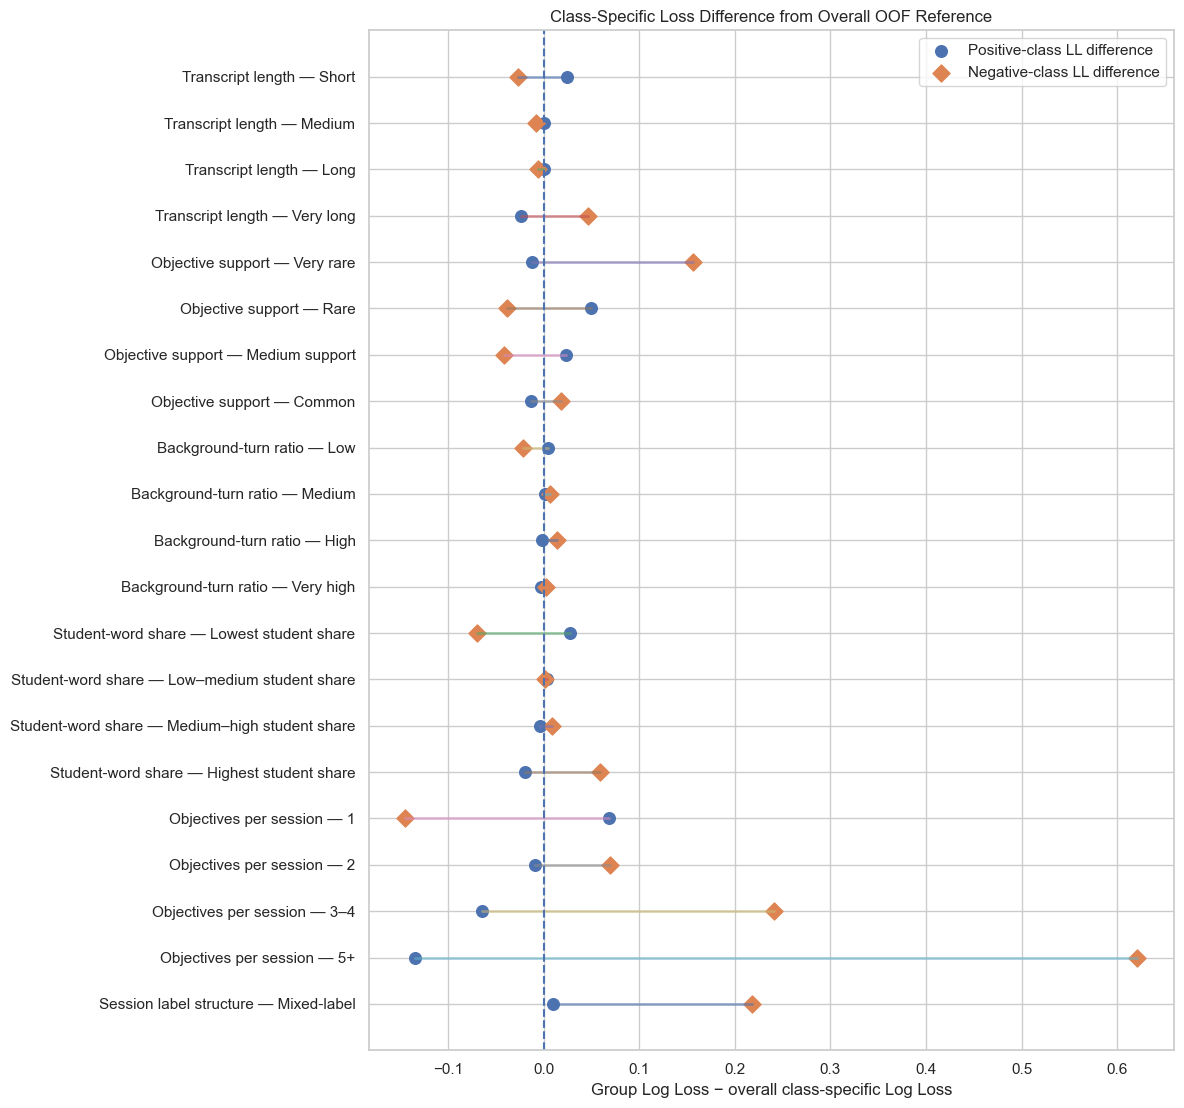

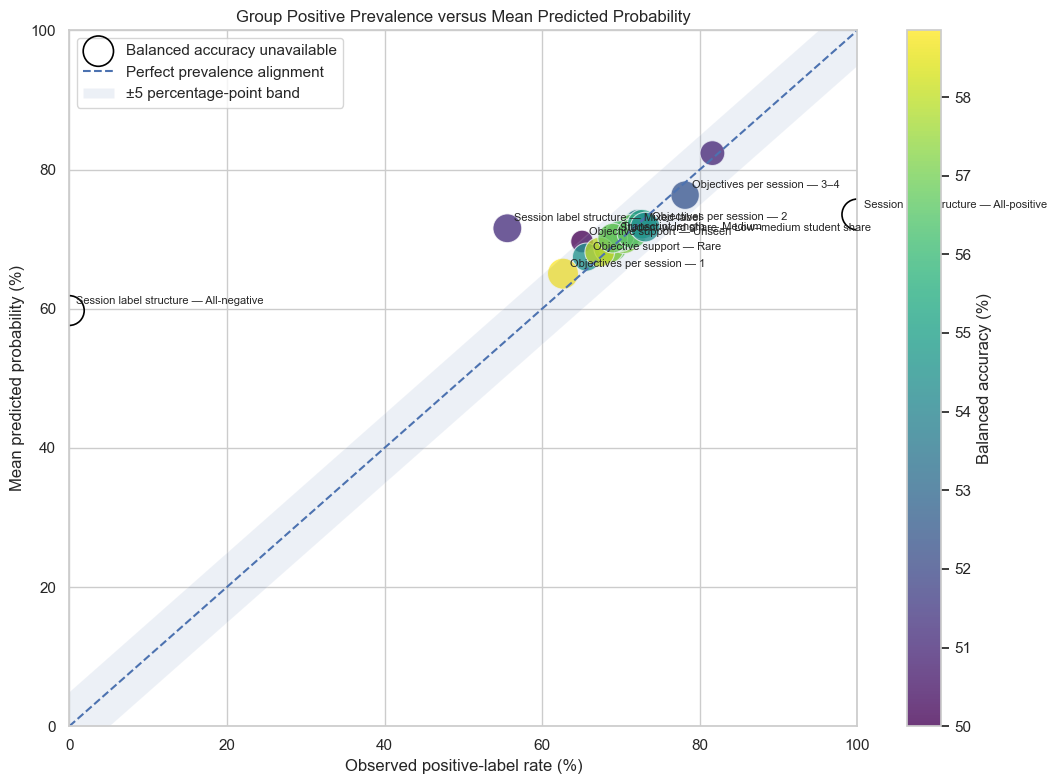

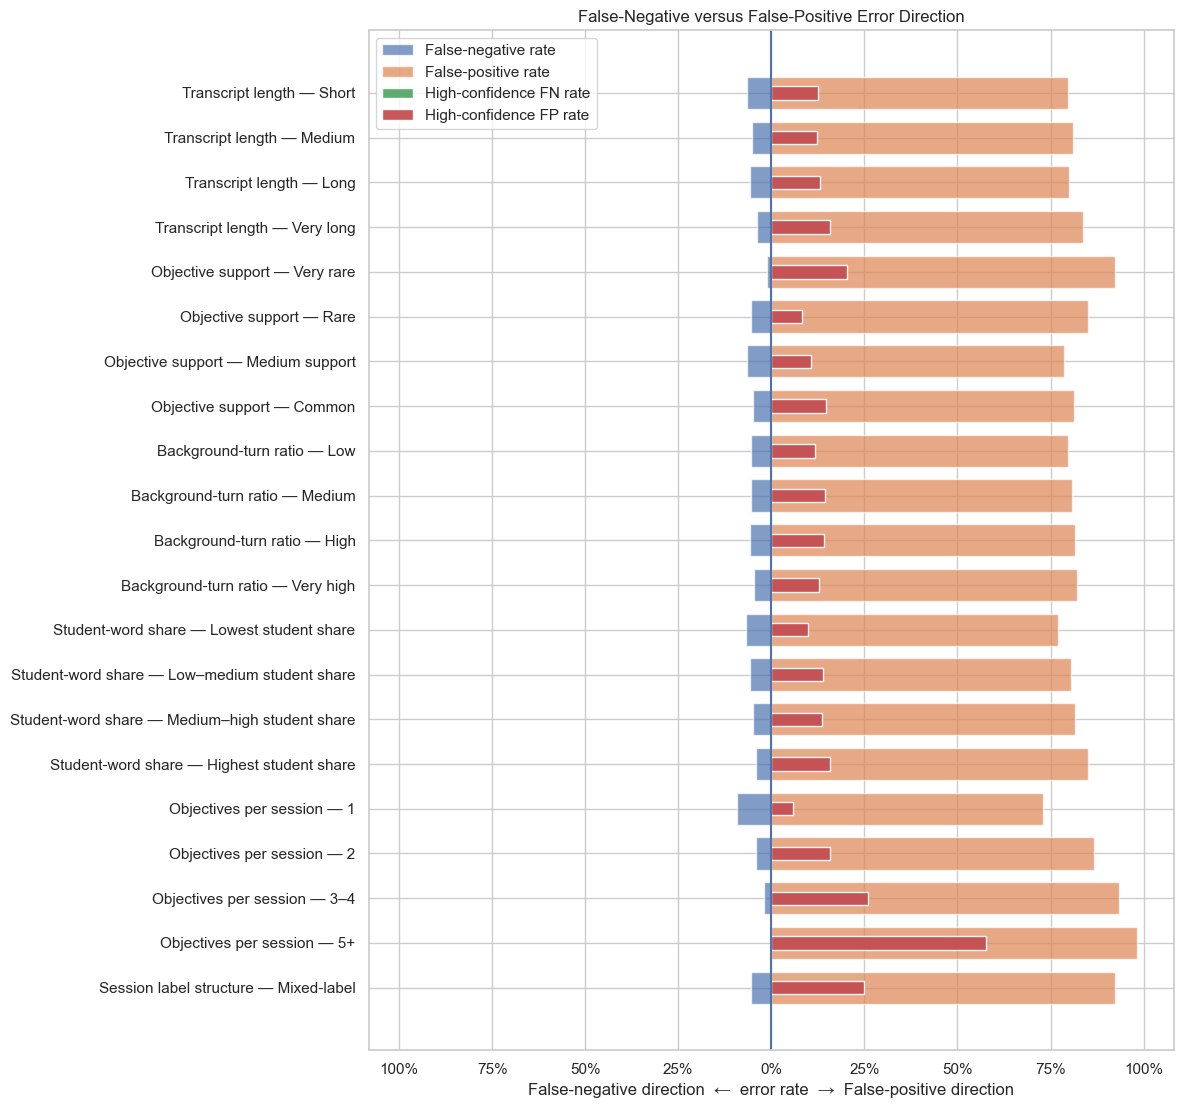

Synthesis figures saved in: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\class_conditional_prevalence


In [39]:
from matplotlib.ticker import FuncFormatter

def plot_class_prevalence_synthesis(results):
    headline = results["headline_registry"].copy()
    figures_dir = results["figures_dir"]

    class_plot_data = headline[
        headline["Class support eligible"]
        & headline["Positive LL delta"].notna()
        & headline["Negative LL delta"].notna()
    ].copy()

    class_plot_data = class_plot_data.sort_values(["Headline rank", "Group order"]).reset_index(drop=True)

    if class_plot_data.empty:
        print("Class-conditional figures were skipped because no headline group had sufficient positive and negative support.")
    else:
        y_positions = np.arange(len(class_plot_data))
        figure_height = max(7, 0.44 * len(class_plot_data) + 2)

        fig, ax = plt.subplots(figsize=(12, figure_height))

        for position, (_, row) in enumerate(class_plot_data.iterrows()):
            ax.plot([row["Positive LL delta"], row["Negative LL delta"]], [position, position], linewidth=2, alpha=0.55)

        ax.scatter(class_plot_data["Positive LL delta"], y_positions, s=70, marker="o", label="Positive-class LL difference")
        ax.scatter(class_plot_data["Negative LL delta"], y_positions, s=75, marker="D", label="Negative-class LL difference")
        ax.axvline(0, linestyle="--", linewidth=1.5)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(class_plot_data["Chart label"])
        ax.invert_yaxis()
        ax.set_title("Class-Specific Loss Difference from Overall OOF Reference")
        ax.set_xlabel("Group Log Loss − overall class-specific Log Loss")
        ax.set_ylabel("")
        ax.legend()
        plt.tight_layout()
        plt.savefig(figures_dir / "class_loss_dumbbell_forest.png", dpi=300, bbox_inches="tight")
        plt.show()

    calibration_data = headline[
        headline["Descriptive support eligible"]
        & headline["Positive rate (%)"].notna()
        & headline["Mean probability (%)"].notna()
    ].copy()

    calibration_data = calibration_data.sort_values(["Headline rank", "Group order"]).reset_index(drop=True)

    if calibration_data.empty:
        print("Prevalence–probability figure was skipped because no supported headline group was available.")
    else:
        maximum_sessions = calibration_data["Sessions"].max()

        if maximum_sessions > 0:
            calibration_data["Bubble size"] = 80 + 420 * np.log1p(calibration_data["Sessions"]) / np.log1p(maximum_sessions)
        else:
            calibration_data["Bubble size"] = 150

        valid_balance = calibration_data["Balanced accuracy (%)"].notna()
        invalid_balance = ~valid_balance

        fig, ax = plt.subplots(figsize=(11, 8))

        if valid_balance.any():
            scatter = ax.scatter(
                calibration_data.loc[valid_balance, "Positive rate (%)"],
                calibration_data.loc[valid_balance, "Mean probability (%)"],
                s=calibration_data.loc[valid_balance, "Bubble size"],
                c=calibration_data.loc[valid_balance, "Balanced accuracy (%)"],
                cmap="viridis",
                alpha=0.78,
                edgecolors="white",
                linewidths=0.8
            )

            colorbar = fig.colorbar(scatter, ax=ax)
            colorbar.set_label("Balanced accuracy (%)")

        if invalid_balance.any():
            ax.scatter(
                calibration_data.loc[invalid_balance, "Positive rate (%)"],
                calibration_data.loc[invalid_balance, "Mean probability (%)"],
                s=calibration_data.loc[invalid_balance, "Bubble size"],
                facecolors="none",
                edgecolors="black",
                linewidths=1.2,
                label="Balanced accuracy unavailable"
            )

        diagonal = np.linspace(0, 100, 200)
        ax.plot(diagonal, diagonal, linestyle="--", linewidth=1.5, label="Perfect prevalence alignment")
        ax.fill_between(diagonal, np.maximum(diagonal - 5, 0), np.minimum(diagonal + 5, 100), alpha=0.10, label="±5 percentage-point band")

        annotation_data = calibration_data.assign(Absolute_gap=calibration_data["Probability gap (pp)"].abs())
        annotation_data = annotation_data.nlargest(min(10, len(annotation_data)), "Absolute_gap")

        for _, row in annotation_data.iterrows():
            ax.annotate(
                row["Chart label"],
                (row["Positive rate (%)"], row["Mean probability (%)"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8
            )

        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_title("Group Positive Prevalence versus Mean Predicted Probability")
        ax.set_xlabel("Observed positive-label rate (%)")
        ax.set_ylabel("Mean predicted probability (%)")
        ax.legend(loc="best")
        plt.tight_layout()
        plt.savefig(figures_dir / "prevalence_probability_map.png", dpi=300, bbox_inches="tight")
        plt.show()

    butterfly_data = headline[
        headline["Class support eligible"]
        & headline["FPR (%)"].notna()
        & headline["FNR (%)"].notna()
    ].copy()

    butterfly_data = butterfly_data.sort_values(["Headline rank", "Group order"]).reset_index(drop=True)

    if butterfly_data.empty:
        print("Error-direction figure was skipped because no class-supported headline group was available.")
    else:
        y_positions = np.arange(len(butterfly_data))
        figure_height = max(7, 0.44 * len(butterfly_data) + 2)

        fig, ax = plt.subplots(figsize=(12, figure_height))

        ax.barh(y_positions, -butterfly_data["FNR (%)"], height=0.72, alpha=0.70, label="False-negative rate")
        ax.barh(y_positions, butterfly_data["FPR (%)"], height=0.72, alpha=0.70, label="False-positive rate")
        ax.barh(y_positions, -butterfly_data["High-confidence FN rate (%)"], height=0.30, alpha=0.95, label="High-confidence FN rate")
        ax.barh(y_positions, butterfly_data["High-confidence FP rate (%)"], height=0.30, alpha=0.95, label="High-confidence FP rate")

        maximum_error_rate = max(
            float(butterfly_data["FPR (%)"].max()),
            float(butterfly_data["FNR (%)"].max()),
            1.0
        )

        ax.axvline(0, linewidth=1.5)
        ax.set_xlim(-1.10 * maximum_error_rate, 1.10 * maximum_error_rate)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(butterfly_data["Chart label"])
        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{abs(value):.0f}%"))
        ax.set_title("False-Negative versus False-Positive Error Direction")
        ax.set_xlabel("False-negative direction  ←  error rate  →  False-positive direction")
        ax.set_ylabel("")
        ax.legend()
        plt.tight_layout()
        plt.savefig(figures_dir / "error_direction_butterfly.png", dpi=300, bbox_inches="tight")
        plt.show()

    print(f"Synthesis figures saved in: {figures_dir}")


plot_class_prevalence_synthesis(class_prevalence_results)

## 6.8–6.10 — Step 5 Linkage, Intersectional Risk and Continuous Trends

This final Step 6 block connects the full-population subgroup findings with the mixed-label session mechanisms identified in Step 5, evaluates four pre-specified subgroup intersections, and examines whether important continuous variables show monotonic or nonlinear loss trends.

### Part J — Group × Step 5 linkage

The Step 5 linkage is a secondary analysis restricted to mixed-label, multi-objective sessions. Step 6 session metadata will be merged with Step 5 session-discrimination metrics using the stable `session_id` key.

The main outcomes are session margin, pairwise accuracy, collapse-pair share, reversed-pair share, session Log Loss, negative-objective loss, and maximum negative-objective probability.

### Part K — Intersectional risk

Four pre-specified intersections will be evaluated:

1. Transcript length × objective support
2. Student-word share × transcript length
3. Background-turn ratio × transcript length
4. Objective support × objectives per session

A cell will be headline-eligible only when it contains at least 100 responses, 50 sessions, 20 positive responses, and 20 negative responses.

Interaction excess is defined as:

\[
\operatorname{InteractionExcess}_{a,b}
=
\operatorname{LL}_{a,b}
-
\left[
\operatorname{LL}_{all}
+
(\operatorname{LL}_{a}-\operatorname{LL}_{all})
+
(\operatorname{LL}_{b}-\operatorname{LL}_{all})
\right]
\]

Positive interaction excess indicates that the joint subgroup performs worse than the simple additive expectation.

### Part L — Continuous trends

The continuous analysis will use:

- `log1p(total_words)`
- `log1p(train_objective_support)`
- `student_word_ratio`
- `background_turn_ratio`
- `longest_tutor_streak_ratio`

Response-weighted Spearman correlation is the primary descriptive statistic. Session-cluster bootstrap confidence intervals and session- or objective-weighted sensitivity estimates will also be reported.

All results remain descriptive. Neither interaction excess nor continuous association establishes causality.

In [41]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def run_jkl_analysis(base_data, step5_metrics, step6_dir, n_boot=1000, seed=2026):
    data = base_data.copy()
    step5 = step5_metrics.copy()
    rng = np.random.default_rng(seed)

    out_j = step6_dir / "step5_linkage"
    out_k = step6_dir / "intersections"
    out_l = step6_dir / "continuous_trends"

    for folder in [out_j, out_k, out_l]:
        folder.mkdir(parents=True, exist_ok=True)

    required = ["response_id", "session_id", "objective_key", "correct", "fold_id", "probability"]
    missing = [column for column in required if column not in data.columns]

    if missing:
        raise ValueError(f"Missing response columns: {missing}")

    if not data["response_id"].is_unique:
        raise ValueError("response_id must be unique.")

    if data.groupby("session_id")["fold_id"].nunique().gt(1).any():
        raise ValueError("A session appears in multiple folds.")

    data["correct"] = pd.to_numeric(data["correct"], errors="raise").astype(int)
    data["probability"] = pd.to_numeric(data["probability"], errors="coerce").clip(1e-15, 1 - 1e-15)

    if data["probability"].isna().any():
        raise ValueError("probability contains missing or non-numeric values.")

    data["sample_log_loss"] = -(data["correct"] * np.log(data["probability"]) + (1 - data["correct"]) * np.log1p(-data["probability"]))
    data["hard_prediction"] = data["probability"].ge(0.50).astype(int)
    data["positive_loss"] = np.where(data["correct"].eq(1), data["sample_log_loss"], np.nan)
    data["negative_loss"] = np.where(data["correct"].eq(0), data["sample_log_loss"], np.nan)
    data["responses_per_session"] = data.groupby("session_id")["response_id"].transform("size")
    data["objectives_per_session"] = data.groupby("session_id")["objective_key"].transform("nunique")

    global_support = data.groupby("objective_key")["response_id"].transform("size")
    heldout_support = data.groupby(["objective_key", "fold_id"])["response_id"].transform("size")
    data["train_objective_support"] = (global_support - heldout_support).astype(int)

    support_order = ["Unseen", "Very rare", "Rare", "Medium support", "Common"]
    data["group_objective_support"] = pd.cut(data["train_objective_support"], [-1, 0, 9, 49, 199, np.inf], labels=support_order).astype("string")

    def safe_rho(x, y):
        valid = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()

        if len(valid) < 3 or valid["x"].nunique() < 2 or valid["y"].nunique() < 2:
            return np.nan

        return float(stats.spearmanr(valid["x"], valid["y"]).statistic)

    def session_qcut(column, labels):
        if column not in data.columns:
            return None, []

        session_values = data[["session_id", column]].copy()
        session_values[column] = pd.to_numeric(session_values[column], errors="coerce")
        session_values = session_values.replace([np.inf, -np.inf], np.nan).dropna()

        if session_values.empty or session_values.groupby("session_id")[column].nunique().max() > 1:
            return None, []

        session_values = session_values.drop_duplicates("session_id")
        codes, boundaries = pd.qcut(session_values[column], q=min(4, session_values[column].nunique()), labels=False, retbins=True, duplicates="drop")
        active_labels = labels[:len(boundaries) - 1]

        if len(active_labels) < 2:
            return None, []

        session_values["group"] = codes.map(dict(enumerate(active_labels))).astype("string")

        return session_values[["session_id", "group"]], active_labels

    transcript_column = next((column for column in ["transcript_length_group", "transcript_length_band"] if column in data.columns), None)

    if transcript_column:
        data["group_transcript"] = data[transcript_column].astype("string")
        transcript_order = [str(value) for value in data[transcript_column].cat.categories] if isinstance(data[transcript_column].dtype, pd.CategoricalDtype) else data["group_transcript"].dropna().drop_duplicates().tolist()
    else:
        transcript_table, transcript_order = session_qcut("total_words", ["Short", "Medium", "Long", "Very long"])

        if transcript_table is not None:
            data = data.merge(transcript_table.rename(columns={"group": "group_transcript"}), on="session_id", how="left", validate="many_to_one")

    student_column = next((column for column in ["student_word_ratio_group", "student_word_ratio_band"] if column in data.columns), None)

    if student_column:
        data["group_student_share"] = data[student_column].astype("string")
        student_order = [str(value) for value in data[student_column].cat.categories] if isinstance(data[student_column].dtype, pd.CategoricalDtype) else data["group_student_share"].dropna().drop_duplicates().tolist()
    else:
        student_table, student_order = session_qcut("student_word_ratio", ["Lowest student share", "Low–medium", "Medium–high", "Highest student share"])

        if student_table is not None:
            data = data.merge(student_table.rename(columns={"group": "group_student_share"}), on="session_id", how="left", validate="many_to_one")

    background_table, background_order = session_qcut("background_turn_ratio", ["Low", "Medium", "High", "Very high"])

    if background_table is not None:
        data = data.merge(background_table.rename(columns={"group": "group_background"}), on="session_id", how="left", validate="many_to_one")

    objective_count_order = ["1", "2", "3–4", "5+"]
    data["group_objective_count"] = pd.cut(data["objectives_per_session"], [0, 1, 2, 4, np.inf], labels=objective_count_order).astype("string")

    group_orders = {
        "group_transcript": transcript_order,
        "group_student_share": student_order,
        "group_background": background_order,
        "group_objective_support": support_order,
        "group_objective_count": objective_count_order
    }

    assignment_columns = ["response_id", "session_id"] + [column for column in group_orders if column in data.columns]

    try:
        data[assignment_columns].to_parquet(step6_dir / "group_assignment_registry.parquet", index=False)
    except Exception:
        data[assignment_columns].to_csv(step6_dir / "group_assignment_registry.csv", index=False)

    # Part J — Step 5 linkage

    step5_required = ["session_id", "session_margin", "session_pairwise_accuracy", "collapse_pair_share", "reversed_pair_share", "session_log_loss", "negative_mean_loss", "max_negative_probability"]
    missing_step5 = [column for column in step5_required if column not in step5.columns]

    if missing_step5:
        raise ValueError(f"Missing Step 5 columns: {missing_step5}")

    if not step5["session_id"].is_unique:
        raise ValueError("Step 5 session_id must be unique.")

    if "is_session_collapse" not in step5.columns:
        step5["is_session_collapse"] = step5["session_margin"].abs().lt(0.02)

    if "is_session_reversed" not in step5.columns:
        step5["is_session_reversed"] = step5["session_margin"].lt(0)

    session_group_columns = [column for column in ["group_transcript", "group_student_share", "group_background", "group_objective_count"] if column in data.columns]
    session_meta = data[["session_id", "fold_id"] + session_group_columns].drop_duplicates("session_id")

    session_support = data.groupby("session_id").agg(min_train_support=("train_objective_support", "min"), rare_objective_share=("train_objective_support", lambda values: values.le(49).mean())).reset_index()
    session_support["group_session_support"] = np.select([session_support["min_train_support"].le(9), session_support["min_train_support"].le(49)], ["Contains unseen/very rare", "Contains rare"], default="Only medium/common")

    if "fold_id" in step5.columns:
        mixed = step5.merge(session_meta, on=["session_id", "fold_id"], how="left", validate="one_to_one", indicator=True)
    else:
        mixed = step5.merge(session_meta.drop(columns="fold_id"), on="session_id", how="left", validate="one_to_one", indicator=True)
        mixed = mixed.merge(data[["session_id", "fold_id"]].drop_duplicates("session_id"), on="session_id", how="left", validate="one_to_one")

    merge_audit = pd.DataFrame([{"Step 5 sessions": len(step5), "Matched sessions": int(mixed["_merge"].eq("both").sum()), "Coverage (%)": 100 * mixed["_merge"].eq("both").mean()}])
    merge_audit.to_csv(out_j / "step5_linkage_merge_audit.csv", index=False)

    mixed = mixed.drop(columns="_merge")
    mixed = mixed.merge(session_support, on="session_id", how="left", validate="one_to_one")

    factors = {
        "Transcript length": ("group_transcript", group_orders.get("group_transcript", [])),
        "Session objective support": ("group_session_support", ["Contains unseen/very rare", "Contains rare", "Only medium/common"]),
        "Student-word share": ("group_student_share", group_orders.get("group_student_share", [])),
        "Background-turn ratio": ("group_background", group_orders.get("group_background", [])),
        "Objectives per session": ("group_objective_count", group_orders.get("group_objective_count", []))
    }

    factors = {factor: settings for factor, settings in factors.items() if settings[0] in mixed.columns and len(settings[1]) >= 2}

    linkage_reference = {
        "session_log_loss": mixed["session_log_loss"].mean(),
        "negative_mean_loss": mixed["negative_mean_loss"].mean(),
        "session_margin": mixed["session_margin"].mean(),
        "pairwise_accuracy": mixed["session_pairwise_accuracy"].mean(),
        "collapse_rate": mixed["is_session_collapse"].mean(),
        "reversal_rate": mixed["is_session_reversed"].mean(),
        "max_negative_probability": mixed["max_negative_probability"].mean()
    }

    linkage_rows = []
    linkage_fold_rows = []

    for factor, (column, group_order) in factors.items():
        factor_data = mixed.dropna(subset=[column]).copy()

        for group_index, group_name in enumerate(group_order):
            group_data = factor_data[factor_data[column].astype(str).eq(str(group_name))]

            if group_data.empty:
                continue

            linkage_rows.append({
                "Factor": factor,
                "Group": str(group_name),
                "Group order": group_index,
                "Mixed sessions": len(group_data),
                "Mean session margin": group_data["session_margin"].mean(),
                "Mean pairwise accuracy (%)": 100 * group_data["session_pairwise_accuracy"].mean(),
                "Session collapse rate (%)": 100 * group_data["is_session_collapse"].mean(),
                "Session reversal rate (%)": 100 * group_data["is_session_reversed"].mean(),
                "Mean collapse-pair share (%)": 100 * group_data["collapse_pair_share"].mean(),
                "Mean reversed-pair share (%)": 100 * group_data["reversed_pair_share"].mean(),
                "Mean session Log Loss": group_data["session_log_loss"].mean(),
                "Mean negative-objective loss": group_data["negative_mean_loss"].mean(),
                "Mean max-negative probability": group_data["max_negative_probability"].mean()
            })

        for fold_id, fold_data in factor_data.groupby("fold_id"):
            fold_reference = fold_data["session_log_loss"].mean()

            for group_name in group_order:
                fold_group = fold_data[fold_data[column].astype(str).eq(str(group_name))]

                if not fold_group.empty:
                    linkage_fold_rows.append({"Factor": factor, "Group": str(group_name), "Fold": int(fold_id), "Loss difference": fold_group["session_log_loss"].mean() - fold_reference})

    linkage = pd.DataFrame(linkage_rows)

    linkage["Session Log Loss excess"] = linkage["Mean session Log Loss"] - linkage_reference["session_log_loss"]
    linkage["Negative-objective loss excess"] = linkage["Mean negative-objective loss"] - linkage_reference["negative_mean_loss"]
    linkage["Session-margin deficit"] = linkage_reference["session_margin"] - linkage["Mean session margin"]
    linkage["Pairwise-accuracy deficit"] = 100 * linkage_reference["pairwise_accuracy"] - linkage["Mean pairwise accuracy (%)"]
    linkage["Collapse-rate excess (pp)"] = linkage["Session collapse rate (%)"] - 100 * linkage_reference["collapse_rate"]
    linkage["Reversal-rate excess (pp)"] = linkage["Session reversal rate (%)"] - 100 * linkage_reference["reversal_rate"]
    linkage["Max-negative-probability excess"] = linkage["Mean max-negative probability"] - linkage_reference["max_negative_probability"]
    linkage["Chart label"] = linkage["Factor"] + " — " + linkage["Group"]
    linkage["Headline eligible"] = linkage["Mixed sessions"].ge(50)

    linkage_fold_metrics = pd.DataFrame(linkage_fold_rows)

    if linkage_fold_metrics.empty:
        linkage_fold_stability = pd.DataFrame()
    else:
        linkage_fold_stability = linkage_fold_metrics.groupby(["Factor", "Group"]).agg(Folds=("Fold", "nunique"), Folds_worse=("Loss difference", lambda values: int(values.gt(0).sum())), Mean_fold_difference=("Loss difference", "mean")).reset_index()

    linkage.to_csv(out_j / "mixed_session_group_linkage.csv", index=False)
    linkage_fold_stability.to_csv(out_j / "step5_linkage_fold_stability.csv", index=False)

    # Part K — Intersectional analysis

    intersection_specs = [
        ("Transcript length × objective support", "group_transcript", "group_objective_support"),
        ("Student-word share × transcript length", "group_student_share", "group_transcript"),
        ("Background-turn ratio × transcript length", "group_background", "group_transcript"),
        ("Objective support × objective count", "group_objective_support", "group_objective_count")
    ]

    intersection_rows = []
    intersection_fold_rows = []
    intersection_bootstrap_rows = []

    for intersection_name, a_column, b_column in intersection_specs:
        if a_column not in data.columns or b_column not in data.columns:
            continue

        pair_data = data.dropna(subset=[a_column, b_column]).copy()
        pair_data[a_column] = pair_data[a_column].astype(str)
        pair_data[b_column] = pair_data[b_column].astype(str)

        overall_loss = pair_data["sample_log_loss"].mean()
        a_losses = pair_data.groupby(a_column)["sample_log_loss"].mean().to_dict()
        b_losses = pair_data.groupby(b_column)["sample_log_loss"].mean().to_dict()

        current_eligible_cells = []

        for (a_group, b_group), cell_data in pair_data.groupby([a_column, b_column], observed=True):
            positive_count = int(cell_data["correct"].sum())
            negative_count = int(cell_data["correct"].eq(0).sum())
            expected_loss = overall_loss + (a_losses[a_group] - overall_loss) + (b_losses[b_group] - overall_loss)
            interaction_excess = cell_data["sample_log_loss"].mean() - expected_loss
            support_eligible = len(cell_data) >= 100 and cell_data["session_id"].nunique() >= 50 and positive_count >= 20 and negative_count >= 20

            if support_eligible:
                current_eligible_cells.append((a_group, b_group))

            intersection_rows.append({
                "Intersection": intersection_name,
                "A column": a_column,
                "B column": b_column,
                "A group": a_group,
                "B group": b_group,
                "Responses": len(cell_data),
                "Sessions": cell_data["session_id"].nunique(),
                "Positive responses": positive_count,
                "Negative responses": negative_count,
                "Observed Log Loss": cell_data["sample_log_loss"].mean(),
                "Expected Log Loss": expected_loss,
                "Interaction excess": interaction_excess,
                "Support eligible": support_eligible
            })

        for fold_id, fold_data in pair_data.groupby("fold_id"):
            fold_overall = fold_data["sample_log_loss"].mean()
            fold_a_losses = fold_data.groupby(a_column)["sample_log_loss"].mean().to_dict()
            fold_b_losses = fold_data.groupby(b_column)["sample_log_loss"].mean().to_dict()

            for (a_group, b_group), fold_cell in fold_data.groupby([a_column, b_column], observed=True):
                expected_loss = fold_overall + (fold_a_losses[a_group] - fold_overall) + (fold_b_losses[b_group] - fold_overall)

                intersection_fold_rows.append({
                    "Intersection": intersection_name,
                    "A group": a_group,
                    "B group": b_group,
                    "Fold": int(fold_id),
                    "Interaction excess": fold_cell["sample_log_loss"].mean() - expected_loss
                })

        bootstrap_values = {cell_key: [] for cell_key in current_eligible_cells}
        sessions_by_fold = pair_data[["session_id", "fold_id"]].drop_duplicates().groupby("fold_id")["session_id"].apply(list).to_dict()

        for _ in range(n_boot):
            session_weights = {}

            for session_ids in sessions_by_fold.values():
                sampled_sessions = rng.choice(session_ids, len(session_ids), replace=True)
                session_weights.update(pd.Series(sampled_sessions).value_counts().to_dict())

            weights = pair_data["session_id"].map(session_weights).fillna(0).astype(float)
            bootstrap_data = pair_data.loc[weights.gt(0), [a_column, b_column, "sample_log_loss"]].copy()
            bootstrap_data["weight"] = weights[weights.gt(0)].to_numpy()
            bootstrap_data["weighted_loss"] = bootstrap_data["weight"] * bootstrap_data["sample_log_loss"]

            weighted_overall = bootstrap_data["weighted_loss"].sum() / bootstrap_data["weight"].sum()
            weighted_a = (bootstrap_data.groupby(a_column)["weighted_loss"].sum() / bootstrap_data.groupby(a_column)["weight"].sum()).to_dict()
            weighted_b = (bootstrap_data.groupby(b_column)["weighted_loss"].sum() / bootstrap_data.groupby(b_column)["weight"].sum()).to_dict()
            weighted_cells = (bootstrap_data.groupby([a_column, b_column])["weighted_loss"].sum() / bootstrap_data.groupby([a_column, b_column])["weight"].sum()).to_dict()

            for cell_key in current_eligible_cells:
                if cell_key in weighted_cells and cell_key[0] in weighted_a and cell_key[1] in weighted_b:
                    expected_loss = weighted_overall + (weighted_a[cell_key[0]] - weighted_overall) + (weighted_b[cell_key[1]] - weighted_overall)
                    bootstrap_values[cell_key].append(weighted_cells[cell_key] - expected_loss)

        for (a_group, b_group), values in bootstrap_values.items():
            values = np.asarray(values, dtype=float)

            intersection_bootstrap_rows.append({
                "Intersection": intersection_name,
                "A group": a_group,
                "B group": b_group,
                "Bootstrap iterations": len(values),
                "CI low": np.quantile(values, 0.025) if len(values) else np.nan,
                "CI high": np.quantile(values, 0.975) if len(values) else np.nan
            })

    intersections = pd.DataFrame(intersection_rows)
    intersection_fold_metrics = pd.DataFrame(intersection_fold_rows)
    intersection_bootstrap = pd.DataFrame(intersection_bootstrap_rows)

    if intersection_fold_metrics.empty:
        intersection_fold_stability = pd.DataFrame()
    else:
        intersection_fold_stability = intersection_fold_metrics.groupby(["Intersection", "A group", "B group"]).agg(Folds=("Fold", "nunique"), Folds_positive=("Interaction excess", lambda values: int(values.gt(0).sum())), Mean_fold_excess=("Interaction excess", "mean")).reset_index()

    if not intersection_bootstrap.empty:
        intersections = intersections.merge(intersection_bootstrap, on=["Intersection", "A group", "B group"], how="left", validate="one_to_one")

    if not intersection_fold_stability.empty:
        intersections = intersections.merge(intersection_fold_stability, on=["Intersection", "A group", "B group"], how="left", validate="one_to_one")

    intersections.to_csv(out_k / "intersection_cell_registry.csv", index=False)
    intersections[intersections["Support eligible"]].sort_values("Interaction excess", ascending=False).to_csv(out_k / "interaction_excess_summary.csv", index=False)

    # Part L — Continuous trends

    if "total_words" in data.columns:
        data["log1p_total_words"] = np.log1p(pd.to_numeric(data["total_words"], errors="coerce"))

    data["log1p_train_objective_support"] = np.log1p(data["train_objective_support"])

    trend_specs = [
        ("log1p_total_words", "Log1p total words", "session"),
        ("log1p_train_objective_support", "Log1p train objective support", "objective"),
        ("student_word_ratio", "Student-word ratio", "session"),
        ("background_turn_ratio", "Background-turn ratio", "session"),
        ("longest_tutor_streak_ratio", "Longest tutor-streak ratio", "session")
    ]

    trend_rows = []
    trend_bin_rows = []

    for variable, display_name, sensitivity_unit in trend_specs:
        if variable not in data.columns:
            continue

        trend_data = data[["response_id", "session_id", "objective_key", "fold_id", "sample_log_loss", "positive_loss", "negative_loss", variable]].replace([np.inf, -np.inf], np.nan).dropna(subset=[variable, "sample_log_loss"]).copy()

        if len(trend_data) < 100 or trend_data[variable].nunique() < 4:
            continue

        response_rho = safe_rho(trend_data[variable], trend_data["sample_log_loss"])

        if sensitivity_unit == "session":
            sensitivity_data = trend_data.groupby("session_id").agg(X=(variable, "first"), Loss=("sample_log_loss", "mean")).reset_index()
        else:
            sensitivity_data = trend_data.groupby("objective_key").agg(X=(variable, "median"), Loss=("sample_log_loss", "mean")).reset_index()

        sensitivity_rho = safe_rho(sensitivity_data["X"], sensitivity_data["Loss"])
        fold_rhos = np.asarray([safe_rho(fold_data[variable], fold_data["sample_log_loss"]) for _, fold_data in trend_data.groupby("fold_id")])
        fold_rhos = fold_rhos[np.isfinite(fold_rhos)]

        session_indices = trend_data.groupby("session_id").indices
        sessions_by_fold = trend_data[["session_id", "fold_id"]].drop_duplicates().groupby("fold_id")["session_id"].apply(list).to_dict()
        bootstrap_rhos = []

        for _ in range(n_boot):
            sampled_indices = []

            for session_ids in sessions_by_fold.values():
                for session_id in rng.choice(session_ids, len(session_ids), replace=True):
                    sampled_indices.extend(session_indices[session_id])

            bootstrap_sample = trend_data.iloc[sampled_indices]
            bootstrap_rho = safe_rho(bootstrap_sample[variable], bootstrap_sample["sample_log_loss"])

            if np.isfinite(bootstrap_rho):
                bootstrap_rhos.append(bootstrap_rho)

        bootstrap_rhos = np.asarray(bootstrap_rhos, dtype=float)

        if sensitivity_unit == "session":
            quantile_anchor = trend_data[["session_id", variable]].drop_duplicates("session_id")[variable]
        else:
            quantile_anchor = trend_data[["objective_key", "fold_id", variable]].drop_duplicates(["objective_key", "fold_id"])[variable]

        _, bin_boundaries = pd.qcut(quantile_anchor, q=min(10, quantile_anchor.nunique()), labels=False, retbins=True, duplicates="drop")
        trend_data["Trend bin"] = pd.cut(trend_data[variable], bins=np.unique(bin_boundaries), labels=False, include_lowest=True)

        for bin_id, bin_data in trend_data.dropna(subset=["Trend bin"]).groupby("Trend bin"):
            if len(bin_data) < 100 or bin_data["session_id"].nunique() < 50:
                continue

            trend_bin_rows.append({
                "Variable": variable,
                "Display name": display_name,
                "Trend bin": int(bin_id),
                "Median X": bin_data[variable].median(),
                "Responses": len(bin_data),
                "Sessions": bin_data["session_id"].nunique(),
                "Mean Log Loss": bin_data["sample_log_loss"].mean(),
                "Positive LL": bin_data["positive_loss"].mean(),
                "Negative LL": bin_data["negative_loss"].mean()
            })

        trend_rows.append({
            "Variable": variable,
            "Display name": display_name,
            "Responses": len(trend_data),
            "Sessions": trend_data["session_id"].nunique(),
            "Spearman rho": response_rho,
            "Bootstrap CI low": np.quantile(bootstrap_rhos, 0.025) if len(bootstrap_rhos) else np.nan,
            "Bootstrap CI high": np.quantile(bootstrap_rhos, 0.975) if len(bootstrap_rhos) else np.nan,
            "Sensitivity rho": sensitivity_rho,
            "Folds": len(fold_rhos),
            "Positive-rho folds": int((fold_rhos > 0).sum()),
            "Negative-rho folds": int((fold_rhos < 0).sum())
        })

    trends = pd.DataFrame(trend_rows)
    trend_bins = pd.DataFrame(trend_bin_rows)

    trends.to_csv(out_l / "continuous_spearman_summary.csv", index=False)
    trend_bins.to_csv(out_l / "continuous_binned_trends.csv", index=False)

    with open(out_l / "continuous_trend_manifest.json", "w", encoding="utf-8") as file:
        json.dump({"bootstrap_iterations": int(n_boot), "random_state": int(seed), "cluster_unit": "session within fold", "initial_bins": 10, "minimum_bin_responses": 100, "minimum_bin_sessions": 50}, file, indent=2)

    return {
        "data": data,
        "linkage": linkage,
        "linkage_ref": linkage_reference,
        "linkage_fold_stability": linkage_fold_stability,
        "intersections": intersections,
        "trends": trends,
        "trend_bins": trend_bins,
        "group_orders": group_orders,
        "dirs": {"J": out_j, "K": out_k, "L": out_l}
    }

In [42]:
jkl_base_data = class_prevalence_results["data"].copy() if "class_prevalence_results" in globals() else reference_data.copy()

if "session_metrics" in globals():
    jkl_step5_metrics = session_metrics.copy()
elif "step5_dir" in globals() and (step5_dir / "session_discrimination_metrics.csv").exists():
    jkl_step5_metrics = pd.read_csv(step5_dir / "session_discrimination_metrics.csv")
else:
    raise NameError("Step 5 session_metrics অথবা session_discrimination_metrics.csv পাওয়া যায়নি।")

jkl_results = run_jkl_analysis(jkl_base_data, jkl_step5_metrics, step6_dir, n_boot=1000, seed=2026)

display(jkl_results["linkage"].sort_values("Session Log Loss excess", ascending=False))
display(jkl_results["intersections"][jkl_results["intersections"]["Support eligible"]].sort_values("Interaction excess", ascending=False).head(10))
display(jkl_results["trends"])

print(f"Step 5 linkage groups: {len(jkl_results['linkage']):,}")
print(f"Supported intersection cells: {jkl_results['intersections']['Support eligible'].sum():,}")
print(f"Continuous variables analysed: {len(jkl_results['trends']):,}")

,Factor,Group,Group order,Mixed sessions,Mean session margin,Mean pairwise accuracy (%),Session collapse rate (%),Session reversal rate (%),Mean collapse-pair share (%),Mean reversed-pair share (%),Mean session Log Loss,Mean negative-objective loss,Mean max-negative probability,Session Log Loss excess,Negative-objective loss excess,Session-margin deficit,Pairwise-accuracy deficit,Collapse-rate excess (pp),Reversal-rate excess (pp),Max-negative-probability excess,Chart label,Headline eligible
15,Objectives per session,2,1,1922,0.0091,67.7940,72.7367,32.2060,72.7367,32.2060,0.8100,1.2299,0.6804,0.0276,-0.0774,-0.0006,-0.1901,-2.1931,0.9307,-0.0212,Objectives per session — 2,True
3,Transcript length,Very long,3,800,0.0080,68.4625,79.3750,30.7500,77.7021,31.5375,0.7996,1.3603,0.7161,0.0172,0.0530,0.0006,-0.8586,4.4452,-0.5253,0.0144,Transcript length — Very long,True
8,Student-word share,Medium-low,1,788,0.0085,68.1007,78.0457,30.8376,76.0491,31.8993,0.7932,1.3190,0.7056,0.0108,0.0117,0.0001,-0.4968,3.1158,-0.4378,0.0040,Student-word share — Medium-low,True
12,Background-turn ratio,Medium,1,788,0.0090,67.9071,71.7005,31.8528,70.3765,32.0929,0.7928,1.3126,0.7020,0.0104,0.0054,-0.0005,-0.3033,-3.2293,0.5775,0.0003,Background-turn ratio — Medium,True
4,Session objective support,Contains unseen/very rare,0,103,0.0027,59.4876,90.2913,37.8641,84.6278,40.5124,0.7921,1.4549,0.7490,0.0097,0.1476,0.0058,8.1163,15.3614,6.5887,0.0474,Session objective support — Contains unseen/very rare,True
13,Background-turn ratio,High,2,833,0.0075,66.6597,76.5906,31.2125,73.8025,33.3403,0.7865,1.3233,0.7060,0.0042,0.0160,0.0011,0.9442,1.6608,-0.0629,0.0044,Background-turn ratio — High,True
6,Session objective support,Only medium/common,2,2793,0.0094,68.9668,72.2879,29.7530,70.0694,31.0332,0.7837,1.3089,0.7012,0.0013,0.0016,-0.0008,-1.3629,-2.6420,-1.5224,-0.0005,Session objective support — Only medium/common,True
2,Transcript length,Long,2,803,0.0077,66.6155,76.2142,32.6276,74.0079,33.3845,0.7813,1.3062,0.6994,-0.0011,-0.0011,0.0009,0.9884,1.2844,1.3523,-0.0022,Transcript length — Long,True
9,Student-word share,Medium-high,2,810,0.0082,68.0988,76.0494,31.1111,73.3858,31.9012,0.7794,1.3153,0.7020,-0.0030,0.0081,0.0004,-0.4949,1.1195,-0.1642,0.0003,Student-word share — Medium-high,True
7,Student-word share,Low,0,697,0.0097,66.9082,69.5839,32.7116,67.5777,33.0918,0.7792,1.2647,0.6906,-0.0032,-0.0426,-0.0012,0.6957,-5.3459,1.4363,-0.0110,Student-word share — Low,True


,Intersection,A column,B column,A group,B group,Responses,Sessions,Positive responses,Negative responses,Observed Log Loss,Expected Log Loss,Interaction excess,Support eligible,Bootstrap iterations,CI low,CI high,Folds,Folds_positive,Mean_fold_excess
4,Transcript length × objective support,group_transcript,group_objective_support,Long,Very rare,144,108,96,48,0.6377,0.5697,0.0680,True,"1,000.0000",-0.0029,0.1473,5,5,0.0817
69,Objective support × objective count,group_objective_support,group_objective_count,Very rare,2,205,139,144,61,0.6253,0.5656,0.0597,True,"1,000.0000",0.0006,0.1209,5,5,0.0675
59,Objective support × objective count,group_objective_support,group_objective_count,Medium support,5+,277,135,220,57,0.5270,0.4893,0.0377,True,"1,000.0000",-0.0356,0.1079,5,4,0.0498
16,Transcript length × objective support,group_transcript,group_objective_support,Very long,Medium support,2152,1721,1495,657,0.5726,0.5529,0.0197,True,"1,000.0000",0.0049,0.0353,5,5,0.0199
43,Background-turn ratio × transcript length,group_background,group_transcript,Low,Very long,1880,1303,1335,545,0.5470,0.5309,0.0161,True,"1,000.0000",-0.0008,0.0336,5,4,0.0182
36,Background-turn ratio × transcript length,group_background,group_transcript,High,Long,2267,1468,1595,672,0.5638,0.5492,0.0147,True,"1,000.0000",0.0001,0.0304,5,4,0.0148
46,Background-turn ratio × transcript length,group_background,group_transcript,Medium,Short,2198,1417,1481,717,0.5903,0.5790,0.0113,True,"1,000.0000",-0.0042,0.0271,5,2,0.0100
70,Objective support × objective count,group_objective_support,group_objective_count,Very rare,3–4,166,84,129,37,0.5278,0.5167,0.0111,True,"1,000.0000",-0.0503,0.0786,5,2,0.0120
28,Student-word share × transcript length,group_student_share,group_transcript,Medium-high,Long,2282,1437,1610,672,0.5532,0.5428,0.0103,True,"1,000.0000",-0.0047,0.0258,5,5,0.0117
25,Student-word share × transcript length,group_student_share,group_transcript,Low,Medium,2133,1505,1365,768,0.5872,0.5777,0.0096,True,"1,000.0000",-0.0063,0.0268,5,4,0.0106


,Variable,Display name,Responses,Sessions,Spearman rho,Bootstrap CI low,Bootstrap CI high,Sensitivity rho,Folds,Positive-rho folds,Negative-rho folds
0,log1p_total_words,Log1p total words,35072,22821,-0.0678,-0.0801,-0.0541,-0.0579,5,0,5
1,log1p_train_objective_support,Log1p train objective support,35072,22821,-0.0535,-0.0651,-0.0424,0.0563,5,0,5
2,student_word_ratio,Student-word ratio,35072,22821,-0.0686,-0.0810,-0.0558,-0.0510,5,0,5
3,background_turn_ratio,Background-turn ratio,35072,22821,-0.0038,-0.0181,0.0104,0.0003,5,2,3
4,longest_tutor_streak_ratio,Longest tutor-streak ratio,35072,22821,0.0104,-0.0022,0.0230,0.0199,5,4,1


Step 5 linkage groups: 18
Supported intersection cells: 62
Continuous variables analysed: 5


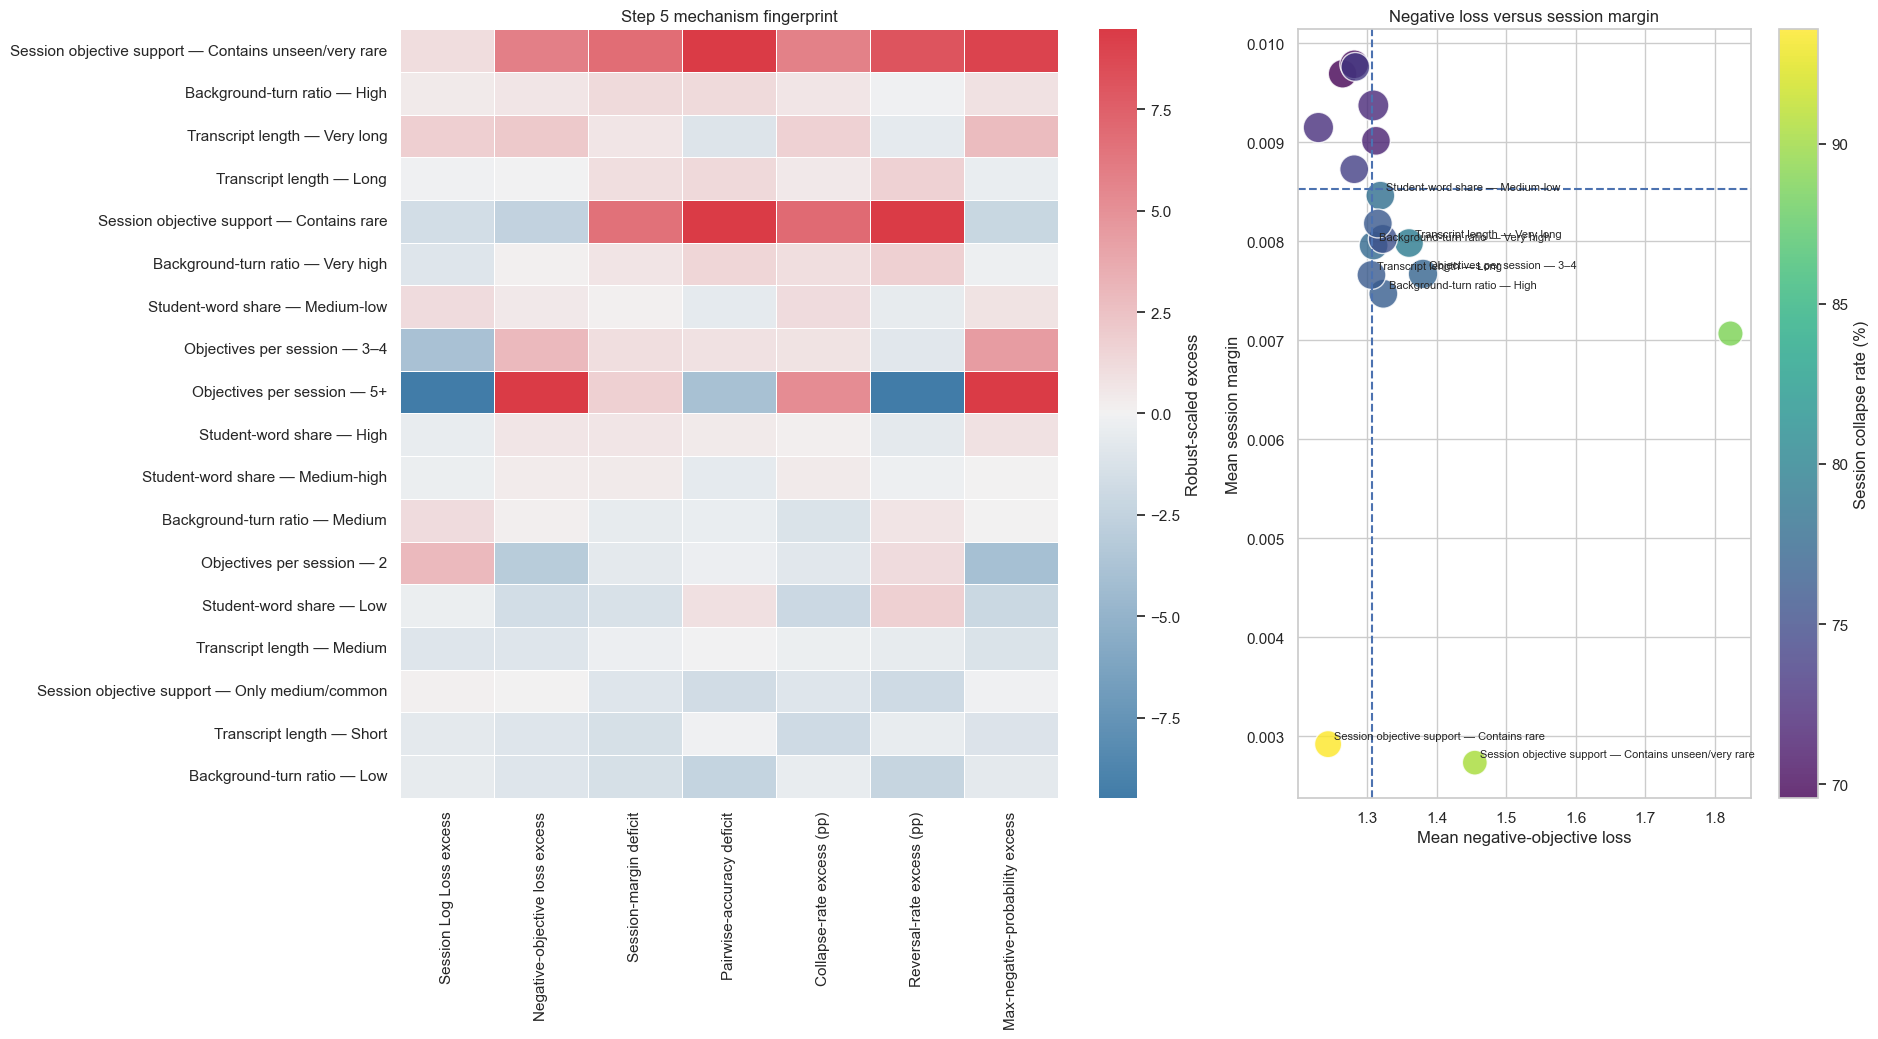

C:\Users\USER\AppData\Local\Temp\ipykernel_23720\839519058.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.94, 0.97])


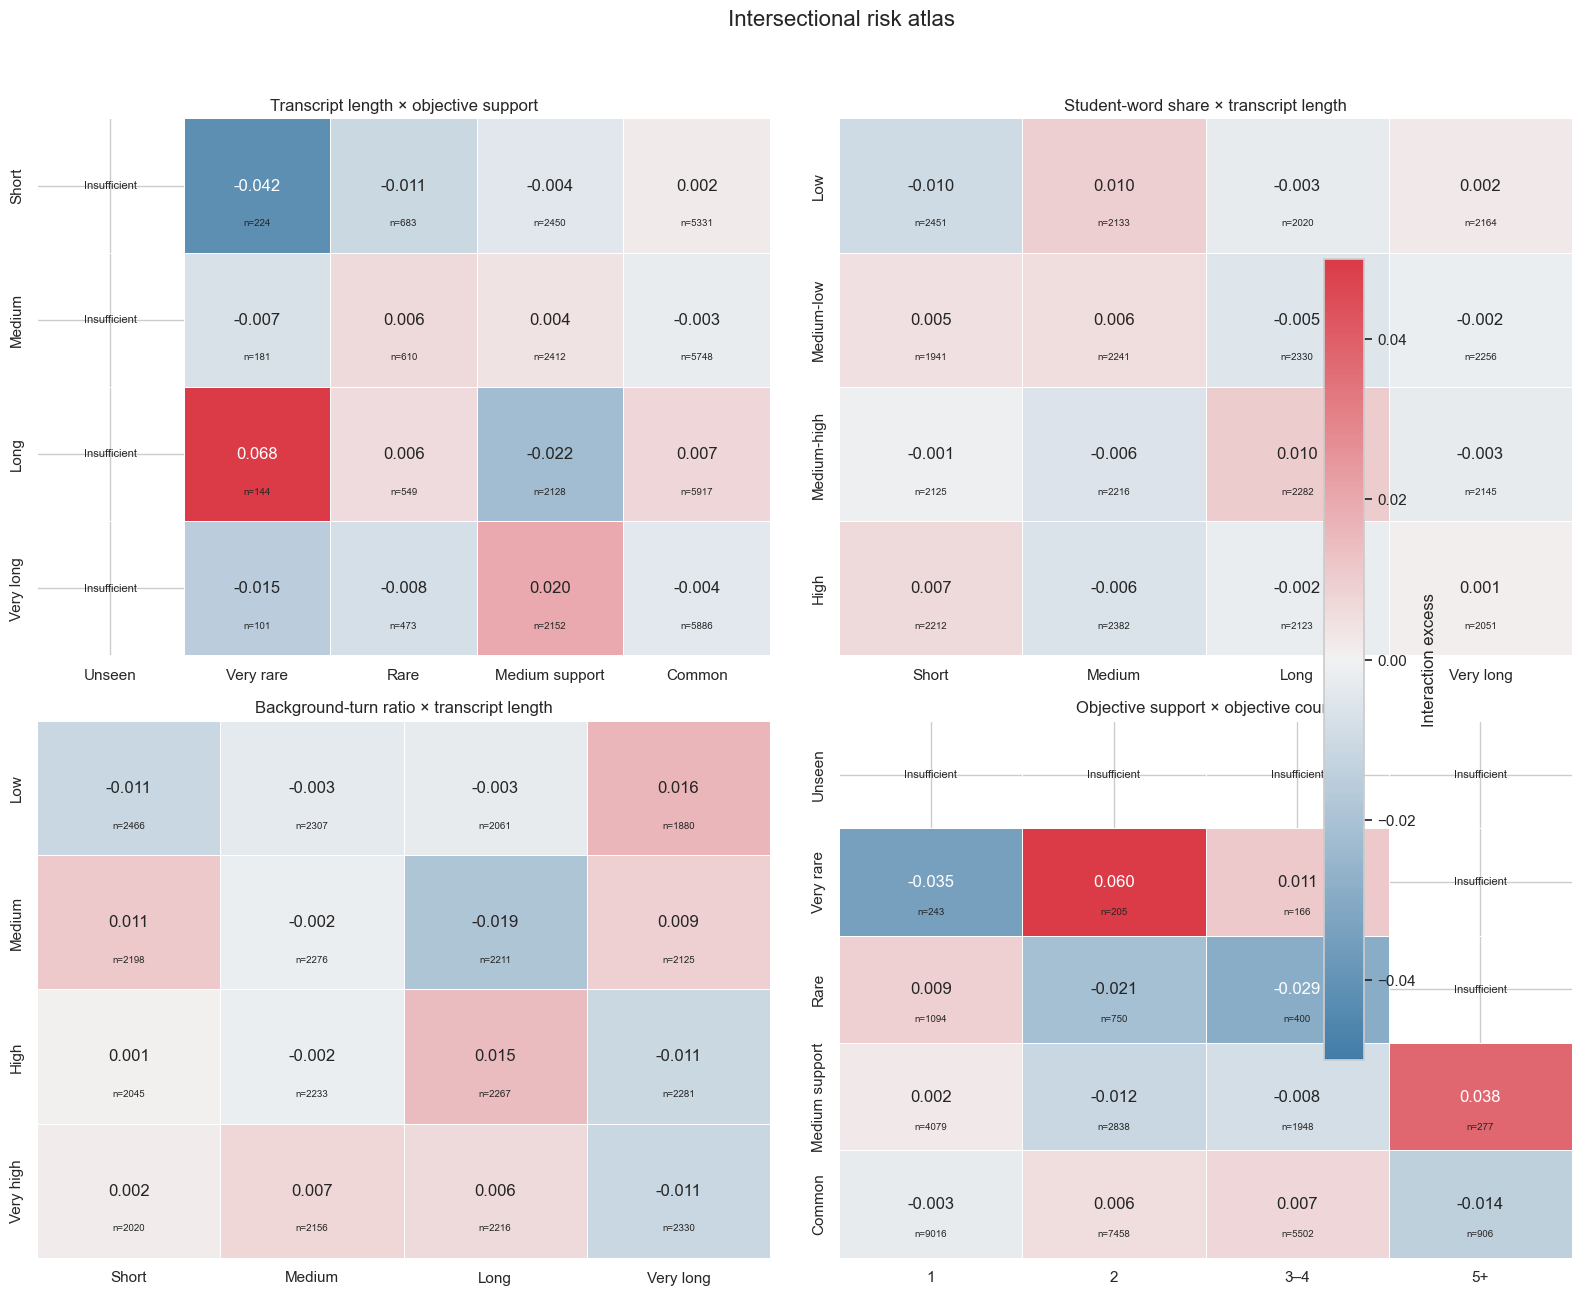

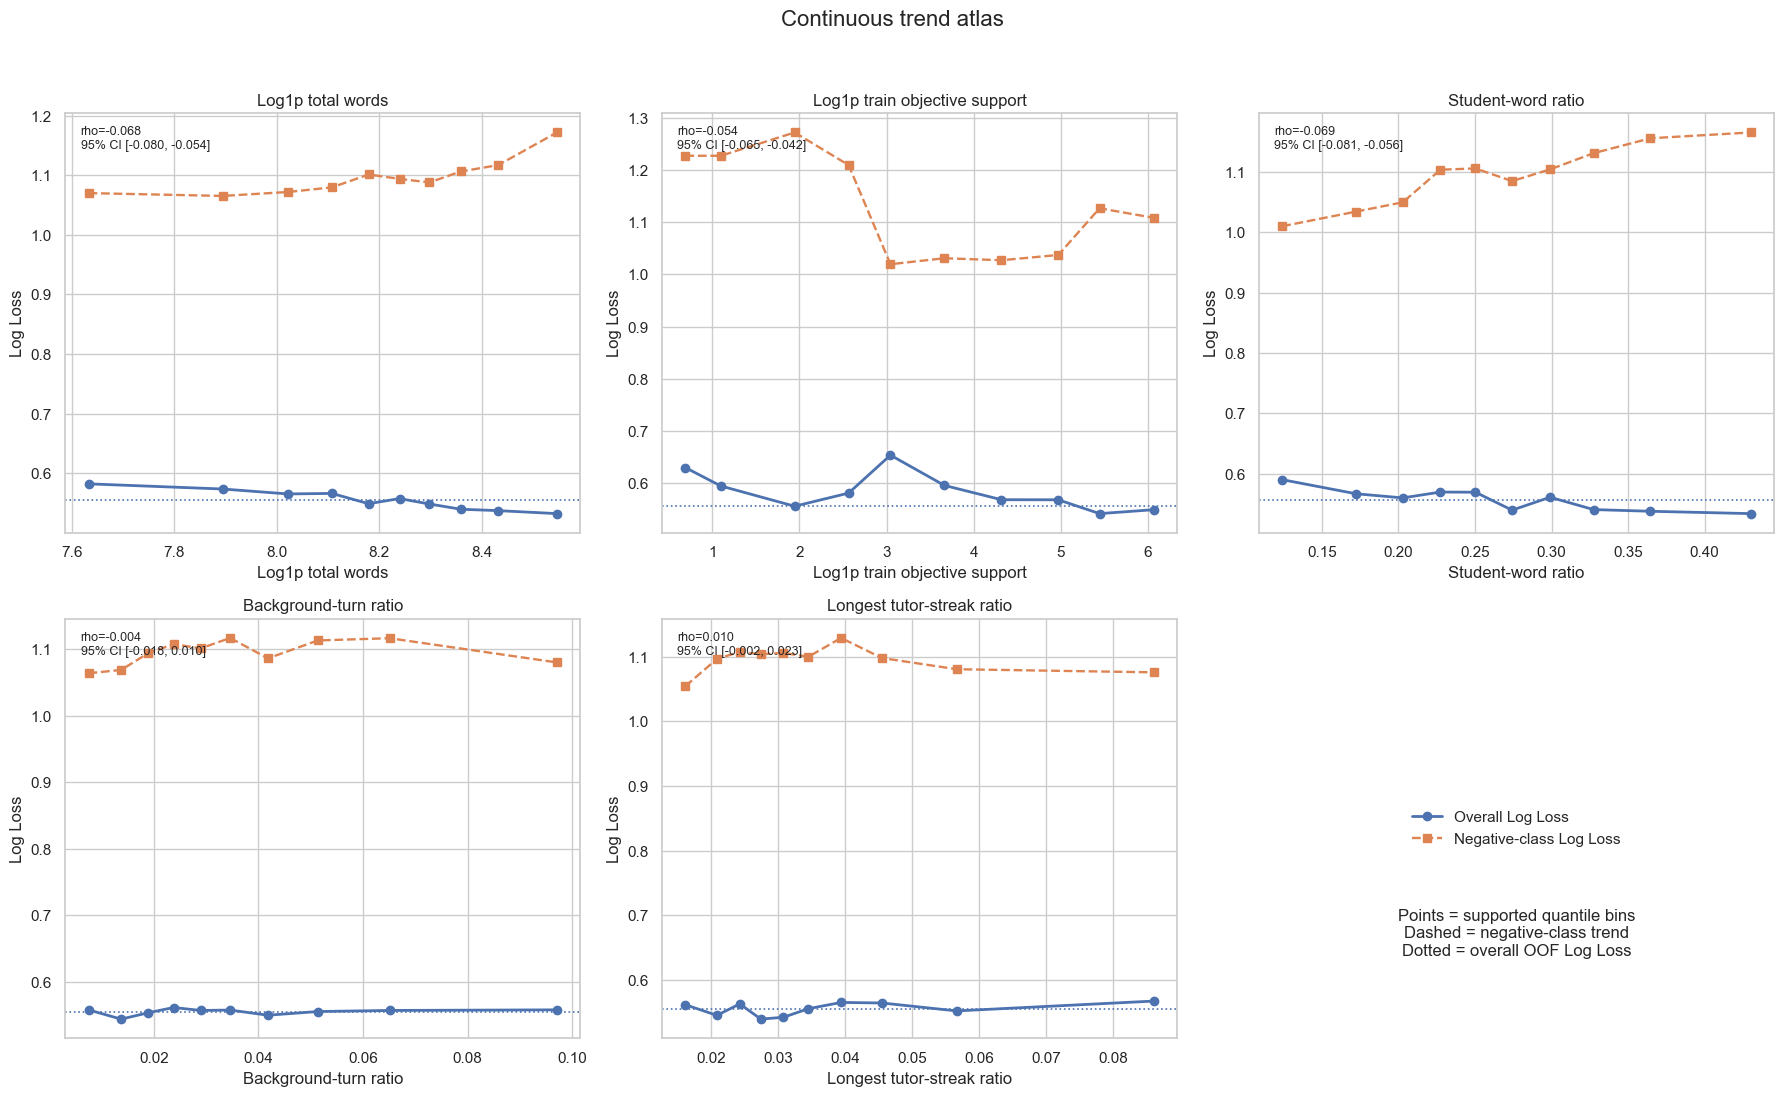

Saved: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\step5_linkage\step5_mechanism_linkage.png
Saved: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\intersections\intersection_risk_atlas.png
Saved: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\06_group_analysis\continuous_trends\continuous_trend_atlas.png


In [43]:
def plot_jkl_results(results):
    linkage = results["linkage"].copy()
    intersections = results["intersections"].copy()
    trends = results["trends"].copy()
    trend_bins = results["trend_bins"].copy()

    out_j = results["dirs"]["J"]
    out_k = results["dirs"]["K"]
    out_l = results["dirs"]["L"]

    cmap = sns.diverging_palette(240, 10, as_cmap=True)

    # Figure 1 — Step 5 linkage

    risk_columns = ["Session Log Loss excess", "Negative-objective loss excess", "Session-margin deficit", "Pairwise-accuracy deficit", "Collapse-rate excess (pp)", "Reversal-rate excess (pp)", "Max-negative-probability excess"]
    plot_linkage = linkage[linkage["Headline eligible"]].copy()

    if plot_linkage.empty:
        plot_linkage = linkage.copy()

    scaled = plot_linkage[risk_columns].copy()

    for column in risk_columns:
        scale = scaled[column].abs().median()
        scaled[column] = scaled[column] / (scale if pd.notna(scale) and scale > 0 else 1)

    scaled.index = plot_linkage["Chart label"]
    plot_linkage["Risk score"] = scaled.rank(pct=True).mean(axis=1).to_numpy()
    selected = plot_linkage.nlargest(min(18, len(plot_linkage)), "Risk score")
    heatmap_data = scaled.loc[selected["Chart label"]]

    fig, axes = plt.subplots(1, 2, figsize=(19, max(8, 0.42 * len(heatmap_data) + 3)), gridspec_kw={"width_ratios": [1.45, 1]})

    heatmap_limit = max(float(np.nanquantile(np.abs(heatmap_data.to_numpy()), 0.95)), 1)

    sns.heatmap(heatmap_data, cmap=cmap, center=0, vmin=-heatmap_limit, vmax=heatmap_limit, linewidths=0.4, ax=axes[0], cbar_kws={"label": "Robust-scaled excess"})

    axes[0].set(title="Step 5 mechanism fingerprint", xlabel="", ylabel="")

    bubble_sizes = 70 + 430 * np.log1p(selected["Mixed sessions"]) / np.log1p(selected["Mixed sessions"].max())

    scatter = axes[1].scatter(selected["Mean negative-objective loss"], selected["Mean session margin"], s=bubble_sizes, c=selected["Session collapse rate (%)"], cmap="viridis", alpha=0.80, edgecolors="white")

    axes[1].axvline(results["linkage_ref"]["negative_mean_loss"], linestyle="--")
    axes[1].axhline(results["linkage_ref"]["session_margin"], linestyle="--")

    for _, row in selected.nlargest(min(8, len(selected)), "Risk score").iterrows():
        axes[1].annotate(row["Chart label"], (row["Mean negative-objective loss"], row["Mean session margin"]), xytext=(4, 4), textcoords="offset points", fontsize=8)

    fig.colorbar(scatter, ax=axes[1], label="Session collapse rate (%)")

    axes[1].set(title="Negative loss versus session margin", xlabel="Mean negative-objective loss", ylabel="Mean session margin")

    plt.tight_layout()
    plt.savefig(out_j / "step5_mechanism_linkage.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Figure 2 — Intersection atlas

    specifications = [
        ("Transcript length × objective support", "group_transcript", "group_objective_support"),
        ("Student-word share × transcript length", "group_student_share", "group_transcript"),
        ("Background-turn ratio × transcript length", "group_background", "group_transcript"),
        ("Objective support × objective count", "group_objective_support", "group_objective_count")
    ]

    supported_excess = intersections.loc[intersections["Support eligible"], "Interaction excess"].dropna()
    interaction_limit = max(float(supported_excess.abs().quantile(0.95)) if len(supported_excess) else 0.05, 0.05)

    fig, axes = plt.subplots(2, 2, figsize=(17, 13))

    for axis, (intersection_name, a_column, b_column) in zip(axes.flat, specifications):
        intersection_data = intersections[intersections["Intersection"].eq(intersection_name)].copy()

        if intersection_data.empty:
            axis.axis("off")
            continue

        a_order = results["group_orders"].get(a_column, intersection_data["A group"].drop_duplicates().tolist())
        b_order = results["group_orders"].get(b_column, intersection_data["B group"].drop_duplicates().tolist())

        value_table = intersection_data.pivot(index="A group", columns="B group", values="Interaction excess").reindex(index=a_order, columns=b_order)
        eligibility_table = intersection_data.pivot(index="A group", columns="B group", values="Support eligible").reindex(index=a_order, columns=b_order).fillna(False)

        sns.heatmap(value_table.where(eligibility_table), cmap=cmap, center=0, vmin=-interaction_limit, vmax=interaction_limit, annot=True, fmt=".3f", linewidths=0.5, cbar=False, ax=axis)

        for row_index, a_group in enumerate(a_order):
            for column_index, b_group in enumerate(b_order):
                cell = intersection_data[intersection_data["A group"].eq(str(a_group)) & intersection_data["B group"].eq(str(b_group))]

                if cell.empty or not bool(cell.iloc[0]["Support eligible"]):
                    axis.text(column_index + 0.5, row_index + 0.5, "Insufficient", ha="center", va="center", fontsize=8)
                else:
                    axis.text(column_index + 0.5, row_index + 0.78, f"n={int(cell.iloc[0]['Responses'])}", ha="center", va="center", fontsize=7)

        axis.set(title=intersection_name, xlabel="", ylabel="")

    scalar_map = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-interaction_limit, interaction_limit))
    fig.colorbar(scalar_map, ax=axes.ravel().tolist(), shrink=0.80, label="Interaction excess")

    fig.suptitle("Intersectional risk atlas", y=0.995, fontsize=16)

    plt.tight_layout(rect=[0, 0, 0.94, 0.97])
    plt.savefig(out_k / "intersection_risk_atlas.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Figure 3 — Continuous trends

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    variables = trends["Variable"].tolist()[:5]

    for axis, variable in zip(axes.flat[:5], variables):
        summary = trends[trends["Variable"].eq(variable)].iloc[0]
        variable_bins = trend_bins[trend_bins["Variable"].eq(variable)].sort_values("Trend bin")

        if variable_bins.empty:
            axis.axis("off")
            continue

        axis.plot(variable_bins["Median X"], variable_bins["Mean Log Loss"], marker="o", linewidth=2, label="Overall Log Loss")
        axis.plot(variable_bins["Median X"], variable_bins["Negative LL"], marker="s", linestyle="--", linewidth=1.7, label="Negative-class Log Loss")
        axis.axhline(results["data"]["sample_log_loss"].mean(), linestyle=":", linewidth=1.2)

        axis.set(title=summary["Display name"], xlabel=summary["Display name"], ylabel="Log Loss")
        axis.text(0.03, 0.97, f"rho={summary['Spearman rho']:.3f}\n95% CI [{summary['Bootstrap CI low']:.3f}, {summary['Bootstrap CI high']:.3f}]", transform=axis.transAxes, va="top", fontsize=9)

    for axis in axes.flat[len(variables):5]:
        axis.axis("off")

    axes.flat[5].axis("off")

    if variables:
        handles, labels = axes.flat[0].get_legend_handles_labels()
        axes.flat[5].legend(handles, labels, loc="center", frameon=False)

    axes.flat[5].text(0.5, 0.25, "Points = supported quantile bins\nDashed = negative-class trend\nDotted = overall OOF Log Loss", ha="center", va="center")

    fig.suptitle("Continuous trend atlas", y=0.995, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_l / "continuous_trend_atlas.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_j / 'step5_mechanism_linkage.png'}")
    print(f"Saved: {out_k / 'intersection_risk_atlas.png'}")
    print(f"Saved: {out_l / 'continuous_trend_atlas.png'}")


plot_jkl_results(jkl_results)